# DreamMaker Commercial Interaction Analysis

**Introducción**

DreamMaker utiliza Facebook como uno de sus principales canales de interacción con la comunidad, donde cada publicación genera cientos de comentarios asociados a distintos diseños físicos y digitales inspirados principalmente en personajes históricos e instituciones.

Sin embargo, el elevado volumen de interacción dificulta interpretar correctamente el verdadero recibimiento comercial de cada publicación. Una gran cantidad de comentarios puede reflejar un alto interés por adquirir el producto, pero también puede deberse a controversias políticas, discusiones ideológicas, humor, sarcasmo o conversaciones completamente ajenas al objetivo comercial de la empresa.

En consecuencia, métricas tradicionales como el número total de comentarios o las reacciones obtenidas resultan insuficientes para evaluar el desempeño comercial de una publicación, ya que no distinguen entre interacción potencialmente valiosa e interacción generada por factores externos.

Para abordar este problema, en el notebook **`01_semantic_classification_pipeline.ipynb`** se desarrolló un pipeline de Procesamiento de Lenguaje Natural (NLP) capaz de clasificar automáticamente cada comentario según distintas dimensiones semánticas, permitiendo identificar, entre otras categorías:

- interés comercial;
- elogios y críticas al producto;
- solicitudes de nuevos diseños;
- ruido conversacional;
- polarización política;
- fanatismo ideológico (no comercial);
- sarcasmo;
- otras expresiones no asociadas directamente a intención de compra.

Una vez obtenidas estas clasificaciones, surge una nueva pregunta de negocio:

> **¿Qué características de una publicación explican que una conversación termine generando un mayor interés comercial para DreamMaker?**

Este notebook busca responder esa pregunta mediante un análisis exploratorio, estadístico e inferencial de las publicaciones, utilizando las variables semánticas generadas por el pipeline de NLP para estudiar cómo distintos tipos de contenido modifican la composición de la conversación y el interés comercial observado.

En particular, el análisis pretende responder preguntas como:

- ¿Qué personajes históricos generan un mayor interés comercial?
- ¿Qué instituciones producen conversaciones más orientadas al producto?
- ¿Cómo influye el ruido social sobre el interés comercial?
- ¿Existen distintos regímenes de comportamiento según el nivel de viralidad de una publicación?
- ¿Qué tipo de publicaciones concentran realmente la mayor parte del interés comercial generado por la página?

Para responder estas preguntas se emplean distintas herramientas de analítica de datos, incluyendo análisis exploratorio (EDA), pruebas de hipótesis no paramétricas, modelos de regresión para variables de conteo y árboles de decisión interpretables.

Más que construir un modelo predictivo de máxima precisión, el propósito de este trabajo consiste en comprender los mecanismos que explican el comportamiento comercial de las publicaciones de DreamMaker, identificando patrones que puedan transformarse en evidencia útil para apoyar futuras decisiones de contenido y estrategias comerciales.

# Dependencias

In [52]:
# Librerías estándar
from pathlib import Path
import math
import re
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)


# Manipulación de datos
import numpy as np
import pandas as pd


# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import seaborn as sns


# Estadística descriptiva y pruebas de hipótesis
from scipy import stats

from scipy.stats import (
    shapiro,
    levene,
    mannwhitneyu,
    kruskal,
    f_oneway,
    pearsonr,
    spearmanr
)


# Modelado estadístico (Statsmodels)
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.discrete.discrete_model import NegativeBinomial
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Comparaciones post-hoc
!pip install -q scikit-posthocs

import scikit_posthocs as sp


# Machine Learning
from sklearn.tree import DecisionTreeRegressor


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Generación del dataset enriquecido (Pipeline ETL + ML)

En esta etapa se ejecuta el pipeline modular desarrollado en `01_semantic_classification_pipeline.ipynb`, cuyo objetivo es transformar comentarios obtenidos desde Facebook en un dataset analítico enriquecido, diseñado para separar la señal comercial real del ruido social, emocional e ideológico, y servir como base para posteriores análisis de negocio.

El pipeline implementa una arquitectura incremental tipo **Medallion** (`Bronze → Silver → Gold`) y procesa únicamente los comentarios nuevos detectados desde la última ejecución, evitando reprocesar información previamente almacenada.

Durante su ejecución realiza automáticamente las siguientes etapas:

1. **Extracción de datos**
   - Obtiene publicaciones y comentarios mediante la Facebook Graph API.
   - Detecta únicamente nuevos `comment_id`.
   - Actualiza la capa **Bronze**.

2. **Preprocesamiento**
   - Limpieza y normalización de texto.
   - Eliminación de comentarios vacíos (stickers, GIF, imágenes, etc.).
   - Generación del dataset limpio (**Silver**).

3. **Generación de embeddings**
   - Vectorización semántica utilizando **BETO (`dccuchile/bert-base-spanish-wwm-cased`)**.
   - Obtención de embeddings tanto para el comentario como para la publicación asociada.

4. **Clasificación jerárquica**
   - **Capa 1:** clasificación multilabel de intención semántica mediante **Regresión Logística One-vs-Rest**.
   - **Capa 2:** detección contextual de sarcasmo utilizando **XGBoost**, incorporando como entrada tanto los embeddings como las predicciones de la Capa 1.

5. **Reglas de negocio**
   - Construcción de etiquetas derivadas orientadas a negocio, permitiendo separar la señal comercial real del ruido emocional, ideológico y sarcástico.
   - Generación del dataset **Gold Enriched**.

6. **Agregación por publicación**
   - Construcción de un nuevo dataset donde cada fila representa una publicación de Facebook.
   - Cálculo de métricas agregadas como volumen de interés, solicitudes, elogios, críticas, polarización política, fanatismo, señal comercial y ruido social.
   - Estimación de proporciones suavizadas mediante **Bayesian Smoothing**, reduciendo la inestabilidad de publicaciones con bajo volumen de comentarios.

7. **Enriquecimiento temático**
   - Incorporación de variables descriptivas obtenidas mediante reglas basadas en palabras clave presentes en el texto de cada publicación.
   - Identificación de instituciones (Carabineros, Ejército, FACh, Armada, PDI), personajes históricos y publicaciones relacionadas con la Guerra del Pacífico.
   - Identificación del formato del producto (físico o digital).

---

## Arquitectura del clasificador

El modelo utilizado en este notebook fue entrenado previamente en `01_semantic_classification_pipeline.ipynb`.

Su arquitectura corresponde a un sistema jerárquico de dos etapas:

```text
Comentario
      │
      ▼
 Embeddings BETO
      │
      ▼
Capa 1
Regresión Logística OvR
(Intención semántica multilabel)
      │
      ▼
Predicciones multilabel
      │
      ▼
Capa 2
XGBoost
(Detección contextual de sarcasmo)
      │
      ▼
Reglas de negocio
      │
      ▼
Gold Enriched
      │
      ▼
Agregación por publicación
(Bayesian Smoothing)
      │
      ▼
Enriquecimiento temático
      │
      ▼
facebook_post_metrics.parquet
```

La primera etapa identifica simultáneamente múltiples dimensiones semánticas del comentario:

- `interes`
- `elogio_producto`
- `critica_producto`
- `fanatismo_emocional`
- `conflictivo`
- `otro`
- `solicitud`
- `cuidado`

Posteriormente, un segundo modelo especializado determina si dichas intenciones fueron expresadas mediante sarcasmo, utilizando como contexto las etiquetas previamente predichas. Finalmente, ambas salidas son combinadas mediante reglas de negocio para reconstruir señales de valor comercial más cercanas a la intención real del usuario.

---

## Modelos seleccionados

Tras evaluar múltiples algoritmos y realizar optimización de hiperparámetros, ajuste de umbrales y experimentación con datos sintéticos, se seleccionaron los siguientes modelos finales:

### Capa 1 — Clasificación multilabel

Modelo:

```text
Regresión Logística One-vs-Rest
```

Métricas de validación:

| Métrica | Valor |
|---------|------:|
| F1 Micro | **0.773** |
| F1 Macro | **0.796** |
| Exact Match | **0.563** |
| Hamming Loss | **0.076** |

**Nota:** Dado el marcado desbalance de clases del problema, la métrica principal utilizada para la selección y optimización del modelo fue **F1 Macro**, ya que evalúa el desempeño de todas las etiquetas por igual, evitando que las clases mayoritarias dominen la evaluación.

---

### Capa 2 — Detección de sarcasmo

Modelo:

```text
XGBoost
```

Métricas de validación:

| Métrica | Valor |
|---------|------:|
| Accuracy | **0.915** |
| Precision | **0.724** |
| Recall | **0.829** |
| F1-score | **0.773** |

Adicionalmente, el detector de sarcasmo obtuvo un desempeño especialmente alto en aquellas categorías donde la ironía modifica directamente la interpretación comercial del comentario, alcanzando valores de F1 entre **0.80** y **0.90** para etiquetas como `interes`, `elogio_producto`, `critica_producto` y `solicitud`.

---

## Etiquetas derivadas de negocio

Las predicciones generadas por el clasificador jerárquico son posteriormente reinterpretadas mediante un conjunto de reglas de negocio, construyendo nuevas variables orientadas al análisis comercial. Estas etiquetas representan una aproximación más cercana a la intención real del usuario y constituyen la base de todas las métricas utilizadas en este notebook.

Las principales variables derivadas corresponden a:

| Variable | Interpretación |
|----------|----------------|
| **interes_real** | Usuarios que manifiestan una intención comercial genuina, por ejemplo consultando por precio, métodos de pago, disponibilidad, despachos, dimensiones, materiales u otra información asociada al producto. |
| **solicitud_real** | Usuarios que solicitan nuevos diseños, modificaciones, personalizaciones o futuras versiones de los productos publicados. |
| **elogio_real** | Comentarios que expresan una valoración positiva hacia la calidad, apariencia o características del producto. |
| **critica_genuina** | Comentarios que expresan observaciones negativas sobre el producto, excluyendo aquellos cuyo tono corresponde principalmente a confrontación política o sarcasmo. |
| **polarizacion_politica** | Comentarios conflictivos motivados principalmente por discusiones políticas, ideológicas o altamente confrontacionales, cuyo contenido no aporta valor comercial directo. |
| **fanatismo** | Comentarios que expresan entusiasmo o apoyo emocional hacia el producto, con o sin muestras de interés en realizar una compra. |
| **fanatismo_no_comercial** | Comentarios que expresan entusiasmo o apoyo emocional hacia el producto, pero sin manifestar intención de compra ni otras señales comerciales explícitas. Esta categoría representa una forma de interacción positiva que se interpreta como ruido desde la perspectiva comercial. |

A partir de estas variables individuales se construyen posteriormente dos indicadores compuestos:

- **comentario_senal_comercial**, correspondiente a comentarios que presentan al menos una señal de valor comercial (interés, solicitud, elogio o crítica del producto).
- **comentario_ruido_social**, correspondiente a comentarios asociados a polarización política o fanatismo no comercial.

Estas dos variables constituyen la base para la construcción de las métricas agregadas utilizadas posteriormente a nivel de publicación.

---

## Datasets generados por el pipeline

La ejecución completa del pipeline produce distintos datasets dentro de la capa **Gold**, cada uno orientado a un nivel diferente de análisis.

### Nivel comentario

Estos datasets contienen una fila por comentario (aproximadamente **3.000 registros**):

| Dataset | Contenido |
|---------|-----------|
| `facebook_comments_classified.parquet` | Predicciones finales de todas las etiquetas del clasificador jerárquico. |
| `facebook_comments_probabilities.parquet` | Probabilidades estimadas para cada etiqueta, utilizadas principalmente para análisis y calibración del modelo. |
| `facebook_comments_gold_enriched.parquet` | Dataset enriquecido que incorpora las reglas de negocio y las etiquetas derivadas orientadas al análisis comercial. |

### Nivel publicación

Finalmente, el pipeline genera un dataset agregado donde cada fila representa una publicación de Facebook (aproximadamente **150 publicaciones**):

| Dataset | Contenido |
|---------|-----------|
| `facebook_post_metrics.parquet` | Métricas agregadas por publicación, incluyendo volúmenes, proporciones suavizadas mediante Bayesian Smoothing, indicadores de señal comercial, ruido social y variables temáticas. |

Este último dataset constituye la principal entrada del presente notebook y será utilizado para realizar el análisis exploratorio, segmentación de publicaciones y extracción de conocimiento comercial.

## Ejecución del pipeline

In [74]:
%run pipeline.py

Cargando modelo BETO (dccuchile/bert-base-spanish-wwm-cased)...


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✔ Modelo cargado en: cpu

[1/5] Extrayendo comentarios nuevos desde Facebook...
Bronze no encontrado. Se realizará extracción completa.

Extrayendo datos desde Facebook...
Posts extraídos desde la API: 197
Comentarios únicos extraídos desde la API: 3228

─────────────────────────────────────────────
  3269 comentarios nuevos agregados a Bronze.
  Total Bronze acumulado: 3269 registros.
  Archivo: data\bronze\facebook_comments_raw.csv
─────────────────────────────────────────────

[2/5] Preprocesando comentarios nuevos...
   Filas eliminadas (comentario vacío): 312
─────────────────────────────────────────────
  2957 comentarios nuevos guardados en Silver.
  Archivo: data\silver\facebook_comments_clean.csv
─────────────────────────────────────────────

[3/5] Generando embeddings BETO...
   Generando embeddings de comentarios (2957 filas)...


100%|██████████| 93/93 [01:36<00:00,  1.04s/it]


   Generando embeddings de publicaciones (2957 filas)...


100%|██████████| 93/93 [02:03<00:00,  1.33s/it]


─────────────────────────────────────────────
  2957 comentarios nuevos con embeddings agregados.
  Total acumulado en Silver: 2957 registros.
  Archivo: data\silver\facebook_comments_embeddings.parquet
─────────────────────────────────────────────

[4/5] Clasificando comentarios nuevos (pipeline jerárquico)...
   ✔ Modelos cargados.
   Ejecutando Capa 1 (multilabel OvR)...
   Ejecutando Capa 2 (sarcasmo XGBoost)...
   Aplicando reglas de negocio...
─────────────────────────────────────────────
  2957 comentarios nuevos clasificados.
  Total acumulado en Gold: 2957 registros.
  Predicciones  : data\gold\facebook_comments_classified.parquet
  Probabilidades: data\gold\facebook_comments_probabilities.parquet
  Enriquecido   : data\gold\facebook_comments_gold_enriched.parquet
─────────────────────────────────────────────

[5/5] Calculando métricas por publicación...
─────────────────────────────────────────────
  Métricas calculadas para 155 publicaciones.
  Archivo: data\gold\facebook_po

# Exploratory Data Analysis
En el Notebook `01_semantic_classification_pipeline.ipynb` se realizó el análisis exploratorio correspondiente a la calidad de los datos originales y al proceso de construcción del pipeline (tipos de datos, valores nulos, duplicados, limpieza y normalización del texto, entre otros).

En este notebook el análisis exploratorio se centra exclusivamente en el dataset analítico generado por el pipeline, estudiando la distribución de las métricas agregadas por publicación, las relaciones entre variables y los patrones comerciales presentes en la información enriquecida.

In [69]:
#Cargamos el dataset generado por el pipeline persistido en Gold
df = pd.read_parquet(r"data\gold\facebook_post_metrics.parquet")

## Dataset desagregado por personajes históricos
Con el fin de obtener una caracterización más precisa, esta categoría fue desagregada en etiquetas individuales para cada personaje histórico identificado en las publicaciones. De esta forma es posible evaluar si el comportamiento observado corresponde realmente a toda la categoría o si está siendo impulsado principalmente por uno o unos pocos personajes con alta capacidad de generar interacción.

A diferencia del análisis por instituciones, donde cada categoría representa organizaciones relativamente homogéneas, la separación por personaje permite estudiar el efecto particular que cada figura histórica ejerce sobre las distintas métricas comerciales y de ruido social.

In [32]:
personajes = {
    "post_pinochet": [
        "pinochet",
        "augusto pinochet"
    ],

    "post_allende": [
        "allende",
        "salvador allende"
    ],

    "post_prat": [
        "arturo prat",
        "prat"
    ],

    "post_ohiggins": [
        "bernardo o'higgins",
        "o'higgins",
        "ohiggins"
    ],

    "post_carrera": [
        "jose miguel carrera",
        "carrera"
    ],

    "post_manuel_rodriguez": [
        "manuel rodriguez",
        "manuel rodríguez",
        "rodriguez",
        "rodríguez"
    ],

    "post_lautaro": [
        "lautaro"
    ],

    "post_neruda": [
        "pablo neruda",
        "neruda"
    ],

    "post_mistral": [
        "gabriela mistral",
        "mistral"
    ]
}

for col, palabras in personajes.items():
    patron = "|".join(re.escape(p) for p in palabras)

    df[col] = (
        df["clean_post_message"]
        .str.contains(patron, case=False, regex=True)
        .astype(int)
    )

Reconstruimos la etiqueta general 

In [33]:
cols_personajes = list(personajes.keys())

df["post_personajes_historicos"] = (
    df[cols_personajes]
    .any(axis=1)
    .astype(int)
)

Persistimos el dataset para retomar

In [55]:
# Ruta Gold local
gold_path = Path("data/gold")
gold_path.mkdir(parents=True, exist_ok=True)

# Nombre del dataset
output_file = gold_path / "gold_post_personajes_historicos_analysis.parquet"

# Guardar dataset enriquecido
df.to_parquet(
    output_file,
    index=False
)

print(f"Dataset guardado correctamente en:\n{output_file}")
print(f"Dimensiones: {df.shape}")

Dataset guardado correctamente en:
data\gold\gold_post_personajes_historicos_analysis.parquet
Dimensiones: (155, 38)


## Vista General del Dataset

In [54]:
df.head(5)

,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_fanatismo_no_comercial,...,post_personajes_historicos,post_pinochet,post_allende,post_prat,post_ohiggins,post_carrera,post_manuel_rodriguez,post_lautaro,post_neruda,post_mistral
0,154787275135903_1003489410265681,grumete de la marina chilena,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,154787275135903_1029896382473424,diseno 3d de mujer montanes del ejercito de ch...,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,154787275135903_1030709625725433,none,4,4,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,154787275135903_1033619428767786,diseno 3d en homenaje a pastelitodechile y agu...,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,154787275135903_1038284206786201,lautaro. 3d art mapuche chile 3dprinting,2,2,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0


- Info general

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 38 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   post_id                         155 non-null    object 
 1   clean_post_message              155 non-null    object 
 2   volumen_total                   155 non-null    int64  
 3   volumen_interes                 155 non-null    int32  
 4   volumen_solicitudes             155 non-null    int32  
 5   volumen_elogios                 155 non-null    int32  
 6   volumen_criticas                155 non-null    int32  
 7   volumen_polarizacion            155 non-null    int32  
 8   volumen_fanatismo               155 non-null    int32  
 9   volumen_fanatismo_no_comercial  155 non-null    int32  
 10  volumen_senal                   155 non-null    int32  
 11  volumen_ruido                   155 non-null    int32  
 12  prop_interes                    155 

## Estadísticas descriptivas

### Distribución de publicaciones por personaje histórico

In [34]:
conteo = (
    df[cols_personajes]
    .sum()
    .sort_values(ascending=False)
    .rename("n_publicaciones")
    .to_frame()
)

display(conteo)

,n_publicaciones
post_pinochet,6
post_carrera,4
post_prat,3
post_allende,2
post_lautaro,2
post_ohiggins,1
post_manuel_rodriguez,1
post_neruda,1
post_mistral,0


**OBSERVACIÓN IMPORTANTE: Limitaciones estructurales del contraste entre categorías**

Antes de interpretar los resultados específicos, es necesario considerar una limitación fundamental del dataset.

Las publicaciones analizadas no corresponden a una muestra aleatoria de personajes históricos o instituciones. Por el contrario, representan un catálogo generado bajo decisiones comerciales reales.

El número de publicaciones disponibles para cada categoría probablemente está influenciado por factores previos asociados al negocio:

- diseños que históricamente han tenido mejor recepción pueden haber generado más publicaciones;
- personajes o instituciones con mayor reconocimiento pueden haber sido explorados con mayor frecuencia;
- categorías con bajo desempeño comercial pueden haber dejado de producir nuevos modelos;
- la cantidad de publicaciones puede reflejar una decisión previa basada en percepción de demanda.

Por esta razón, el análisis no responde exactamente a la pregunta:

> "¿Qué personaje o institución genera más interés comercial?"

Sino una pregunta más acotada:

> "Dentro de los diseños que fueron publicados por la empresa, ¿qué patrones de interacción comercial y social se observan entre las categorías disponibles?"

Esta diferencia es crítica, ya que existe un potencial sesgo de selección. Por ejemplo, que Pinochet posea más publicaciones que Neruda puede deberse a múltiples explicaciones:

- mayor atractivo comercial real;
- mayor cantidad de diseños creados debido a una demanda percibida;
- mayor experimentación por parte del negocio;
- una combinación de estos factores.

Con los datos disponibles no es posible separar completamente estos mecanismos ni establecer causalidad directa entre la temática y el desempeño comercial.

### Distribución de publicaciones por temática

In [5]:
tematicas = [
    "post_carabineros",
    "post_ejercito",
    "post_fach",
    "post_armada",
    "post_pdi",
    "post_guerra_pacifico"
]

conteo = df[tematicas].sum()

# Publicaciones que no pertenecen a ninguna temática anterior
conteo["otras_tematicas"] = (df[tematicas].sum(axis=1) == 0).sum()

conteo = (
    conteo
    .sort_values(ascending=False)
    .rename("n_publicaciones")
)

display(conteo.to_frame())

,n_publicaciones
otras_tematicas,108
post_ejercito,24
post_carabineros,8
post_guerra_pacifico,8
post_armada,4
post_fach,2
post_pdi,2


**Limitaciones estructurales del análisis entre categorías**

Antes de interpretar los resultados de las pruebas de comparación entre grupos, es necesario considerar una limitación fundamental del dataset: **la distribución de publicaciones entre categorías es altamente desbalanceada y no corresponde a una muestra aleatoria del universo de posibles diseños**.

La cantidad de publicaciones disponibles para cada temática no fue determinada mediante un diseño experimental, sino que corresponde a decisiones reales del negocio. En otras palabras, el dataset refleja qué diseños fueron creados, publicados y mantenidos dentro del catálogo, lo que introduce un posible sesgo de selección.

**Distribución de publicaciones por categoría**

**Personajes históricos**

| Categoría | Número de publicaciones |
|---|---:|
| Pinochet | 6 |
| Carrera | 4 |
| Prat | 3 |
| Allende | 2 |
| Lautaro | 2 |
| O'Higgins | 1 |
| Manuel Rodríguez | 1 |
| Neruda | 1 |
| Gabriela Mistral | 0 |

**Instituciones**

| Categoría | Número de publicaciones |
|---|---:|
| Ejército | 24 |
| Carabineros | 8 |
| Guerra del Pacífico | 8 |
| Armada | 4 |
| FACh | 2 |
| PDI | 2 |

Esta distribución tiene importantes implicancias para la interpretación estadística:

- Las categorías con mayor presencia en el dataset probablemente corresponden a temáticas que tuvieron mayor continuidad dentro del catálogo o que generaron suficiente interés para seguir desarrollándose.
- Las categorías con pocas publicaciones pueden representar productos poco explorados, diseños descartados tempranamente o simplemente temáticas con menor disponibilidad histórica.
- Por lo tanto, el número de observaciones no es independiente del desempeño comercial previo, sino que puede estar influenciado por decisiones del propio negocio.

Esto genera una diferencia importante entre la pregunta que podemos responder y la pregunta ideal que nos gustaría responder.

El análisis **no permite determinar si una temática posee un atractivo comercial inherente**, ya que no observamos un experimento donde todas las categorías hayan sido evaluadas bajo condiciones equivalentes.

La pregunta que sí podremos abordar es:

> "Dentro de los diseños que fueron publicados por la empresa, ¿qué patrones de interacción comercial y social presentan las distintas categorías?"

**Impacto sobre las pruebas estadísticas**

Esta limitación afecta directamente la capacidad de los contrastes estadísticos para detectar diferencias entre grupos.

En particular:

1. **Baja potencia estadística**

   Comparar categorías con tamaños muestrales muy distintos (por ejemplo, 24 publicaciones de Ejército frente a 2 de FACh o PDI) reduce la capacidad de detectar diferencias reales.

   Esto es especialmente relevante en métricas de redes sociales, donde unas pocas publicaciones excepcionales pueden modificar completamente la distribución de un grupo.

2. **Alta variabilidad dentro de cada categoría**

   Las interacciones digitales presentan distribuciones altamente asimétricas, con muchas publicaciones de bajo desempeño y algunas publicaciones con valores extremadamente altos.

   En este contexto, una diferencia visualmente evidente entre categorías puede no ser confirmada estadísticamente si existe una alta dispersión interna o pocos datos disponibles.

3. **Imposibilidad de separar causa y selección**

   Una categoría con mayor interés comercial observado puede estar influenciada por múltiples factores:

   - atractivo propio de la temática;
   - mayor cantidad de diseños publicados;
   - experiencia acumulada en la creación del producto;
   - selección previa de diseños con mayor potencial comercial;
   - características específicas del producto.

   Por esta razón, los resultados deben interpretarse como asociaciones dentro del portafolio histórico, no como efectos causales.

En consecuencia, los resultados de Kruskal-Wallis, tamaños de efecto y análisis posteriores deben interpretarse con cautela. Las pruebas permiten identificar señales y patrones compatibles con diferencias entre categorías, pero no permiten afirmar que una temática específica sea superior de manera general sin contar con un diseño experimental más balanceado o información adicional del proceso de generación del catálogo.

### Distribución de métricas a nivel de publicación

Análisis descriptivo de las métricas agregadas considerando todas las publicaciones del conjunto de datos, sin distinguir su temática. Esta sección permite caracterizar el comportamiento general de las publicaciones y detectar patrones globales, asimetrías y posibles valores atípicos.

#### Distribución en términos de Volúmenes absolutos
Distribución de los volúmenes absolutos de las distintas categorías de interacción observadas en cada publicación, incluyendo señal comercial, ruido social y las principales reacciones identificadas por el clasificador.

In [78]:
metricas = [
    "volumen_total",
    "volumen_interes",
    "volumen_solicitudes",
    "volumen_elogios",
    "volumen_criticas",
    "volumen_polarizacion",
    "volumen_fanatismo",
    "volumen_fanatismo_no_comercial",
    "volumen_senal",
    "volumen_ruido",
]

df[metricas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
volumen_total,155.0,19.08,84.64,1.0,1.0,3.0,6.0,789.0
volumen_interes,155.0,5.12,16.79,0.0,1.0,1.0,3.0,140.0
volumen_solicitudes,155.0,0.59,2.15,0.0,0.0,0.0,1.0,23.0
volumen_elogios,155.0,2.43,10.84,0.0,0.0,0.0,1.0,117.0
volumen_criticas,155.0,0.08,0.48,0.0,0.0,0.0,0.0,4.0
volumen_polarizacion,155.0,9.26,50.33,0.0,0.0,1.0,1.5,468.0
volumen_fanatismo,155.0,3.17,18.64,0.0,0.0,0.0,1.0,198.0
volumen_fanatismo_no_comercial,155.0,2.94,18.02,0.0,0.0,0.0,1.0,196.0
volumen_senal,155.0,7.21,25.85,0.0,1.0,2.0,3.5,239.0
volumen_ruido,155.0,10.52,56.89,0.0,0.0,1.0,2.0,509.0


**Interpretación:** Se evidencia una distribución fuertemente asimétrica en todas las métricas de volumen, donde la mayoría de las publicaciones presenta pocos comentarios mientras un reducido número concentra niveles de interacción excepcionalmente altos. Asimismo, se observa que el volumen promedio de ruido social supera al de señal comercial, reforzando la necesidad de separar ambas dimensiones para interpretar correctamente el comportamiento de las publicaciones. Esta elevada heterogeneidad en el volumen de comentarios justifica, tal como se desarrolló en `01_semantic_classification_pipeline.ipynb`, la utilización de suavizado bayesiano para la construcción de las proporciones, obteniendo estimaciones más estables y comparables entre publicaciones con distintos niveles de interacción.

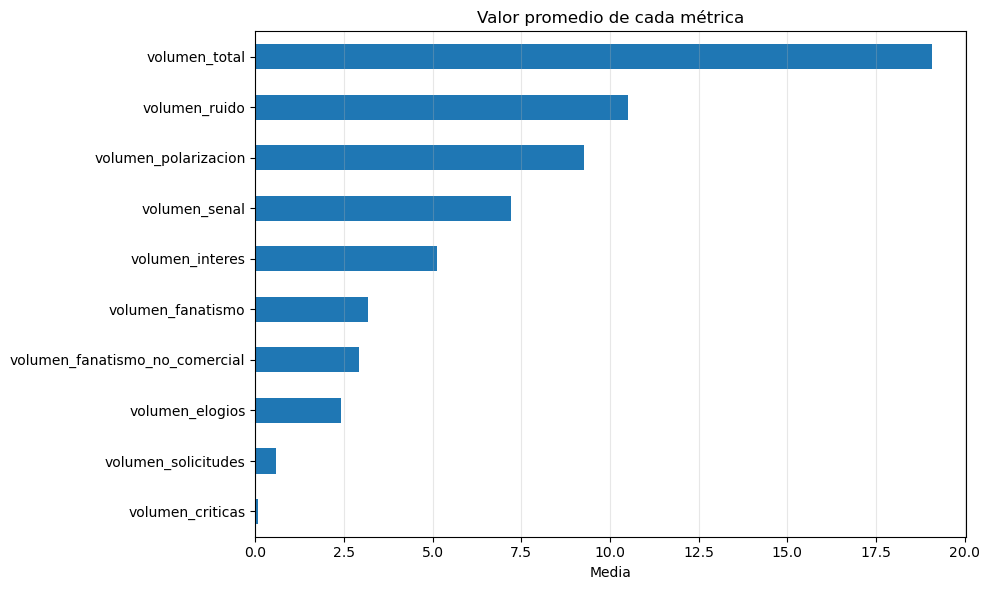

In [79]:
# Histograma del valor promedio de cada métrica
df[metricas].mean().sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Valor promedio de cada métrica")
plt.xlabel("Media")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

> **Figura. Valor promedio de las métricas de interacción a nivel de publicación.** El gráfico presenta el valor medio de cada métrica calculada sobre el conjunto de publicaciones analizadas. Las métricas corresponden a volúmenes absolutos de comentarios clasificados en distintas categorías de interacción, incluyendo señal comercial, ruido social y las principales reacciones identificadas por el clasificador. Esta visualización permite comparar la magnitud promedio de cada tipo de interacción y establecer una primera caracterización del comportamiento general del dataset.


**Interpretación**
1. Existe una alta "**Contaminación**" en la Conversación.

    La métrica `volumen_total` promedia casi 19 unidades, pero al desagregarla encontramos un problema crítico de eficiencia en la captura de leads:

- El Ruido predomina sobre la Señal: El `volumen_ruido` (~ 10.7) es significativamente mayor que el `volumen_senal` (~ 7.2).

- Ruido Político/Emocional Domina la Conversación: El `volumen_polarizacion` (~9.3) es el principal componente de este ruido. Esto significa que casi la mitad de toda la interacción que recibe la página está secuestrada por debates, discusiones políticas o reacciones emocionales ajenas al catálogo de productos.

2. Anatomía de la "Señal" (Intención de Compra vs. Feedback)
 
    Al analizar cómo se descompone ese ~7.2 de `volumen_senal`, vemos la distribución del interés real:

- Intención Comercial Pura: El `volumen_interes` (~5.1) es la métrica "sana" más alta dentro de la señal. Hay un deseo genuino de compra latente en la audiencia.

- Feedback de Comunidad: Los `volumen_elogios` (~ 2.4) y el `volumen_fanatismo` (~ 3.2, que asumo se cruza en la frontera de afinidad a la marca) muestran que hay una base de clientes fidelizada que interactúa positivamente.

- Oportunidades de Mejora Marginales: Las `volumen_solicitudes` (nuevos diseños) y `volumen_criticas` son sumamente bajas (cercanas a 1 y 0 respectivamente). Esto sugiere que el producto actual no genera rechazo técnico/estético, sino que el problema es el contexto en el que se discute.

**Histogramas de Distribución por métrica en término de volumen**

Se representan histogramas de distribución acompañados de una estimación de densidad mediante Kernel Density Estimation (KDE), permitiendo observar la forma general de cada variable y comparar visualmente sus patrones de concentración.

Las métricas analizadas corresponden a los volúmenes agregados de interacción obtenidos durante la construcción del dataset analítico:

- volumen_total
- volumen_interes
- volumen_solicitudes
- volumen_elogios
- volumen_criticas
- volumen_polarizacion
- volumen_fanatismo
- volumen_senal
- volumen_ruido

El objetivo principal es identificar características relevantes de la estructura de los datos, tales como:

- presencia de asimetrías en las distribuciones;
- concentración de publicaciones con bajo nivel de interacción;
- existencia de colas largas asociadas a publicaciones con alta viralidad;
- diferencias en la escala de las distintas categorías de interacción.

Este análisis permite determinar si las variables presentan comportamientos compatibles con distribuciones normales o si, por el contrario, poseen distribuciones altamente sesgadas producto de la existencia de publicaciones con niveles de interacción excepcionalmente altos.

La caracterización de estas distribuciones resulta fundamental para interpretar correctamente los análisis posteriores, ya que métricas basadas en volumen absoluto pueden estar dominadas por eventos extremos de alta interacción. Por esta razón, posteriormente se complementa este análisis con el estudio de proporciones normalizadas y técnicas de suavizado bayesiano descritas en la etapa de construcción del dataset.

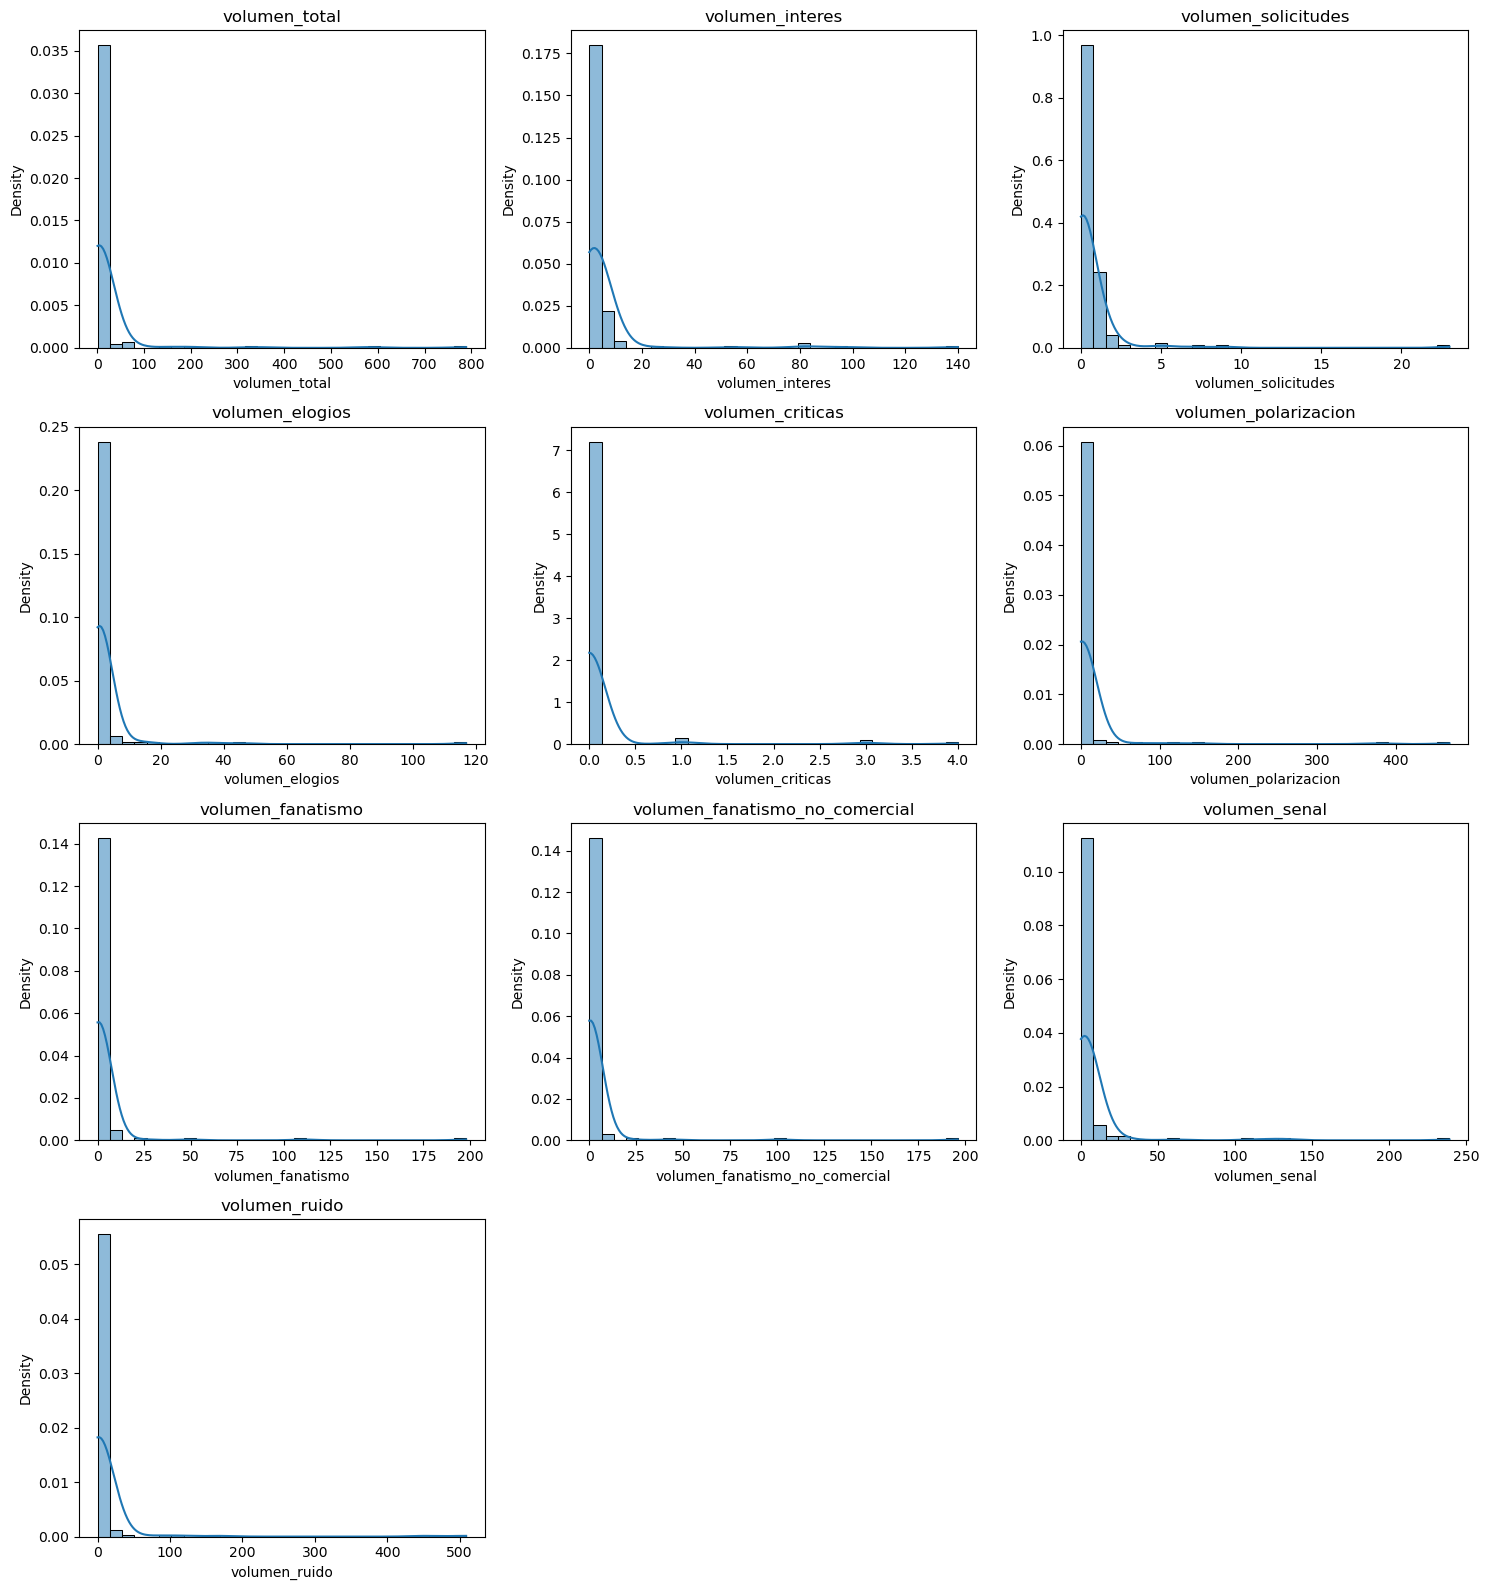

In [80]:
n = len(metricas)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, metricas):
    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        stat="density",
        ax=ax
    )
    ax.set_title(col)

# Eliminar ejes vacíos
for ax in axes[len(metricas):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

> **Figura. Distribución de las métricas de volumen a nivel de publicación.** Cada histograma representa la distribución de una métrica de volumen absoluto calculada sobre el conjunto de publicaciones analizadas. Las curvas de densidad (KDE) se incluyen para facilitar la visualización de la forma de cada distribución, permitiendo identificar patrones como asimetrías, multimodalidad, concentración de valores y posibles observaciones extremas. Esta visualización constituye una primera aproximación al comportamiento estadístico de las distintas categorías de interacción presentes en el dataset.


**Interpretación del Análisis de Distribuciones en Términos de Volumen Absoluto**

Al analizar el volumen absoluto de las interacciones ($N = 155$), se observa un comportamiento característico de **leyes de potencia (Power-Law) o distribuciones tipo Pareto / Exponenciales**. Los histogramas muestran una severa asimetría positiva (*right-skewed*), donde la gran mayoría de las observaciones se concentran en valores extremadamente bajos, mientras que una larga cola derecha representa eventos de alta viralidad.

**Hallazgos Estadísticos Clave:**
* **Efecto Outlier / Viralidad:** En variables como `volumen_total`, la mediana es de apenas 6.0 interacciones, pero la media se eleva a 19.08 debido a un máximo de 789.0. Este patrón de dispersión ($\text{std} = 84.6$) se replica en todas las submétricas (e.g., `volumen_polarizacion` con mediana 1.0 y máximo 468.0).
* **Ausencia de Normalidad:** Ninguna de las variables en volumen sigue una distribución Gaussiana. Esto invalida de manera inmediata el uso de pruebas estadísticas paramétricas tradicionales (como la correlación de Pearson estándar o regresiones lineales simples) sin antes aplicar transformaciones matemáticas (e.g., $\log(x + 1)$) para estabilizar la varianza.

**Qué SE PUEDE Concluir:**
1. **La dinámica de la página es "Event-Driven":** El tráfico no es constante ni homogéneo. Está dominado por unos pocos posteos o días "atípicos" que arrastran un volumen masivo de interacciones.
2. **Dominancia Estructural:** A nivel agregado, el volumen de ruido (`mean` = 10.52) supera a la señal comercial (`mean` = 7.21), sugiriendo que los algoritmos de las plataformas o el tipo de contenido tienden a viralizar con mayor facilidad los elementos conflictivos o emocionales.

**Qué NO SE PUEDE Concluir:**
* **Eficiencia de Contenido:** No se puede determinar si el ruido, o publicaciones con temáticas más polémicas o emocionalmente gatillantes *impulsa* la intención de compra basándose únicamente en estos volúmenes. Debido al efecto de escala (multicolinealidad), un posteo viral por motivos políticos inevitablemente registrará más volumen de interés por mera exposición probabilística, enmascarando el rendimiento real por unidad de impresión.

#### Distribución en términos de proporciones relativas

Distribución de las proporciones relativas de las distintas categorías de interacción observadas en cada publicación, incluyendo señal comercial, ruido social y las principales reacciones identificadas por el clasificador.

In [81]:
proporciones = sorted(
    [col for col in df.columns if col.startswith("prop_")]
)

df[proporciones].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
prop_criticas,155.0,0.00,0.00,0.00,0.00,0.00,0.00,0.05
prop_elogios,155.0,0.14,0.10,0.02,0.08,0.10,0.21,0.42
prop_fanatismo,155.0,0.14,0.09,0.04,0.08,0.12,0.15,0.58
prop_fanatismo_no_comercial,155.0,0.12,0.08,0.03,0.08,0.12,0.12,0.58
prop_interes,155.0,0.38,0.16,0.07,0.24,0.39,0.45,0.82
prop_polarizacion,155.0,0.37,0.14,0.12,0.29,0.36,0.43,0.85
prop_ruido_social,155.0,0.43,0.14,0.15,0.33,0.41,0.52,0.87
prop_senal_comercial,155.0,0.49,0.16,0.11,0.39,0.52,0.57,0.84
prop_solicitudes,155.0,0.04,0.06,0.00,0.02,0.02,0.02,0.30


**Histogramas de distribución por métricas en términos de proporción**

A diferencia de las métricas de volumen, que reflejan la magnitud total de interacción y pueden estar dominadas por publicaciones altamente virales, las proporciones permiten comparar publicaciones con distintos niveles de actividad, midiendo qué fracción de los comentarios corresponde a cada categoría analizada.

Las variables evaluadas corresponden a:

- prop_interes
- prop_solicitudes
- prop_elogios
- prop_criticas
- prop_polarizacion
- prop_fanatismo
- prop_senal_comercial
- prop_ruido_social

El análisis mediante histogramas y estimaciones de densidad permite observar:

- la concentración típica de cada tipo de interacción dentro de una publicación;
- la variabilidad existente entre publicaciones;
- la presencia de comportamientos diferenciados o posibles grupos naturales de publicaciones;
- la existencia de distribuciones alejadas de un comportamiento uniforme.

Este análisis resulta especialmente relevante porque permite separar dos fenómenos que pueden confundirse al analizar únicamente volúmenes absolutos:

- publicaciones con alta cantidad de comentarios debido a su viralidad;
- publicaciones donde existe una composición particularmente favorable o desfavorable de interacción comercial.

Por ejemplo, una publicación puede acumular muchos comentarios comerciales simplemente por tener alta exposición, mientras que otra puede presentar una mayor eficiencia relativa al concentrar una proporción elevada de comentarios asociados a interés comercial.

Estas distribuciones complementan el análisis de volumen absoluto y constituyen la base para posteriores análisis de segmentación, comparación entre temáticas y construcción de perfiles de publicaciones.

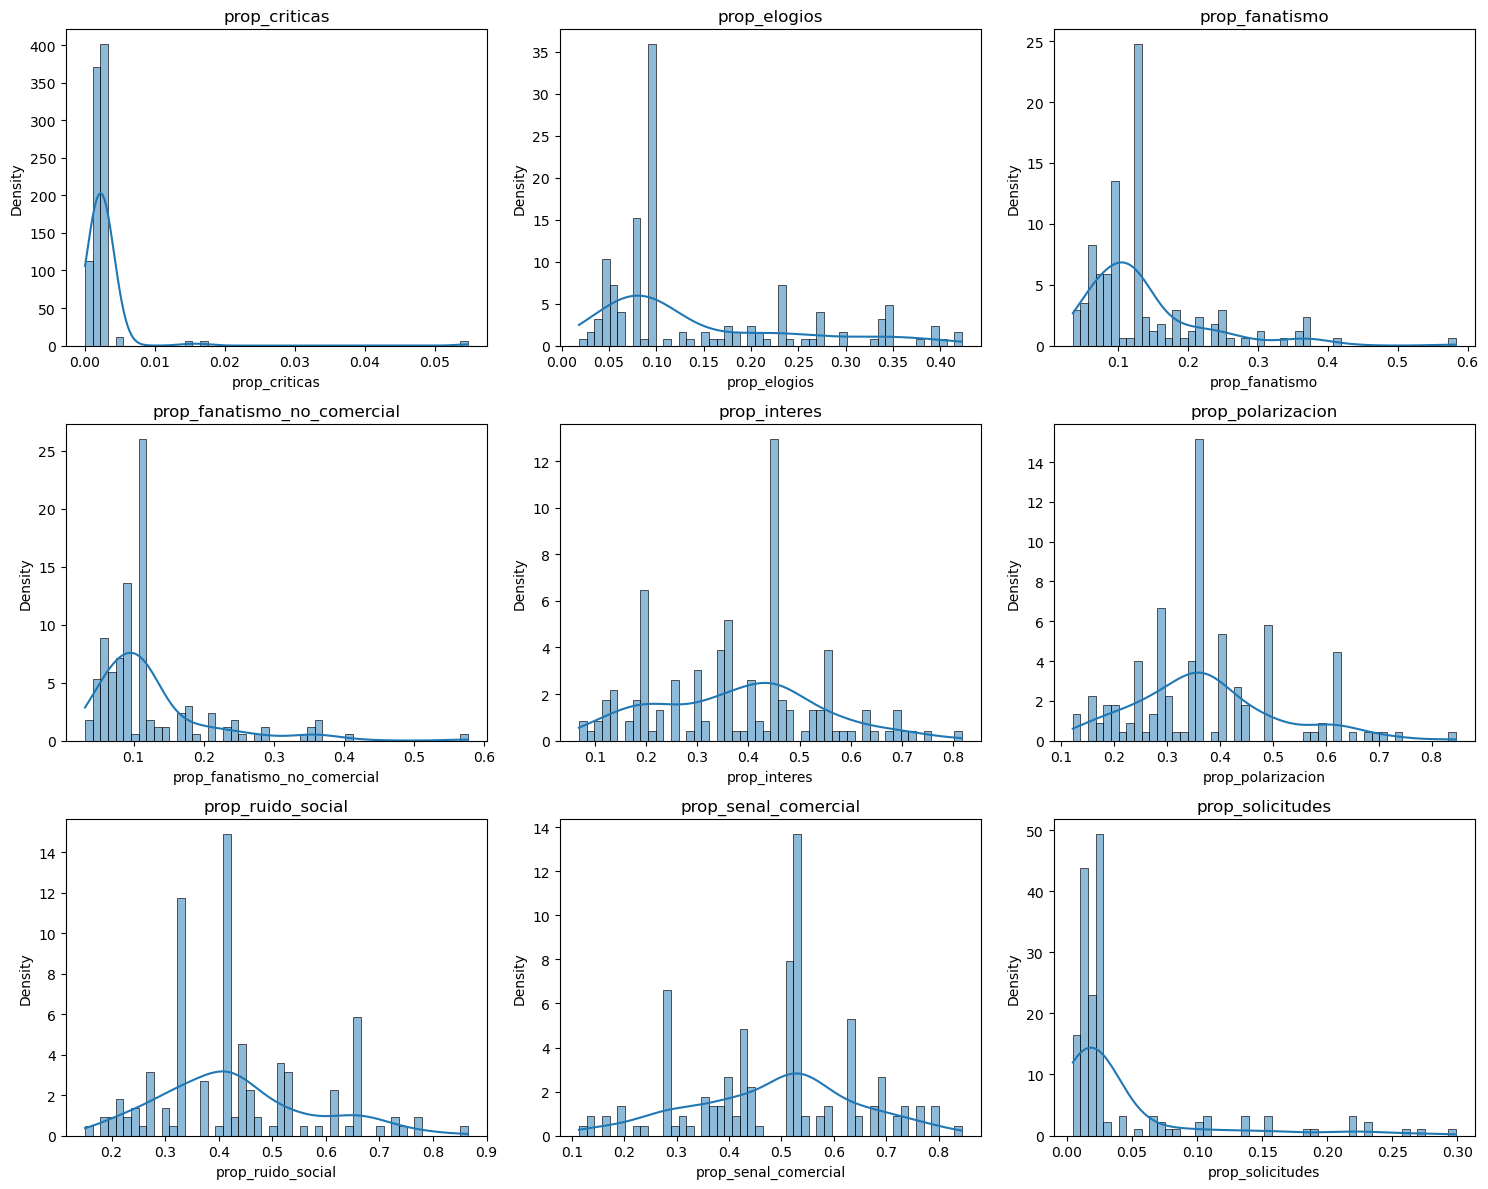

In [82]:
n = len(proporciones)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, proporciones):
    sns.histplot(
        df[col],
        bins=50,
        kde=True,
        stat="density",
        ax=ax
    )
    ax.set_title(col)

# Eliminar ejes vacíos
for ax in axes[len(proporciones):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

> **Figura. Distribución de las métricas de proporción a nivel de publicación.** Cada histograma representa la distribución de una métrica expresada como proporción respecto del total de comentarios asociados a cada publicación. Las curvas de densidad (KDE) permiten visualizar con mayor claridad la forma de las distribuciones, facilitando la identificación de patrones como concentración de valores, asimetrías, multimodalidad y posibles observaciones extremas. Al utilizar proporciones normalizadas, esta visualización permite comparar el comportamiento relativo de las distintas categorías de interacción independientemente del volumen total de comentarios recibido por cada publicación.

**Análisis de Distribuciones en Términos de Proporciones (Ratios de Composición)**

Para eliminar el sesgo del volumen y aislar la eficiencia intrínseca del contenido, se transformaron las variables a proporciones respecto al `volumen_total` de cada observación. Al remover el efecto del tamaño de los posteos, la estructura de los datos cambia drásticamente, revelando distribuciones **platicúrticas y multimodales**.

**Hallazgos Estadísticos Clave:**
* **Estabilización de las Métricas Core:** Al calcular `prop_interes` y `prop_polarizacion`, observamos que sus medias (38% y 37% respectivamente) y sus medianas (39% y 36%) son prácticamente idénticas. Esto demuestra que en el micro-entorno de cualquier interacción, la atención del usuario se divide de forma equitativa entre el interés comercial y el debate ideológico.
* **Comportamiento Multimodal:** Los histogramas de `prop_interes`, `prop_polarizacion` y `prop_ruido_social` no muestran curvas simétricas puras, sino múltiples picos bien definidos (e.g., el fuerte pico en 36% para polarización). Esto es evidencia estadística de la existencia de **clusters de comportamiento**: existen días/posteos puramente comerciales y otros que son capturados de forma sistemática por el debate social.
* **Omnipresencia del Ruido:** La métrica `prop_ruido_social` tiene un valor mínimo de 15%. Esto significa estadísticamente que **no existen publicaciones asépticas**; el ruido es una constante base en el ecosistema de la página, llegando a representar hasta el 87% de la conversación en los escenarios más críticos.

#### Síntesis y Contraste: Volumen vs. Proporción

El contraste metodológico entre el análisis de volúmenes absolutos y proporciones relativas es crucial en este proyecto. Mientras que el volumen describe la **magnitud y viralidad** de los eventos, las proporciones revelan la **estructura y eficiencia** intrínseca de la interacción de los usuarios. 

Métricas como `volumen_ruido` y `volumen_interes` presentaban una correlación lineal preliminar engañosamente alta ($r = 0.864$). Al pasar a ratios (`prop_ruido_social` y `prop_interes`), eliminamos el factor de escala común (el tamaño del posteo), permitiendo entender la verdadera dinámica competitiva por la atención dentro de cada publicación.

**Conclusiones de Negocio y Datos:**
1. **Validación del Core Comercial:** A pesar del ruido masivo en volumen, la `prop_senal_comercial` mantiene un promedio robusto del 49% por posteo. Existe un interés comercial subyacente y sano en la audiencia.
2. **Ausencia de Rechazo al Producto:** Las críticas legítimas al producto (`prop_criticas`) son prácticamente inexistentes ($\text{mean} \approx 0\%$, $\text{max} = 5\%$). El conflicto observado en la página es exógeno al catálogo y responde a dinámicas socio-políticas de la audiencia.
3. **El Trade-off de la Viralidad (Volumen bruto vs. Eficiencia):** Desde la perspectiva de una PyME, el objetivo final no es optimizar ratios estéticos de engagement (aumentar la proporción de interés sobre el ruido), sino **maximizar el volumen neto de ventas y ganancias**. Si las temáticas polémicas o emocionalmente gatillantes actúan como un imán para el algoritmo, la viralidad resultante puede inflar el `volumen_total` a tal escala que, incluso si la *proporción* de interés se diluye, el *número absoluto* de clientes potenciales capturados será drásticamente mayor. El ruido, en este contexto, funciona como un subsidio publicitario orgánico.

---

**Próximos Pasos y Trabajo Pendiente (Data Science Pipeline)**

Para validar estadísticamente si la polémica efectivamente tracciona valor económico o si solo genera desgaste operativo, las siguientes fases del notebook abordarán:

* **Demostración de la Hipótesis de Crecimiento Neto:** Se realizarán pruebas de hipótesis y modelos de regresión para evaluar el impacto del ruido en los valores absolutos. El objetivo es demostrar si un incremento en el `volumen_ruido` predice un aumento significativo en el `volumen_interes` neto, controlando los efectos de saturación.
* **Modelamiento de Causalidad con Variables de Control:** Implementar una regresión lineal múltiple utilizando el logaritmo del volumen total para aislar el efecto de escala. Esto nos dirá matemáticamente cuántas unidades de "interés comercial" neto se ganan (o se pierden) por cada unidad de "polarización" incremental.
* **Segmentación de Publicaciones (Clustering):** Dado el comportamiento multimodal observado en los histogramas de proporciones, se aplicará un algoritmo no supervisado (como K-Means) para clusterizar los posteos. Esto permitirá clasificar las publicaciones en estrategias claras (e.g., *Pure Commercial*, *High-Debate Viral*) y comparar cuál de estos clusters genera, en promedio, el mayor volumen absoluto de señales comerciales.
* **Optimización del Pipeline NLP:** Evaluar cómo este ecosistema afecta a los clasificadores de texto. Si la estrategia óptima es convivir con el ruido para capturar el volumen, se vuelve crítico diseñar modelos NLP capaces de filtrar la polarización ideológica con alta precisión para automatizar y rescatar los leads de compra reales de entre la masa de comentarios.

## Correlaciones entre métricas

En esta sección se analiza la relación existente entre las distintas métricas agregadas construidas a nivel de publicación, tanto en términos de **volúmenes** como de **proporciones suavizadas**. El objetivo es identificar asociaciones entre las diferentes dimensiones del comportamiento de los usuarios, distinguiendo aquellas que responden simplemente al tamaño de las publicaciones de aquellas que podrían reflejar patrones comerciales o sociales más representativos.

#### Correlaciones en términos de Volumen

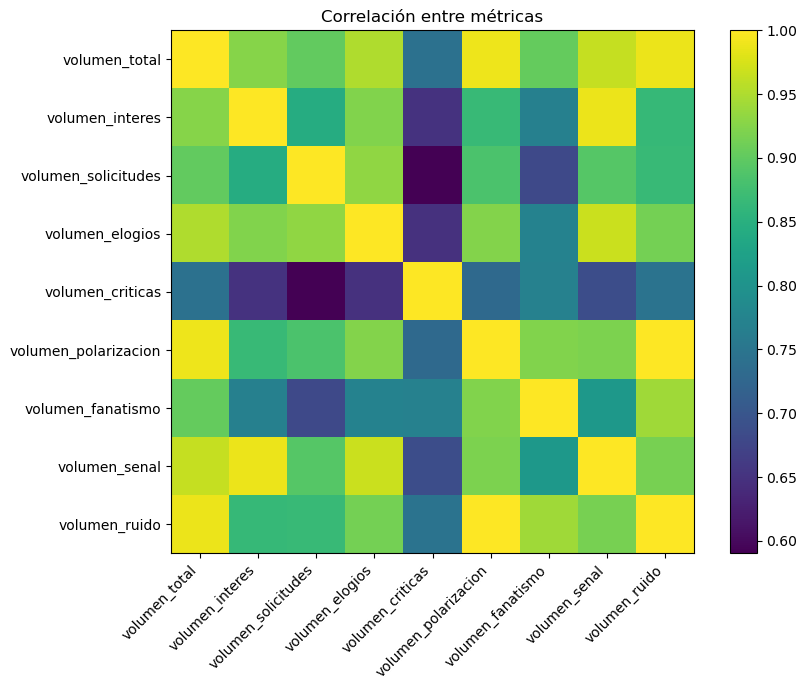

In [31]:
corr = df[metricas].corr()

fig, ax = plt.subplots(figsize=(9,7))

im = ax.imshow(corr)

ax.set_xticks(range(len(metricas)))
ax.set_yticks(range(len(metricas)))

ax.set_xticklabels(metricas, rotation=45, ha="right")
ax.set_yticklabels(metricas)

fig.colorbar(im)

plt.title("Correlación entre métricas")
plt.tight_layout()
plt.show()

In [32]:
display(corr.round(3))

,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_senal,volumen_ruido
volumen_total,1.000,0.925,0.901,0.951,0.743,0.990,0.903,0.964,0.988
volumen_interes,0.925,1.000,0.844,0.923,0.651,0.867,0.768,0.988,0.864
volumen_solicitudes,0.901,0.844,1.000,0.932,0.590,0.884,0.681,0.893,0.866
volumen_elogios,0.951,0.923,0.932,1.000,0.649,0.925,0.772,0.968,0.914
volumen_criticas,0.743,0.651,0.590,0.649,1.000,0.731,0.770,0.688,0.746
volumen_polarizacion,0.990,0.867,0.884,0.925,0.731,1.000,0.922,0.920,0.999
volumen_fanatismo,0.903,0.768,0.681,0.772,0.770,0.922,1.000,0.809,0.941
volumen_senal,0.964,0.988,0.893,0.968,0.688,0.920,0.809,1.000,0.916
volumen_ruido,0.988,0.864,0.866,0.914,0.746,0.999,0.941,0.916,1.000


**Correlaciones relevantes:**

- **Señal comercial ↔ Ruido social = 0.916**

Se observa una correlación positiva elevada entre ambas métricas. Sin embargo, en esta etapa no puede concluirse que publicaciones con mayor polarización política generen mayor interés comercial, ni que ocurra el fenómeno inverso. Una explicación plausible es que ambas variables estén influenciadas por un tercer factor: el volumen total de comentarios. Las publicaciones más virales tienden a acumular simultáneamente más comentarios comerciales y más comentarios de ruido. Será necesario analizar posteriormente las proporciones para evaluar si esta relación persiste al controlar el efecto del volumen. En ese contexto podrá explorarse con mayor fundamento si publicaciones con productos más atractivos generan simultáneamente mayor viralidad y mayor polarización, o si, por el contrario, publicaciones con temáticas más polémicas o emocionalmente gatillantes potencian la interacción general, incrementando tanto las manifestaciones de interés comercial como las reacciones ideológicas o emocionales.

- **Interés comercial ↔ Polarización política = 0.867**

También se observa una correlación elevada, cuya interpretación requiere la misma cautela. Por ahora, esta asociación no implica que la polarización favorezca el interés comercial, ya que ambas métricas podrían estar aumentando simplemente como consecuencia de una mayor cantidad de comentarios asociados a publicaciones más virales.

- **Críticas genuinas ↔ Fanatismo no comercial = 0.770**

Esta correlación moderadamente alta sugiere que las publicaciones que reciben un mayor número de críticas dirigidas al producto también tienden a concentrar una mayor carga emocional o fanatismo hacia lo que el producto representa. No obstante, será necesario verificar posteriormente si esta relación permanece al analizar las proporciones, reduciendo el efecto del volumen total de comentarios.

> **Nota:** Algunas correlaciones observadas son esperables debido a la propia construcción de las variables. Por ejemplo, `volumen_ruido` se define a partir de `volumen_polarizacion` y `volumen_fanatismo`, mientras que `volumen_senal` se construye utilizando `volumen_interes`, `volumen_elogios`, `volumen_criticas` y `volumen_solicitudes`. En consecuencia, las altas correlaciones entre estas métricas compuestas y sus componentes son triviales desde el punto de vista analítico y no aportan evidencia adicional sobre el comportamiento de las publicaciones.

#### Correlaciones en términos de Proporción

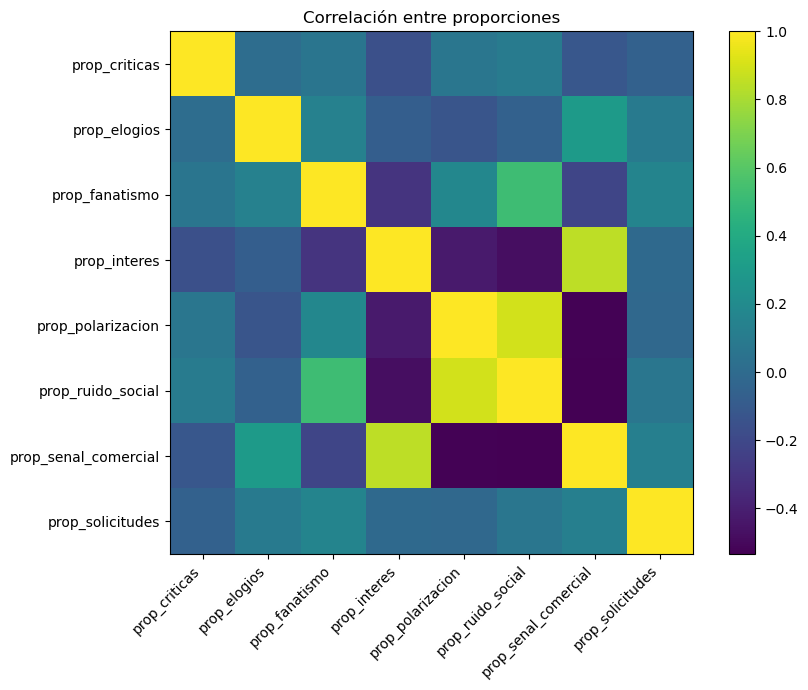

In [11]:
proporciones = sorted(
    [col for col in df.columns if col.startswith("prop_")]
)

corr_prop = df[proporciones].corr()

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(corr)

ax.set_xticks(range(len(proporciones)))
ax.set_yticks(range(len(proporciones)))

ax.set_xticklabels(proporciones, rotation=45, ha="right")
ax.set_yticklabels(proporciones)

fig.colorbar(im)

plt.title("Correlación entre proporciones")
plt.tight_layout()
plt.show()

In [12]:
display(corr_prop.round(3))

,prop_criticas,prop_elogios,prop_fanatismo,prop_interes,prop_polarizacion,prop_ruido_social,prop_senal_comercial,prop_solicitudes
prop_criticas,1.000,0.011,0.060,-0.160,0.067,0.105,-0.119,-0.055
prop_elogios,0.011,1.000,0.141,-0.076,-0.129,-0.055,0.301,0.098
prop_fanatismo,0.060,0.141,1.000,-0.301,0.178,0.522,-0.211,0.159
prop_interes,-0.160,-0.076,-0.301,1.000,-0.423,-0.480,0.847,-0.012
prop_polarizacion,0.067,-0.129,0.178,-0.423,1.000,0.893,-0.526,-0.014
prop_ruido_social,0.105,-0.055,0.522,-0.480,0.893,1.000,-0.534,0.069
prop_senal_comercial,-0.119,0.301,-0.211,0.847,-0.526,-0.534,1.000,0.129
prop_solicitudes,-0.055,0.098,0.159,-0.012,-0.014,0.069,0.129,1.000


**Correlaciones relevantes:**

- **Interés comercial ↔ Polarización política = -0.423**

A diferencia de la matriz construida sobre volúmenes, donde ambas variables presentaban una correlación positiva influenciada por la viralidad de las publicaciones, al analizar las proporciones se observa una correlación moderadamente negativa. Esto sugiere que, una vez controlado el efecto del tamaño de la publicación, aquellas cuya conversación está relativamente más dominada por comentarios conflictivos tienden a presentar una menor proporción de comentarios asociados a interés comercial genuino. Es importante mencionar que ambas categorías **no son mutuamente excluyentes**, por lo que esta asociación no implica una incompatibilidad entre ambas y deberá analizarse con mayor profundidad en etapas posteriores.

- **Elogios ↔ Críticas = 0.011**

Prácticamente no existe correlación entre ambas proporciones, lo que sugiere que un aumento en la proporción de elogios hacia un producto **no está asociada a una disminución (o aumento) sistemática de críticas** genuinas dentro de las publicaciones.

- **Solicitudes ↔ Interés comercial = -0.012**

La correlación prácticamente nula indica que ambas variables describen comportamientos distintos de los usuarios. Mientras `interes_real` representa comentarios asociados a una intención de compra o consulta comercial (precio, despacho, dimensiones, formas de pago, etc.), `solicitud_real` identifica principalmente propuestas de nuevos modelos, modificaciones o personalizaciones de productos. La ausencia de relación lineal sugiere que el interés por adquirir un producto y la generación de ideas o solicitudes de nuevos diseños, versiones o modificaciones constituyen dinámicas independientes dentro de las publicaciones.

> **Nota:** Otras correlaciones observadas responden principalmente a la forma en que fueron construidas las métricas. Por ejemplo, `prop_ruido_social` incorpora directamente `prop_polarizacion`, mientras que `prop_senal_comercial` se construye utilizando `prop_interes`, `prop_elogios`, `prop_criticas` y `prop_solicitudes`. Del mismo modo, algunas proporciones representan categorías conceptualmente opuestas que compiten por el mismo conjunto de comentarios. En consecuencia, dichas correlaciones resultan esperables y no constituyen evidencia suficiente para extraer conclusiones de negocio.

# Commercial Signal Analysis

Carga de datasets relevantes:

In [2]:
#A nivel de comentarios (~ 3000 filas):
df_comments = pd.read_parquet(r"data\gold\facebook_comments_gold_enriched.parquet")

#A nivel de post (~ 155 filas):
df = pd.read_parquet(r"data\gold\facebook_post_metrics.parquet")

## Evolución temporal

Esta sección tiene como objetivo analizar cómo han evolucionado las características del contenido publicado y la naturaleza de las interacciones generadas a lo largo del período estudiado.

A diferencia de los análisis anteriores, donde las publicaciones son evaluadas como observaciones independientes, el análisis temporal incorpora la dimensión cronológica para identificar posibles cambios en la composición del contenido, la distribución temática de las publicaciones y el comportamiento relativo entre señal comercial y ruido social.

Los análisis se realizan agrupando las publicaciones por período temporal y evaluando tanto métricas absolutas como proporciones normalizadas. El uso de proporciones permite distinguir cambios reales en la composición de la interacción de aquellos producidos únicamente por variaciones en el volumen de actividad.

En particular, se estudian tres dimensiones principales:

- **Evolución de la composición temática de las publicaciones:** permite observar cómo cambia la participación relativa de las distintas categorías temáticas detectadas por el clasificador, identificando posibles cambios en la estrategia o enfoque del contenido publicado.

- **Evolución de la composición de las interacciones:** analiza cómo varía la relación entre señal comercial y ruido social a través del tiempo, evaluando si la conversación generada por las publicaciones presenta cambios en su estructura relativa.

- **Evolución del rendimiento promedio por publicación:** estudia la magnitud promedio de interacciones comerciales y sociales generadas por cada publicación en distintos períodos, permitiendo comparar el desempeño del contenido independientemente de la cantidad total de publicaciones realizadas.

Este análisis corresponde a una etapa exploratoria, cuyo objetivo es identificar patrones temporales, cambios estructurales o períodos de comportamiento diferenciado que puedan ser investigados posteriormente mediante análisis segmentados o modelos estadísticos.

### Evolución acumulada de la composición temática de las publicaciones

**Descripción del análisis y objetivo del gráfico**

Este análisis busca explorar cómo ha cambiado la composición temática del contenido publicado a lo largo del período estudiado, identificando la evolución relativa de las principales categorías temáticas detectadas por el clasificador.

Para ello, se incorporó la fecha de creación de cada publicación desde el dataset a nivel de comentarios (`df_comments`), vinculándola mediante `post_id` al dataset de publicaciones (`df`). Posteriormente, las publicaciones fueron agrupadas mensualmente y clasificadas según las etiquetas temáticas disponibles:

- Carabineros.
- Ejército.
- FACH.
- Armada.
- PDI.
- Guerra del Pacífico.
- Personajes históricos.
- Otras temáticas.

La categoría "Otras" agrupa todas aquellas publicaciones que no pertenecen a ninguna de las categorías temáticas definidas.

El gráfico representa **proporciones acumuladas**, no volúmenes absolutos. Es decir, para cada punto temporal se calcula qué fracción del total histórico de publicaciones realizadas hasta ese momento corresponde a cada temática.

La utilización de proporciones acumuladas permite observar la evolución estructural del conjunto de publicaciones, reduciendo la influencia de fluctuaciones puntuales de actividad mensual y mostrando cómo cada temática va adquiriendo participación relativa dentro del universo total de contenido publicado.

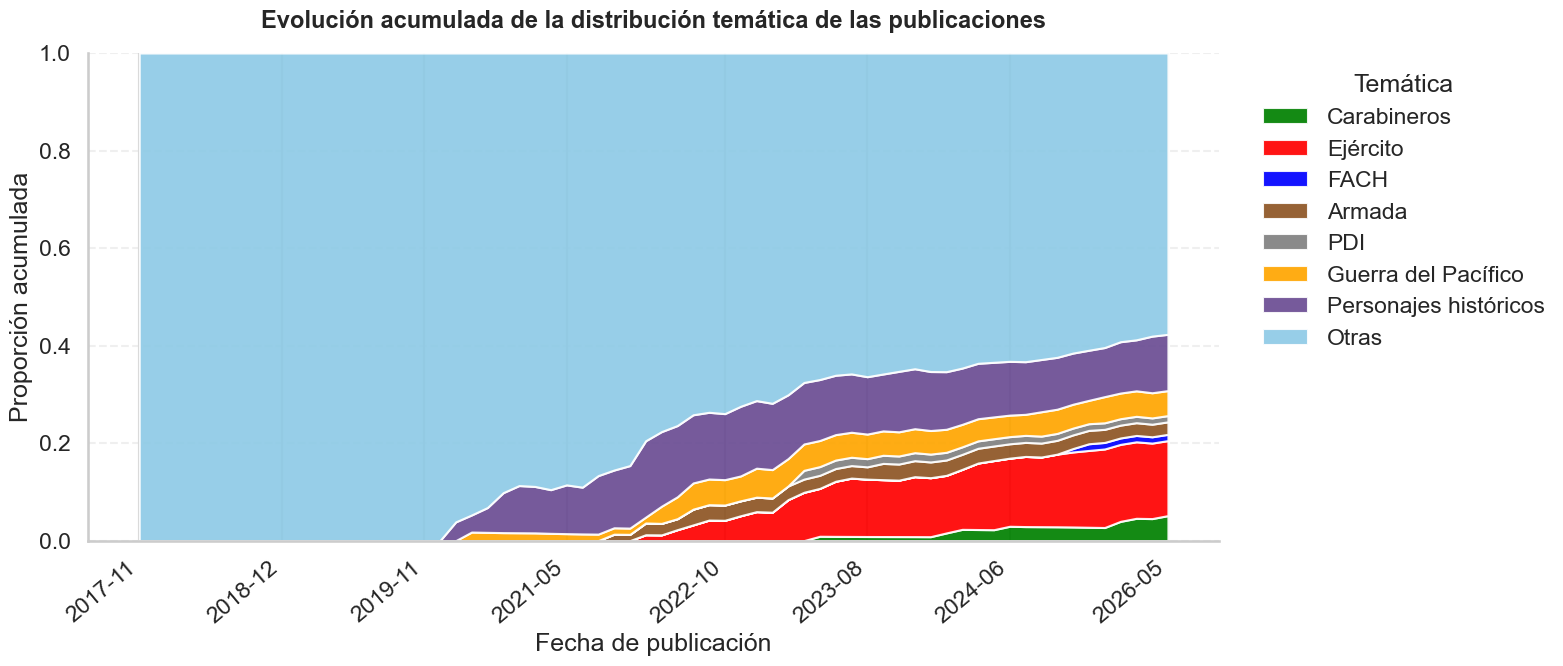

In [68]:
# ==================================================
# Estilo
# ==================================================

sns.set_theme(style="whitegrid", context="talk")

# ==================================================
# Temáticas
# ==================================================

tematicas = [
    "post_carabineros",
    "post_ejercito",
    "post_fach",
    "post_armada",
    "post_pdi",
    "post_guerra_pacifico",
    "post_personajes_historicos"
]

# ==================================================
# Incorporar fecha al dataset de publicaciones
# ==================================================

fechas = (
    df_comments[["post_id", "post_created"]]
    .drop_duplicates("post_id")
)

df_plot = df.merge(
    fechas,
    on="post_id",
    how="left"
)

df_plot["post_created"] = pd.to_datetime(
    df_plot["post_created"]
)

# Eliminar timezone antes de convertir a período mensual
df_plot["post_created"] = (
    df_plot["post_created"]
    .dt.tz_localize(None)
)

df_plot["periodo"] = (
    df_plot["post_created"]
    .dt.to_period("M")
)

# ==================================================
# Crear categoría "Otras"
# ==================================================

df_plot["otras_tematicas"] = (
    df_plot[tematicas].sum(axis=1) == 0
).astype(int)

columnas = tematicas + ["otras_tematicas"]

# ==================================================
# Conteos acumulados
# ==================================================

conteos = (
    df_plot
    .groupby("periodo")[columnas]
    .sum()
    .sort_index()
)

conteos_acumulados = conteos.cumsum()

# ==================================================
# Proporciones acumuladas
# ==================================================

proporciones = conteos_acumulados.div(
    conteos_acumulados.sum(axis=1),
    axis=0
)

proporciones.index = proporciones.index.astype(str)

# ==================================================
# Renombrar categorías
# ==================================================

proporciones = proporciones.rename(columns={
    "post_carabineros": "Carabineros",
    "post_ejercito": "Ejército",
    "post_fach": "FACH",
    "post_armada": "Armada",
    "post_pdi": "PDI",
    "post_guerra_pacifico": "Guerra del Pacífico",
    "post_personajes_historicos": "Personajes históricos",
    "otras_tematicas": "Otras"
})

# ==================================================
# Colores
# ==================================================

colores = [
    "green",        # Carabineros
    "red",          # Ejército
    "blue",         # FACH
    "#8d5524",      # Armada
    "grey",         # PDI
    "orange",       # Guerra del Pacífico
    "#6a4c93",      # Históricos
    "#8ecae6"       # Otras
]

# ==================================================
# Gráfico
# ==================================================

fig, ax = plt.subplots(figsize=(16,7))

ax.stackplot(
    range(len(proporciones)),
    proporciones.T.values,
    labels=proporciones.columns,
    colors=colores,
    alpha=0.92
)

# ==================================================
# Mostrar solo algunas fechas (evitar superposición)
# ==================================================

n = len(proporciones.index)

ticks = np.linspace(
    0,
    n-1,
    8,
    dtype=int
)

ticks = np.unique(ticks)

ax.set_xticks(ticks)

ax.set_xticklabels(
    proporciones.index[ticks],
    rotation=40,
    ha="right"
)

# ==================================================
# Estética
# ==================================================

ax.set_ylim(0,1)

ax.set_ylabel(
    "Proporción acumulada"
)

ax.set_xlabel(
    "Fecha de publicación"
)

ax.set_title(
    "Evolución acumulada de la distribución temática de las publicaciones",
    fontsize=17,
    weight="bold",
    pad=18
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Temática",
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    frameon=False
)

sns.despine()

plt.tight_layout()

plt.show()

> **Figura.** Evolución acumulada de la distribución temática de las publicaciones. El gráfico muestra la proporción acumulada de publicaciones pertenecientes a cada categoría temática a lo largo del período analizado. Cada área representa la participación relativa de una temática respecto del total de publicaciones realizadas hasta ese momento. La categoría "Otras" corresponde a publicaciones que no fueron clasificadas dentro de las temáticas específicas consideradas. Esta visualización permite observar cambios progresivos en la composición temática del contenido publicado, independientemente del volumen total de publicaciones realizadas en cada período.

**Interpretación de Evolución acumulada de la composición temática de las publicaciones**

* **Análisis de la Dinámica Temporal:** Desde finales de 2017 hasta mediados de 2020, la estrategia de contenidos estuvo monopolizada en un 100% por la categoría "Otras temáticas", mayormente relacionado a prototipado, videojuegos y personajes ficticios. A partir de la segunda mitad de 2020, se observa un cambio estructural drástico y deliberado en el pipeline de diseño: la introducción escalonada de modelos con temáticas institucionales e históricas. Al analizar el cierre temporal hacia 2026, estas nuevas temáticas ya representan más del **40% del total histórico** de los modelos publicados por la página.

* **Categorías con Crecimiento Sostenido y Mayor Producción:**
    * **Personajes Históricos (Morado):** Fue la primera temática en introducirse (2020) y es la que muestra la pendiente de crecimiento acumulado más constante y pronunciada a lo largo de los años. Es el pilar histórico de los nuevos diseños.
    * **Ejército (Rojo):** Introducido con fuerza a mediados de 2022, presenta un crecimiento agresivo y exponencial (un ensanchamiento rápido de la franja), consolidándose rápidamente como la segunda temática con mayor volumen de producción física de modelos hacia 2026.
    * **Guerra del Pacífico (Naranja):** Mantiene una tasa de adición de diseños constante y sostenida desde 2021, actuando como un conector temático estable dentro del portafolio.

* **Categorías con Desarrollo Marginal o Estancamiento:**
    * **FACH (Azul) y PDI (Gris):** Aunque aparecen en la matriz de producción (entre 2022 y 2023), sus franjas en el gráfico acumulado son sumamente delgadas y se mantienen planas a lo largo del tiempo. Esto indica que se lanzaron unos pocos diseños iniciales, pero **no se siguieron desarrollando de manera sistemática**.
    * **Armada (Marrón):** Tuvo una iteración de producción moderada entre 2022 y 2024, pero tras ese periodo la franja detiene su crecimiento relativo, sugiriendo una desaceleración en la creación de nuevos modelos bajo esta línea.
    * **Carabineros (Verde):** Es la temática institucional más tardía en ingresar de manera visible (2023-2024). Aunque mantiene una producción baja, muestra un ligero ensanchamiento hacia el final de la serie (2026), lo que podría indicar un interés incipiente por reactivar esta categoría en el mix de diseños.

### Evolución temporal de la composición entre señal comercial y ruido social

**Descripción del análisis y objetivo del gráfico**

Este análisis busca estudiar cómo cambia la calidad relativa de las interacciones generadas por las publicaciones a lo largo del tiempo, evaluando la relación entre contenido asociado a señal comercial y contenido clasificado como ruido social.

Para ello, se incorporó la fecha de creación de cada publicación mediante la relación entre el dataset de comentarios (`df_comments`) y el dataset agregado de publicaciones (`df`) utilizando `post_id`. Posteriormente, las publicaciones fueron agrupadas en períodos mensuales.

A diferencia de un análisis basado en volumen absoluto, esta visualización utiliza las variables:

- `prop_senal_comercial`
- `prop_ruido_social`

que representan proporciones normalizadas de cada publicación.

Para cada mes se calcula el **promedio de estas proporciones entre todas las publicaciones realizadas durante dicho período**. Por lo tanto, cada barra representa la composición promedio del contenido publicado en ese mes, independiente de la cantidad total de publicaciones realizadas.

El gráfico utiliza barras apiladas normalizadas al 100%, donde:

El segmento verde representa la proporción promedio de señal comercial.
El segmento gris representa la proporción promedio de ruido social.

Además, se incorpora una línea vertical discontinua en enero de 2019, utilizada como referencia temporal para marcar el inicio de una etapa donde comenzaron a incorporarse nuevas temáticas de publicación. Esta separación permite explorar si existe un cambio en el comportamiento del modelo o en la composición del contenido antes y después de dicho período.

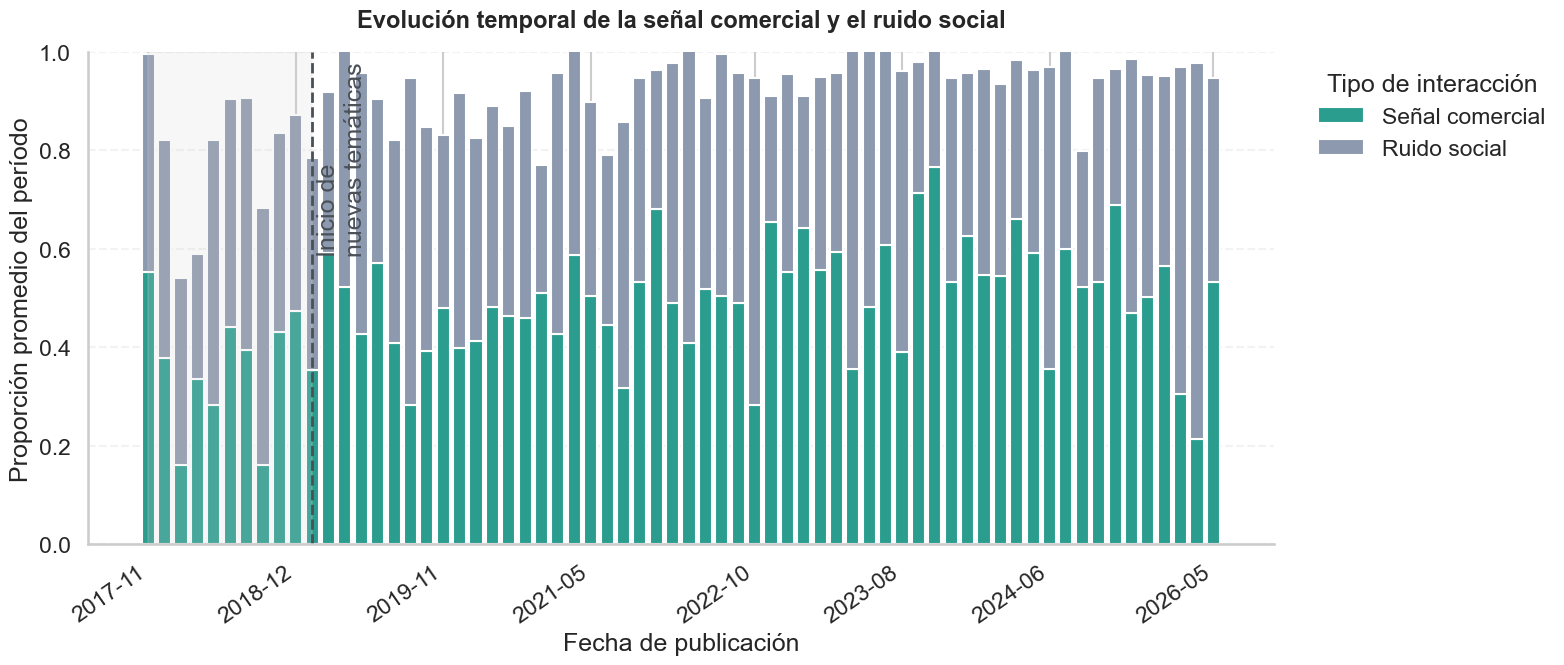

In [64]:
# ==================================================
# Estilo
# ==================================================

sns.set_theme(style="whitegrid", context="talk")

# ==================================================
# Incorporar fecha de publicación
# ==================================================

fechas = (
    df_comments[["post_id", "post_created"]]
    .drop_duplicates("post_id")
)

df_plot = df.merge(
    fechas,
    on="post_id",
    how="left"
)

df_plot["post_created"] = pd.to_datetime(
    df_plot["post_created"]
)

# Eliminar timezone antes de convertir a período mensual
df_plot["post_created"] = (
    df_plot["post_created"]
    .dt.tz_localize(None)
)

df_plot["periodo"] = (
    df_plot["post_created"]
    .dt.to_period("M")
)

# ==================================================
# Promedio mensual de proporciones
# ==================================================

evolucion = (
    df_plot
    .groupby("periodo")
    [
        [
            "prop_senal_comercial",
            "prop_ruido_social"
        ]
    ]
    .mean()
    .sort_index()
)

evolucion.index = evolucion.index.astype(str)

evolucion = evolucion.rename(columns={
    "prop_senal_comercial": "Señal comercial",
    "prop_ruido_social": "Ruido social"
})

# ==================================================
# Gráfico barras apiladas
# ==================================================

fig, ax = plt.subplots(figsize=(16,7))

x = np.arange(len(evolucion))

ax.bar(
    x,
    evolucion["Señal comercial"],
    color="#2A9D8F",
    label="Señal comercial"
)

ax.bar(
    x,
    evolucion["Ruido social"],
    bottom=evolucion["Señal comercial"],
    color="#8D99AE",
    label="Ruido social"
)

# ==================================================
# Línea vertical 2019
# ==================================================

if "2019-01" in evolucion.index:

    x_2019 = list(evolucion.index).index("2019-01")

    ax.axvspan(
        0,
        x_2019,
        color="lightgray",
        alpha=0.18
    )

    ax.axvline(
        x=x_2019,
        color="#495057",
        linestyle="--",
        linewidth=2
    )

    ax.text(
        x_2019 + 0.3,
        0.98,
        "Inicio de\nnuevas temáticas",
        rotation=90,
        va="top",
        fontsize=18,
        color="#495057"
    )

# ==================================================
# Eje X reducido
# ==================================================

n = len(evolucion.index)

ticks = np.linspace(
    0,
    n-1,
    8,
    dtype=int
)

ax.set_xticks(ticks)

ax.set_xticklabels(
    evolucion.index[ticks],
    rotation=35,
    ha="right"
)

# ==================================================
# Estética
# ==================================================

ax.set_ylim(0,1)

ax.set_ylabel(
    "Proporción promedio del período"
)

ax.set_xlabel(
    "Fecha de publicación"
)

ax.set_title(
    "Evolución temporal de la señal comercial y el ruido social",
    fontsize=17,
    weight="bold",
    pad=18
)

ax.legend(
    title="Tipo de interacción",
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    frameon=False
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()

plt.show()

> **Figura.** Evolución temporal de la composición entre señal comercial y ruido social. Cada barra representa la proporción promedio mensual de interacciones clasificadas como señal comercial y ruido social dentro de las publicaciones realizadas durante ese período. La altura total de cada barra corresponde al 100% de las interacciones consideradas, permitiendo comparar cambios en la composición relativa del contenido independientemente del volumen de publicaciones. La línea vertical discontinua indica enero de 2019, período utilizado como referencia para distinguir la incorporación de nuevas temáticas dentro del conjunto analizado.

**Interpretación de Evolución temporal de la composición entre señal comercial y ruido social (en término de proporciones)**

* **Estabilidad Estructural del Engagement:** A pesar del cambio radical en las temáticas de los diseños a partir de enero de 2019 (línea discontinua), la composición promedio *por publicación* ha mantenido una notable estabilidad a lo largo de los años. Salvo fluctuaciones puntuales, la relación oscila consistentemente en un rango de **40% a 60%** para ambas macro-categorías.
* **Resiliencia de la Señal Comercial:** El gráfico demuestra que la introducción de temáticas institucionales complejas no canibalizó el interés transaccional de la comunidad. Las publicaciones nuevas siguen reteniendo, en promedio, cerca de un 50% de comentarios asociados a intenciones de compra genuinas (precio, despacho, etc.), conviviendo en un equilibrio casi perfecto con el ruido social/político que estos mismos diseños gatillan.**

### Evolución temporal del volumen promedio de señal comercial y ruido social por publicación

**Descripción del análisis y objetivo del gráfico**

Este análisis busca evaluar cómo ha evolucionado el **rendimiento promedio de las publicaciones individuales** a lo largo del tiempo, diferenciando entre interacciones asociadas a señal comercial y aquellas clasificadas como ruido social.

A diferencia de una medición basada en volumen total acumulado, esta visualización controla por la cantidad de publicaciones realizadas en cada período. Para ello, se utilizan las métricas:

- volumen_senal
- volumen_ruido

calculadas previamente a nivel de publicación.

Las publicaciones fueron asociadas con su fecha de creación mediante la variable `post_id` y posteriormente agrupadas mensualmente. Para cada período se calculó el **promedio de interacciones generadas por publicación**, permitiendo comparar el desempeño individual del contenido independiente de la frecuencia de publicación.

El gráfico utiliza barras apiladas donde:

- El segmento verde representa el volumen promedio de interacciones clasificadas como señal comercial por publicación.
- El segmento gris representa el volumen promedio de interacciones clasificadas como ruido social por publicación.

La línea vertical discontinua corresponde a enero de 2019, fecha utilizada como referencia temporal debido a la incorporación de nuevas temáticas dentro del conjunto de publicaciones. Esta división permite explorar posibles cambios en el comportamiento del contenido y evaluar si la estructura de interacción presenta diferencias antes y después de este período.

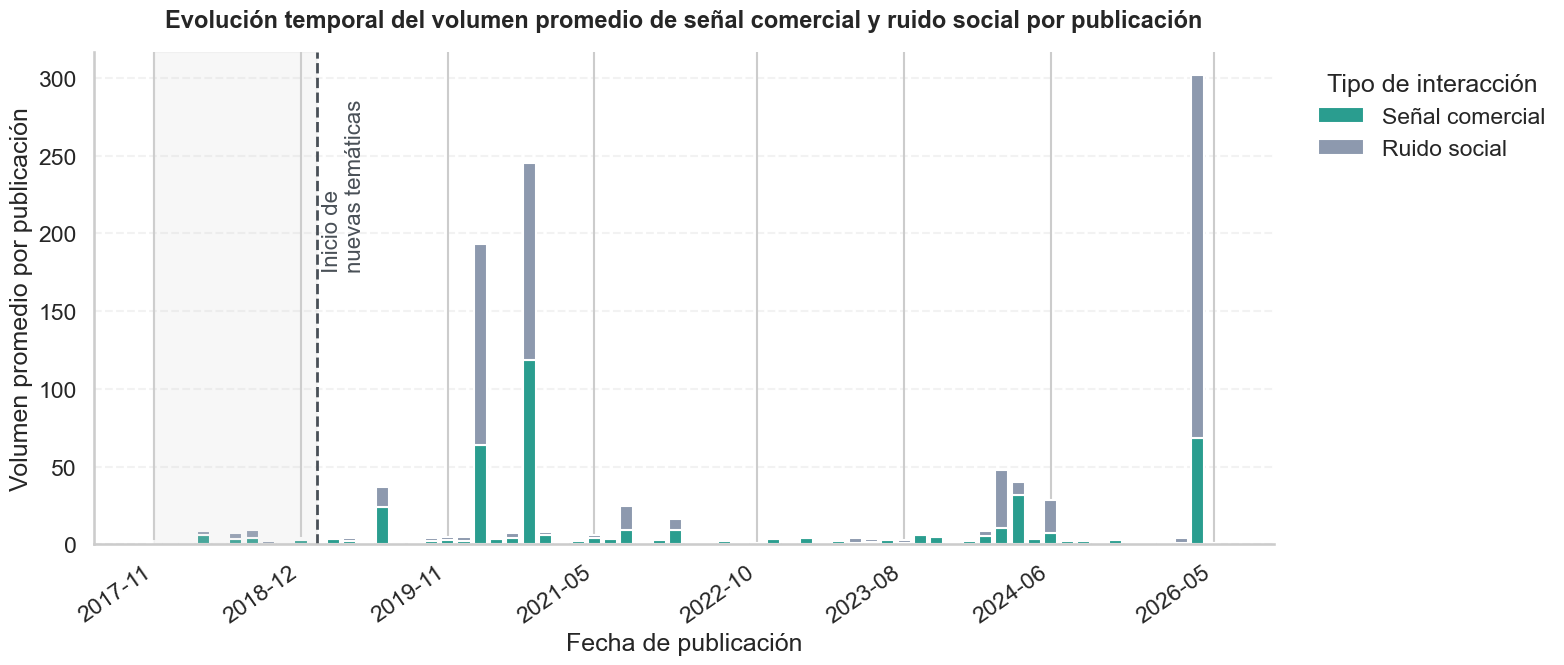

In [63]:
# ==================================================
# Estilo
# ==================================================

sns.set_theme(style="whitegrid", context="talk")

# ==================================================
# Incorporar fecha de publicación
# ==================================================

fechas = (
    df_comments[["post_id", "post_created"]]
    .drop_duplicates("post_id")
)

df_plot = df.merge(
    fechas,
    on="post_id",
    how="left"
)

df_plot["post_created"] = pd.to_datetime(
    df_plot["post_created"]
)

# Eliminar timezone antes de convertir a período mensual
df_plot["post_created"] = (
    df_plot["post_created"]
    .dt.tz_localize(None)
)

df_plot["periodo"] = (
    df_plot["post_created"]
    .dt.to_period("M")
)

# ==================================================
# Promedio mensual por publicación
# ==================================================

evolucion = (
    df_plot
    .groupby("periodo")
    [
        [
            "volumen_senal",
            "volumen_ruido"
        ]
    ]
    .mean()
    .sort_index()
)

evolucion.index = evolucion.index.astype(str)

evolucion = evolucion.rename(columns={
    "volumen_senal": "Señal comercial",
    "volumen_ruido": "Ruido social"
})

# ==================================================
# Gráfico barras apiladas
# ==================================================

fig, ax = plt.subplots(figsize=(16,7))

x = np.arange(len(evolucion))

ax.bar(
    x,
    evolucion["Señal comercial"],
    color="#2A9D8F",
    label="Señal comercial"
)

ax.bar(
    x,
    evolucion["Ruido social"],
    bottom=evolucion["Señal comercial"],
    color="#8D99AE",
    label="Ruido social"
)

# ==================================================
# Línea vertical 2019
# ==================================================

if "2019-01" in evolucion.index:

    x_2019 = list(evolucion.index).index("2019-01")

    ax.axvspan(
        0,
        x_2019,
        color="lightgray",
        alpha=0.18
    )

    ax.axvline(
        x=x_2019,
        color="#495057",
        linestyle="--",
        linewidth=2
    )

    ax.text(
        x_2019 + 0.3,
        evolucion.sum(axis=1).max() * 0.95,
        "Inicio de\nnuevas temáticas",
        rotation=90,
        va="top",
        fontsize=16,
        color="#495057"
    )

# ==================================================
# Eje X reducido
# ==================================================

n = len(evolucion.index)

ticks = np.linspace(
    0,
    n-1,
    8,
    dtype=int
)

ax.set_xticks(ticks)

ax.set_xticklabels(
    evolucion.index[ticks],
    rotation=35,
    ha="right"
)

# ==================================================
# Estética
# ==================================================

ax.set_ylabel(
    "Volumen promedio por publicación"
)

ax.set_xlabel(
    "Fecha de publicación"
)

ax.set_title(
    "Evolución temporal del volumen promedio de señal comercial y ruido social por publicación",
    fontsize=17,
    weight="bold",
    pad=18
)

ax.legend(
    title="Tipo de interacción",
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    frameon=False
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()

plt.show()

> **Figura**. Evolución temporal del volumen promedio de señal comercial y ruido social por publicación. Cada barra representa el número promedio mensual de interacciones clasificadas como señal comercial y ruido social generado por publicación. A diferencia de una métrica de volumen total, esta visualización normaliza por cantidad de publicaciones y permite comparar el desempeño individual del contenido entre distintos períodos. La línea vertical discontinua indica enero de 2019, utilizado como referencia temporal para analizar posibles cambios asociados a la incorporación de nuevas temáticas.

**Interpretación de Evolución temporal del volumen promedio de señal comercial y ruido social por publicación (en término de Volúmenes)**

* **Validación del Fenómeno de Alta Varianza (Leyes de Potencia):** Al contrastar este gráfico con el anterior, se revela la verdadera naturaleza de los datos: el rendimiento no es homogéneo. El volumen promedio por publicación se mantiene plano y cercano a cero durante la mayor parte del histórico de la página, pero es interrumpido por **picos masivos de tracción (outliers de diseño)**.
* **El Efecto "Mega-Viral":** Se identifican tres grandes hitos de viralidad extrema en la historia de la página (mediados de 2020, inicios de 2021 y el pico más alto hacia el cierre en 2026, superando los 300 comentarios promedio). 
* **Evidencia del Subsidio Algorítmico del Ruido:** En los momentos de máxima explosión de volumen, el crecimiento es traccionado principalmente por el **ruido social** (barra gris). Sin embargo, confirma plenamente la hipótesis de negocio: estos hitos de polémica masiva actúan como un imán que eleva en términos absolutos el volumen neto de **señal comercial** (barra verde alcanzando su máximo histórico en 2026). Pocos modelos logran romper el algoritmo, pero cuando lo hacen, multiplican exponencialmente la captura de leads.

## Personajes históricos

Durante el análisis preliminar por temáticas se observó que la categoría `post_personajes_historicos` concentraba gran parte de las publicaciones con mayor volumen de interacción, tanto en señal comercial como en ruido social. Sin embargo, esta etiqueta agrupa personajes con contextos históricos y niveles de controversia muy diferentes, por lo que su análisis conjunto puede ocultar patrones relevantes.


### Carga de dataset con personajes historicos desegregados

In [3]:
#Para retomar
df = pd.read_parquet(
    "data/gold/gold_post_personajes_historicos_analysis.parquet"
)

print(df.shape)
df.head()

(155, 38)


,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_fanatismo_no_comercial,...,post_personajes_historicos,post_pinochet,post_allende,post_prat,post_ohiggins,post_carrera,post_manuel_rodriguez,post_lautaro,post_neruda,post_mistral
0,154787275135903_1003489410265681,grumete de la marina chilena,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,154787275135903_1029896382473424,diseno 3d de mujer montanes del ejercito de ch...,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,154787275135903_1030709625725433,none,4,4,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,154787275135903_1033619428767786,diseno 3d en homenaje a pastelitodechile y agu...,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,154787275135903_1038284206786201,lautaro. 3d art mapuche chile 3dprinting,2,2,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0


### Estadísticas descriptivas

In [3]:
personajes = [
    "post_pinochet",
    "post_allende",
    "post_prat",
    "post_ohiggins",
    "post_carrera",
    "post_manuel_rodriguez",
    "post_lautaro",
    "post_neruda"
]

metricas = [
    "volumen_total",
    "volumen_interes",
    "volumen_elogios",
    "volumen_polarizacion",
    "volumen_fanatismo_no_comercial",
    "volumen_senal",
    "volumen_ruido",
    "prop_interes",
    "prop_elogios",
    "prop_polarizacion",
    "prop_fanatismo_no_comercial",
    "prop_senal_comercial",
    "prop_ruido_social"
]

for metrica in metricas:

    tabla = (
        pd.DataFrame({
            personaje: df.loc[df[personaje] == 1, metrica].describe()
            for personaje in personajes
        })
        .T
        .round(2)
    )

    print(f"\n{'='*80}")
    print(f"Estadística descriptiva por personaje histórico para '{metrica}'")
    print(f"{'='*80}")

    display(tabla)


Estadística descriptiva por personaje histórico para 'volumen_total'


,count,mean,std,min,25%,50%,75%,max
post_pinochet,6.0,330.50,303.65,18.0,93.25,270.0,518.75,789.0
post_allende,2.0,28.00,33.94,4.0,16.00,28.0,40.00,52.0
post_prat,3.0,9.67,3.51,6.0,8.00,10.0,11.50,13.0
post_ohiggins,1.0,12.00,NaN,12.0,12.00,12.0,12.00,12.0
post_carrera,4.0,4.75,3.30,1.0,3.25,4.5,6.00,9.0
post_manuel_rodriguez,1.0,6.00,NaN,6.0,6.00,6.0,6.00,6.0
post_lautaro,2.0,6.50,6.36,2.0,4.25,6.5,8.75,11.0
post_neruda,1.0,7.00,NaN,7.0,7.00,7.0,7.00,7.0



Estadística descriptiva por personaje histórico para 'volumen_interes'


,count,mean,std,min,25%,50%,75%,max
post_pinochet,6.0,71.50,49.83,3.0,39.25,82.0,93.25,140.0
post_allende,2.0,2.00,2.83,0.0,1.00,2.0,3.00,4.0
post_prat,3.0,5.33,1.15,4.0,5.00,6.0,6.00,6.0
post_ohiggins,1.0,5.00,NaN,5.0,5.00,5.0,5.00,5.0
post_carrera,4.0,3.25,2.22,1.0,1.75,3.0,4.50,6.0
post_manuel_rodriguez,1.0,5.00,NaN,5.0,5.00,5.0,5.00,5.0
post_lautaro,2.0,3.00,1.41,2.0,2.50,3.0,3.50,4.0
post_neruda,1.0,0.00,NaN,0.0,0.00,0.0,0.00,0.0



Estadística descriptiva por personaje histórico para 'volumen_elogios'


...

,count,mean,std,min,25%,50%,75%,max
post_pinochet,6.0,0.17,0.11,0.06,0.11,0.13,0.23,0.34
post_allende,2.0,0.12,0.08,0.07,0.09,0.12,0.15,0.17
post_prat,3.0,0.09,0.03,0.05,0.07,0.09,0.10,0.11
post_ohiggins,1.0,0.23,NaN,0.23,0.23,0.23,0.23,0.23
post_carrera,4.0,0.12,0.05,0.07,0.10,0.12,0.14,0.18
post_manuel_rodriguez,1.0,0.05,NaN,0.05,0.05,0.05,0.05,0.05
post_lautaro,2.0,0.06,0.04,0.03,0.05,0.06,0.08,0.09
post_neruda,1.0,0.15,NaN,0.15,0.15,0.15,0.15,0.15



Estadística descriptiva por personaje histórico para 'prop_senal_comercial'


,count,mean,std,min,25%,50%,75%,max
post_pinochet,6.0,0.36,0.15,0.20,0.25,0.34,0.48,0.55
post_allende,2.0,0.32,0.02,0.30,0.31,0.32,0.32,0.33
post_prat,3.0,0.68,0.12,0.55,0.62,0.70,0.74,0.79
post_ohiggins,1.0,0.41,NaN,0.41,0.41,0.41,0.41,0.41
post_carrera,4.0,0.68,0.10,0.53,0.64,0.71,0.74,0.77
post_manuel_rodriguez,1.0,0.68,NaN,0.68,0.68,0.68,0.68,0.68
post_lautaro,2.0,0.57,0.08,0.51,0.54,0.57,0.60,0.63
post_neruda,1.0,0.11,NaN,0.11,0.11,0.11,0.11,0.11



Estadística descriptiva por personaje histórico para 'prop_ruido_social'


,count,mean,std,min,25%,50%,75%,max
post_pinochet,6.0,0.58,0.17,0.38,0.44,0.57,0.72,0.78
post_allende,2.0,0.54,0.03,0.52,0.53,0.54,0.55,0.56
post_prat,3.0,0.32,0.11,0.23,0.26,0.29,0.36,0.43
post_ohiggins,1.0,0.44,NaN,0.44,0.44,0.44,0.44,0.44
post_carrera,4.0,0.30,0.09,0.22,0.23,0.28,0.35,0.41
post_manuel_rodriguez,1.0,0.18,NaN,0.18,0.18,0.18,0.18,0.18
post_lautaro,2.0,0.30,0.05,0.26,0.28,0.30,0.31,0.33
post_neruda,1.0,0.87,NaN,0.87,0.87,0.87,0.87,0.87


### Volumen promedio de señales de interés comercial
Este análisis busca comparar la capacidad de distintas figuras históricas para generar interacciones clasificadas como **señales de interés comercial**.

A diferencia del análisis basado en proporciones, esta visualización utiliza el volumen absoluto promedio de comentarios asociados a interés comercial por publicación. Esto permite evaluar la magnitud efectiva de la conversación generada por cada temática, considerando que una menor proporción de señal comercial no necesariamente implica un menor impacto comercial si la publicación alcanza niveles elevados de viralidad.

Para cada personaje histórico se calculó el promedio de la variable `volumen_interes`, considerando únicamente las publicaciones clasificadas dentro de cada categoría.

Debido a la distribución altamente asimétrica observada en las métricas de volumen, los resultados deben interpretarse considerando la existencia de publicaciones con comportamiento excepcionalmente viral. En particular, algunas figuras históricas presentan una capacidad de movilización de audiencia considerablemente superior al resto.

In [18]:
#Personajes históricos a evaluar:
personajes = [
    "post_pinochet",
    "post_allende",
    "post_prat",
    "post_ohiggins",
    "post_carrera",
    "post_manuel_rodriguez",
    "post_lautaro",
    "post_neruda"
]

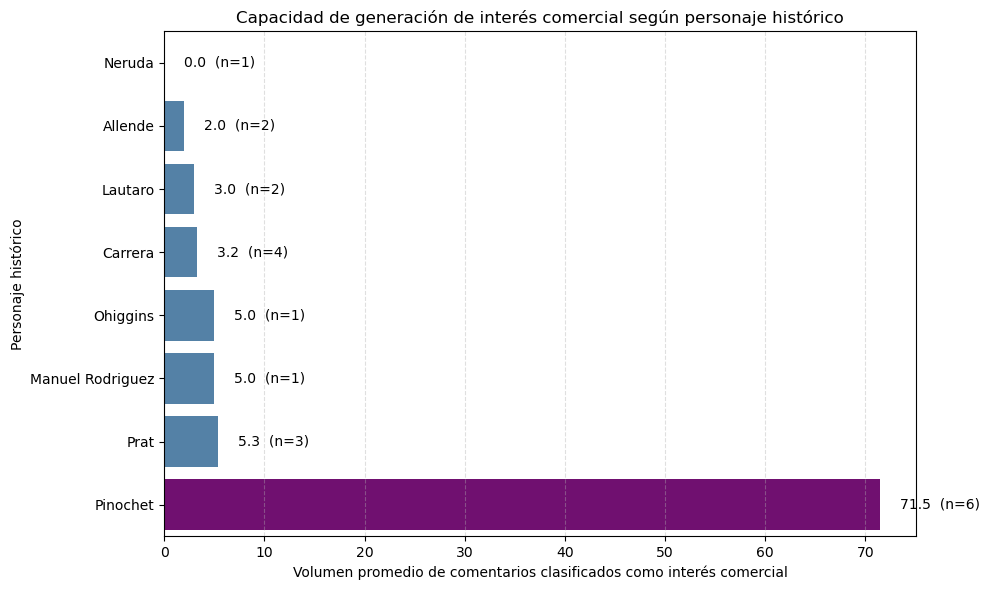

In [49]:
metrica = "volumen_interes"

# Crear tabla resumen
datos = []

for personaje in personajes:
    datos.append({
        "personaje": personaje.replace("post_", "").replace("_", " ").title(),
        "promedio_interes": df.loc[df[personaje] == 1, metrica].mean(),
        "n_publicaciones": (df[personaje] == 1).sum()
    })

tabla_interes = pd.DataFrame(datos)

# Ordenar
tabla_interes = tabla_interes.sort_values(
    "promedio_interes",
    ascending=True
)


# Colores personalizados
colores = {
    personaje: "purple" if personaje.lower() == "pinochet" else "steelblue"
    for personaje in tabla_interes["personaje"]
}


# -----------------------------
# Gráfico
# -----------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    data=tabla_interes,
    x="promedio_interes",
    y="personaje",
    hue="personaje",
    palette=colores,
    legend=False
)


# Etiquetas con promedio + n
for i, row in tabla_interes.reset_index(drop=True).iterrows():
    plt.text(
        row["promedio_interes"] + 2,
        i,
        f'{row["promedio_interes"]:.1f}  (n={int(row["n_publicaciones"])})',
        va="center",
        fontsize=10
    )


plt.xlabel("Volumen promedio de comentarios clasificados como interés comercial")
plt.ylabel("Personaje histórico")
plt.title(
    "Capacidad de generación de interés comercial según personaje histórico"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

>**Figura.** Volumen promedio de comentarios clasificados como señales de interés comercial por personaje histórico. Cada barra representa el promedio de interacciones comerciales generadas por publicación dentro de cada categoría. Se destaca en color morado la categoría asociada a Augusto Pinochet debido a su comportamiento diferencial en términos de volumen absoluto. Los valores deben interpretarse considerando el reducido número de publicaciones disponibles por categoría y la alta dispersión característica de las métricas de interacción.

**Interpretación** Asimetría Extrema de Volumen (Efecto Outlier): El gráfico confirma visualmente que la media agregada de la categoría estaba distorsionada por completo. Mientras que la gran mayoría de los personajes históricos (Prat, Carrera, Lautaro, Rodríguez, etc.) promedian entre 0 y 5.3 comentarios de interés comercial por publicación, las publicaciones asociadas a Augusto Pinochet promedian 71.5 comentarios, superando por más de un orden de magnitud a cualquier otra figura del dataset.

**Volumen promedio de interés comercial y ruido social:**

La siguiente visualización amplía el análisis anterior de volumen promedio de interés comercial incorporando **simultáneamente el volumen de ruido social** generado por cada personaje histórico.

A diferencia de la versión anterior, donde únicamente se observaba la capacidad de generar señales comerciales, este gráfico permite evaluar la magnitud total de la conversación generada y distinguir qué parte corresponde a interacciones potencialmente comerciales y qué parte corresponde a conversación social no comercial.

El objetivo es analizar el equilibrio entre alcance absoluto y composición de la interacción, evitando interpretar una mayor presencia de ruido social como necesariamente negativa desde una perspectiva comercial.

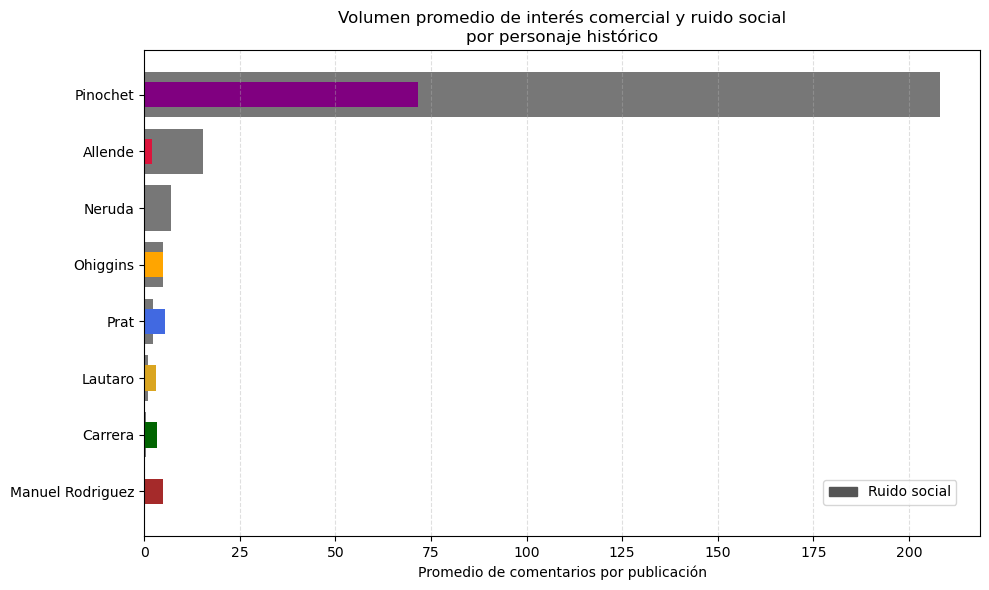

In [19]:
# Métricas utilizadas
metrica_interes_personajes = "volumen_interes"
metrica_ruido_personajes = "volumen_ruido"


# Colores personalizados para personajes
colores_personajes_hist = {
    "post_pinochet": "purple",
    "post_allende": "crimson",
    "post_prat": "royalblue",
    "post_carrera": "darkgreen",
    "post_ohiggins": "orange",
    "post_manuel_rodriguez": "brown",
    "post_lautaro": "goldenrod",
    "post_neruda": "teal"
}


# Construcción del dataframe para visualización
datos_personajes_hist = []

for personaje in personajes:
    df_personaje_hist = df[df[personaje] == 1]
    
    datos_personajes_hist.append({
        "personaje": personaje.replace("post_", "").replace("_", " ").title(),
        "interes": df_personaje_hist[metrica_interes_personajes].mean(),
        "ruido": df_personaje_hist[metrica_ruido_personajes].mean()
    })


df_plot_personajes_hist = pd.DataFrame(datos_personajes_hist)


# Ordenar por ruido social dominante
df_plot_personajes_hist = (
    df_plot_personajes_hist
    .sort_values(
        "ruido",
        ascending=True
    )
)


# ============================
# Gráfico final
# ============================

fig_personajes_interes_ruido, ax_personajes_interes_ruido = plt.subplots(
    figsize=(10,6)
)


y_personajes = range(len(df_plot_personajes_hist))


# Barras de ruido social (fondo)
ax_personajes_interes_ruido.barh(
    y_personajes,
    df_plot_personajes_hist["ruido"],
    color="#555555",
    alpha=0.8,
    label="Ruido social"
)


# Barras de interés comercial superpuestas
for i, row in df_plot_personajes_hist.iterrows():
    
    personaje_key_hist = (
        "post_" + 
        row["personaje"].lower().replace(" ", "_")
    )
    
    ax_personajes_interes_ruido.barh(
        list(df_plot_personajes_hist.index).index(i),
        row["interes"],
        color=colores_personajes_hist.get(
            personaje_key_hist,
            "gray"
        ),
        height=0.45,
        label=row["personaje"]
    )


# Etiquetas
ax_personajes_interes_ruido.set_yticks(y_personajes)

ax_personajes_interes_ruido.set_yticklabels(
    df_plot_personajes_hist["personaje"]
)


ax_personajes_interes_ruido.set_xlabel(
    "Promedio de comentarios por publicación"
)


ax_personajes_interes_ruido.set_title(
    "Volumen promedio de interés comercial y ruido social\n"
    "por personaje histórico"
)


ax_personajes_interes_ruido.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)


# Leyenda solamente para ruido social
handles_personajes = [
    plt.Rectangle((0,0),1,1,color="#555555")
]

labels_personajes = [
    "Ruido social"
]


ax_personajes_interes_ruido.legend(
    handles_personajes,
    labels_personajes,
    loc="lower right",
    bbox_to_anchor=(0.98,0.05)
)


plt.tight_layout()

plt.show()

>**Figura. Volumen promedio de interés comercial y ruido social por personaje histórico.**
La figura representa el número promedio de comentarios generados por publicación para cada personaje histórico identificado. Las barras grises corresponden al volumen promedio de ruido social, mientras que las barras coloreadas representan el volumen promedio de comentarios clasificados como señal de interés comercial.
La visualización permite observar que algunas temáticas generan conversaciones de gran magnitud debido a su capacidad de viralización, aunque una fracción importante de dichas interacciones corresponda a debate social o político. En particular, las publicaciones asociadas a Pinochet presentan una escala de interacción considerablemente superior al resto de personajes históricos, generando simultáneamente mayores volúmenes absolutos de interés comercial y ruido social.
Por lo tanto, el gráfico complementa el análisis basado en proporciones, mostrando que una menor eficiencia relativa de la conversación no implica necesariamente un menor impacto comercial absoluto. La viralidad puede aumentar tanto la cantidad de interacciones no comerciales como la cantidad total de potenciales clientes capturados.

### Volumen promedio de elogios al producto por personaje histórico

Este análisis busca complementar la evaluación de señal comercial mediante una métrica más específica asociada a una interacción de mayor calidad: los elogios explícitos hacia el producto/diseño.

A diferencia de la métrica de interés comercial general, que incorpora señales como consultas sobre disponibilidad, precio, dimensiones o intención potencial de compra, los elogios representan usuarios que manifiestan una valoración positiva del producto, su diseño, fabricación o representación visual.

El gráfico muestra el volumen promedio de comentarios clasificados como elogios al producto por publicación para cada personaje histórico identificado dentro del dataset.

Al igual que en análisis anteriores, se utilizan volúmenes absolutos, ya que el objetivo es evaluar la capacidad real de cada temática para generar interacciones positivas hacia el producto, considerando tanto la eficiencia de la conversación como el alcance generado por la publicación.

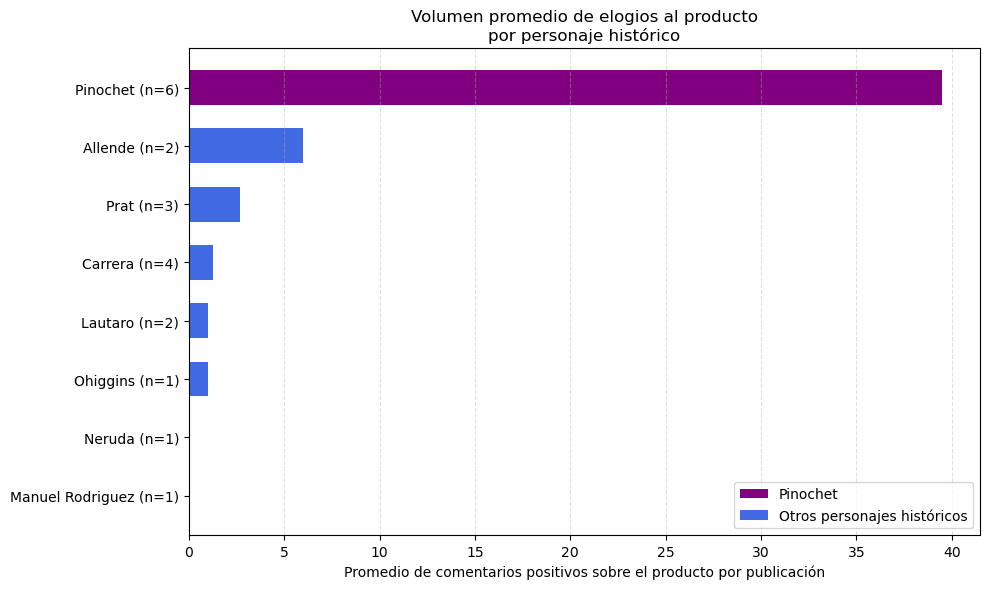

In [52]:
# Métrica
metrica = "volumen_elogios"

# Construcción dataframe
datos = []

for personaje in personajes:
    df_personaje = df[df[personaje] == 1]
    
    datos.append({
        "personaje": personaje.replace("post_", "").replace("_", " ").title(),
        "elogios": df_personaje[metrica].mean(),
        "n": len(df_personaje)
    })

df_plot = pd.DataFrame(datos)

# Ordenar
df_plot = df_plot.sort_values("elogios", ascending=True)

# Etiquetas con n
df_plot["label"] = (
    df_plot["personaje"] + 
    " (n=" + 
    df_plot["n"].astype(str) + 
    ")"
)

# ============================
# Gráfico
# ============================

fig, ax = plt.subplots(figsize=(10,6))

colores = [
    "purple" if personaje.lower() == "pinochet" else "royalblue"
    for personaje in df_plot["personaje"]
]

ax.barh(
    df_plot["label"],
    df_plot["elogios"],
    color=colores,
    height=0.6
)

ax.set_xlabel(
    "Promedio de comentarios positivos sobre el producto por publicación"
)

ax.set_title(
    "Volumen promedio de elogios al producto\npor personaje histórico"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

legend_elements = [
    Patch(facecolor="purple", label="Pinochet"),
    Patch(facecolor="royalblue", label="Otros personajes históricos")
]

ax.legend(
    handles=legend_elements,
    loc="lower right"
)

plt.tight_layout()
plt.show()

> Figura. Volumen promedio de elogios al producto por personaje histórico.
Se representa el promedio de comentarios clasificados como elogios al producto generados por publicación para cada personaje histórico identificado. La métrica busca medir la capacidad de cada temática para generar valoración positiva explícita hacia el producto, diferenciándola de otras formas de interacción como consultas comerciales o ruido social. Los resultados muestran una fuerte concentración de elogios en publicaciones asociadas a Augusto Pinochet, mientras que Salvador Allende presenta un aumento relativo al considerar únicamente esta señal positiva, superando a otras figuras históricas pese a generar menor volumen total de interacción comercial. Las categorías con bajo número de publicaciones deben interpretarse con cautela debido a la limitada cantidad de observaciones disponibles.

**Observación:** El comportamiento mantiene un patrón similar al observado para la señal comercial general, donde las publicaciones asociadas a *Augusto Pinochet* concentran los mayores niveles de interacción positiva hacia el producto.

Sin embargo, al analizar exclusivamente los elogios, aparecen diferencias relevantes respecto al análisis basado únicamente en volumen de interés comercial.

Aunque las publicaciones sobre *Salvador Allende* presentaban niveles relativamente bajos de interés comercial total, al aislar únicamente los comentarios de valoración positiva del producto ascienden significativamente dentro del ranking, posicionándose como la **segunda temática con mayor volumen promedio de elogios**.

Esto sugiere que, si bien las publicaciones asociadas a Allende generan una menor cantidad absoluta de potenciales compradores respecto a otras temáticas, una fracción relevante de los usuarios que interactúan con estas publicaciones manifiesta una apreciación positiva hacia la pieza o el diseño.

Un caso particularmente llamativo corresponde a *Pablo Neruda*, quien en este análisis no genera elogios ni señales de interés comercial, concentrando prácticamente toda su interacción en ruido social. Debido al reducido número de publicaciones asociadas a esta categoría, este resultado debe interpretarse con cautela, pero representa un caso interesante para explorar cómo determinadas figuras pueden activar conversaciones completamente desvinculadas del objetivo comercial.

### Eficiencia relativa de generación de interés comercial según personaje histórico 

**Proporciones promedio de interés comercial**


Este análisis busca comparar la composición relativa de las interacciones generadas por publicaciones asociadas a distintos personajes históricos, evaluando qué proporción de la conversación corresponde a señales clasificadas como interés comercial.

A diferencia del análisis basado en volúmenes absolutos, esta visualización utiliza la métrica:

- `prop_interes`

la cual representa la fracción de comentarios asociados a potencial interés comercial respecto al total de interacciones generadas por cada publicación.

Para cada personaje histórico se calcula el promedio de esta proporción considerando únicamente las publicaciones donde dicho personaje fue identificado. Además, se incorpora el número de publicaciones analizadas (n) para contextualizar la robustez de cada estimación.

El objetivo es evaluar la **calidad relativa o eficiencia de la conversación generada**, independiente del tamaño total del evento de interacción. De esta forma, un valor elevado indica que una mayor proporción de los comentarios generados corresponde a señales comerciales, mientras que un valor bajo indica una mayor presencia relativa de otros tipos de interacción, como polarización política, debate social u otras formas de ruido.

Esta métrica debe interpretarse complementariamente con los análisis de volumen absoluto. Una mayor eficiencia relativa no implica necesariamente un mayor impacto comercial total, ya que una publicación con menor proporción de señal puede generar un número absoluto superior de potenciales clientes si alcanza niveles significativamente mayores de viralidad.

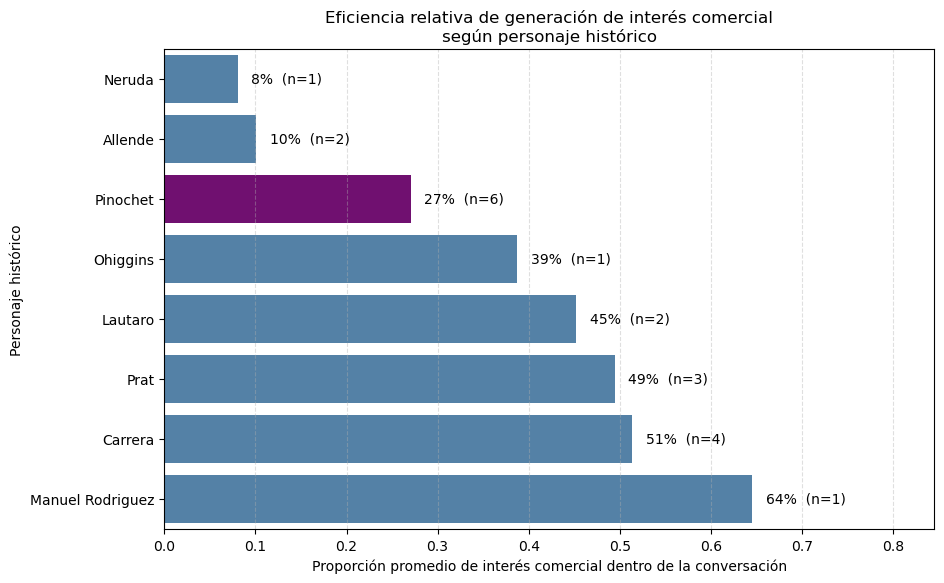

In [59]:
metrica = "prop_interes"

# Crear tabla resumen
datos = []

for personaje in personajes:
    datos.append({
        "personaje": personaje.replace("post_", "").replace("_", " ").title(),
        "promedio_proporcion": df.loc[df[personaje] == 1, metrica].mean(),
        "n_publicaciones": (df[personaje] == 1).sum()
    })

tabla_prop = pd.DataFrame(datos)

# Ordenar
tabla_prop = tabla_prop.sort_values(
    "promedio_proporcion",
    ascending=True
)


# Colores personalizados
colores = {
    personaje: "purple" if personaje.lower() == "pinochet" else "steelblue"
    for personaje in tabla_prop["personaje"]
}


# -----------------------------
# Gráfico
# -----------------------------

fig, ax = plt.subplots(figsize=(11,6))


sns.barplot(
    data=tabla_prop,
    x="promedio_proporcion",
    y="personaje",
    hue="personaje",
    palette=colores,
    legend=False,
    ax=ax
)


# Etiquetas con porcentaje + n
for i, row in tabla_prop.reset_index(drop=True).iterrows():
    ax.text(
        row["promedio_proporcion"] + 0.015,
        i,
        f'{row["promedio_proporcion"]:.0%}  (n={int(row["n_publicaciones"])})',
        va="center",
        fontsize=10
    )


ax.set_xlabel(
    "Proporción promedio de interés comercial dentro de la conversación"
)

ax.set_ylabel(
    "Personaje histórico"
)

ax.set_title(
    "Eficiencia relativa de generación de interés comercial\nsegún personaje histórico"
)


ax.set_xlim(
    0,
    min(1, tabla_prop["promedio_proporcion"].max() + 0.20)
)


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)


# Ajuste manual para evitar warning
plt.subplots_adjust(
    left=0.25,
    right=0.95,
    top=0.90,
    bottom=0.10
)

plt.show()

>Figura. Proporción promedio de señal de interés comercial generada por publicaciones asociadas a personajes históricos.
La figura muestra la fracción promedio de interacciones clasificadas como interés comercial dentro del conjunto total de comentarios generados por cada personaje histórico. Los valores representan la composición relativa de la conversación, permitiendo comparar qué temáticas producen interacciones más enfocadas en el producto. Se observa que personajes como Arturo Prat, José Miguel Carrera y Manuel Rodríguez presentan una mayor eficiencia relativa, con una conversación proporcionalmente más orientada hacia señales comerciales. En contraste, personajes asociados a alta carga política, como Augusto Pinochet y Salvador Allende, presentan una menor proporción de señal comercial debido a una mayor participación relativa de interacciones polarizadas y ruido social. Sin embargo, estos resultados deben interpretarse junto con los volúmenes absolutos, ya que una menor proporción de señal no implica necesariamente menor capacidad de generación de potenciales clientes cuando la publicación alcanza niveles elevados de viralidad.

**Interpretación:** Este gráfico pone de manifiesto que los personajes menos conflictivos u orientados a la identidad patria tradicional (Manuel Rodríguez con 64%, José Miguel Carrera con 51% y Arturo Prat con 49%) presentan conversaciones proporcionalmente más "limpias" y enfocadas en el producto. En contraste, Pinochet (27%) y Allende (10%) exhiben las menores proporciones de interés comercial de la muestra (excluyendo el caso único de Neruda), reflejando el predominio de la discusión ideológica sobre la conversación transaccional. Resulta particularmente llamativa la paradoja de Pinochet: aunque es, por amplio margen, el personaje que genera el mayor volumen absoluto de señales de interés comercial, al analizar la eficiencia relativa de la conversación aparece en la antepenúltima posición. Este contraste ilustra claramente que una elevada capacidad para atraer interacción comercial en términos absolutos no implica necesariamente una alta proporción de conversación orientada al producto, ni viceversa.

El siguiente gráfico muestra la composición relativa de la conversación asociada a cada personaje histórico, comparando la proporción de interacciones clasificadas como interés comercial y ruido social.

Debido a que ambas métricas representan componentes mutuamente excluyentes del total de interacciones, esta visualización se utiliza principalmente como apoyo descriptivo para observar diferencias generales en la composición de la conversación entre personajes.

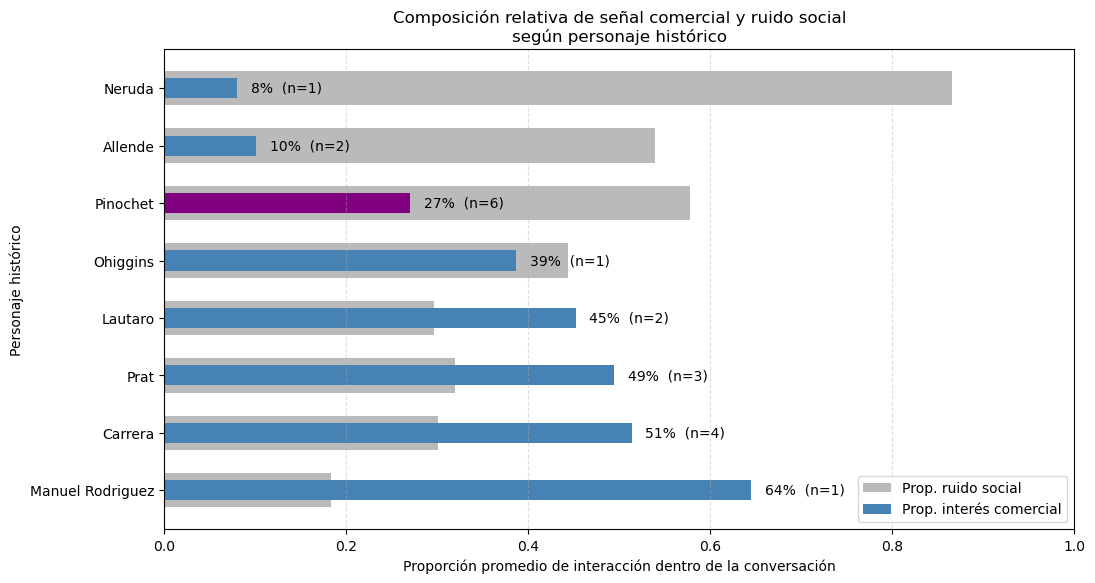

In [4]:
# Métricas
metrica_senal = "prop_interes"
metrica_ruido = "prop_ruido_social"

# Crear tabla resumen
datos = []

for personaje in personajes:
    df_personaje = df[df[personaje] == 1]
    
    datos.append({
        "personaje": personaje.replace("post_", "").replace("_", " ").title(),
        "senal": df_personaje[metrica_senal].mean(),
        "ruido": df_personaje[metrica_ruido].mean(),
        "n_publicaciones": len(df_personaje)
    })

tabla_prop = pd.DataFrame(datos)


# Ordenar por señal comercial (mayor arriba)
tabla_prop = tabla_prop.sort_values(
    "senal",
    ascending=False
)


# Colores
colores_senal = [
    "purple" if personaje.lower() == "pinochet" else "steelblue"
    for personaje in tabla_prop["personaje"]
]


# -----------------------------
# Gráfico
# -----------------------------

fig, ax = plt.subplots(figsize=(13,6))


# Barras de ruido (fondo)
ax.barh(
    tabla_prop["personaje"],
    tabla_prop["ruido"],
    color="darkgray",
    alpha=0.8,
    height=0.6,
    label="Prop. ruido social"
)


# Barras de señal comercial encima
ax.barh(
    tabla_prop["personaje"],
    tabla_prop["senal"],
    color=colores_senal,
    height=0.35,
    label="Prop. interés comercial"
)


# Etiquetas
for i, row in tabla_prop.reset_index(drop=True).iterrows():
    
    ax.text(
        row["senal"] + 0.015,
        i,
        f'{row["senal"]:.0%}  (n={int(row["n_publicaciones"])})',
        va="center",
        fontsize=10
    )


# Configuración
ax.set_xlabel(
    "Proporción promedio de interacción dentro de la conversación"
)

ax.set_ylabel(
    "Personaje histórico"
)

ax.set_title(
    "Composición relativa de señal comercial y ruido social\nsegún personaje histórico"
)


ax.set_xlim(
    0,
    min(1, tabla_prop[["senal","ruido"]].max().max() + 0.15)
)


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)


ax.legend(
    loc="lower right"
)


plt.subplots_adjust(
    left=0.25,
    right=0.95,
    top=0.90,
    bottom=0.10
)

plt.show()

>**Figura. Composición relativa de la interacción según personaje histórico.**
Las barras grises representan la proporción promedio de comentarios clasificados como ruido social, mientras que las barras coloreadas representan la proporción promedio de comentarios asociados a interés comercial. La métrica refleja la distribución interna de la conversación y no el volumen total generado, permitiendo comparar la "limpieza" relativa de la interacción entre personajes independientemente de su alcance absoluto.

### Proporción vs Volúmen promedio de señal comercial

**Impacto absoluto y eficiencia relativa de la generación de interés comercial por personaje histórico**

Este análisis busca comparar dos dimensiones complementarias del comportamiento comercial asociado a cada personaje histórico: la magnitud absoluta de interés generado y la proporción relativa de interés dentro de la conversación total.

Para ello, se contrastan dos métricas calculadas a nivel de publicación:

- Volumen promedio de interés comercial (`volumen_interes`): representa la cantidad promedio de comentarios clasificados como señales de interés comercial generadas por una publicación asociada a cada personaje.
- Proporción promedio de interés comercial (`prop_interes`): representa qué fracción de la conversación total corresponde a señales de interés comercial, independiente del tamaño o viralidad de la publicación.

La visualización combina ambas perspectivas mediante una representación superpuesta:

- Las barras grises de fondo representan el **volumen absoluto promedio de interés comercial**, reflejando la capacidad de cada personaje para generar interacción comercial en términos reales.
- Las barras coloreadas representan la **proporción relativa de interés comercial**, mostrando qué tan concentrada en producto se encuentra la conversación generada.

Esta comparación permite diferenciar entre contenidos con una conversación altamente eficiente pero de bajo alcance, y contenidos que, aunque presentan una mayor presencia relativa de ruido social, logran capturar un volumen absoluto superior de potenciales clientes.

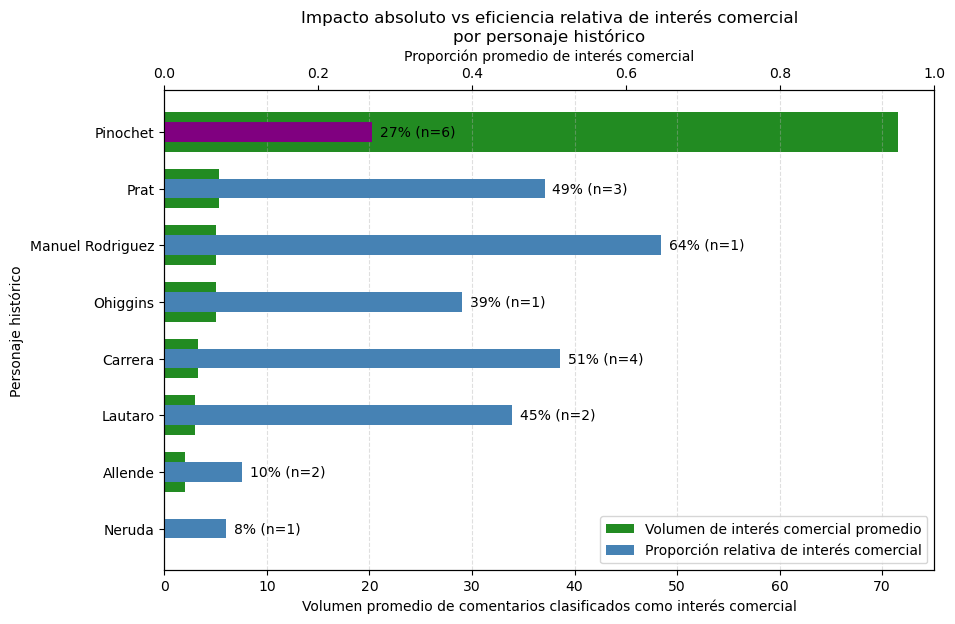

In [21]:
# Métricas utilizadas
metrica_volumen_personajes = "volumen_interes"
metrica_proporcion_personajes = "prop_interes"


# Crear tabla resumen
datos_personajes_impacto = []


for personaje in personajes:
    
    df_personaje_impacto = df[df[personaje] == 1]
    
    datos_personajes_impacto.append({
        "personaje": personaje.replace("post_", "").replace("_", " ").title(),
        "volumen_interes": df_personaje_impacto[metrica_volumen_personajes].mean(),
        "prop_interes": df_personaje_impacto[metrica_proporcion_personajes].mean(),
        "n_publicaciones": len(df_personaje_impacto)
    })


tabla_personajes_impacto = pd.DataFrame(
    datos_personajes_impacto
)


# Ordenar por volumen absoluto de interés
tabla_personajes_impacto = (
    tabla_personajes_impacto
    .sort_values(
        "volumen_interes",
        ascending=True
    )
)


# -----------------------------
# Gráfico
# -----------------------------

fig_personajes_impacto, ax_personajes_impacto = plt.subplots(
    figsize=(11,6)
)


# Colores personajes
colores_personajes_impacto = [
    "purple" 
    if personaje.lower() == "pinochet" 
    else "steelblue"
    for personaje in tabla_personajes_impacto["personaje"]
]


# Fondo: volumen absoluto de interés
ax_personajes_impacto.barh(
    tabla_personajes_impacto["personaje"],
    tabla_personajes_impacto["volumen_interes"],
    color="forestgreen",
    alpha=1.0,
    height=0.7,
    label="Volumen promedio de interés"
)


# Eje secundario para proporción
ax_personajes_prop = ax_personajes_impacto.twiny()


ax_personajes_prop.barh(
    tabla_personajes_impacto["personaje"],
    tabla_personajes_impacto["prop_interes"],
    color=colores_personajes_impacto,
    height=0.35,
    label="Proporción de interés"
)


# Etiquetas de proporción
for i, row in tabla_personajes_impacto.reset_index(drop=True).iterrows():
    
    ax_personajes_prop.text(
        row["prop_interes"] + 0.01,
        i,
        f'{row["prop_interes"]:.0%} (n={int(row["n_publicaciones"])})',
        va="center",
        fontsize=10
    )


# Etiquetas ejes
ax_personajes_impacto.set_xlabel(
    "Volumen promedio de comentarios clasificados como interés comercial"
)

ax_personajes_impacto.set_ylabel(
    "Personaje histórico"
)


ax_personajes_prop.set_xlabel(
    "Proporción promedio de interés comercial"
)


ax_personajes_prop.set_xlim(
    0,
    1
)


# Título
ax_personajes_impacto.set_title(
    "Impacto absoluto vs eficiencia relativa de interés comercial\n"
    "por personaje histórico"
)


ax_personajes_impacto.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)


# Leyenda
legend_elements_personajes = [
    Patch(
        facecolor="forestgreen",
        label="Volumen de interés comercial promedio"
    ),
    Patch(
        facecolor="steelblue",
        label="Proporción relativa de interés comercial"
    )
]


ax_personajes_impacto.legend(
    handles=legend_elements_personajes,
    loc="lower right"
)


plt.subplots_adjust(
    left=0.25,
    right=0.95,
    top=0.9,
    bottom=0.1
)


plt.show()

>**Figura.** Comparación entre volumen absoluto y proporción relativa de señales de interés comercial según personaje histórico.
Las barras grises representan el promedio de comentarios clasificados como interés comercial generados por publicación, mientras que las barras coloreadas representan la proporción de dichos comentarios respecto al total de interacciones. Se observa que ambas métricas capturan dimensiones distintas del desempeño comercial: una mayor proporción indica una conversación relativamente más enfocada en producto, mientras que un mayor volumen refleja una mayor capacidad de captación absoluta de usuarios interesados. En particular, algunos personajes pueden presentar una menor eficiencia relativa debido a una mayor presencia de interacción social o política, pero aun así generar un volumen superior de señales comerciales debido al mayor alcance y viralidad de sus publicaciones.

**Interpretacion:** 
* **Desacople entre Eficiencia y Conversión Real:** El gráfico expone que una conversación "limpia" (alta proporción de señal comercial) no garantiza el éxito del negocio. Próceres tradicionales como Manuel Rodríguez (**64%**), Carrera (**51%**) o Prat (**49%**) lideran en pureza conversacional, pero sus volúmenes absolutos son marginales (apenas 3 a 5 comentarios de interés comercial por posteo), demostrando que atraen nichos muy enfocados pero sin capacidad de masificarse algorítmicamente.
* **La Paradoja del Volumen Extremo:** Augusto Pinochet representa el fenómeno inverso. Registra una baja eficiencia relativa (**27%**) debido a que el debate político inunda la publicación, pero su volumen neto rompe la escala con **71.5 comentarios de interés comercial promedio**. Para el negocio, un porcentaje bajo de una masa crítica gigantesca genera un retorno absoluto exponencialmente mayor que un porcentaje alto de un volumen insignificante.
* **El Límite de la Polarización:** Salvador Allende (**10%**) y Pablo Neruda (**8%**) demuestran que el ruido social no hace milagros por sí solo. Sus eficiencias son bajísimas pero sus volúmenes absolutos *también* lo son, lo que sugiere que la polémica solo multiplica las ventas si existe un deseo de compra latente y fervoroso por el producto en el nicho específico, de lo contrario, el ruido político simplemente ahoga al negocio.

### Relación entre Interés comercial y Ruido social
Este análisis busca estudiar la relación existente entre las interacciones clasificadas como **ruido social** y aquellas asociadas a **interés comercial**, evaluando cómo ambas dimensiones de la conversación se distribuyen dentro del ecosistema de publicaciones.

Debido a que ambas métricas representan aspectos diferentes del comportamiento de los usuarios, se analizan desde dos perspectivas complementarias: una basada en **volúmenes absolutos**, orientada a estudiar la magnitud de interacción generada, y otra basada en **proporciones relativas**, enfocada en caracterizar la composición interna de la conversación.

#### Relación en términos de volumen
Este análisis representa la relación entre el volumen absoluto de ruido social y el volumen absoluto de interés comercial generado por cada publicación.

Cada punto corresponde a una publicación individual, permitiendo observar si aquellas publicaciones que concentran mayores niveles de conversación social también presentan mayores niveles absolutos de interacción comercial.

Esta perspectiva permite evaluar el fenómeno desde una dimensión de alcance o escala, donde una mayor cantidad total de interacciones puede representar una mayor capacidad de captura de potenciales clientes, incluso cuando la conversación contiene una proporción relevante de ruido social.

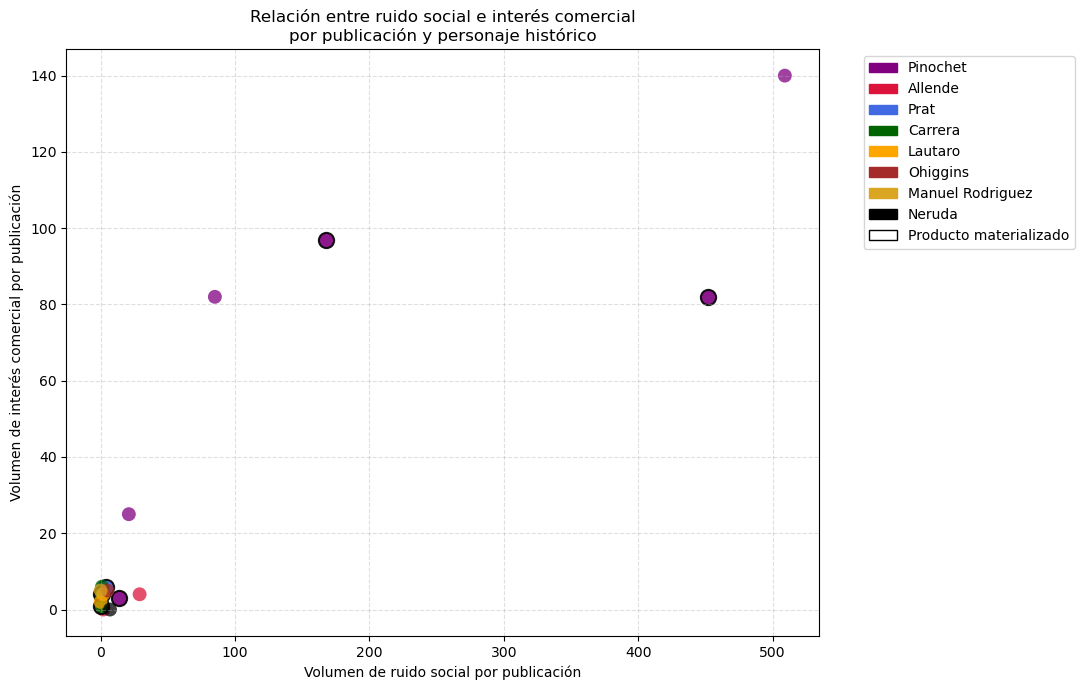

In [24]:
# ============================
# Configuración
# ============================

x_col_ruido_interes = "volumen_ruido"
y_col_ruido_interes = "volumen_interes"


# Colores por personaje
colores_personajes_ruido_interes = {
    "post_pinochet": "purple",
    "post_allende": "crimson",
    "post_prat": "royalblue",
    "post_carrera": "darkgreen",
    "post_lautaro": "orange",
    "post_ohiggins": "brown",
    "post_manuel_rodriguez": "goldenrod",
    "post_neruda": "black"
}


# ============================
# Gráfico
# ============================

fig_ruido_interes, ax_ruido_interes = plt.subplots(
    figsize=(11,7)
)


for personaje, color in colores_personajes_ruido_interes.items():

    df_personaje_ruido_interes = df[
        df[personaje] == 1
    ]

    if len(df_personaje_ruido_interes) == 0:
        continue


    # Separar materializados / no materializados
    publicaciones_materializadas = df_personaje_ruido_interes[
        df_personaje_ruido_interes["post_producto_materializado"] == True
    ]

    publicaciones_no_materializadas = df_personaje_ruido_interes[
        df_personaje_ruido_interes["post_producto_materializado"] == False
    ]


    # No materializados
    ax_ruido_interes.scatter(
        publicaciones_no_materializadas[x_col_ruido_interes],
        publicaciones_no_materializadas[y_col_ruido_interes],
        c=color,
        s=100,
        alpha=0.75,
        edgecolors="none"
    )


    # Materializados con borde negro
    ax_ruido_interes.scatter(
        publicaciones_materializadas[x_col_ruido_interes],
        publicaciones_materializadas[y_col_ruido_interes],
        c=color,
        s=120,
        alpha=0.9,
        edgecolors="black",
        linewidths=1.5
    )


# ============================
# Configuración estética
# ============================

ax_ruido_interes.set_xlabel(
    "Volumen de ruido social por publicación"
)


ax_ruido_interes.set_ylabel(
    "Volumen de interés comercial por publicación"
)


ax_ruido_interes.set_title(
    "Relación entre ruido social e interés comercial\n"
    "por publicación y personaje histórico"
)


ax_ruido_interes.grid(
    linestyle="--",
    alpha=0.4
)


# Leyenda personajes
legend_personajes_ruido_interes = [
    mpatches.Patch(
        color=color,
        label=nombre.replace("post_", "").replace("_", " ").title()
    )
    for nombre, color in colores_personajes_ruido_interes.items()
]


# Leyenda materialización
legend_materializado_ruido_interes = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        label="Producto materializado"
    )
]


ax_ruido_interes.legend(
    handles=
        legend_personajes_ruido_interes +
        legend_materializado_ruido_interes,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.tight_layout()

plt.show()

> **Figura. Relación entre ruido social e interés comercial (en términos de volumen) por publicación según personaje histórico.**
Cada punto representa una publicación individual posicionada según la cantidad de interacciones clasificadas como ruido social (eje X) e interés comercial (eje Y). Los colores representan diferentes personajes históricos y los bordes negros indican publicaciones asociadas a productos materializados. La figura permite observar diferencias en escala y comportamiento entre publicaciones, sin establecer relaciones causales entre viralidad y generación de interés comercial.

**Ausencia de Correlación General y Agrupamiento en el Origen:** Al analizar los datos a nivel de publicación individual (puntos), se observa que la inmensa mayoría de los posteos (representados por los círculos de colores de Prat, Carrera, Lautaro, etc.) se encuentran fuertemente concentrados en la esquina inferior izquierda. Para todas estas publicaciones, un incremento en el ruido social no produce absolutamente ningún desplazamiento hacia arriba en el eje del interés comercial. El único comportamiento expansivo en ambas direcciones corresponde a los puntos morados (Pinochet).

#### Relación en escalas logarítmicas

Este análisis explora la relación entre el volumen de interacción clasificada como ruido social y aquella asociada a señales de interés comercial para cada publicación individual. Se utiliza una escala logarítmica debido a la alta asimetría de los datos y la presencia de publicaciones con niveles de interacción excepcionalmente elevados.

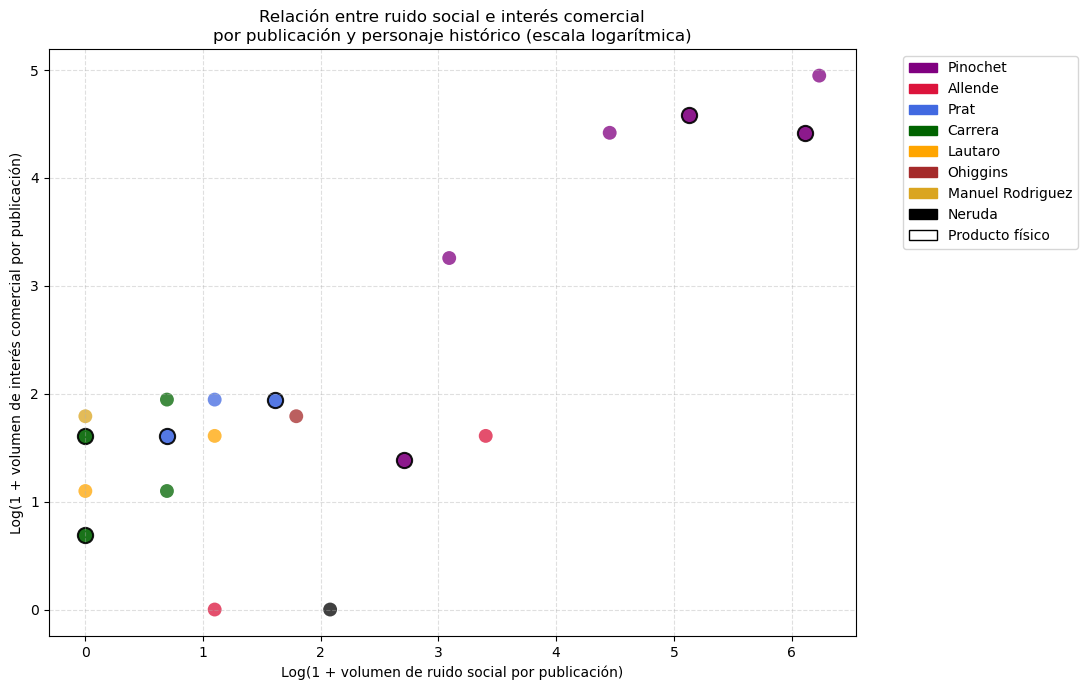

In [127]:
# ============================
# Configuración
# ============================

x_col = "volumen_ruido"
y_col = "volumen_interes"


# Colores por personaje
colores_personajes = {
    "post_pinochet": "purple",
    "post_allende": "crimson",
    "post_prat": "royalblue",
    "post_carrera": "darkgreen",
    "post_lautaro": "orange",
    "post_ohiggins": "brown",
    "post_manuel_rodriguez": "goldenrod",
    "post_neruda": "black"
}


# ============================
# Gráfico
# ============================

fig, ax = plt.subplots(figsize=(11,7))


for personaje, color in colores_personajes.items():

    df_personaje = df[df[personaje] == 1]

    if len(df_personaje) == 0:
        continue


    # Separar materializados / no materializados
    materializados = df_personaje[
        df_personaje["post_producto_materializado"] == True
    ]

    no_materializados = df_personaje[
        df_personaje["post_producto_materializado"] == False
    ]


    # No materializados
    ax.scatter(
        np.log1p(no_materializados[x_col]),
        np.log1p(no_materializados[y_col]),
        c=color,
        s=100,
        alpha=0.75,
        edgecolors="none"
    )


    # Materializados con borde negro
    ax.scatter(
        np.log1p(materializados[x_col]),
        np.log1p(materializados[y_col]),
        c=color,
        s=120,
        alpha=0.9,
        edgecolors="black",
        linewidths=1.5
    )


# ============================
# Configuración estética
# ============================

ax.set_xlabel(
    "Log(1 + volumen de ruido social por publicación)"
)

ax.set_ylabel(
    "Log(1 + volumen de interés comercial por publicación)"
)


ax.set_title(
    "Relación entre ruido social e interés comercial\n"
    "por publicación y personaje histórico (escala logarítmica)"
)


ax.grid(
    linestyle="--",
    alpha=0.4
)


# ============================
# Leyenda personajes
# ============================

legend_personajes = [
    mpatches.Patch(
        color=color,
        label=nombre.replace("post_", "").replace("_", " ").title()
    )
    for nombre, color in colores_personajes.items()
]


# ============================
# Leyenda materialización
# ============================

legend_materializado = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        label="Producto físico"
    )
]


ax.legend(
    handles=legend_personajes + legend_materializado,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.tight_layout()

plt.show()

> **Figura.** Distribución de publicaciones según volumen de ruido social e interés comercial generado. Cada punto representa una publicación individual, coloreada según el personaje histórico asociado. La escala logarítmica permite visualizar simultáneamente publicaciones de baja interacción y aquellas con comportamiento altamente viral, reduciendo la dominancia visual de valores extremos.

**Interpretación:** La transformación logarítmica $\log(1 + x)$ permite desagregar la densa nube de puntos cercana al origen. Aquí se aprecia que, incluso cuando algunas publicaciones de otros personajes o de Allende logran moverse hacia la derecha en el eje X (generando niveles moderados de ruido social), sus posiciones en el eje Y permanecen estancadas de forma horizontal. Esto respalda estadísticamente la sospecha de que la fricción social no es un motor lineal de conversión para el portafolio común.

#### Relación entre Ruido Social (proporción) vs Interés comercial (volumen).

Este análisis evalúa si publicaciones con una mayor presencia relativa de ruido social generan necesariamente menor interés comercial absoluto. A diferencia de las métricas proporcionales, el volumen de interés permite capturar el impacto total generado por cada publicación, considerando que contenidos altamente virales pueden producir simultáneamente conversación social e interacción comercial.

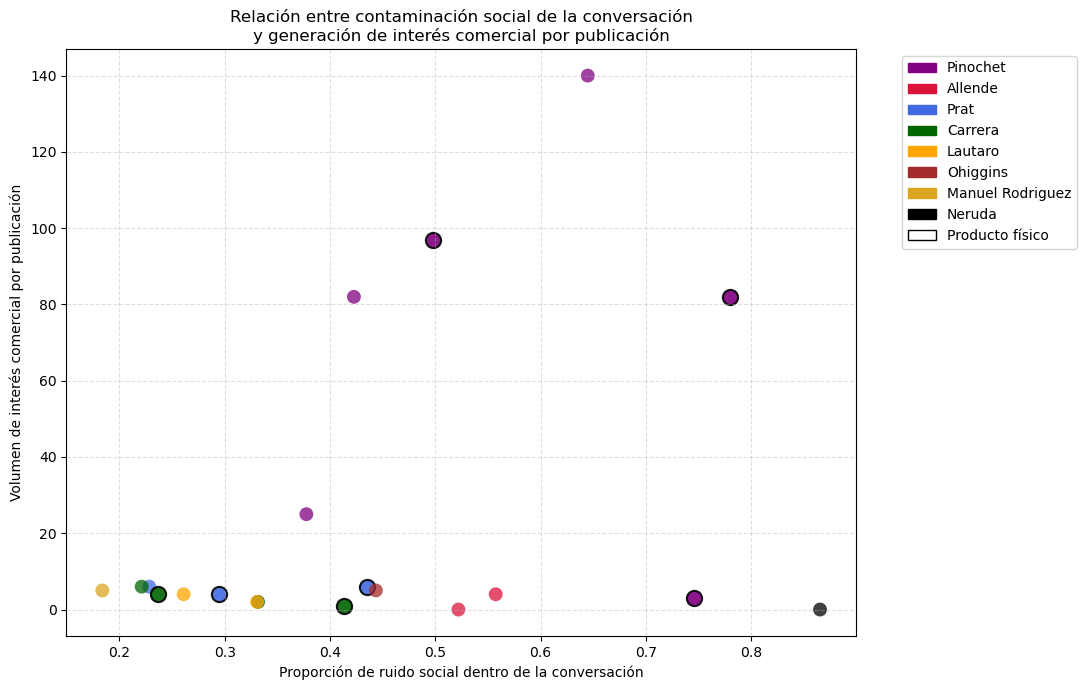

In [128]:
# ============================
# Configuración
# ============================

x_col = "prop_ruido_social"
y_col = "volumen_interes"


# ============================
# Gráfico
# ============================

fig, ax = plt.subplots(figsize=(11,7))


for personaje, color in colores_personajes.items():

    df_personaje = df[df[personaje] == 1]

    if len(df_personaje) == 0:
        continue


    # Separar materializados / no materializados
    materializados = df_personaje[
        df_personaje["post_producto_materializado"] == True
    ]

    no_materializados = df_personaje[
        df_personaje["post_producto_materializado"] == False
    ]


    # No materializados
    ax.scatter(
        no_materializados[x_col],
        no_materializados[y_col],
        c=color,
        s=100,
        alpha=0.75,
        edgecolors="none"
    )


    # Materializados con borde negro
    ax.scatter(
        materializados[x_col],
        materializados[y_col],
        c=color,
        s=120,
        alpha=0.9,
        edgecolors="black",
        linewidths=1.5
    )


# ============================
# Configuración estética
# ============================

ax.set_xlabel(
    "Proporción de ruido social dentro de la conversación"
)

ax.set_ylabel(
    "Volumen de interés comercial por publicación"
)


ax.set_title(
    "Relación entre contaminación social de la conversación\n"
    "y generación de interés comercial por publicación"
)


ax.grid(
    linestyle="--",
    alpha=0.4
)


# ============================
# Leyendas
# ============================

# Leyenda personajes
legend_personajes = [
    mpatches.Patch(
        color=color,
        label=nombre.replace("post_", "").replace("_", " ").title()
    )
    for nombre, color in colores_personajes.items()
]


# Leyenda materialización
legend_materializado = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        label="Producto físico"
    )
]


ax.legend(
    handles=legend_personajes + legend_materializado,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.tight_layout()

plt.show()

>**Figura.** Relación entre la proporción de ruido social y el volumen de interés comercial a nivel de publicación para los distintos personajes históricos analizados. Cada punto representa una publicación individual, donde el eje horizontal indica la proporción de comentarios clasificados como ruido social respecto del total de comentarios de la publicación, mientras que el eje vertical muestra el volumen absoluto de comentarios asociados a interés comercial. Los colores identifican el personaje histórico abordado en la publicación y el borde negro distingue aquellos casos en que el producto representado fue efectivamente materializado. Esta visualización permite explorar la coexistencia entre conversaciones altamente polarizadas y la generación de señales de interés comercial, así como identificar posibles patrones diferenciados entre personajes y productos materializados.

**Interpretación:** 
- **Evidencia del Efecto Multiplicador No Causal (Hipótesis del Catalizador):** Este gráfico es clave para el diseño experimental del proyecto. Al graficar la proporción de ruido social en el eje X contra el volumen comercial en el eje Y, se observa una línea base plana en la parte inferior: publicaciones con 20%, 40% o incluso 80% de ruido social mantienen un volumen de interés comercial cercano a cero.

- **La Excepción de Pinochet:** La única ruptura de esta horizontalidad ocurre con las publicaciones de Pinochet. Esto sugiere fuertemente que el ruido social por sí mismo no CREA interés de compra. El interés comercial parece estar determinado por atributos intrínsecos del producto (deseo del nicho, diseño, exclusividad). En el caso de Pinochet, el ruido social actúa únicamente como un multiplicador algorítmico exógeno: expande el alcance de la publicación a audiencias masivas, permitiendo que el interés latente ya existente en ese nicho se materialice en volúmenes absolutos récord.

- **Validación Posterior:** Se destaca que esta interpretación es una hipótesis exploratoria derivada de la muestra de personajes históricos, la cual será validada y contrastada de manera rigurosa en las fases posteriores a través de modelamiento estadístico inferencial que integre formalmente las categorías de las instituciones del dataset.

### Conclusiones preliminares y relaciones clave (personaje histórico)

La desagregación de la categoría **Personajes históricos** revela que el comportamiento observado anteriormente no es homogéneo entre los distintos personajes, sino que se encuentra fuertemente concentrado en un subconjunto muy reducido de publicaciones.

En el análisis agregado de esta categoría se observaban niveles excepcionalmente altos tanto de señal comercial como de ruido social. Sin embargo, al separar los personajes individuales queda en evidencia que **la mayor parte de dicho comportamiento está explicado por las publicaciones relacionadas con Augusto Pinochet**, mientras que el resto de los personajes presentan dinámicas considerablemente diferentes.

Esto justifica completamente haber expandido las etiquetas temáticas, ya que el análisis agregado ocultaba patrones de comportamiento muy distintos entre personajes.

---

• **Pinochet concentra la mayor parte de la viralidad del conjunto**

Las publicaciones relacionadas con **Pinochet** presentan, con diferencia, los mayores niveles de interacción del dataset. Con únicamente **6 publicaciones**, registran en promedio (excluyendo las respuestas anidadas a comentarios existentes):

- **330 comentarios totales** por publicación.
- **107 comentarios de señal comercial**.
- **208 comentarios de ruido social**.
- **71.5 comentarios asociados a interés comercial** (como se constata visualmente en la escala extrema del gráfico de **Capacidad de generación de interés comercial según personaje histórico**).
- **184 comentarios clasificados como polarización política**.

Además, presentan una enorme dispersión (máximo de **789 comentarios** en una sola publicación), indicando que algunos posteos alcanzaron niveles extraordinarios de viralización. Este comportamiento convierte a Pinochet en el principal responsable de los altos valores observados previamente para la categoría completa de *Personajes históricos*.

---

• **Pinochet vs. Allende: ambos generan debate, pero con impactos muy diferentes**

Las publicaciones relacionadas con **Augusto Pinochet** y **Salvador Allende** presentan un patrón cualitativamente similar: ambas movilizan conversations fuertemente politizadas y una fracción importante de comentarios clasificados como ruido social.

En términos de composición, ambos personajes muestran porcentajes comparables de interacción política:
- **Pinochet:** aproximadamente **58% de ruido social**, del cual un **52% corresponde a polarización política**, y presenta un **27% de interés comercial**.
- **Allende:** aproximadamente **54% de ruido social**, del cual un **47% corresponde polarización política**, y apenas **10% de interés comercial**.

Desde la perspectiva de las proporciones (analizada en el gráfico de **Composición relativa de señal comercial y ruido social según personaje histórico**), ambos contenidos presentan conversaciones relativamente "contaminadas" por debate político en comparación con otros personajes históricos, donde la señal comercial suele superar ampliamente al ruido social.

**Sin embargo**, el gráfico de **Volumen promedio de interés comercial y ruido social por personaje histórico** revela que la diferencia realmente relevante aparece al analizar los **volúmenes absolutos**. Mientras las publicaciones sobre **Allende** generan en promedio alrededor de **28 comentarios totales**, **9 señales comerciales** y **16 comentarios de ruido social**, las publicaciones sobre **Pinochet** alcanzan aproximadamente **330 comentarios**, **107 señales comerciales** y **208 comentarios de ruido social** por publicación. 

En otras palabras, ambas temáticas presentan una composición relativamente similar, pero **Pinochet opera en una escala completamente distinta**, multiplicando simultáneamente tanto el volumen de conversación política como el volumen de potenciales clientes capturados.

---

• **La eficiencia comercial no implica necesariamente mayor valor de negocio (Evidencia del Impacto absoluto vs eficiencia relativa)**

El cruce de variables del gráfico de **Impacto absoluto vs eficiencia relativa de interés comercial** expone un evidente **desacople estructural entre la eficiencia relativa de un post y su conversión real en volumen**. Personajes como **Arturo Prat** (~ 49%), **José Miguel Carrera** (~ 51%), **Lautaro** (~ 45%) y **Manuel Rodríguez** (~ 64%) presentan composiciones internas mucho más favorables, "limpias" y enfocadas para la actividad comercial. 

A primera vista, basarse únicamente en métricas proporcionales sugeriría que estos personajes constituyen una estrategia comercial superior. Sin embargo, al contrastarlo con el volumen absoluto, se desmiente esta premisa: estas figuras se estancan en un rendimiento marginal de entre 3 y 5 comentarios de interés comercial promedio. Atraen comunidades muy enfocadas, pero no logran masificarse. 

Por el contrario, Pinochet exhibe una baja eficiencia relativa (**27%**), pero su volumen neto rompe la escala con **71.5 comentarios de interés comercial**. Para el negocio, **un porcentaje bajo de una masa crítica gigantesca genera un retorno absoluto exponencialmente mayor que un porcentaje alto de un volumen insignificante**. Dado que estudios independientes de la empresa confirman que el volumen de estas señales digitales correlaciona fuertemente con las ventas reales, el volumen neto de leads se consolida como la métrica clave de éxito.

---

• **Neruda aparece como un caso atípico**

El caso de **Pablo Neruda** resulta particularmente llamativo. La única publicación identificada para este personaje presenta aproximadamente un **87% de ruido social**, **85% de polarización política**, **11% de señal comercial** (comentarios exclusivamente dirigidos a la calidad del diseño) y prácticamente **ninguna muestra de interés comercial**. La comparación visual de métricas ilustra cómo aquí el ruido político ahogó por completo la señal de negocio, representando el límite donde la controversia se vuelve comercialmente estéril por la ausencia de un nicho de compra latente.

---

• **Evidencia de las publicaciones individuales: El ruido social como multiplicador exógeno**

El análisis a nivel de publicación individual aporta la evidencia más sugerente sobre la mecánica de las interacciones:

1. **Ausencia de relación general (Análisis en escala lineal y logarítmica):** Al observar la nube de puntos de la **Relación entre ruido social e interés comercial por publicación**, la inmensa mayoría de las publicaciones se encuentran agrupadas y estancadas cerca del origen del eje de interés comercial. Incluso cuando algunas publicaciones logran generar niveles de ruido social moderados o altos, su volumen de interés comercial no experimenta ningún desplazamiento vertical significativo. 
2. **La hipótesis del catalizador:** Al analizar la **Relación entre contaminación social de la conversación y generación de interés comercial por publicación**, se observa una base completamente plana para casi todo el portafolio. Esto sugiere fuertemente que **el ruido social por sí mismo NO tiene la capacidad de CREAR interés de compra**. El deseo comercial está determinado por los atributos intrínsecos del producto y el fervor de su nicho. 
3. **El efecto de dispersión extrema:** La única ruptura de esta horizontalidad ocurre con las publicaciones de Pinochet. En este caso específico, el ruido social parece actuar como un **multiplicador algorítmico exógeno**: la polémica dispara el alcance del posteo hacia audiencias masivas, permitiendo que el fuerte interés latente ya existente en ese nicho se materialice en volúmenes de captura récord. El ruido no crea al cliente, pero expande el embudo a niveles sin precedentes.

---

• **Consideraciones sobre el tamaño muestral y validación futura**

Finalmente, debe tenerse presente que la mayoría de los personajes históricos poseen un número reducido de publicaciones (entre una y cuatro observaciones), por lo que estas estadísticas deben considerarse principalmente descriptivas.

En consecuencia, este fenómeno de la "viralidad inducida como amplificador de valor absoluto" constituye **evidencia exploratoria altamente sugerente**. Esta hipótesis será evaluada y contrastada de manera rigurosa en las siguientes etapas del proyecto mediante modelos estadísticos cuantitativos y análisis inferenciales que integren formalmente tanto a los personajes históricos como a las categorías institucionales del dataset.

## Instituciones Chilenas - Fuerzas Armadas

### Estadísticas descriptivas por institución

Una vez caracterizado el comportamiento global del conjunto de datos, se analiza cómo varían las distintas métricas entre las diferentes categorías temáticas identificadas durante el enriquecimiento del pipeline (Carabineros, Ejército, Fuerza Aérea, Armada, PDI, Guerra del Pacífico y formato de producto). El objetivo es identificar si determinadas temáticas presentan patrones de interacción comercial o de ruido social distintos al comportamiento general observado.

- Volumen de **señal** por temática (incluye tanto señales de interés comercial como criticas dirigidas exclusivamente a la calidad del producto, feedback y solicitudes de nuevos diseños o modificaciones):

In [59]:
metrica = "volumen_senal" 

tabla = pd.DataFrame({
    tema: df.loc[df[tema] == 1, metrica].describe()
    for tema in tematicas
}).T

tabla = tabla.round(1)

print(f"Estadística descriptiva por temática para '{metrica}':\n")
display(tabla)

Estadística descriptiva por temática para 'volumen_senal':



,count,mean,std,min,25%,50%,75%,max
post_carabineros,8.0,6.1,7.1,1.0,1.0,1.5,12.0,19.0
post_ejercito,24.0,4.5,12.3,1.0,1.0,1.5,2.2,62.0
post_fach,2.0,2.5,0.7,2.0,2.2,2.5,2.8,3.0
post_armada,4.0,2.8,2.4,1.0,1.0,2.0,3.8,6.0
post_pdi,2.0,1.5,0.7,1.0,1.2,1.5,1.8,2.0
post_guerra_pacifico,8.0,2.5,2.9,0.0,0.8,2.0,3.0,9.0


- Volumen de **ruido** por temática:

In [9]:
metrica = "volumen_ruido" 

tabla = pd.DataFrame({
    tema: df.loc[df[tema] == 1, metrica].describe()
    for tema in tematicas
}).T

tabla = tabla.round(1)

print(f"Estadística descriptiva por temática para '{metrica}':\n")
display(tabla)

Estadística descriptiva por temática para 'volumen_ruido':



,count,mean,std,min,25%,50%,75%,max
post_carabineros,8.0,20.9,39.3,0.0,0.0,3.0,16.2,112.0
post_ejercito,24.0,1.2,3.5,0.0,0.0,0.0,1.0,17.0
post_fach,2.0,0.5,0.7,0.0,0.2,0.5,0.8,1.0
post_armada,4.0,1.0,1.4,0.0,0.0,0.5,1.5,3.0
post_pdi,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
post_guerra_pacifico,8.0,0.8,0.5,0.0,0.8,1.0,1.0,1.0
post_personajes_historicos,18.0,72.3,154.6,0.0,1.2,4.5,27.0,509.0


- Volumen de **Interés en producto** por temática:

In [10]:
metrica = "volumen_interes" 

tabla = pd.DataFrame({
    tema: df.loc[df[tema] == 1, metrica].describe()
    for tema in tematicas
}).T

tabla = tabla.round(1)

print(f"Estadística descriptiva por temática para '{metrica}':\n")
display(tabla)

Estadística descriptiva por temática para 'volumen_interes':



,count,mean,std,min,25%,50%,75%,max
post_carabineros,8.0,4.2,4.5,0.0,1.0,1.5,9.2,10.0
post_ejercito,24.0,3.9,10.9,1.0,1.0,1.0,2.0,55.0
post_fach,2.0,2.5,0.7,2.0,2.2,2.5,2.8,3.0
post_armada,4.0,2.5,2.4,1.0,1.0,1.5,3.0,6.0
post_pdi,2.0,1.5,0.7,1.0,1.2,1.5,1.8,2.0
post_guerra_pacifico,8.0,2.4,2.9,0.0,0.8,1.5,3.0,9.0
post_personajes_historicos,18.0,26.0,42.8,0.0,2.2,4.5,20.2,140.0


- Volumen de **fanatismo** por temática:
 
Comentarios de aprobación a lo que el producto representa debido a fanatismo o razones ideológicas sin excluir señales de interés genuino en compra.

In [13]:
metrica = "volumen_fanatismo" 

tabla = pd.DataFrame({
    tema: df.loc[df[tema] == 1, metrica].describe()
    for tema in tematicas
}).T

tabla = tabla.round(1)

print(f"Estadística descriptiva por temática para '{metrica}' (sin señal de interés en compra):\n")
display(tabla)

Estadística descriptiva por temática para 'volumen_fanatismo' (sin señal de interés en compra):



,count,mean,std,min,25%,50%,75%,max
post_carabineros,8.0,2.6,3.5,0.0,0.0,1.0,4.0,9.0
post_ejercito,24.0,0.2,0.7,0.0,0.0,0.0,0.0,3.0
post_fach,2.0,0.5,0.7,0.0,0.2,0.5,0.8,1.0
post_armada,4.0,0.2,0.5,0.0,0.0,0.0,0.2,1.0
post_pdi,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
post_guerra_pacifico,8.0,0.4,0.5,0.0,0.0,0.0,1.0,1.0
post_personajes_historicos,18.0,22.9,51.6,0.0,0.0,1.5,8.5,198.0


- Volumen de **fanatismo no comercial** por temática:
  
Comentarios de aprobación a lo que el producto representa debido exclusivamente a fanatismo o reacciones emocionales sin señal explícita de interés en comprar producto.

In [15]:
metrica = "volumen_fanatismo_no_comercial" 

tabla = pd.DataFrame({
    tema: df.loc[df[tema] == 1, metrica].describe()
    for tema in tematicas
}).T

tabla = tabla.round(1)

print(f"Estadística descriptiva por temática para '{metrica}' (sin señal de interés en compra):\n")
display(tabla)

Estadística descriptiva por temática para 'volumen_fanatismo_no_comercial' (sin señal de interés en compra):



,count,mean,std,min,25%,50%,75%,max
post_carabineros,8.0,2.5,3.3,0.0,0.0,1.0,3.8,9.0
post_ejercito,24.0,0.2,0.5,0.0,0.0,0.0,0.0,2.0
post_fach,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
post_armada,4.0,0.2,0.5,0.0,0.0,0.0,0.2,1.0
post_pdi,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
post_guerra_pacifico,8.0,0.2,0.5,0.0,0.0,0.0,0.2,1.0
post_personajes_historicos,18.0,21.4,50.2,0.0,0.0,1.0,8.0,196.0


**Interpretación preliminar en base a estadísticas descriptivas:**

El análisis descriptivo agregando las publicaciones por instituciones (`post_carabineros`, `post_ejercito`, `post_fach`, `post_armada` y `post_pdi`), en contraste con la categoría de `post_guerra_pacifico`, revela dinámicas de interacción radicalmente distintas a las observadas en los personajes históricos. Mientras que en estos últimos la dispersión y los volúmenes extremos dominaban la muestra, las instituciones exhiben comportamientos más acotados, con excepciones críticas de polarización y tracción comercial en nichos específicos.

* **post_carabineros concentra el mayor conflicto: Alto ruido social y fanatismo no comercial**
* **Ruido Social Desproporcionado:** Registra un promedio de **20.9** comentarios de `volumen_ruido`, superando con creces a todas las demás instituciones (donde ninguna supera una media de **1.2**). Su desviación estándar (`std` de **39.3**) y su valor máximo de **112.0** evidencian que ciertos diseños gatillan debates altamente polarizados.
* **Activación de Fanatismo Cívico/No Comercial:** Presenta los niveles más altos de `volumen_fanatismo` (**2.6**) y `volumen_fanatismo_no_comercial` (**2.5**). Esto demuestra que el contenido institucional de Carabineros polariza la conversación y moviliza a usuarios que entran a la publicación exclusivamente a defender o atacar, sin interactuar de forma transaccional con el producto.
* **Eficiencia en la Captura:** A pesar del ruido, muestra un promedio saludable de **6.1** en `volumen_senal` y **4.2** en `volumen_interes`, con un tope máximo de **10.0** interacciones comerciales. El ruido algorítmico parece empujar el posteo, pero manteniendo el foco defensivo/ofensivo en los comentarios.


* **post_ejercito: Alta tracción comercial pura con bajo conflicto**
* **El Mayor Volumen de Producción:** Posee el tamaño muestral más robusto del segmento institucional (`count` de **24.0** publicaciones), otorgando mayor representativad estadística a sus métricas.
* **Tracción Comercial Silenciosa:** Aunque su mediana (`50%`) de interés comercial es baja (**1.0**), el promedio de `volumen_interes` alcanza **3.9** y registra un outlier masivo con un máximo de **55.0** señales de interés en compra en una sola publicación.
* **Inmunidad al Ruido Social:** A diferencia de Carabineros, el Ejército promedia apenas **1.2** comentarios de `volumen_ruido` y un valor insignificante de `volumen_fanatismo_no_comercial` (**0.2**). Esto indica que la comunidad interactúa con esta categoría de forma casi puramente transaccional y comercial, libre de la contaminación del debate ideológico.


* **post_fach, post_armada y post_pdi: Nichos estables de baja interacción**
* **post_armada y post_fach:** Ambas muestran un rendimiento comercial sumamente homogéneo y similar entre sí, con promedios de `volumen_interes` de **2.5**. Presentan desviaciones estándar bajas y niveles de ruido social mínimos (máximos de **1.0** para FACH y **3.0** para Armada), comportándose como productos estables orientados a nichos específicos muy definidos.
* **post_pdi como la categoría más plana:** Registra la menor interacción general del dataset, con un promedio de **1.5** en `volumen_interes`, cero ruido social (`mean` y `std` de **0.0**) y cero fanatismo de cualquier tipo. Las publicaciones de la PDI actúan de manera puramente transaccional, pero sin poder de convocatoria masiva.


* **post_guerra_pacifico: Un comportamiento comercial análogo a las FF.AA.**
* Presenta una media de **2.4** en `volumen_interes` y un ruido social prácticamente inexistente (**0.8** en promedio de `volumen_ruido`, con un máximo histórico de solo **1.0**).
* Esto ratifica la hipótesis de que la historia militar clásica de Chile genera un interés de compra enfocado e higiénico, totalmente distanciado de la fricción política contemporánea que activan categorías como Carabineros o figuras de la historia reciente.



---

### Volumen promedio de señal de interes comercial

Este gráfico compara el volumen promedio de comentarios clasificados como señales de interés comercial generado por las publicaciones asociadas a cada institución. Para cada categoría se calcula el promedio de la métrica `volumen_interes` entre todas las publicaciones etiquetadas con dicha institución, permitiendo comparar su capacidad promedio para estimular interacciones potencialmente asociadas a intención de compra. Junto a cada barra se indica el número de publicaciones (n) utilizadas para calcular el promedio.


In [55]:
# Instituciones
instituciones = [
    "post_carabineros",
    "post_ejercito",
    "post_fach",
    "post_armada",
    "post_pdi"
]

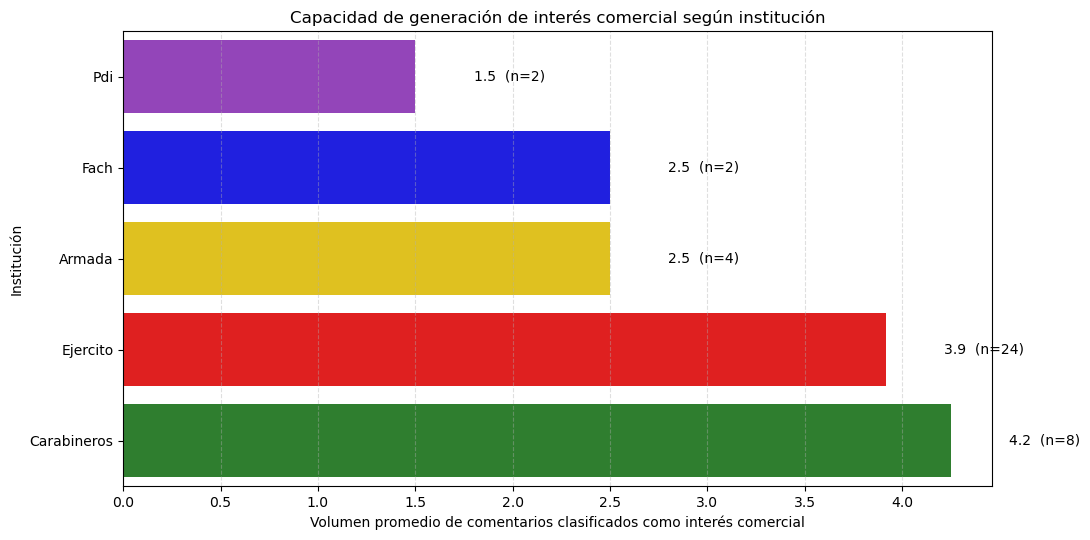

In [24]:
metrica = "volumen_interes"

# ============================
# Crear tabla resumen
# ============================

datos = []

for institucion in instituciones:

    datos.append({
        "institucion": institucion.replace("post_", "").replace("_", " ").title(),
        "promedio_interes": df.loc[df[institucion] == 1, metrica].mean(),
        "n_publicaciones": (df[institucion] == 1).sum()
    })

tabla_interes = pd.DataFrame(datos)

# Ordenar
tabla_interes = tabla_interes.sort_values(
    "promedio_interes",
    ascending=True
)

# ============================
# Colores
# ============================

colores = {
    "Carabineros": "forestgreen",
    "Ejercito": "red",
    "Fach": "blue",
    "Armada": "gold",
    "Pdi": "darkorchid"
}
# ============================
# Gráfico
# ============================

plt.figure(figsize=(11,5.5))

sns.barplot(
    data=tabla_interes,
    x="promedio_interes",
    y="institucion",
    hue="institucion",
    palette=colores,
    legend=False
)

# Etiquetas
for i, row in tabla_interes.reset_index(drop=True).iterrows():
    plt.text(
        row["promedio_interes"] + 0.3,
        i,
        f'{row["promedio_interes"]:.1f}  (n={int(row["n_publicaciones"])})',
        va="center",
        fontsize=10
    )

plt.xlabel(
    "Volumen promedio de comentarios clasificados como interés comercial"
)

plt.ylabel(
    "Institución"
)

plt.title(
    "Capacidad de generación de interés comercial según institución"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

>**Figura. Capacidad de generación de interés comercial según institución.**
El gráfico muestra el volumen promedio de comentarios clasificados como señales de interés comercial por publicación para cada institución. Las cifras permiten comparar el desempeño promedio de las distintas categorías, aunque deben interpretarse considerando el tamaño muestral de cada una, especialmente en aquellas con un número reducido de publicaciones. El análisis se centra en el volumen absoluto de interacción comercial y no en la composición relativa de la conversación, aspecto que será examinado posteriormente mediante las métricas proporcionales.

**Interpretación:** Se aprecia un claro liderazgo de **Carabineros (4,2)** y **Ejército (3,9)**, cuyos volúmenes promedio de interés comercial superan ampliamente a los observados para **Armada (2,5)** y **FACH (2,5)**, mientras que **PDI (1,5)** presenta el menor desempeño del conjunto.

En términos descriptivos, el mayor potencial comercial bruto parece concentrarse en las dos instituciones con mayor despliegue territorial y exposición pública cotidiana. No obstante, esta interpretación debe realizarse con cautela debido a las diferencias en el tamaño muestral entre instituciones. Es posible que el mayor número de publicaciones dedicadas a Carabineros y Ejército refleje una estrategia deliberada de la empresa, derivada del buen desempeño comercial observado previamente en estas temáticas, lo que introduce un posible sesgo de selección en los resultados.

### Volumen promedio de señal de elogios al producto por institución

Este gráfico compara el volumen promedio de comentarios que expresan elogios hacia el producto para las publicaciones asociadas a cada institución. Para cada categoría se calcula el promedio de la métrica `volumen_elogios`, permitiendo evaluar qué instituciones generan una mayor cantidad de comentarios positivos sobre la calidad, diseño o atributos de los productos publicados. Junto a cada barra se indica el número de publicaciones consideradas (n).

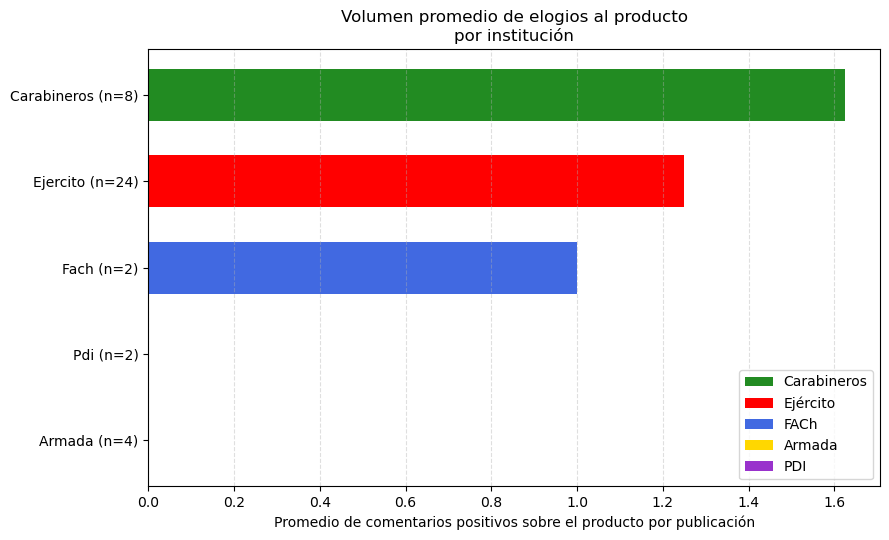

In [21]:
metrica = "volumen_elogios"

# ============================
# Construcción dataframe
# ============================

datos = []

for institucion in instituciones:

    df_inst = df[df[institucion] == 1]

    datos.append({
        "institucion": institucion.replace("post_", "").replace("_", " ").title(),
        "elogios": df_inst[metrica].mean(),
        "n": len(df_inst)
    })

df_plot = pd.DataFrame(datos)

# Ordenar
df_plot = df_plot.sort_values(
    "elogios",
    ascending=True
)

# Etiquetas con n
df_plot["label"] = (
    df_plot["institucion"] +
    " (n=" +
    df_plot["n"].astype(str) +
    ")"
)

# ============================
# Colores
# ============================

mapa_colores = {
    "Carabineros": "forestgreen",
    "Ejercito": "red",
    "Fach": "royalblue",
    "Armada": "gold",
    "Pdi": "darkorchid"
}

colores = [
    mapa_colores[nombre]
    for nombre in df_plot["institucion"]
]

# ============================
# Gráfico
# ============================

fig, ax = plt.subplots(figsize=(9,5.5))

ax.barh(
    df_plot["label"],
    df_plot["elogios"],
    color=colores,
    height=0.6
)

ax.set_xlabel(
    "Promedio de comentarios positivos sobre el producto por publicación"
)

ax.set_title(
    "Volumen promedio de elogios al producto\npor institución"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

legend_elements = [
    Patch(facecolor="forestgreen", label="Carabineros"),
    Patch(facecolor="red", label="Ejército"),
    Patch(facecolor="royalblue", label="FACh"),
    Patch(facecolor="gold", label="Armada"),
    Patch(facecolor="darkorchid", label="PDI")
]

ax.legend(
    handles=legend_elements,
    loc="lower right"
)

plt.tight_layout()

plt.show()

**Figura. Volumen promedio de elogios al producto según institución.**
El gráfico muestra el promedio de comentarios clasificados como elogios al producto para cada institución. Esta métrica representa una forma específica de señal comercial, centrada en valoraciones positivas explícitas de los productos publicados. Las diferencias observadas corresponden a volúmenes absolutos y deben interpretarse considerando el tamaño muestral de cada categoría, especialmente en aquellas con pocas publicaciones.

### Eficiencia relativa de generación de interés comercial según institución

Este gráfico compara la **proporción promedio de comentarios clasificados como señales de interés comercial** para las publicaciones asociadas a cada institución. A diferencia del análisis basado en volúmenes absolutos, esta métrica refleja la composición relativa de la conversación, indicando qué fracción de las interacciones corresponde a interés comercial. De este modo, permite evaluar la eficiencia relativa de cada institución para generar conversaciones orientadas al producto, independientemente del nivel total de interacción. Junto a cada barra se indica el número de publicaciones consideradas (n).

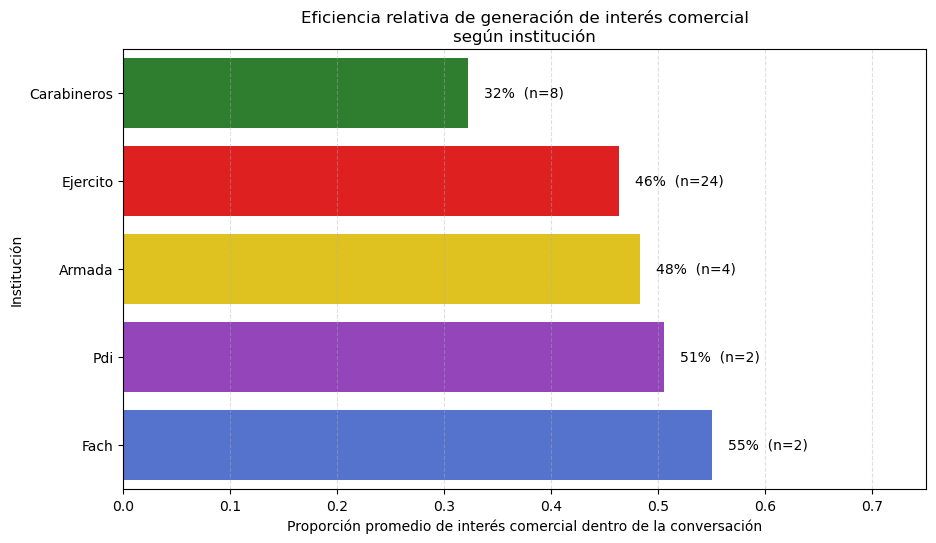

In [26]:
# ============================
# Configuración
# ============================

metrica = "prop_interes"

# ============================
# Crear tabla resumen
# ============================

datos = []

for institucion in instituciones:

    datos.append({
        "institucion": institucion.replace("post_", "").replace("_", " ").title(),
        "promedio_proporcion": df.loc[df[institucion] == 1, metrica].mean(),
        "n_publicaciones": (df[institucion] == 1).sum()
    })

tabla_prop = pd.DataFrame(datos)

# Ordenar
tabla_prop = tabla_prop.sort_values(
    "promedio_proporcion",
    ascending=True
)

# ============================
# Colores
# ============================

colores = {
    "Carabineros": "forestgreen",
    "Ejercito": "red",
    "Fach": "royalblue",
    "Armada": "gold",
    "Pdi": "darkorchid"
}

# ============================
# Gráfico
# ============================

fig, ax = plt.subplots(figsize=(11,5.5))

sns.barplot(
    data=tabla_prop,
    x="promedio_proporcion",
    y="institucion",
    hue="institucion",
    palette=colores,
    legend=False,
    ax=ax
)

# Etiquetas
for i, row in tabla_prop.reset_index(drop=True).iterrows():
    ax.text(
        row["promedio_proporcion"] + 0.015,
        i,
        f'{row["promedio_proporcion"]:.0%}  (n={int(row["n_publicaciones"])})',
        va="center",
        fontsize=10
    )

ax.set_xlabel(
    "Proporción promedio de interés comercial dentro de la conversación"
)

ax.set_ylabel(
    "Institución"
)

ax.set_title(
    "Eficiencia relativa de generación de interés comercial\nsegún institución"
)

ax.set_xlim(
    0,
    min(1, tabla_prop["promedio_proporcion"].max() + 0.20)
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.subplots_adjust(
    left=0.22,
    right=0.95,
    top=0.90,
    bottom=0.10
)

plt.show()

>**Figura. Eficiencia relativa de generación de interés comercial según institución.**
El gráfico muestra la proporción promedio de comentarios clasificados como interés comercial para cada institución. A diferencia de las métricas de volumen, esta representación no mide el alcance de las publicaciones, sino la composición de la conversación generada. En consecuencia, una institución con una mayor proporción de interés comercial no necesariamente genera un mayor número absoluto de potenciales clientes, sino una conversación relativamente más orientada hacia el producto. Las diferencias deben interpretarse considerando el tamaño muestral de cada categoría.

**Interpretación:** 

- **Patrón observado:** Invierte la jerarquía observada en los volúmenes absolutos. Las instituciones con menor volumen de publicaciones y comentarios muestran la mayor "limpieza" conversacional: Fach lidera en eficiencia con un 55%, seguida de Pdi (51%) y Armada (48%). Ejército rinde un 46%, mientras que Carabineros cae al último lugar con apenas un 32%.

- **Extracción de valor:** Existe una relación inversamente proporcional entre el volumen masivo y la eficiencia relativa. Las publicaciones de Fach y Pdi atraen audiencias altamente filtradas donde más de la mitad de la conversación está orientada al producto, mientras que en Carabineros la conversación se dispersa hacia otros focos (ruido social).

### Proporción vs volumen promedio de señal comercial

Este gráfico combina dos perspectivas complementarias sobre el desempeño comercial de las publicaciones asociadas a cada institución. Las barras grises representan el **volumen promedio de comentarios clasificados como señales de interés comercial**, mientras que las barras coloreadas muestran la proporción promedio de interés comercial dentro de la conversación. La visualización permite comparar simultáneamente el impacto absoluto de cada institución y la eficiencia relativa con que sus publicaciones generan interacciones orientadas al producto.

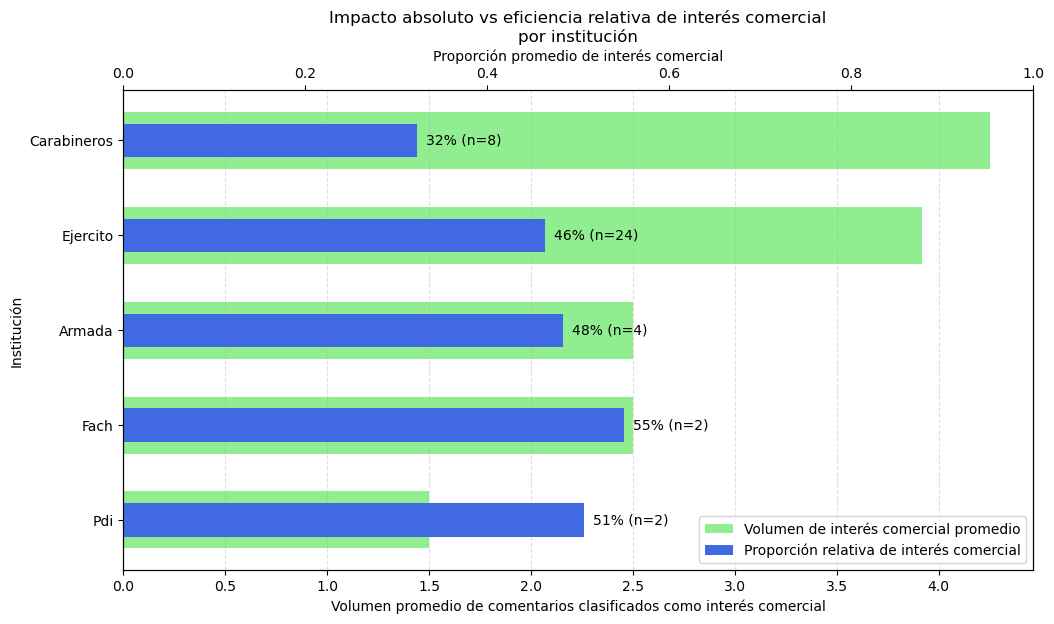

In [70]:
# -----------------------------
# Gráfico
# -----------------------------

fig, ax = plt.subplots(figsize=(13,6))


# Fondo: volumen absoluto
ax.barh(
    tabla["institucion"],
    tabla["volumen_interes"],
    color="lightgreen",
    alpha=1.0,
    height=0.6,
    label="Volumen promedio de interés comercial"
)


# Eje secundario para proporciones
ax2 = ax.twiny()


# Todas las instituciones en azul
ax2.barh(
    tabla["institucion"],
    tabla["prop_interes"],
    color="royalblue",
    
    height=0.35,
    label="**Proporción** promedio de interés comercial"
)


# Etiquetas
for i, row in tabla.reset_index(drop=True).iterrows():
    ax2.text(
        row["prop_interes"] + 0.01,
        i,
        f'{row["prop_interes"]:.0%} (n={int(row["n_publicaciones"])})',
        va="center",
        fontsize=10
    )


# Configuración eje volumen
ax.set_xlabel(
    "Volumen promedio de comentarios clasificados como interés comercial"
)

ax.set_ylabel(
    "Institución"
)


# Configuración eje proporción
ax2.set_xlabel(
    "Proporción promedio de interés comercial"
)

ax2.set_xlim(0, 1)


ax.set_title(
    "Impacto absoluto vs eficiencia relativa de interés comercial\npor institución"
)


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)


# Leyenda
legend_elements = [
    Patch(facecolor="lightgreen", label="Volumen de interés comercial promedio"),
    Patch(facecolor="royalblue", label="Proporción relativa de interés comercial")
]

ax.legend(
    handles=legend_elements,
    loc="lower right"
)


plt.subplots_adjust(
    left=0.25,
    right=0.95,
    top=0.90,
    bottom=0.10
)

plt.show()

>**Figura. Impacto absoluto y eficiencia relativa de generación de interés comercial según institución.**
Las barras verdes representan el volumen promedio de comentarios clasificados como interés comercial por publicación, mientras que las barras de color azul muestran la proporción promedio de interés comercial dentro de la conversación. La comparación entre ambas métricas permite distinguir instituciones que generan un mayor volumen absoluto de potenciales clientes de aquellas cuya conversación presenta una mayor concentración relativa de señales comerciales. Los porcentajes corresponden a promedios por publicación y el número de publicaciones utilizadas en cada categoría se indica mediante n.

**Interpretación:**

- **Patrón observado:** Cruza en paralelo las barras de volumen absoluto (verde, eje inferior) con las de proporción relativa (azul, eje superior). Expone visualmente cómo `Carabineros` tiene la barra verde más larga (mayor alcance de leads), pero la barra azul más corta (menor eficiencia). `Ejército` destaca por el equilibrio más saludable: alto volumen absoluto con una eficiencia del 46%.

- **Extracción de valor:** Este gráfico consolida la regla de oro del portafolio: la baja eficiencia no es un indicador de fracaso comercial. `Carabineros` e `Ejército` traccionan tantos clientes potenciales netos que compensan con creces la "contaminación" de sus conversaciones, superando el retorno total de los nichos eficientes como Fach.

### Relación entre Interés comercial y Ruido social
Este análisis busca estudiar la relación existente entre las interacciones clasificadas como **ruido social** y aquellas asociadas a **interés comercial**, evaluando cómo ambas dimensiones de la conversación se distribuyen dentro del ecosistema de publicaciones.

Debido a que ambas métricas representan aspectos diferentes del comportamiento de los usuarios, se analizan desde dos perspectivas complementarias: una basada en **volúmenes absolutos**, orientada a estudiar la magnitud de interacción generada, y otra basada en **proporciones relativas**, enfocada en caracterizar la composición interna de la conversación.

#### Relación en términos de volumen

Relación entre ruido social e interés comercial.
Se analiza la distribución conjunta del volumen de ruido social y del volumen de interés comercial para cada publicación perteneciente a las distintas temáticas institucionales, diferenciando visualmente los productos materializados mediante un contorno negro.

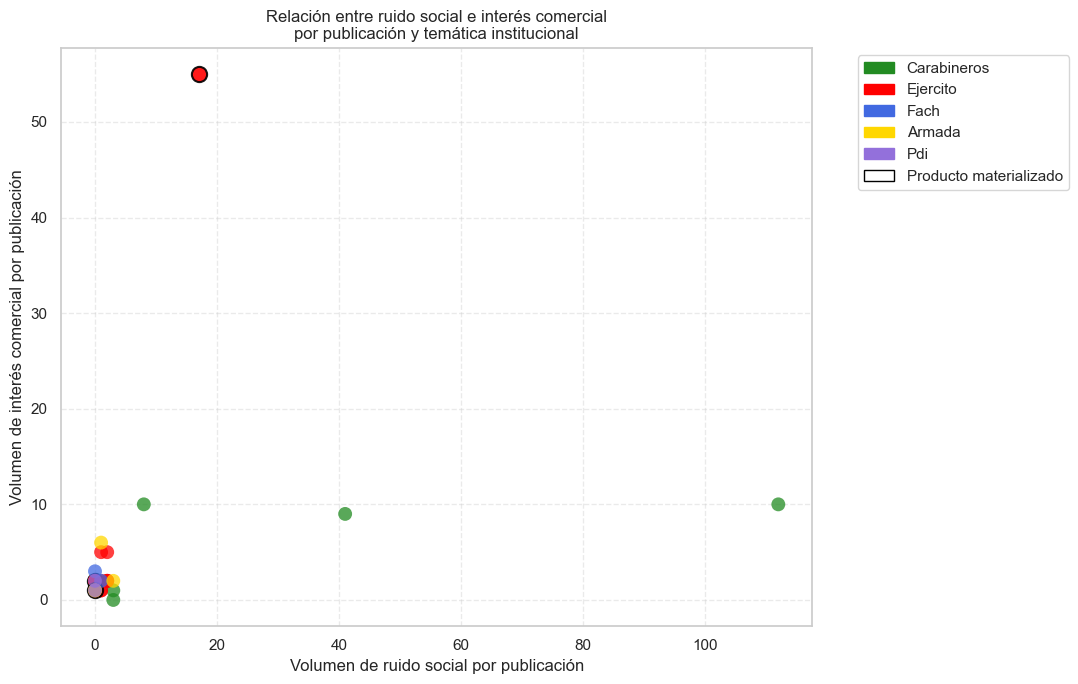

In [73]:
# ============================
# Configuración
# ============================

x_col = "volumen_ruido"
y_col = "volumen_interes"


# Colores por institución
colores_instituciones = {
    "post_carabineros": "forestgreen",
    "post_ejercito": "red",
    "post_fach": "royalblue",
    "post_armada": "gold",
    "post_pdi": "mediumpurple"
}


# ============================
# Gráfico
# ============================

fig, ax = plt.subplots(figsize=(11,7))


for institucion, color in colores_instituciones.items():

    df_inst = df[df[institucion] == 1]

    if len(df_inst) == 0:
        continue

    # Separar materializados / no materializados
    materializados = df_inst[
        df_inst["post_producto_materializado"] == True
    ]

    no_materializados = df_inst[
        df_inst["post_producto_materializado"] == False
    ]


    # No materializados
    ax.scatter(
        no_materializados[x_col],
        no_materializados[y_col],
        c=color,
        s=100,
        alpha=0.75,
        edgecolors="none"
    )


    # Materializados
    ax.scatter(
        materializados[x_col],
        materializados[y_col],
        c=color,
        s=120,
        alpha=0.9,
        edgecolors="black",
        linewidths=1.5
    )


# ============================
# Configuración estética
# ============================

ax.set_xlabel(
    "Volumen de ruido social por publicación"
)

ax.set_ylabel(
    "Volumen de interés comercial por publicación"
)

ax.set_title(
    "Relación entre ruido social e interés comercial\npor publicación y temática institucional"
)


ax.grid(
    linestyle="--",
    alpha=0.4
)


# Leyenda instituciones
legend_instituciones = [
    mpatches.Patch(
        color=color,
        label=nombre.replace("post_", "").replace("_", " ").title()
    )
    for nombre, color in colores_instituciones.items()
]


# Leyenda materialización
legend_materializado = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        label="Producto materializado"
    )
]


ax.legend(
    handles=legend_instituciones + legend_materializado,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.tight_layout()

plt.show()

>**Figura. Relación entre el volumen de ruido social y el volumen de interés comercial por publicación según temática institucional.** Cada punto representa una publicación; el color identifica la institución asociada y el borde negro indica publicaciones correspondientes a productos materializados. La visualización permite explorar posibles asociaciones entre la intensidad de la conversación social y la generación de señales de interés comercial, así como identificar publicaciones con niveles atípicos de interacción.

**Interpretación:**
- **Patrón observado:** Gráfico de dispersión por post individual. La inmensa mayoría de las publicaciones de todas las instituciones se apelotonan en el cuadrante inferior izquierdo (bajo ruido, bajo interés). Sin embargo, irrumpen dos comportamientos atípicos radicales: un post del Ejército (punto rojo) que se dispara verticalmente a 55 comentarios de interés comercial con ruido moderado, y tres publicaciones de Carabineros (puntos verdes) que se desplazan horizontalmente alcanzando picos extremos de ruido social (~40, ~110), pero sin despegarse del suelo en interés comercial.

- **Extracción de valor:** Visualiza la desconexión entre las dos variables. El ruido social extremo (los picos de Carabineros) no empuja hacia arriba la intención de compra de forma lineal. Al mismo tiempo, el éxito masivo del post del Ejército demuestra que se pueden lograr récords de conversión comercial sin necesidad de activar crisis o polémicas masivas en la red.

#### Relación en escalas logarítmicas

Con el objetivo de facilitar la visualización de publicaciones con niveles de interacción muy heterogéneos, se representa la relación entre el volumen de ruido social y el volumen de interés comercial utilizando una transformación logarítmica. Cada punto corresponde a una publicación asociada a una temática institucional y el contorno negro identifica aquellos casos en que el producto promocionado se presentó en formato físico.

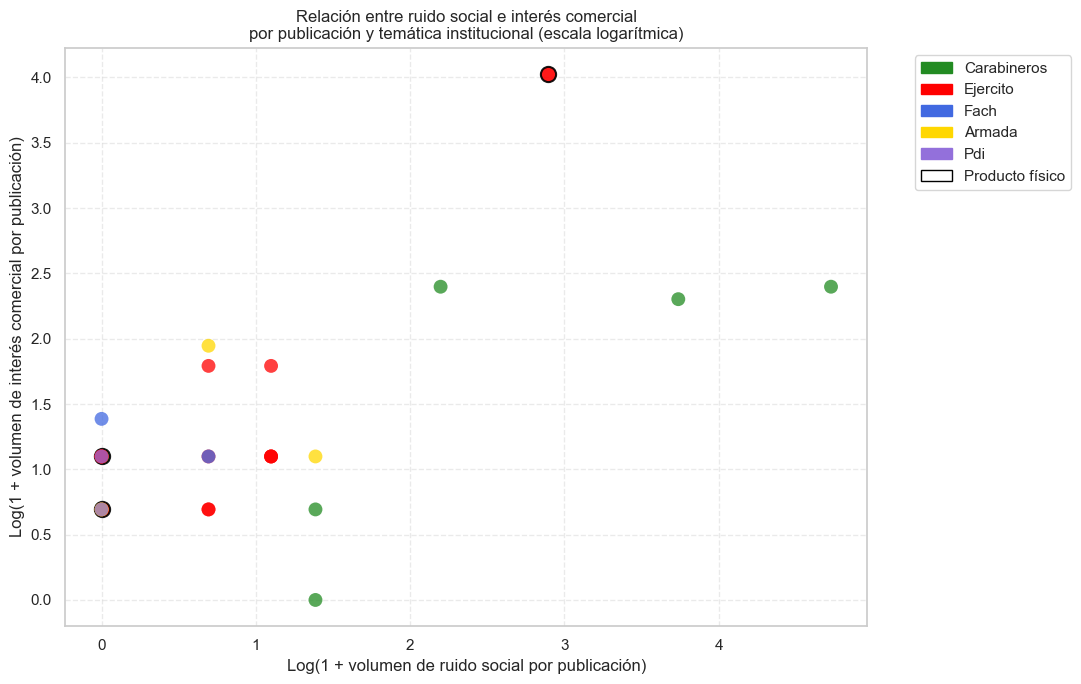

In [74]:
# ============================
# Configuración
# ============================

x_col = "volumen_ruido"
y_col = "volumen_interes"


# Colores por institución
colores_instituciones = {
    "post_carabineros": "forestgreen",
    "post_ejercito": "red",
    "post_fach": "royalblue",
    "post_armada": "gold",
    "post_pdi": "mediumpurple"
}


# ============================
# Gráfico
# ============================

fig, ax = plt.subplots(figsize=(11,7))


for institucion, color in colores_instituciones.items():

    df_inst = df[df[institucion] == 1]

    if len(df_inst) == 0:
        continue


    # Separar materializados / no materializados
    materializados = df_inst[
        df_inst["post_producto_materializado"] == True
    ]

    no_materializados = df_inst[
        df_inst["post_producto_materializado"] == False
    ]


    # No materializados
    ax.scatter(
        np.log1p(no_materializados[x_col]),
        np.log1p(no_materializados[y_col]),
        c=color,
        s=100,
        alpha=0.75,
        edgecolors="none"
    )


    # Materializados con borde negro
    ax.scatter(
        np.log1p(materializados[x_col]),
        np.log1p(materializados[y_col]),
        c=color,
        s=120,
        alpha=0.9,
        edgecolors="black",
        linewidths=1.5
    )


# ============================
# Configuración estética
# ============================

ax.set_xlabel(
    "Log(1 + volumen de ruido social por publicación)"
)

ax.set_ylabel(
    "Log(1 + volumen de interés comercial por publicación)"
)

ax.set_title(
    "Relación entre ruido social e interés comercial\n"
    "por publicación y temática institucional (escala logarítmica)"
)

ax.grid(
    linestyle="--",
    alpha=0.4
)


# ============================
# Leyenda instituciones
# ============================

legend_instituciones = [
    mpatches.Patch(
        color=color,
        label=nombre.replace("post_", "").replace("_", " ").title()
    )
    for nombre, color in colores_instituciones.items()
]


# ============================
# Leyenda materialización
# ============================

legend_materializado = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        label="Producto físico"
    )
]


ax.legend(
    handles=legend_instituciones + legend_materializado,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)


plt.tight_layout()

plt.show()

**Figura.** Relación entre el volumen de ruido social y el volumen de interés comercial por publicación para las distintas temáticas institucionales, utilizando una escala logarítmica (log(1+x)) en ambos ejes. Cada punto representa una publicación; el color identifica la institución asociada y el contorno negro indica publicaciones correspondientes a productos físicos. La transformación logarítmica reduce la influencia de publicaciones extremadamente virales, permitiendo apreciar con mayor claridad la distribución de observaciones de baja y mediana interacción, así como la coexistencia de publicaciones con altos niveles de ruido social y elevado interés comercial.

#### Relación entre Ruido Social (proporción) vs Interés comercial (volumen).

Con el objetivo de explorar la relación entre la composición de la conversación y la generación de interés comercial, se representa el volumen de interés comercial obtenido por cada publicación en función de la proporción de ruido social presente en sus comentarios. Cada punto corresponde a una publicación asociada a una temática institucional y el contorno negro identifica aquellas publicaciones correspondientes a productos físicos

**Interpretación:**
- **Patrón observado:** Al estabilizar los valores extremos mediante la transformación $Log(1+x)$, la nube de puntos revela la microdinámica de las publicaciones menores. Se aprecia que las publicaciones con contorno negro (Producto físico/materializado) coexisten en la zona de baja interacción, y que la dispersión horizontal de Carabineros (verde) es una constante y no un evento aislado.
  
- **Extracción de valor:** La gráfica suguiere que la tendencia a generar ruido es un atributo intrínseco de la temática de Carabineros en casi todas sus publicaciones, mientras que el resto de las ramas militares mantienen un comportamiento clusterizado y predecible cerca del origen de la conversación.

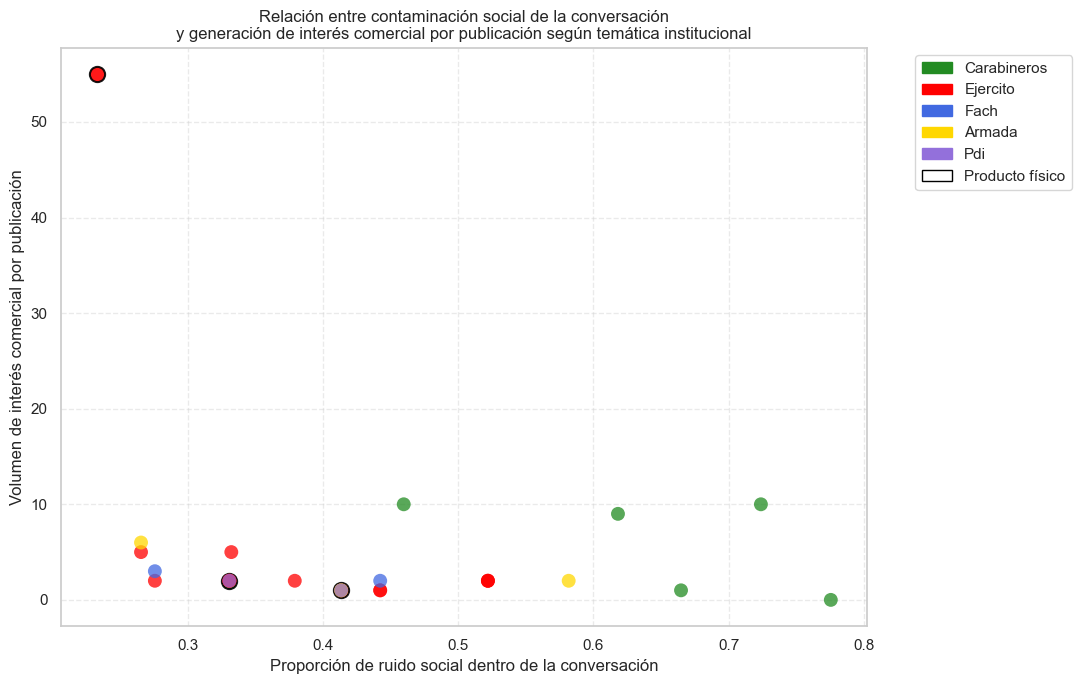

In [76]:
# ============================
# Configuración
# ============================

x_col = "prop_ruido_social"
y_col = "volumen_interes"


# Colores por institución
colores_instituciones = {
    "post_carabineros": "forestgreen",
    "post_ejercito": "red",
    "post_fach": "royalblue",
    "post_armada": "gold",
    "post_pdi": "mediumpurple"
}


# ============================
# Gráfico
# ============================

fig, ax = plt.subplots(figsize=(11,7))


for institucion, color in colores_instituciones.items():

    df_inst = df[df[institucion] == 1]

    if len(df_inst) == 0:
        continue


    # Separar materializados / no materializados
    materializados = df_inst[
        df_inst["post_producto_materializado"] == True
    ]

    no_materializados = df_inst[
        df_inst["post_producto_materializado"] == False
    ]


    # No materializados
    ax.scatter(
        no_materializados[x_col],
        no_materializados[y_col],
        c=color,
        s=100,
        alpha=0.75,
        edgecolors="none"
    )


    # Materializados con borde negro
    ax.scatter(
        materializados[x_col],
        materializados[y_col],
        c=color,
        s=120,
        alpha=0.9,
        edgecolors="black",
        linewidths=1.5
    )


# ============================
# Configuración estética
# ============================

ax.set_xlabel(
    "Proporción de ruido social dentro de la conversación"
)

ax.set_ylabel(
    "Volumen de interés comercial por publicación"
)

ax.set_title(
    "Relación entre contaminación social de la conversación\n"
    "y generación de interés comercial por publicación según temática institucional"
)

ax.grid(
    linestyle="--",
    alpha=0.4
)


# ============================
# Leyendas
# ============================

legend_instituciones = [
    mpatches.Patch(
        color=color,
        label=nombre.replace("post_", "").replace("_", " ").title()
    )
    for nombre, color in colores_instituciones.items()
]

legend_materializado = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        label="Producto físico"
    )
]

ax.legend(
    handles=legend_instituciones + legend_materializado,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

>**Figura.** Relación entre la proporción de ruido social y el volumen de interés comercial por publicación para las distintas temáticas institucionales. Cada punto representa una publicación; el color identifica la institución asociada y el contorno negro indica publicaciones correspondientes a productos en formato físico. La figura permite evaluar visualmente si publicaciones con distintos niveles de contaminación de la conversación logran generar volúmenes similares o diferentes de interés comercial, sin asumir necesariamente una relación lineal entre ambas variables.

**Interpretación:**

- **Patrón observado:** Contrasta el porcentaje de ruido en el eje X contra el volumen de interés en el eje Y. El patrón es contundente: una línea de base completamente plana a lo largo de todo el espectro de contaminación (desde 0.25 hasta 0.8). Las publicaciones de `Carabineros` se esparcen horizontalmente cubriendo los niveles más altos de contaminación por ruido social, pero su volumen de interés comercial permanece inmóvil (plano entre 0 y 10 leads). La única anomalía vertical es el post del `Ejército`, ubicado en una zona de baja contaminación (~0.25).

- **Extracción de valor:** Este gráfico aporta la prueba reina del comportamiento institucional. A diferencia de lo observado con los Personajes Históricos (donde el ruido extremo de Pinochet actuaba como un multiplicador algorítmico), en el bloque institucional el ruido social actúa como un factor estéril. La fricción o debate en torno a las instituciones de orden público satura la conversación pero no amplifica las ventas, lo que sugiere que para esta categoría es comercialmente preferible buscar la pulcritud conversacional y los atributos directos del producto.

### Conclusiones preliminares y relaciones clave (Bloque Institucional)

A partir de la integración del análisis estadístico descriptivo y las evidencias visuales extraídas de las gráficas, es posible estructurar las siguientes conclusiones preliminares sobre el comportamiento del portafolio institucional, centrándose en las dinámicas de conversión y la fricción social:

* **El desacople entre eficiencia relativa e impacto absoluto**
    * Los datos confirman la existencia de un **desacople estructural** entre la orientación porcentual de la conversación y el volumen neto de clientes potenciales capturados. 
    * Categorías como `post_fach` y `post_pdi` exhiben una alta eficiencia relativa (con un **55%** y **51%** de la conversación volcada al interés comercial, respectivamente), operando como comunidades limpias y enfocadas. Sin embargo, se estancan en volúmenes absolutos muy bajos (medias de **2.5** y **1.5** comentarios de interés).
    * En contraste, `post_carabineros` registra la menor eficiencia relativa del portafolio (**32%**), pero logra el mayor volumen absoluto promedio (**4.2** comentarios de interés). Esto ratifica que **una baja eficiencia en una masa crítica masiva genera un retorno comercial neto superior** que una alta eficiencia en un nicho reducido.

* **El ruido social como un factor estéril en la categoría institucional**
    * A diferencia del bloque de personajes históricos —donde la polémica actuaba como un catalizador algorítmico exógeno que expandía el embudo comercial—, en el análisis de las instituciones **el ruido social se comporta de manera comercialmente estéril**.
    * La evidencia del gráfico de *Relación entre contaminación social de la conversación y generación de interés comercial por publicación* es contundente: se observa una base completamente plana a lo largo de todo el espectro de contaminación por ruido. Las publicaciones de `post_carabineros` se dispersan horizontalmente alcanzando picos extremos de ruido (hasta **112.0** comentarios) y activando altos niveles de fanatismo no comercial (**2.5**), pero su volumen de interés comercial permanece estancado en la base. 
    * Esto sugiere que la polémica en torno a las instituciones de orden público satura y contamina la conversación, pero **no tiene la capacidad de crear ni de amplificar el interés de compra**.

* **La existencia de tracción comercial masiva sin conflicto**
    * El caso de `post_ejercito` aporta el contraejemplo óptimo para el negocio. Con el tamaño muestral más robusto del dataset (**24 publicaciones**), logra un promedio de interés comercial de **3.9** (muy cercano al de Carabineros) y un récord absoluto de **55.0** comentarios de interés en una sola publicación, pero manteniendo un ruido social insignificante de apenas **1.2** comentarios promedio.
    * Esto demuestra que es perfectamente viable alcanzar niveles extraordinarios de viralización y captura comercial en redes sociales basándose en el fervor del nicho o los atributos del producto, sin necesidad de activar debates ideológicos ni polarización.

* **Separación de dinámicas: Historia clásica vs. Fricción contemporánea**
    * La temática `post_guerra_pacifico` registra un comportamiento comercial análogo al de las FF.AA. tradicionales (`post_armada` y `post_fach`), con una media de **2.4** en interés y un ruido social prácticamente nulo (**0.8**). 
    * Este patrón refuerza la hipótesis de que la historia militar clásica e institucional genera un interés de compra enfocado, higiénico y transaccional, distanciándose por completo de la fricción política contemporánea asociada a contingencias actuales.

---

**Próximos pasos y validación inferencial**
Cabe enfatizar que todos los hallazgos documentados hasta este punto poseen un carácter estrictamente exploratorio y descriptivo. Para confirmar la validez de estas tendencias, descartar el efecto del tamaño muestral en las categorías más reducidas y evaluar si la aparente esterilidad del ruido social es estadísticamente significativa, se realizarán en la siguiente sección **estudios de contraste de hipótesis, modelos de regresión y pruebas inferenciales cuantitativas** que validen rigurosamente estas interacciones antes de proponer recomendaciones definitivas de negocio.

## Análisis inferencial del interés comercial
Debido a que durante el análisis exploratorio se identificaron asociaciones relevantes entre distintas métricas de interacción comercial y social, así como patrones diferenciados entre personajes históricos e instituciones chilenas, resulta necesario avanzar hacia una etapa de validación estadística que permita determinar si dichas relaciones representan fenómenos consistentes o si podrían explicarse por el efecto del tamaño muestral, la viralidad de las publicaciones o el azar.

En particular, las matrices de correlación evidenciaron asociaciones elevadas entre el interés comercial, el ruido social y la polarización política cuando estas variables fueron analizadas en términos de volúmenes absolutos. Sin embargo, dichas asociaciones cambiaron sustancialmente al estudiar las proporciones relativas de la conversación, sugiriendo la posible existencia de variables de confusión asociadas al volumen total de interacción. Asimismo, el análisis visual mostró patrones consistentes tanto en el bloque de personajes históricos como en el de instituciones chilenas, donde surgieron indicios de un posible desacople entre la eficiencia relativa de generación de interés comercial y el impacto comercial absoluto de las publicaciones, además de diferencias en el papel que desempeña el ruido social según la temática analizada.

A partir de estas evidencias preliminares, esta sección tiene como objetivo construir y validar modelos estadísticos que permitan identificar los principales determinantes del interés comercial, cuantificar la magnitud de sus efectos y evaluar su significancia estadística. En particular, se buscará responder preguntas tales como si una mayor viralidad se traduce efectivamente en un mayor volumen de interés comercial, si dicha viralidad reduce la eficiencia relativa de la conversación comercial, si la polarización política o el ruido social constituyen factores asociados a la generación de interés comercial una vez controladas otras variables, y cuál es la contribución relativa de factores como la temática de la publicación, la materialización del producto y el volumen total de interacción.

De este modo, esta etapa marca la transición desde un enfoque exploratorio, orientado a identificar patrones y generar hipótesis, hacia un análisis inferencial que permita evaluar rigurosamente dichas hipótesis y sustentar con evidencia estadística las conclusiones y recomendaciones de negocio derivadas del presente estudio.


### Validación estadística:

#### Evaluación de normalidad

Como primer paso del análisis inferencial, se evaluó el supuesto de normalidad de las principales variables del estudio. Este diagnóstico permite determinar si las distribuciones observadas satisfacen los requisitos de las pruebas estadísticas paramétricas tradicionales o si, por el contrario, resulta más apropiado emplear metodologías no paramétricas o modelos específicamente diseñados para la naturaleza de los datos.

- **Contraste Formal de Normalidad mediante Test de Shapiro-Wilk**

Función para resumir normalidad

In [5]:
def evaluar_normalidad(df, columnas):

    resultados = []

    for col in columnas:

        datos = df[col].dropna()

        stat, p = shapiro(datos)

        resultados.append({
            "Variable": col,
            "N": len(datos),
            "Shapiro W": stat,
            "p-value": p,
            "Normal": p > 0.05
        })

    return (
        pd.DataFrame(resultados)
        .sort_values("p-value")
    )

In [8]:
variables = [

    "volumen_total",
    "volumen_interes",
    "volumen_ruido",
    "volumen_polarizacion",

    "prop_interes",
    "prop_ruido_social",
    "prop_polarizacion"

]

evaluar_normalidad(df, variables)

,Variable,N,Shapiro W,p-value,Normal
2,volumen_ruido,155,0.169836,7.866835e-26,False
3,volumen_polarizacion,155,0.171489,8.251115e-26,False
0,volumen_total,155,0.201982,2.016016e-25,False
1,volumen_interes,155,0.267396,1.505571e-24,False
6,prop_polarizacion,155,0.952396,3.886138e-05,False
5,prop_ruido_social,155,0.953277,4.636280e-05,False
4,prop_interes,155,0.974479,5.613939e-03,False


- **Evaluación visual de Distribuciones y Detección de Atípicos**

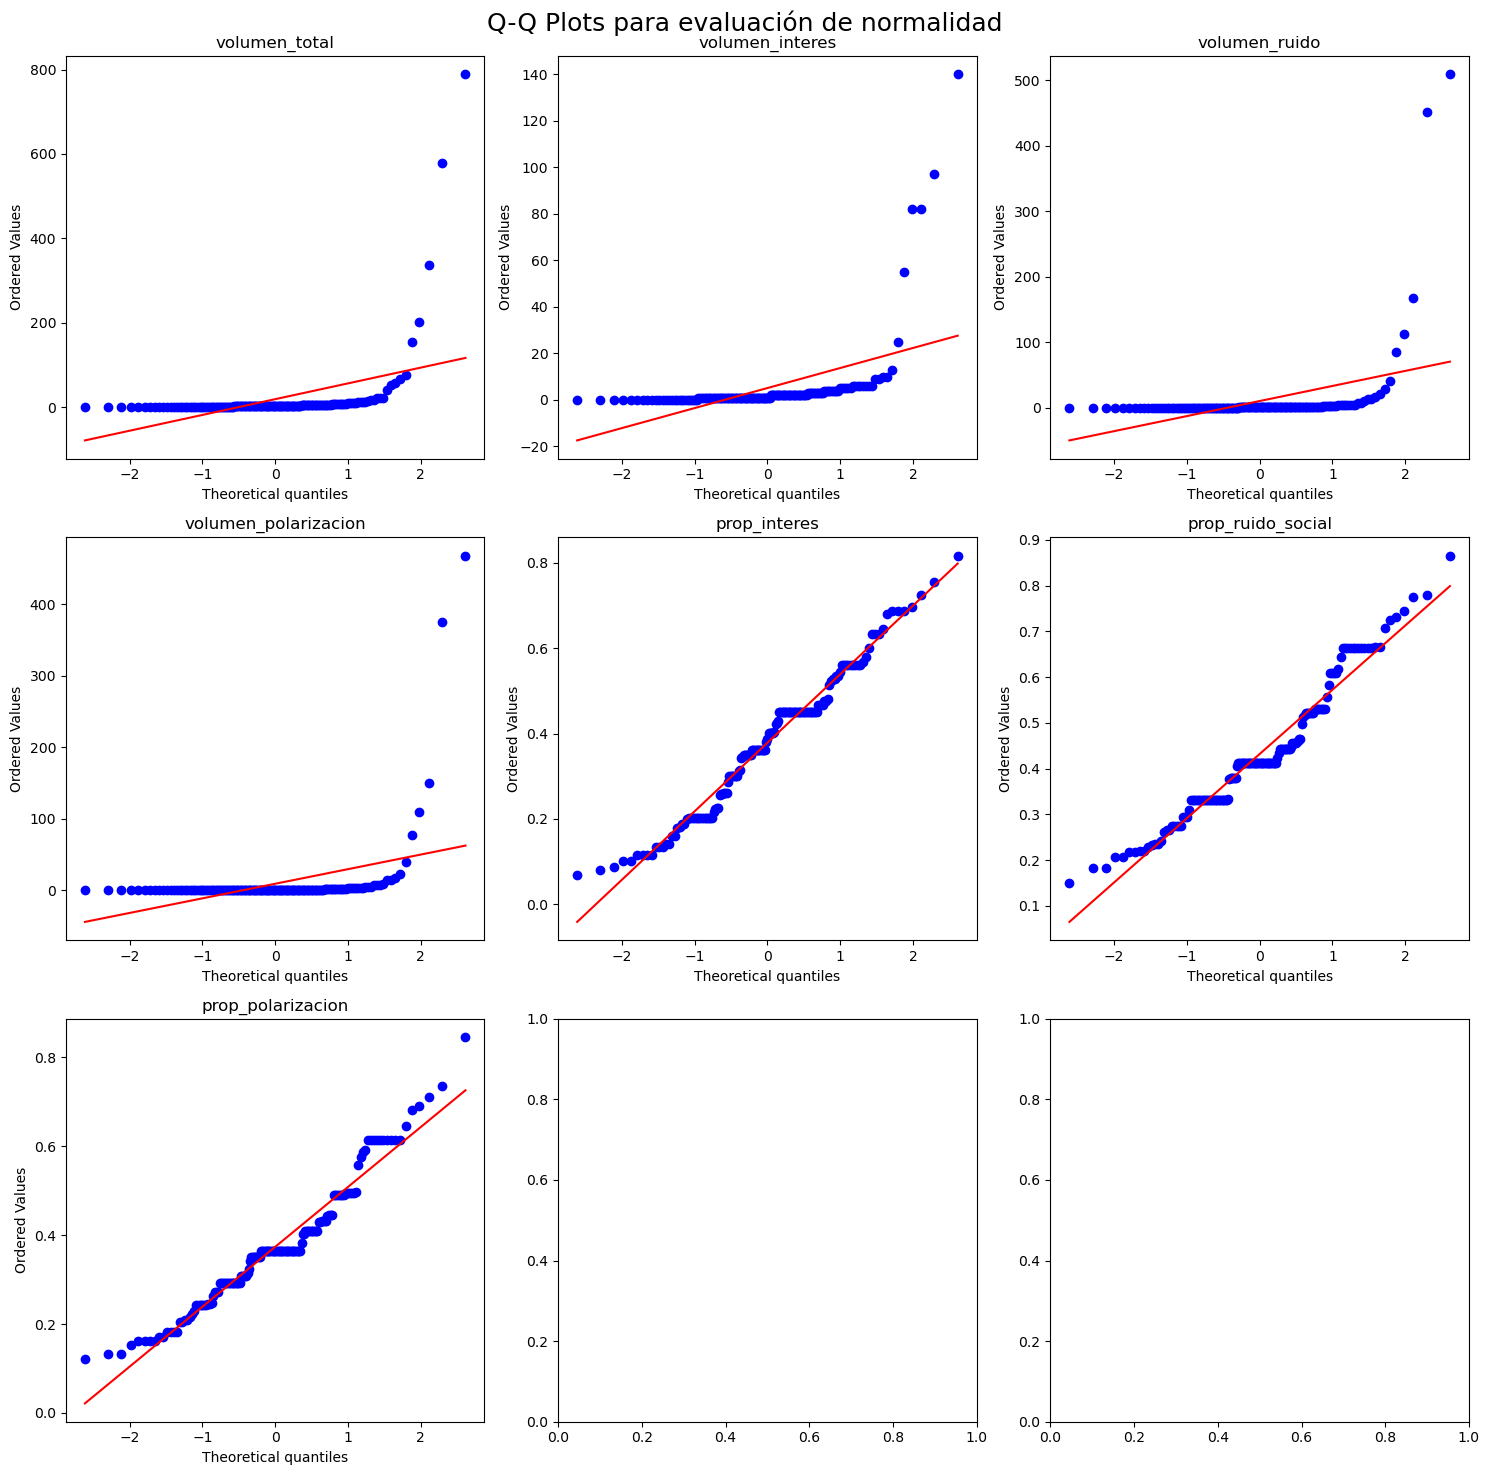

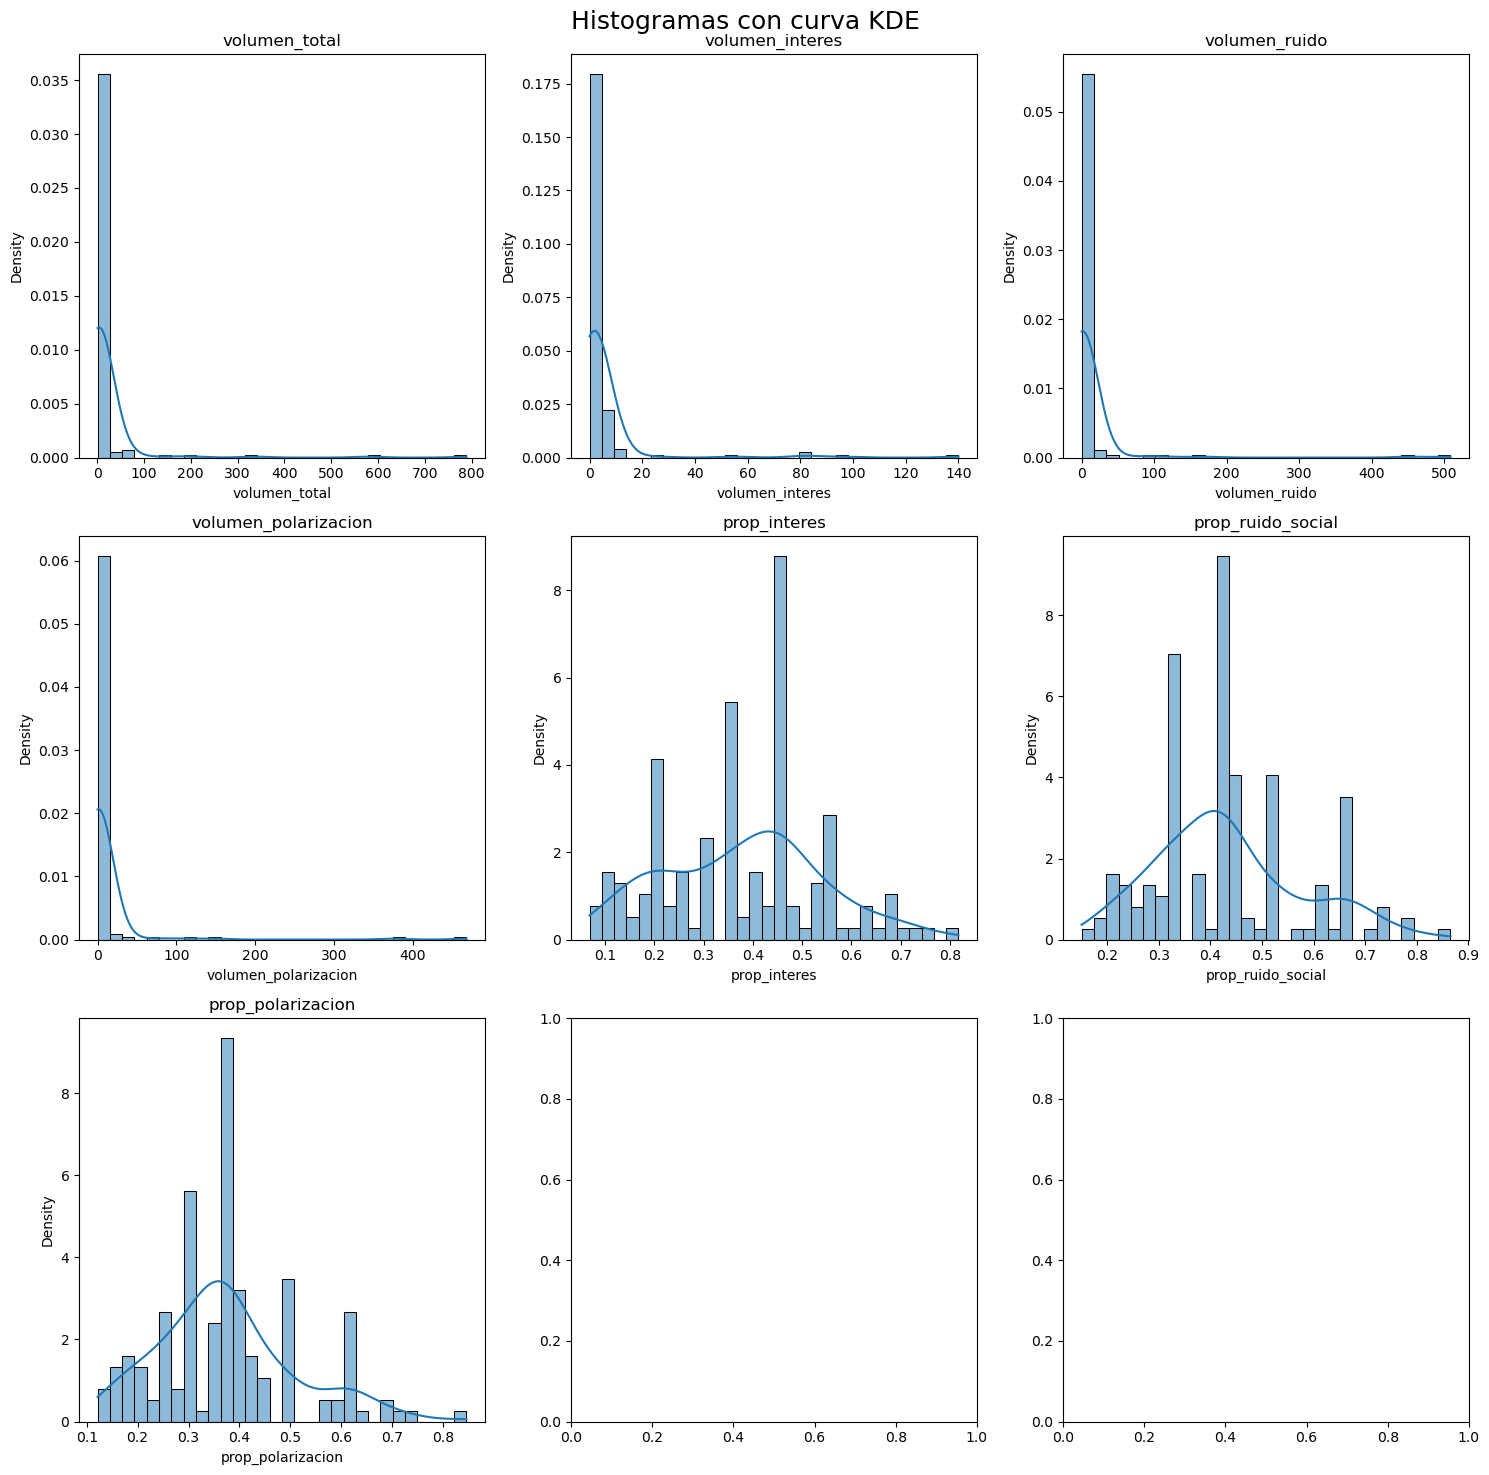

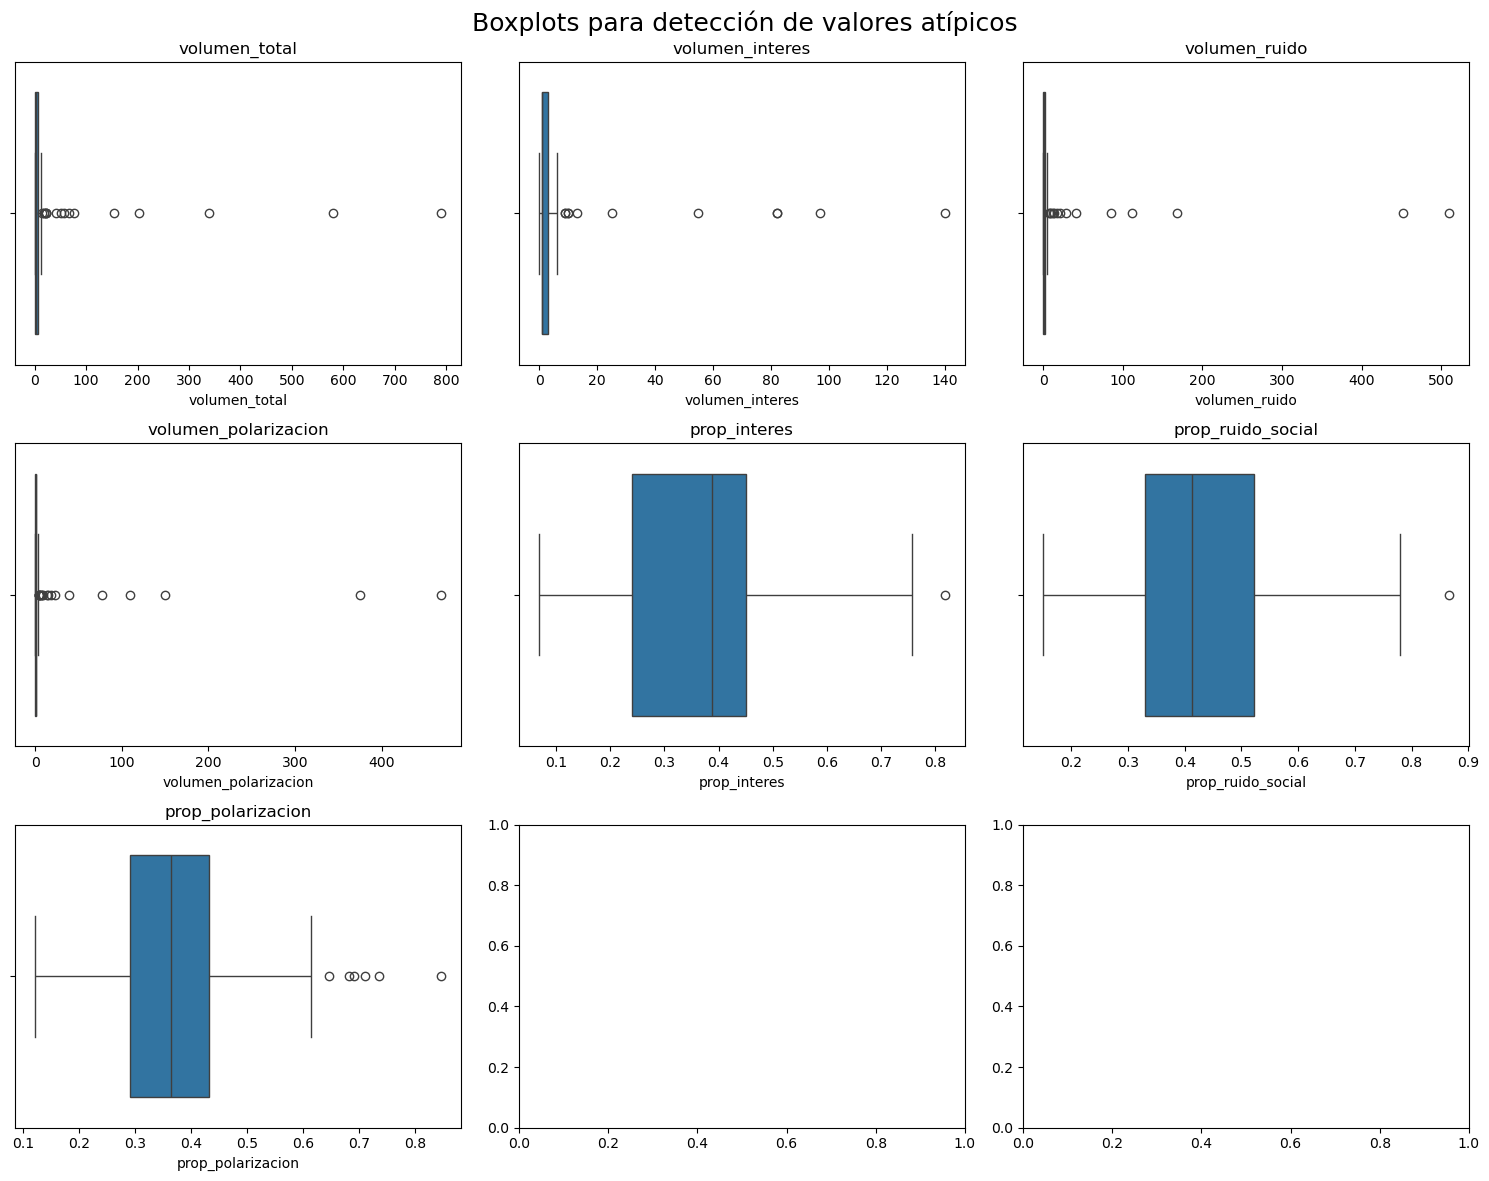

In [10]:
n = len(variables)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 5*nrows)
)

axes = axes.flatten()

for ax, var in zip(axes, variables):

    stats.probplot(df[var].dropna(), dist="norm", plot=ax)

    ax.set_title(var)

plt.suptitle(
    "Q-Q Plots para evaluación de normalidad",
    fontsize=18
)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 5*nrows)
)

axes = axes.flatten()

for ax, var in zip(axes, variables):

    sns.histplot(
        df[var],
        bins=30,
        kde=True,
        stat="density",
        ax=ax
    )

    ax.set_title(var)

plt.suptitle(
    "Histogramas con curva KDE",
    fontsize=18
)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 4*nrows)
)

axes = axes.flatten()

for ax, var in zip(axes, variables):

    sns.boxplot(
        x=df[var],
        ax=ax
    )

    ax.set_title(var)

plt.suptitle(
    "Boxplots para detección de valores atípicos",
    fontsize=18
)

plt.tight_layout()
plt.show()

**Diagnóstico Estructural de (No) Normalidad y Distribución**

El análisis de normalidad confirma que ninguna de las variables evaluadas sigue una distribución normal según el test de Shapiro-Wilk ($p < 0.05$ en todos los casos). No obstante, las métricas pueden agruparse en dos familias con comportamientos claramente distintos.

Las variables de **volumen** (`volumen_total`, `volumen_interes`, `volumen_ruido` y `volumen_polarizacion`) presentan distribuciones fuertemente asimétricas hacia la derecha, con una gran concentración de publicaciones de bajo volumen y un número reducido de casos que acumulan niveles excepcionalmente altos de interacción. Este patrón es consistente con el comportamiento habitual observado en plataformas sociales, donde la mayoría de las publicaciones recibe poca atención mientras unas pocas alcanzan una difusión muy superior al resto. Los estadísticos descriptivos respaldan esta observación: por ejemplo, `volumen_total` presenta una mediana de solo 3 comentarios frente a un máximo de 789, mientras que `volumen_interes` posee una mediana de 1 comentario y alcanza un máximo de 140.

En contraste, las variables expresadas como **proporciones** (`prop_interes`, `prop_ruido_social` y `prop_polarizacion`) muestran distribuciones considerablemente más equilibradas. Aunque el test de Shapiro-Wilk también rechaza formalmente la normalidad, sus estadísticos $W$ son mucho mayores que los observados para las variables de conteo y los gráficos Q-Q evidencian desviaciones principalmente en las colas. Este comportamiento era esperable, ya que todas estas métricas están restringidas al intervalo $[0,1]$, condición incompatible con una distribución normal estricta.

Desde un punto de vista metodológico, estos resultados indican que los supuestos requeridos por los modelos lineales clásicos y las pruebas paramétricas tradicionales no se cumplen de forma adecuada en este conjunto de datos. En consecuencia, la etapa inferencial del estudio se desarrollará utilizando métodos estadísticos acordes a la naturaleza de cada tipo de variable.

- Para las métricas de **conteo**, se emplearán pruebas no paramétricas para comparar grupos, comenzando por **Kruskal-Wallis** cuando existan más de dos categorías y complementando posteriormente con comparaciones por pares (por ejemplo, **Mann-Whitney U** con la corrección correspondiente por comparaciones múltiples) cuando sea necesario identificar qué grupos difieren entre sí. Además, se utilizarán modelos de regresión específicamente diseñados para datos de conteo, evaluando posteriormente si la presencia de sobredispersión o exceso de ceros justifica el uso de modelos como la **Regresión Binomial Negativa** o variantes **Zero-Inflated**.

- Por su parte, las métricas expresadas como **proporciones** serán analizadas mediante enfoques adecuados para variables acotadas, como **Regresión Beta** (cuando corresponda) o transformaciones **logit** en aquellos modelos donde resulten apropiadas. Esto permitirá estudiar las relaciones entre eficiencia relativa e interés comercial respetando las propiedades estadísticas propias de este tipo de variables.

En conjunto, este diagnóstico proporciona la base metodológica para la siguiente etapa del trabajo, en la que se evaluará mediante inferencia estadística y modelos de regresión si las asociaciones observadas durante el análisis exploratorio representan relaciones sistemáticas o si pueden atribuirse a la variabilidad propia de la muestra.

#### Evaluación de homogeneidad de varianzas

Aunque el análisis de normalidad evidenció que las variables evaluadas no siguen una distribución normal, se realizó adicionalmente un análisis de homogeneidad de varianzas mediante el test de Levene. Este diagnóstico complementa la caracterización estadística del conjunto de datos y permite verificar si las diferencias observadas entre grupos cumplen otro de los supuestos fundamentales de las pruebas paramétricas clásicas. 

Ante la severa ausencia de normalidad detectada, la elección del test de Levene (específicamente calibrado en base a la mediana) resulta metodológicamente crítica en lugar de utilizar la prueba F tradicional. Mientras que la prueba F es extremadamente sensible a las colas pesadas y la asimetría, lo que inflaría falsamente la tasa de error Tipo I al confundir la no normalidad con la desigualdad de varianzas, el test de Levene es robusto y mantiene su validez estadística frente a distribuciones sesgadas y con presencia de outliers.

In [4]:
def test_levene(df, grupos, variable):
    """
    Evalúa la homogeneidad de varianzas entre grupos mediante la prueba de Levene.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame que contiene los datos.
    grupos : list
        Lista con los nombres de las variables binarias que definen los grupos.
    variable : str
        Nombre de la variable numérica a comparar.

    Retorna
    -------
    pandas.DataFrame
        Estadístico W, p-value e interpretación de la homocedasticidad.
    """

    muestras = [
        df.loc[df[g] == 1, variable].dropna()
        for g in grupos
    ]

    W, p = levene(*muestras)

    resultado = pd.DataFrame({
        "Variable": [variable],
        "Levene W": [round(W, 4)],
        "p-value": [p],
        "Homocedasticidad": ["Sí" if p >= 0.05 else "No"]
    })

    return resultado

- **Para Personajes Históricos:**

In [22]:
personajes = [
    "post_pinochet",
    "post_allende",
    "post_prat",
    "post_ohiggins",
    "post_carrera",
    "post_manuel_rodriguez",
    "post_lautaro",
    "post_neruda"
]

resultados_personajes = pd.concat([

    test_levene(df, personajes, "volumen_interes"),
    test_levene(df, personajes, "volumen_ruido"),
    test_levene(df, personajes, "prop_interes"),
    test_levene(df, personajes, "prop_ruido_social")

], ignore_index=True)

- **Para Instituciones Chilenas - Fuerzas Armadas**

In [23]:
instituciones = [
    "post_carabineros",
    "post_ejercito",
    "post_fach",
    "post_armada",
    "post_pdi"
]

resultados_instituciones = pd.concat([

    test_levene(df, instituciones, "volumen_interes"),
    test_levene(df, instituciones, "volumen_ruido"),
    test_levene(df, instituciones, "prop_interes"),
    test_levene(df, instituciones, "prop_ruido_social")

], ignore_index=True)

**Resultados:**

In [21]:
print(f"Para personajes historicos:\n\n{resultados_personajes}\n")
print(f"Para instituciones - Fuerzas Armadas:\n\n{resultados_instituciones}")

Para personajes historicos:

            Variable  Levene W   p-value Homocedasticidad
0    volumen_interes    1.4162  0.284385               Sí
1      volumen_ruido    1.8056  0.175860               Sí
2       prop_interes    1.8422  0.168225               Sí
3  prop_ruido_social    3.0419  0.043739               No

Para instituciones - Fuerzas Armadas:

            Variable  Levene W   p-value Homocedasticidad
0    volumen_interes    0.0953  0.983293               Sí
1      volumen_ruido    1.9569  0.122773               Sí
2       prop_interes    4.2221  0.006812               No
3  prop_ruido_social    3.9244  0.009803               No


**Visualizaciones:**

In [7]:
def plot_varianzas(df, grupos, variable, titulo):

    datos = []

    for grupo in grupos:

        nombre = (
            grupo.replace("post_", "")
                 .replace("_", " ")
                 .title()
        )

        temp = df.loc[df[grupo] == 1, variable].copy()

        datos.append(
            pd.DataFrame({
                "Grupo": nombre,
                "Valor": temp
            })
        )

    datos = pd.concat(datos, ignore_index=True)

    plt.figure(figsize=(11,6))

    sns.boxplot(
        data=datos,
        x="Grupo",
        y="Valor",
        color="steelblue",
        showfliers=True
    )

    plt.title(titulo)

    plt.ylabel(variable.replace("_"," ").title())

    plt.xlabel("")

    plt.xticks(rotation=30)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

- **Para Personajes Históricos:**

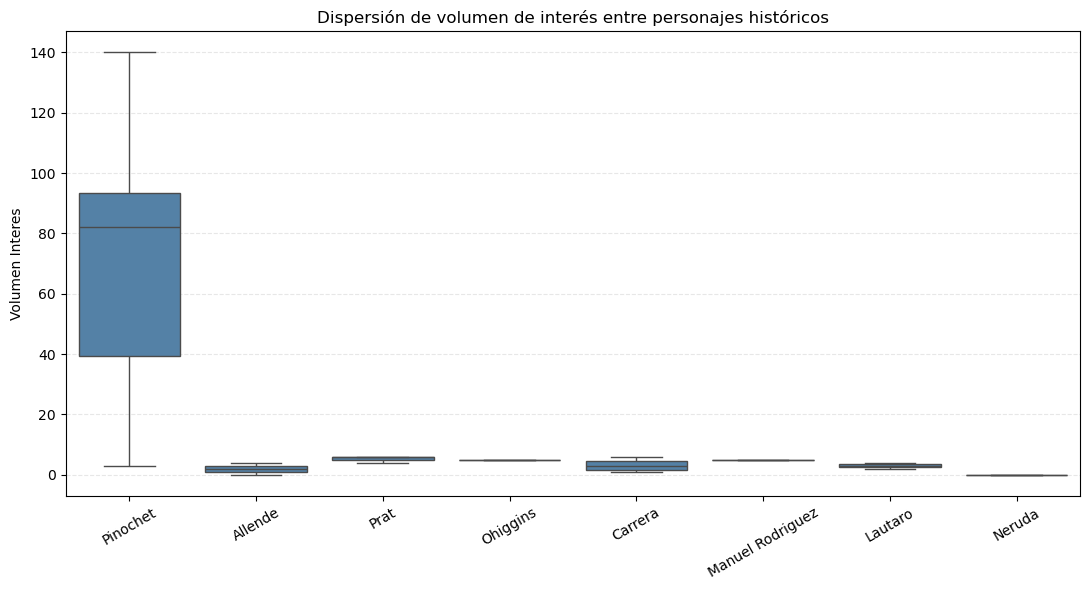

In [8]:
plot_varianzas(
    df,
    personajes,
    "volumen_interes",
    "Dispersión de volumen de interés entre personajes históricos"
)

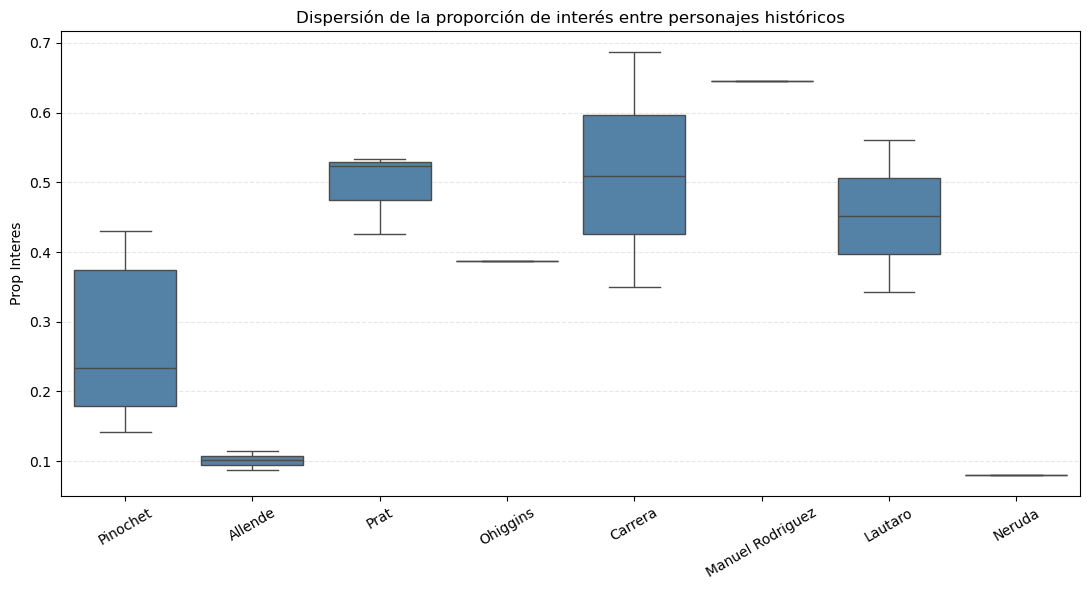

In [9]:
plot_varianzas(
    df,
    personajes,
    "prop_interes",
    "Dispersión de la proporción de interés entre personajes históricos"
)

- **Para instituciones Chilenas - Fuerzas Armadas**

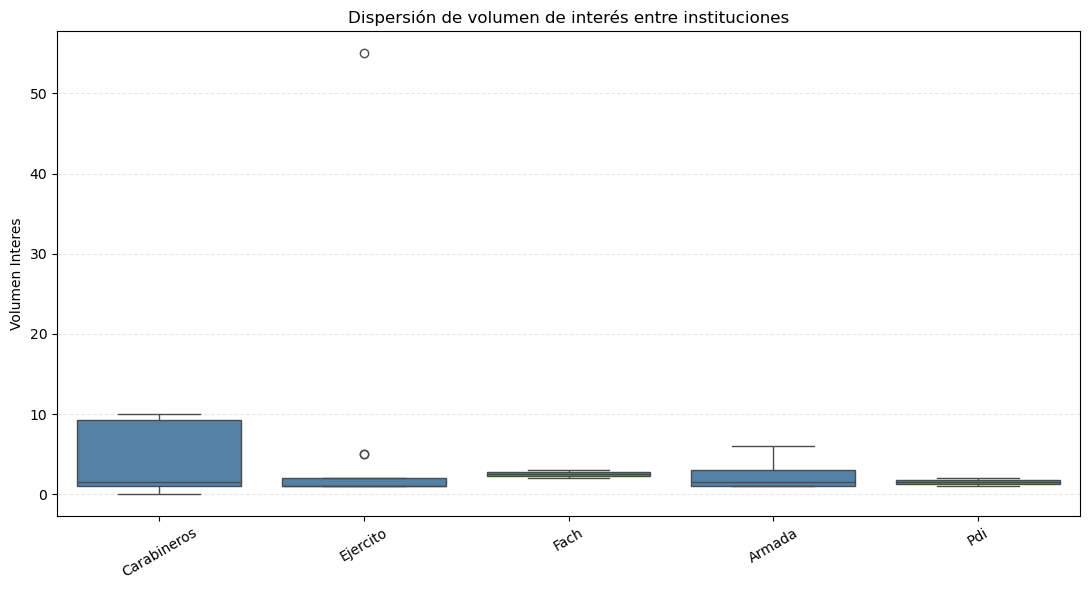

In [10]:
plot_varianzas(
    df,
    instituciones,
    "volumen_interes",
    "Dispersión de volumen de interés entre instituciones"
)

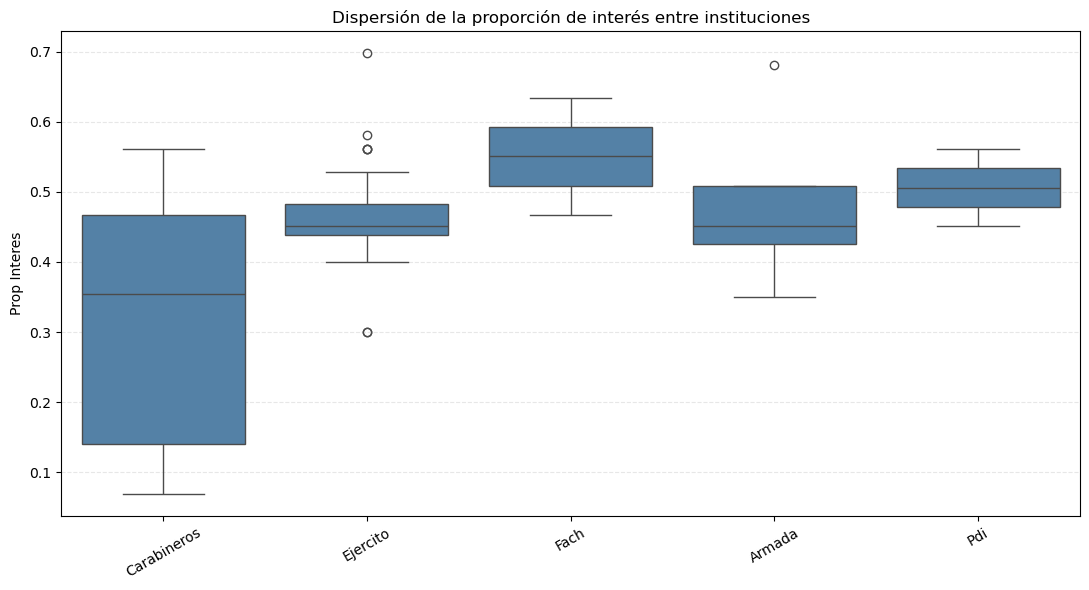

In [12]:
plot_varianzas(
    df,
    instituciones,
    "prop_interes",
    "Dispersión de la proporción de interés entre instituciones"
)

**Interpretación de la homogeneidad de varianzas**

La evaluación de la homogeneidad de varianzas se realizó mediante la prueba de Levene, complementando su interpretación con la inspección visual de los diagramas de caja. Esta combinación resulta especialmente importante, ya que el test entrega evidencia estadística sobre la igualdad de varianzas, mientras que los boxplots permiten comprender cómo se distribuye dicha variabilidad dentro de cada grupo.

En términos generales, los resultados muestran un comportamiento distinto entre las variables de volumen y las variables de proporción.

**Personajes históricos**

Para **volumen de interés comercial**, la prueba de Levene no encontró evidencia suficiente para rechazar la hipótesis de igualdad de varianzas ($p=0.284$). Sin embargo, el boxplot revela una diferencia visual importante entre las categorías: Pinochet presenta una dispersión muy superior al resto de los personajes, mientras que la mayoría de las demás categorías concentran sus observaciones cerca de cero y muestran rangos intercuartílicos muy reducidos.

Esta aparente contradicción no implica que el test esté equivocado. La prueba de Levene evalúa diferencias globales entre las dispersiones de los grupos y, bajo tamaños muestrales relativamente pequeños y distribuciones altamente concentradas en valores bajos, puede no disponer de suficiente evidencia para detectar diferencias que visualmente parecen importantes. En consecuencia, el resultado debe interpretarse como una **ausencia de evidencia estadística de heterocedasticidad**, y no como una demostración de que todas las varianzas sean efectivamente iguales.

Para **proporción de interés comercial**, tanto el test de Levene ($p=0.168$) como los boxplots entregan un panorama mucho más consistente. Aunque existen diferencias entre las medianas de algunos personajes, las dispersiones observadas son relativamente comparables, sin que ningún grupo presente una variabilidad claramente dominante respecto de los demás.

En **proporción de ruido social**, en cambio, Levene rechaza la igualdad de varianzas ($p=0.044$). Esta conclusión coincide con la evidencia visual: algunos personajes muestran distribuciones bastante estables, mientras que otros —particularmente aquellos asociados a mayor controversia política— presentan cajas considerablemente más amplias y una dispersión mucho mayor en la composición de la conversación.

**Instituciones**

En el caso del **volumen de interés comercial**, el resultado es aún más claro. La prueba de Levene arroja un valor-p muy elevado ($p=0.983$), indicando que no existe evidencia de diferencias sistemáticas entre las varianzas de las instituciones. Esta conclusión resulta coherente con los boxplots, donde la mayoría de las categorías presentan rangos intercuartílicos similares.

Aunque Ejército exhibe un valor extremo considerablemente superior al resto, dicho comportamiento corresponde principalmente a un outlier aislado. Debido a que la prueba de Levene utiliza desviaciones respecto de la mediana, su resultado es relativamente robusto frente a este tipo de observaciones extremas, por lo que la presencia de un único punto atípico no modifica sustancialmente la conclusión sobre la dispersión general de los grupos.

Por el contrario, para **proporción de interés comercial** ($p=0.0068$) y **proporción de ruido social** ($p=0.0098$), Levene detecta heterogeneidad de varianzas. Los diagramas de caja respaldan esta conclusión: instituciones como Carabineros presentan una variabilidad considerablemente mayor en la composición de sus conversaciones, mientras que Ejército, FACH o PDI muestran distribuciones mucho más concentradas. En este caso, tanto la evidencia visual como el contraste estadístico apuntan en la misma dirección.

**Conclusión metodológica**

Los resultados muestran que la interpretación de la homogeneidad de varianzas no debe basarse exclusivamente en el valor-p de la prueba de Levene ni únicamente en la inspección visual de los boxplots. Ambas herramientas son complementarias.

Cuando Levene no rechaza la hipótesis nula, la conclusión correcta es que **no existe evidencia suficiente para afirmar que las varianzas difieren**, lo cual no equivale a demostrar que sean exactamente iguales. Del mismo modo, diferencias visuales aparentes pueden deberse a tamaños muestrales reducidos, distribuciones extremadamente asimétricas o a la presencia de unos pocos valores extremos.

En este estudio, las variables de volumen presentan una fuerte concentración de observaciones en valores bajos y una marcada asimetría positiva, lo que dificulta la detección de diferencias de dispersión mediante pruebas clásicas. En cambio, las variables expresadas como proporciones muestran un comportamiento mucho más estable y permiten identificar con mayor claridad cuándo existen diferencias reales entre las categorías analizadas.

Considerando además que todas las variables rechazaron previamente el supuesto de normalidad, las etapas posteriores del análisis inferencial se desarrollarán utilizando procedimientos no paramétricos, evitando así depender de supuestos que los datos no cumplen.

### Comparación entre grupos:

Luego de evaluar los supuestos estadísticos del conjunto de datos, se observó que las variables analizadas no cumplen el supuesto de normalidad, mientras que la homogeneidad de varianzas presenta resultados mixtos dependiendo de la métrica y categoría evaluada.

Debido a estas características, la comparación entre grupos se realizará mediante métodos no paramétricos basados en rangos. En particular, se aplicará la prueba de Kruskal-Wallis para determinar si existen diferencias estadísticamente significativas entre las distribuciones de las distintas categorías analizadas.

Sin embargo, debido a que la significancia estadística depende fuertemente del tamaño muestral, especialmente en conjuntos con pocas observaciones por grupo, se complementará este análisis con el cálculo del tamaño del efecto mediante epsilon cuadrado (ε²). Esta métrica permite cuantificar la magnitud práctica de las diferencias observadas, incluso cuando estas no alcanzan significancia estadística.

El análisis buscará determinar si existen diferencias relevantes en:

- volumen de interés comercial generado por publicación;
- proporción de interés comercial dentro de la conversación;
- diferencias entre personajes históricos e instituciones.

La interpretación conjunta del valor p y del tamaño del efecto permitirá distinguir entre diferencias estadísticamente demostrables y patrones que podrían estar limitados por el tamaño de muestra.

#### Kruskal-Wallis y tamaño del efecto

In [37]:
def kruskal_epsilon(df, grupos, variable):
    """
    Ejecuta prueba de Kruskal-Wallis y calcula tamaño del efecto
    mediante epsilon cuadrado entre múltiples grupos independientes.
    """
    
    muestras = [
        df.loc[df[g] == 1, variable].dropna()
        for g in grupos
    ]

    # Eliminar grupos vacíos
    muestras = [m for m in muestras if len(m) > 0]

    # Kruskal-Wallis
    H, p = kruskal(*muestras)

    # Tamaño muestral total
    n = sum(len(m) for m in muestras)

    # Número de grupos
    k = len(muestras)

    # Epsilon cuadrado
    epsilon = (H - k + 1) / (n - k)

    return {
        "Variable": variable,
        "Kruskal H": round(H, 4),
        "p-value": round(p, 6),
        "Epsilon²": round(epsilon, 4),
        "Diferencia significativa": "Sí" if p < 0.05 else "No"
    }



# Variables a evaluar
variables = [
    "volumen_interes",
    "prop_interes",
    "volumen_ruido",
    "prop_ruido_social"
]

- **Personajes historicos**

In [40]:
# Aplicación a personajes

resultados_personajes = []

for variable in variables:
    resultados_personajes.append(
        kruskal_epsilon(
            df,
            personajes,
            variable
        )
    )


tabla_kruskal_personajes = pd.DataFrame(resultados_personajes)

tabla_kruskal_personajes

,Variable,Kruskal H,p-value,Epsilon²,Diferencia significativa
0,volumen_interes,11.6240,0.113622,0.3853,No
1,prop_interes,13.7500,0.055811,0.5625,No
2,volumen_ruido,16.1797,0.023524,0.7650,Sí
3,prop_ruido_social,14.2619,0.046714,0.6052,Sí


- **Instituciones - Fuerzas Armadas**

In [42]:
# Aplicación a instituciones

resultados_instituciones = []

for variable in variables:
    resultados_instituciones.append(
        kruskal_epsilon(
            df,
            instituciones,
            variable
        )
    )


tabla_kruskal_instituciones = pd.DataFrame(resultados_instituciones)

tabla_kruskal_instituciones

,Variable,Kruskal H,p-value,Epsilon²,Diferencia significativa
0,volumen_interes,1.9032,0.753558,-0.0599,No
1,prop_interes,5.7613,0.217695,0.0503,No
2,volumen_ruido,5.8560,0.210162,0.0530,No
3,prop_ruido_social,6.5303,0.162892,0.0723,No


**Funcion de interpretación del tamaño del efecto:**

In [43]:
def interpretar_epsilon(epsilon):
    """
    Clasifica la magnitud del efecto según epsilon cuadrado.
    """
    
    if epsilon < 0.01:
        return "Efecto trivial"
    elif epsilon < 0.06:
        return "Efecto pequeño"
    elif epsilon < 0.14:
        return "Efecto moderado"
    else:
        return "Efecto grande"


# Interpretación del tamaño del efecto
tabla_kruskal_personajes["Interpretacion_Efecto"] = (
    tabla_kruskal_personajes["Epsilon²"]
    .apply(interpretar_epsilon)
)


tabla_kruskal_instituciones["Interpretacion_Efecto"] = (
    tabla_kruskal_instituciones["Epsilon²"]
    .apply(interpretar_epsilon)
)


# Mostrar resultados completos

print("Resultados personajes históricos")
display(tabla_kruskal_personajes)


print("\nResultados instituciones")
display(tabla_kruskal_instituciones)

Resultados personajes históricos


,Variable,Kruskal H,p-value,Epsilon²,Diferencia significativa,Interpretacion_Efecto
0,volumen_interes,11.6240,0.113622,0.3853,No,Efecto grande
1,prop_interes,13.7500,0.055811,0.5625,No,Efecto grande
2,volumen_ruido,16.1797,0.023524,0.7650,Sí,Efecto grande
3,prop_ruido_social,14.2619,0.046714,0.6052,Sí,Efecto grande



Resultados instituciones


,Variable,Kruskal H,p-value,Epsilon²,Diferencia significativa,Interpretacion_Efecto
0,volumen_interes,1.9032,0.753558,-0.0599,No,Efecto trivial
1,prop_interes,5.7613,0.217695,0.0503,No,Efecto pequeño
2,volumen_ruido,5.8560,0.210162,0.0530,No,Efecto pequeño
3,prop_ruido_social,6.5303,0.162892,0.0723,No,Efecto moderado


**Interpretación conjunta: significancia estadística, tamaño del efecto y limitaciones del diseño muestral**

La comparación entre grupos mediante la prueba de Kruskal-Wallis permitió evaluar si las diferencias observadas entre categorías pueden considerarse estadísticamente significativas bajo una aproximación no paramétrica. Dado que las variables analizadas no cumplen los supuestos de normalidad y presentan características propias de datos provenientes de redes sociales —alta asimetría, concentración de valores cercanos a cero, presencia de publicaciones extremadamente influyentes y distribuciones con numerosos empates— se optó por utilizar una metodología basada en rangos.

Sin embargo, en este caso particular, los resultados de Kruskal-Wallis deben interpretarse con especial cautela. La ausencia de significancia estadística no implica necesariamente que las categorías tengan un comportamiento equivalente, sino únicamente que el contraste no cuenta con evidencia suficiente para confirmar diferencias sistemáticas bajo la estructura actual de los datos.

Para complementar el análisis se calculó epsilon cuadrado (ε²), una medida del tamaño del efecto que permite estimar la magnitud de las diferencias entre grupos independientemente del valor p obtenido. Esto resulta especialmente relevante en este proyecto, ya que una muestra pequeña puede impedir alcanzar significancia estadística incluso cuando existen diferencias descriptivas importantes entre categorías.

Es importante separar dos conceptos:

- **Significancia estadística:** indica si existe suficiente evidencia para rechazar que los grupos presentan distribuciones equivalentes.
- **Tamaño del efecto:** indica qué tan grande es la diferencia observada entre grupos.

Por lo tanto, es posible encontrar efectos grandes sin significancia estadística cuando la muestra es pequeña o altamente variable. En este contexto, los resultados deben interpretarse como evidencia exploratoria y no como una prueba definitiva de causalidad o superioridad comercial entre categorías.


---

**Limitaciones estructurales del contraste entre categorías**

Antes de interpretar los resultados específicos, es necesario considerar una limitación fundamental del dataset.

Como se vió en la sección `Exploratory Data Analysis / Estadísticas descriptivas / Distribuciones por temática`, las publicaciones analizadas no corresponden a una muestra aleatoria de personajes históricos o instituciones. Por el contrario, representan un catálogo generado bajo decisiones comerciales reales.

El número de publicaciones disponibles para cada categoría probablemente está influenciado por factores previos asociados al negocio:

- diseños que históricamente han tenido mejor recepción pueden haber generado más publicaciones;
- personajes o instituciones con mayor reconocimiento pueden haber sido explorados con mayor frecuencia;
- categorías con bajo desempeño comercial pueden haber dejado de producir nuevos modelos;
- la cantidad de publicaciones puede reflejar una decisión previa basada en percepción de demanda.

Por esta razón, el análisis no responde exactamente a la pregunta:

> "¿Qué personaje o institución genera más interés comercial?"

Sino una pregunta más acotada:

> "Dentro de los diseños que fueron publicados por la empresa, ¿qué patrones de interacción comercial y social se observan entre las categorías disponibles?"

Esta diferencia es crítica, ya que existe un potencial sesgo de selección. Por ejemplo, que Pinochet posea más publicaciones que Neruda puede deberse a múltiples explicaciones:

- mayor atractivo comercial real;
- mayor cantidad de diseños creados debido a una demanda percibida;
- mayor experimentación por parte del negocio;
- una combinación de estos factores.

Con los datos disponibles no es posible separar completamente estos mecanismos ni establecer causalidad directa entre la temática y el desempeño comercial.


---

**Personajes históricos: diferencias claras en dinámica social y señales comerciales potenciales**

En el bloque de personajes históricos se observan los efectos más relevantes del análisis.

Las métricas asociadas al ruido social presentan diferencias estadísticamente significativas entre categorías:

| Variable | H | p-value | ε² |
|---|---:|---:|---:|
| volumen_ruido | 16.18 | 0.0235 | 0.765 |
| prop_ruido_social | 14.26 | 0.0467 | 0.605 |

Estos resultados indican que existe evidencia estadística para afirmar que los personajes históricos no generan exactamente la misma dinámica de conversación no comercial.

Además, los tamaños de efecto son elevados, sugiriendo que las diferencias observadas no solamente son producto de pequeñas variaciones aleatorias.

Este resultado es consistente con el análisis exploratorio previo, donde determinadas figuras asociadas a mayor carga política o emocional concentraban mayores niveles de polarización, fanatismo y conversación no comercial.

Por lo tanto, dentro de las limitaciones del dataset, existe evidencia robusta de que la temática del personaje influye en la composición social de la conversación.


---

En contraste, las variables asociadas directamente al interés comercial presentan tamaños de efecto elevados, pero no alcanzan significancia estadística:

| Variable | H | p-value | ε² |
|---|---:|---:|---:|
| volumen_interes | 11.62 | 0.1136 | 0.385 |
| prop_interes | 13.75 | 0.0558 | 0.563 |

Este resultado requiere una interpretación cuidadosa.

Los valores de ε² sugieren que las diferencias entre personajes podrían ser comercialmente relevantes. Sin embargo, el contraste estadístico no permite afirmar que dichas diferencias sean sistemáticas bajo la muestra actual.

La principal explicación probable se encuentra en la estructura de los datos:

- varias categorías poseen únicamente una o dos publicaciones;
- existen publicaciones con niveles de interacción extraordinariamente superiores al resto;
- la distribución del interés comercial está dominada por pocos eventos de alto impacto.

Por ejemplo, una categoría puede mostrar un rendimiento comercial superior debido a una publicación excepcionalmente exitosa, pero con pocas observaciones disponibles resulta imposible determinar si dicho comportamiento representa una tendencia general o simplemente un evento puntual.

En consecuencia, la evidencia permite afirmar con mayor confianza que existen diferencias en la dinámica social generada por los personajes, mientras que las diferencias comerciales requieren validación mediante modelos adicionales que incorporen otros factores explicativos.


---

**Instituciones: ausencia de diferencias globales, pero interpretación limitada por la estructura del dataset**

En el bloque institucional, Kruskal-Wallis no encontró diferencias estadísticamente significativas en ninguna de las variables evaluadas:

| Variable | H | p-value | ε² |
|---|---:|---:|---:|
| volumen_interes | 1.90 | 0.7536 | ≈0 |
| prop_interes | 5.76 | 0.2177 | 0.050 |
| volumen_ruido | 5.86 | 0.2102 | 0.053 |
| prop_ruido_social | 6.53 | 0.1629 | 0.072 |

A primera vista, estos resultados podrían sugerir que las instituciones presentan comportamientos similares. Sin embargo, esta interpretación sería demasiado fuerte considerando las características del dataset.

Kruskal-Wallis responde una pregunta global:

> "¿Existe evidencia de que al menos una institución presenta una distribución diferente al resto?"

No responde directamente:

> "¿Existe una institución específica que tenga mejor desempeño comercial que otra?"

Además, la capacidad del test está limitada por la distribución altamente desbalanceada de observaciones:

- Ejército: 24 publicaciones.
- Carabineros: 8 publicaciones.
- Armada: 4 publicaciones.
- Fach: 2 publicaciones.
- PDI: 2 publicaciones.

Comparar categorías con tamaños tan diferentes reduce la capacidad estadística para detectar diferencias reales, especialmente cuando algunos grupos poseen únicamente una o dos observaciones.

Adicionalmente, las métricas de interacción digital presentan una estructura compleja:

- gran cantidad de publicaciones con valores bajos;
- pocos eventos extremadamente exitosos;
- alta variabilidad natural entre publicaciones.

Por ejemplo, una publicación excepcionalmente exitosa de una institución puede ser muy relevante desde una perspectiva comercial, pero no necesariamente modifica la distribución completa del grupo frente al resto de categorías.


---

**Implicancia para la interpretación del negocio**

Los resultados obtenidos no deben interpretarse como evidencia de que todas las categorías poseen el mismo potencial comercial.

La conclusión más rigurosa es:

- El bloque histórico presenta evidencia estadística clara de diferencias en la generación de ruido social y señales de que podrían existir diferencias comerciales relevantes.
- El bloque institucional no presenta diferencias globales confirmadas, pero esto debe interpretarse considerando las fuertes limitaciones de tamaño muestral, desbalance entre categorías y naturaleza no aleatoria del catálogo.
- Los tamaños de efecto sugieren que algunas diferencias observadas podrían ser relevantes desde una perspectiva práctica, aunque no puedan ser confirmadas estadísticamente con la información disponible.

En este punto, los contrastes entre grupos permiten caracterizar patrones descriptivos, pero no explican por sí solos qué factores determinan el interés comercial.


---

**Próximos pasos del análisis**

Debido a las limitaciones identificadas, el análisis continuará mediante metodologías que permitan utilizar la información disponible de forma más adecuada:

1. **Comparaciones post-hoc exploratorias**
   
   Se realizarán comparaciones por pares mediante pruebas de Dunn con corrección por comparaciones múltiples. Sin embargo, sus resultados serán interpretados con cautela debido al reducido tamaño de algunas categorías.

2. **Modelos multivariables**

   Se desarrollarán modelos orientados a responder la pregunta principal del negocio:

> "¿Qué características de una publicación aumentan la generación de interés comercial?"

Estos modelos permitirán controlar simultáneamente factores como:

- volumen total de conversación;
- ruido social;
- polarización;
- tipo de producto;
- presencia de producto materializado;
- temática histórica o institucional.

De esta manera se podrá avanzar desde una comparación descriptiva entre categorías hacia una estimación más cercana al efecto propio de cada característica sobre el interés comercial.

#### Análisis exploratorio post-hoc

Se realizaron comparaciones post-hoc exploratorias; sin embargo, debido al fuerte desbalance entre categorías y el reducido número de observaciones en varios grupos, los resultados presentan baja potencia estadística y no permiten extraer conclusiones definitivas a nivel de pares.

**Función general para Dunn**:

In [46]:
def ejecutar_dunn(df, grupos, variable, metodo="holm"):
    """
    Ejecuta prueba post-hoc de Dunn entre múltiples grupos.

    Parámetros
    ----------
    df : DataFrame
        Dataset con las variables y grupos.
        
    grupos : lista
        Lista de columnas binarias que representan categorías.
        
    variable : str
        Métrica a comparar.
        
    metodo : str
        Método de corrección por múltiples comparaciones.

    Retorna
    -------
    DataFrame con p-values ajustados entre pares.
    """
    
    datos = []

    for grupo in grupos:
        
        valores = df.loc[
            df[grupo] == 1,
            variable
        ].dropna()

        for valor in valores:
            datos.append({
                "grupo": grupo.replace("post_", "").replace("_"," ").title(),
                "valor": valor
            })


    df_dunn = pd.DataFrame(datos)


    resultado = sp.posthoc_dunn(
        df_dunn,
        val_col="valor",
        group_col="grupo",
        p_adjust=metodo
    )

    return resultado

- **Para personajes históricos:**

In [47]:
variables_posthoc = [
    "prop_interes",
    "volumen_interes",
    "prop_ruido_social",
    "volumen_ruido"
]


resultados_dunn_personajes = {}


for variable in variables_posthoc:

    resultados_dunn_personajes[variable] = ejecutar_dunn(
        df,
        personajes,
        variable
    )

    print("\n==========================")
    print(variable)
    print("==========================")

    display(
        resultados_dunn_personajes[variable]
    )


prop_interes


,Allende,Carrera,Lautaro,Manuel Rodriguez,Neruda,Ohiggins,Pinochet,Prat
Allende,1.000000,0.359147,1.0,0.614879,1.000000,1.0,1.0,0.739544
Carrera,0.359147,1.000000,1.0,1.000000,0.780225,1.0,1.0,1.000000
Lautaro,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000
Manuel Rodriguez,0.614879,1.000000,1.0,1.000000,0.780225,1.0,1.0,1.000000
Neruda,1.000000,0.780225,1.0,0.780225,1.000000,1.0,1.0,1.000000
Ohiggins,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000
Pinochet,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000
Prat,0.739544,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000



volumen_interes


,Allende,Carrera,Lautaro,Manuel Rodriguez,Neruda,Ohiggins,Pinochet,Prat
Allende,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.612092,1.0
Carrera,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.650612,1.0
Lautaro,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0
Manuel Rodriguez,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0
Neruda,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.612092,1.0
Ohiggins,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0
Pinochet,0.612092,0.650612,1.0,1.0,0.612092,1.0,1.000000,1.0
Prat,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0



prop_ruido_social


,Allende,Carrera,Lautaro,Manuel Rodriguez,Neruda,Ohiggins,Pinochet,Prat
Allende,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.0
Carrera,1.0,1.000000,1.0,1.000000,0.857343,1.0,0.648227,1.0
Lautaro,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.0
Manuel Rodriguez,1.0,1.000000,1.0,1.000000,0.648227,1.0,0.843904,1.0
Neruda,1.0,0.857343,1.0,0.648227,1.000000,1.0,1.000000,1.0
Ohiggins,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.0
Pinochet,1.0,0.648227,1.0,0.843904,1.000000,1.0,1.000000,1.0
Prat,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.0



volumen_ruido


,Allende,Carrera,Lautaro,Manuel Rodriguez,Neruda,Ohiggins,Pinochet,Prat
Allende,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0
Carrera,1.0,1.000000,1.000000,1.000000,1.0,1.0,0.018492,1.0
Lautaro,1.0,1.000000,1.000000,1.000000,1.0,1.0,0.467908,1.0
Manuel Rodriguez,1.0,1.000000,1.000000,1.000000,1.0,1.0,0.541784,1.0
Neruda,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0
Ohiggins,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0
Pinochet,1.0,0.018492,0.467908,0.541784,1.0,1.0,1.000000,1.0
Prat,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0


- **Para Instituciones - Fuerzas Armadas:**

In [48]:
variables_posthoc = [
    "prop_interes",
    "volumen_interes",
    "prop_ruido_social",
    "volumen_ruido"
]


resultados_dunn_personajes = {}


for variable in variables_posthoc:

    resultados_dunn_personajes[variable] = ejecutar_dunn(
        df,
        personajes,
        variable
    )

    print("\n==========================")
    print(variable)
    print("==========================")

    display(
        resultados_dunn_personajes[variable]
    )


prop_interes


,Allende,Carrera,Lautaro,Manuel Rodriguez,Neruda,Ohiggins,Pinochet,Prat
Allende,1.000000,0.359147,1.0,0.614879,1.000000,1.0,1.0,0.739544
Carrera,0.359147,1.000000,1.0,1.000000,0.780225,1.0,1.0,1.000000
Lautaro,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000
Manuel Rodriguez,0.614879,1.000000,1.0,1.000000,0.780225,1.0,1.0,1.000000
Neruda,1.000000,0.780225,1.0,0.780225,1.000000,1.0,1.0,1.000000
Ohiggins,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000
Pinochet,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000
Prat,0.739544,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000



volumen_interes


,Allende,Carrera,Lautaro,Manuel Rodriguez,Neruda,Ohiggins,Pinochet,Prat
Allende,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.612092,1.0
Carrera,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.650612,1.0
Lautaro,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0
Manuel Rodriguez,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0
Neruda,1.000000,1.000000,1.0,1.0,1.000000,1.0,0.612092,1.0
Ohiggins,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0
Pinochet,0.612092,0.650612,1.0,1.0,0.612092,1.0,1.000000,1.0
Prat,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.0



prop_ruido_social


,Allende,Carrera,Lautaro,Manuel Rodriguez,Neruda,Ohiggins,Pinochet,Prat
Allende,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.0
Carrera,1.0,1.000000,1.0,1.000000,0.857343,1.0,0.648227,1.0
Lautaro,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.0
Manuel Rodriguez,1.0,1.000000,1.0,1.000000,0.648227,1.0,0.843904,1.0
Neruda,1.0,0.857343,1.0,0.648227,1.000000,1.0,1.000000,1.0
Ohiggins,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.0
Pinochet,1.0,0.648227,1.0,0.843904,1.000000,1.0,1.000000,1.0
Prat,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.0



volumen_ruido


,Allende,Carrera,Lautaro,Manuel Rodriguez,Neruda,Ohiggins,Pinochet,Prat
Allende,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0
Carrera,1.0,1.000000,1.000000,1.000000,1.0,1.0,0.018492,1.0
Lautaro,1.0,1.000000,1.000000,1.000000,1.0,1.0,0.467908,1.0
Manuel Rodriguez,1.0,1.000000,1.000000,1.000000,1.0,1.0,0.541784,1.0
Neruda,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0
Ohiggins,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0
Pinochet,1.0,0.018492,0.467908,0.541784,1.0,1.0,1.000000,1.0
Prat,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0


**Funcion para extraer diferencias significativas:**

In [49]:
def extraer_significativos(tabla, alpha=0.05):
    """
    Extrae comparaciones post-hoc con diferencias significativas.
    """

    resultados = []

    for grupo1 in tabla.index:

        for grupo2 in tabla.columns:

            if grupo1 < grupo2:

                p = tabla.loc[grupo1, grupo2]

                if p < alpha:

                    resultados.append({
                        "Grupo 1": grupo1,
                        "Grupo 2": grupo2,
                        "p_adjust": p
                    })


    return pd.DataFrame(resultados)

In [53]:
# ============================
# Distribución publicaciones por institución
# ============================


instituciones = [
    "post_carabineros",
    "post_ejercito",
    "post_fach",
    "post_armada",
    "post_pdi"
]


distribucion_instituciones = (
    pd.DataFrame({
        "institucion": [
            i.replace("post_", "").replace("_", " ").title()
            for i in instituciones
        ],
        "n_publicaciones": [
            df[df[i] == 1].shape[0]
            for i in instituciones
        ]
    })
    .sort_values(
        "n_publicaciones",
        ascending=False
    )
)


distribucion_instituciones

,institucion,n_publicaciones
1,Ejercito,24
0,Carabineros,8
3,Armada,4
2,Fach,2
4,Pdi,2


In [50]:
extraer_significativos(
    resultados_dunn_personajes["prop_ruido_social"]
)

""


**Conclusión de análisis exploratorio post-hoc:**
Los contrastes post-hoc no identificaron diferencias robustas después de la corrección por múltiples comparaciones. Esto no debe interpretarse como ausencia de diferencias entre categorías, sino como consecuencia esperable de un diseño altamente desbalanceado, donde varias categorías poseen tamaños muestrales insuficientes para estimar adecuadamente sus distribuciones.

In [83]:
modelo = smf.ols(

    "volumen_interes ~ volumen_total",

    data=df

).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        volumen_interes   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     917.1
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           1.66e-66
Time:                        23:45:11   Log-Likelihood:                -505.95
No. Observations:                 155   AIC:                             1016.
Df Residuals:                     153   BIC:                             1022.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.6117      0.525      3.072

## Modelos explicativos del interés comercial

Luego de caracterizar las diferencias entre categorías mediante pruebas no paramétricas, el siguiente objetivo consiste en avanzar desde un análisis descriptivo hacia un modelo explicativo que permita identificar qué factores se encuentran asociados con una mayor generación de interés comercial.

Las correlaciones exploratorias permitieron identificar relaciones relevantes entre variables como viralidad, ruido social, polarización e interés comercial. Sin embargo, estas asociaciones no permiten determinar si una variable presenta un efecto propio o si simplemente refleja la influencia de un tercer factor, como el volumen total de interacción.

Por ejemplo, una publicación con alta viralidad puede generar simultáneamente más comentarios comerciales y más comentarios polarizados. En este caso, una correlación positiva entre ambas variables no implica necesariamente que la polarización aumente el interés comercial.

Para abordar estas limitaciones, se desarrollarán modelos multivariables que permitan evaluar el aporte individual de cada variable explicativa controlando simultáneamente por otros factores.

Las preguntas principales que se buscará responder son:

- ¿El volumen total de conversación explica un mayor interés comercial una vez controlado el resto de variables?
- ¿El ruido social actúa como un potenciador del interés comercial o solamente acompaña publicaciones más virales?
- ¿La proporción de interés comercial depende principalmente del tipo de producto o temática?
- ¿Las publicaciones materializadas presentan ventajas frente a publicaciones conceptuales?
- ¿Existen variables que permitan anticipar qué publicaciones tienen mayor probabilidad de generar interacción comercial?

Debido a la naturaleza de las variables objetivo, caracterizadas por distribuciones asimétricas, exceso de ceros y métricas acotadas, se evaluarán modelos estadísticos adecuados para datos de conteo y proporciones antes de seleccionar la metodología final.

In [3]:
#Cargamos dataset con personajes historicos desagregados desde Gold
df = pd.read_parquet(
    "data/gold/gold_post_personajes_historicos_analysis.parquet"
)

print(df.shape)
df.head()

(155, 38)


,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_fanatismo_no_comercial,...,post_personajes_historicos,post_pinochet,post_allende,post_prat,post_ohiggins,post_carrera,post_manuel_rodriguez,post_lautaro,post_neruda,post_mistral
0,154787275135903_1003489410265681,grumete de la marina chilena,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,154787275135903_1029896382473424,diseno 3d de mujer montanes del ejercito de ch...,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,154787275135903_1030709625725433,none,4,4,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,154787275135903_1033619428767786,diseno 3d en homenaje a pastelitodechile y agu...,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,154787275135903_1038284206786201,lautaro. 3d art mapuche chile 3dprinting,2,2,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0


### Diagnostico de variable objetivo

Antes de construir modelos explicativos del interés comercial, es necesario caracterizar estadísticamente la variable que se busca modelar. La elección del modelo depende directamente de la naturaleza de la variable objetivo, su distribución, presencia de valores extremos, cantidad de ceros y relación entre sus principales momentos estadísticos.

En esta etapa se analizarán separadamente las dos métricas principales de interés comercial:

- `volumen_interes`: representa la cantidad absoluta de comentarios asociados a intención comercial y corresponde a una variable de conteo.
- `prop_interes`: representa la eficiencia relativa de generación de interés comercial dentro de la conversación total y corresponde a una variable acotada entre 0 y 1.

Este diagnóstico permitirá determinar qué familias de modelos son adecuadas para cada caso y evitar aplicar supuestos estadísticos incompatibles con la estructura real de los datos.

In [59]:
# Diagnóstico variable objetivo

variables_objetivo = [
    "volumen_interes",
    "prop_interes"
]


for var in variables_objetivo:
    
    print("="*50)
    print(var)
    print("="*50)
    
    print(df[var].describe())
    
    print("\nCantidad de ceros:")
    print((df[var] == 0).sum())
    
    print("\nPorcentaje de ceros:")
    print(
        round(
            (df[var] == 0).mean()*100,
            2
        ),
        "%"
    )
    
    print("\nValores únicos:")
    print(df[var].nunique())
    
    print("\n")

volumen_interes
count    155.000000
mean       5.116129
std       16.794385
min        0.000000
25%        1.000000
50%        1.000000
75%        3.000000
max      140.000000
Name: volumen_interes, dtype: float64

Cantidad de ceros:
26

Porcentaje de ceros:
16.77 %

Valores únicos:
15


prop_interes
count    155.000000
mean       0.378481
std        0.160738
min        0.068819
25%        0.240262
50%        0.386969
75%        0.451133
max        0.817044
Name: prop_interes, dtype: float64

Cantidad de ceros:
0

Porcentaje de ceros:
0.0 %

Valores únicos:
56




**Diagnóstico de sobredispersión en la variable volumen_interes**

Dado que `volumen_interes` corresponde a una variable de conteo, inicialmente se evalúa si cumple los supuestos necesarios para utilizar modelos clásicos de conteo, como la regresión de Poisson.

Un supuesto fundamental de la distribución Poisson es la igualdad aproximada entre la media y la varianza de la variable. Cuando la varianza supera ampliamente a la media, se presenta un fenómeno conocido como sobredispersión, indicando que existe una variabilidad adicional que no puede ser explicada por un modelo Poisson convencional.

Por esta razón, se analizará la relación entre la media y la varianza de `volumen_interes` para determinar si resulta más apropiado utilizar modelos alternativos, como regresión Binomial Negativa o modelos con exceso de ceros (Zero-Inflated), capaces de representar distribuciones con alta dispersión y presencia de publicaciones con comportamiento excepcional.

In [60]:
# Diagnóstico sobredispersión
media = df["volumen_interes"].mean()
varianza = df["volumen_interes"].var()

print("Media:", media)
print("Varianza:", varianza)

print("\nRelación varianza/media:")
print(varianza/media)

Media: 5.116129032258065
Varianza: 282.05136154168395

Relación varianza/media:
55.12983737573898


### Selección de variables para el modelo explicativo

La construcción del modelo no se realizó incorporando todas las variables disponibles de forma indiscriminada, sino mediante un proceso de selección guiado tanto por criterios estadísticos como por criterios conceptuales asociados a la pregunta de investigación.

En primer lugar, se descartaron variables cuya inclusión hubiera introducido **multicolinealidad estructural**. En particular, no se incorporaron métricas derivadas o construidas directamente a partir de otras variables presentes en el modelo. Por ejemplo, `volumen_senal` fue excluida porque está compuesta por la suma de `volumen_interes`, `volumen_elogios`, `volumen_criticas` y `volumen_solicitudes`, incorporando incluso la propia variable objetivo. De forma similar, se evitó incluir simultáneamente todas las proporciones de interacción, ya que representan partes de una misma distribución y, al ser mutuamente excluyentes, presentan una fuerte dependencia matemática que puede generar colinealidad.

En segundo lugar, se decidió utilizar **`volumen_total`** como indicador de la intensidad global de la conversación, descartando `volumen_ruido`. Si bien ambas variables contienen información relacionada, `volumen_total` permite representar el nivel general de interacción generado por una publicación sin concentrarse únicamente en la componente de ruido. Esta elección facilita interpretar si una mayor actividad en torno a una publicación se asocia con un incremento del interés comercial, mientras que la calidad de dicha conversación queda representada mediante las variables proporcionales.

Las variables de proporción (`prop_interes`, `prop_ruido_social` y `prop_elogios`) fueron incorporadas porque representan una dimensión distinta a los volúmenes absolutos. Mientras los volúmenes describen **cuántos** comentarios pertenecen a una determinada categoría, las proporciones reflejan **cómo se distribuye** la conversación. En otras palabras, constituyen una medida de la composición o "calidad" de las interacciones.

Por ejemplo:

- `volumen_total` representa la intensidad o magnitud de la conversación generada por una publicación.
- `prop_interes` representa la eficiencia comercial de esa conversación, es decir, qué fracción de los comentarios corresponde efectivamente a manifestaciones de interés.
- `prop_ruido_social` refleja qué proporción de la conversación estuvo dominada por interacciones no comerciales (polarización, fanatismo no comercial o discusión social).
- `prop_elogios` permite evaluar si una conversación con mayor proporción de elogios dirigidos exclusivamente a la calidad del producto favorece la generación de interés comercial.

Esta distinción resulta especialmente relevante considerando los hallazgos obtenidos durante el análisis exploratorio, donde se observó que publicaciones extremadamente virales no necesariamente generan una mayor eficiencia comercial. De hecho, en varios casos el aumento del volumen total estuvo acompañado por un incremento aún mayor del ruido social, reduciendo proporcionalmente la participación de comentarios de interés.

Finalmente, se incorporaron variables binarias correspondientes a **instituciones**, **personajes históricos** y **presencia de producto materializado**, con el propósito de controlar el efecto propio de cada temática sobre el interés comercial. De este modo, el modelo permitirá evaluar si las diferencias observadas en el interés pueden atribuirse únicamente al volumen y composición de la conversación o si determinadas categorías presentan un comportamiento diferencial una vez controladas las demás variables.

En consecuencia, el objetivo del modelo no es únicamente identificar asociaciones estadísticas, sino responder preguntas de negocio tales como:

- ¿Una conversación más intensa genera necesariamente un mayor volumen de interés comercial?
- ¿Una conversación con mayor proporción de ruido social disminuye el interés comercial aun cuando la publicación sea muy viral?
- ¿Las publicaciones con una mayor proporción de comentarios de interés presentan también un mayor volumen absoluto de interés?
- ¿Existen personajes o instituciones que mantienen un efecto propio sobre el interés comercial incluso después de controlar la intensidad y composición de la conversación?

Estas preguntas permitirán avanzar desde un análisis meramente descriptivo hacia una comprensión más profunda de los factores asociados al rendimiento comercial de las publicaciones.

In [5]:
# Variables para el modelo de volumen de interés

variables_modelo = [

    # Variable objetivo
    "volumen_interes",

    # Componentes del ruido
    "prop_ruido_social",
    
    # Componentes comerciales (sin usar volumen_senal)
    "prop_elogios",
   
    # Variable de negocio
    "post_producto_materializado",

    # Instituciones
    "post_carabineros",
    "post_ejercito",
    "post_fach",
    "post_armada",
    "post_pdi",

    # Personajes
    "post_pinochet",
    "post_allende",
    "post_prat",
    "post_ohiggins",
    "post_carrera",
    "post_manuel_rodriguez",
    "post_lautaro",
    "post_neruda"
]

df_modelo = df[variables_modelo].copy()

df_modelo.head()

,volumen_interes,prop_ruido_social,prop_elogios,post_producto_materializado,post_carabineros,post_ejercito,post_fach,post_armada,post_pdi,post_pinochet,post_allende,post_prat,post_ohiggins,post_carrera,post_manuel_rodriguez,post_lautaro,post_neruda
0,1,0.413426,0.095621,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0.413426,0.345621,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,4,0.379100,0.054640,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0.413426,0.345621,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2,0.330741,0.076496,0,0,0,0,0,0,0,0,0,0,0,0,1,0


**Análisis de multicolinealidad entre variables**

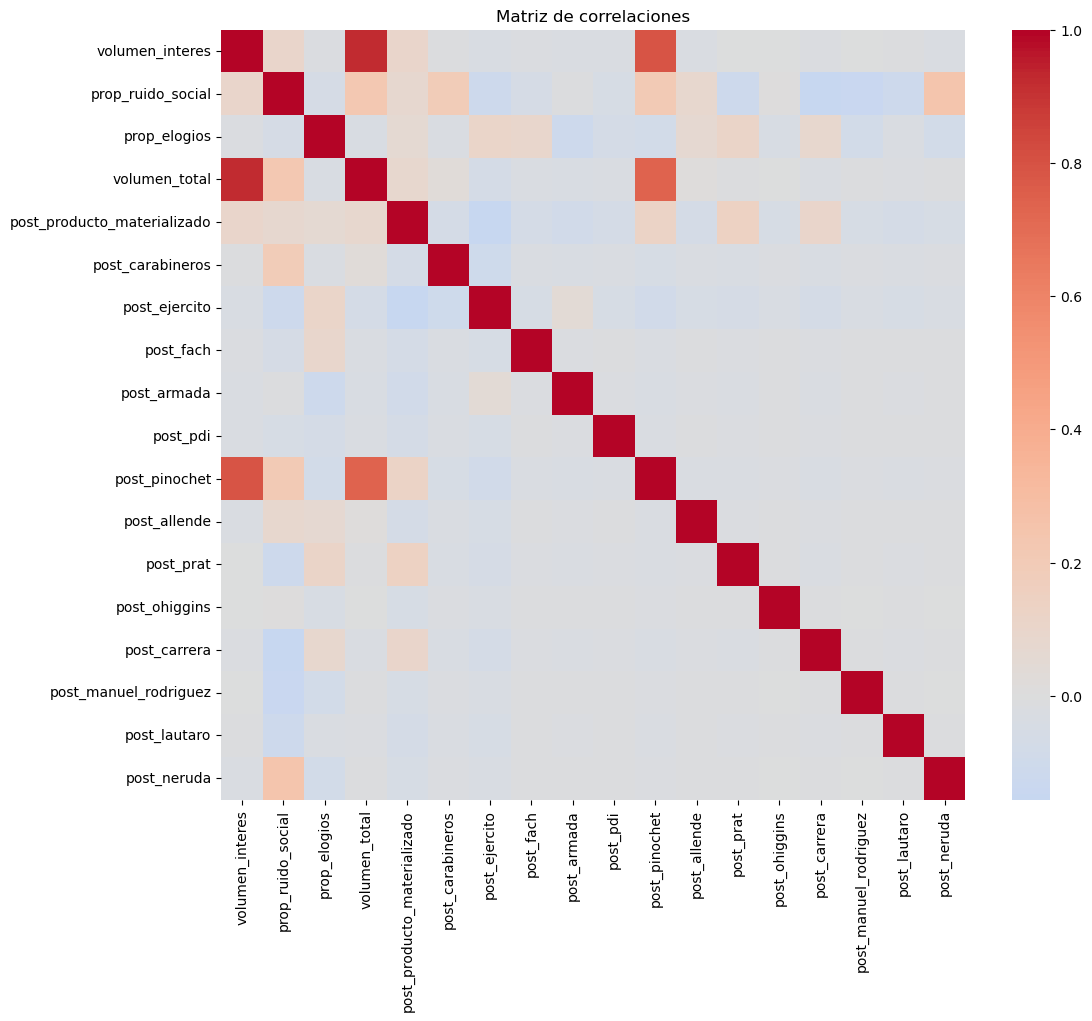

In [30]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df_modelo.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlaciones")
plt.show()

In [31]:
X = df_modelo.drop(columns="volumen_interes")

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif.sort_values("VIF", ascending=False)

,Variable,VIF
0,prop_ruido_social,3.352176
1,prop_elogios,2.782011
9,post_pinochet,2.396971
2,volumen_total,2.369206
3,post_producto_materializado,1.466825
5,post_ejercito,1.257103
4,post_carabineros,1.141884
11,post_prat,1.070787
16,post_neruda,1.068772
13,post_carrera,1.059100


**Interpretación:** Los factores de inflación de la varianza (VIF) son bajos para todas las variables, con un máximo de 3.35 para prop_ruido_social, valor considerablemente inferior a los umbrales comúnmente utilizados para indicar multicolinealidad preocupante (5 o 10). En consecuencia, no se observa evidencia de problemas importantes de colinealidad entre las variables explicativas, por lo que todas pueden incorporarse al modelo sin esperar un incremento sustancial en la varianza de sus estimadores.

### Regresión de Poisson (Modelo Base)

Como primera aproximación para explicar el volumen de interés comercial (`volumen_interes`), se ajustó un Modelo Lineal Generalizado (GLM) con distribución de Poisson y enlace logarítmico.

La regresión de Poisson constituye el punto de partida natural para modelar variables de conteo, ya que asume que el número esperado de eventos depende exponencialmente de las variables explicativas.

En este contexto, el modelo busca estimar cómo la composición de la conversación (ruido social), la materialización del producto y las distintas temáticas abordadas influyen sobre el volumen esperado de comentarios de interés comercial.

Posteriormente se evaluará si los supuestos de este modelo son adecuados para los datos observados.

In [37]:
# Fórmula del modelo

formula_poisson = """

volumen_interes ~

prop_ruido_social +

post_producto_materializado +

post_carabineros +
post_ejercito +
post_fach +
post_armada +
post_pdi +

post_pinochet +
post_allende +
post_prat +
post_ohiggins +
post_carrera +
post_manuel_rodriguez +
post_lautaro +
post_neruda

"""

In [52]:
modelo_poisson = smf.glm(
    formula=formula_poisson,
    data=df_modelo,
    family=sm.families.Poisson()
)

resultado_poisson = modelo_poisson.fit()

In [53]:
resultado_poisson.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:        volumen_interes   No. Observations:                  155
Model:                            GLM   Df Residuals:                      139
Model Family:                 Poisson   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -509.03
Date:                Tue, 14 Jul 2026   Deviance:                       661.76
Time:                        23:33:12   Pearson chi2:                     864.
No. Iterations:                    21   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       1.2692      0.132      9.636      0.000       1.011       1.527
prop_ruido_social              -1.8274      0.289     -6.324      0.000      -2.394      -1.261
post_producto_materializado     0.2742      0.085      3.245      0.001       0.109       0.440
post_carabineros                1.0881      0.190      5.724      0.000       0.716       1.461
post_ejercito                   0.7730      0.128      6.025      0.000       0.522       1.024
post_fach                       0.2914      0.454      0.642      0.521      -0.599       1.182
post_armada                     0.1378      0.323      0.427      0.670      -0.495       0.771
post_pdi                       -0.1867      0.583     -0.320      0.749      -1.329       0.956
post_pinochet                   3.8942      0.098     39.900      0.000       3.703       4.085
post_allende                    0.4095      0.509      0.805      0.421      -0.588       1.407
post_prat                       0.8000      0.265      3.017      0.003       0.280       1.320
post_ohiggins                   1.1508      0.455      2.530      0.011       0.259       2.042
post_carrera                    0.3079      0.291      1.059      0.289      -0.262       0.878
post_manuel_rodriguez           0.6760      0.457      1.479      0.139      -0.220       1.572
post_lautaro                    0.3680      0.416      0.884      0.377      -0.448       1.184
post_neruda                   -19.7486   1.38e+04     -0.001      0.999    -2.7e+04     2.7e+04
===============================================================================================
"""

In [49]:
print(f"AIC    : {modelo_poisson.aic:.2f}")
print(f"BIC    : {modelo_poisson.bic_llf:.2f}")
print(f"LogLik : {modelo_poisson.llf:.2f}")

print("\n")

print(f"Deviance            : {modelo_poisson.deviance:.2f}")
print(f"Pearson Chi2        : {modelo_poisson.pearson_chi2:.2f}")
print(f"Grados de libertad  : {modelo_poisson.df_resid}")

AIC    : 1050.06
BIC    : 1098.75
LogLik : -509.03


Deviance            : 661.76
Pearson Chi2        : 864.24
Grados de libertad  : 139


 **Evaluamos sobredispersión del modelo (Pearson chi^2 / gl):**

In [36]:
dispersion = modelo_poisson.pearson_chi2 / modelo_poisson.df_resid

print(f"Índice de dispersión: {dispersion:.3f}")

if dispersion > 1.5:
    print("Existe evidencia de sobredispersión.")
else:
    print("No se observa sobredispersión importante.")

Índice de dispersión: 2.812
Existe evidencia de sobredispersión.


**Interpretación del Modelo de Poisson**

El modelo de Poisson permitió obtener una primera aproximación a los factores asociados al volumen de interés comercial. Los coeficientes estimados muestran resultados coherentes con el análisis exploratorio previo: una mayor proporción de ruido social se asocia a una disminución del interés comercial esperado, mientras que la publicación de productos materializados y determinadas temáticas (como Carabineros, Ejército y Pinochet) presentan asociaciones positivas con el volumen de interés.

Sin embargo, antes de interpretar estos coeficientes como evidencia definitiva, resulta indispensable verificar si el supuesto fundamental del modelo de Poisson se cumple.

Una característica esencial de esta distribución es asumir que la media y la varianza de la variable respuesta son aproximadamente iguales. Cuando la varianza excede ampliamente a la media (sobredispersión), los errores estándar estimados por el modelo tienden a subestimarse, produciendo intervalos de confianza demasiado estrechos y valores p artificialmente optimistas.

En este caso se obtuvo:

- **AIC:** 1050.06
- **BIC:** 1098.75
- **Log-Likelihood:** -509.03
- **Deviance:** 661.76
- **Pearson χ²:** 864.24
- **Grados de libertad:** 139
- **Índice de dispersión:** 2.812

El índice de dispersión supera ampliamente el valor esperado de 1, indicando una presencia importante de sobredispersión en los datos. Esto confirma que la variabilidad observada en el volumen de interés es considerablemente mayor que la permitida por un modelo Poisson.

En consecuencia, aunque la dirección de los efectos estimados resulta informativa como primera aproximación, los errores estándar y las pruebas de significancia pueden no ser confiables bajo este modelo.

Por esta razón, el siguiente paso consiste en ajustar una **Regresión Binomial Negativa**, la cual incorpora explícitamente un parámetro adicional de dispersión y constituye el modelo recomendado cuando existen datos de conteo sobredispersos.

### Regresión Binomial Negativa - Primera Iteración del modelo: 

La Regresión Binomial Negativa extiende el modelo de Poisson incorporando un parámetro adicional que permite modelar explícitamente la sobredispersión presente en los datos.

A diferencia del modelo de Poisson, no exige que la media y la varianza sean iguales, permitiendo que la variabilidad observada sea considerablemente mayor, situación habitual en fenómenos asociados a interacciones en redes sociales.

Dado que el diagnóstico previo evidenció un índice de dispersión cercano a 2.8, la Regresión Binomial Negativa constituye un modelo más apropiado para estimar la influencia de las variables explicativas sobre el volumen de interés comercial.

Posteriormente se compararán ambos modelos mediante sus indicadores de ajuste (AIC, BIC y Log-Likelihood), además de la estabilidad de sus coeficientes y niveles de significancia.

In [8]:
# Variables predictoras
X = df_modelo.drop(columns="volumen_interes")

# Agregar intercepto
X = sm.add_constant(X)

# Variable objetivo
y = df_modelo["volumen_interes"]

# Definir modelo
modelo_nb = NegativeBinomial(
    y,
    X
)

# Entrenamiento
resultado_nb = modelo_nb.fit(
    method="bfgs",
    maxiter=1000,
    disp=False,
    warn_convergence=False,
    cov_type="HC0"
)

# Resultados
print(resultado_nb.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:        volumen_interes   No. Observations:                  155
Model:               NegativeBinomial   Df Residuals:                      138
Method:                           MLE   Df Model:                           16
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                  0.2229
Time:                        17:22:12   Log-Likelihood:                -309.06
converged:                       True   LL-Null:                       -397.70
Covariance Type:                  HC0   LLR p-value:                 2.948e-29
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           2.1910      0.308      7.107      0.000       1.587       2.795
prop_ruido_social              -4.3117      0.845     -5.104      0.000      -5.

In [59]:
print(f"AIC    : {resultado_nb.aic:.2f}")
print(f"BIC    : {resultado_nb.bic:.2f}")
print(f"LogLik : {resultado_nb.llf:.2f}")

print(f"\nAlpha estimado: {resultado_nb.params['alpha']:.4f}")

AIC    : 654.12
BIC    : 708.91
LogLik : -309.06

Alpha estimado: 0.5192


#### Comparación de modelos

In [62]:
comparacion = {
    "Modelo": [
        "Poisson",
        "Negative Binomial"
    ],
    "AIC": [
        resultado_poisson.aic,
        resultado_nb.aic
    ],
    "BIC": [
        resultado_poisson.bic_llf,
        resultado_nb.bic
    ],
    "LogLik": [
        resultado_poisson.llf,
        resultado_nb.llf
    ]
}

tabla_comparacion = pd.DataFrame(comparacion)

tabla_comparacion

,Modelo,AIC,BIC,LogLik
0,Poisson,1050.057371,1098.752173,-509.028686
1,Negative Binomial,654.124046,708.905698,-309.062023


**Resultado comparación de modelos:** El modelo Poisson presentó evidencia clara de sobredispersión (índice de dispersión = 2.81), indicando que la varianza de la variable respuesta excede ampliamente lo esperado bajo una distribución Poisson. Esta violación de los supuestos produce errores estándar subestimados y reduce la confiabilidad de las inferencias.

Al ajustar un modelo Binomial Negativa, el desempeño mejoró sustancialmente. El AIC disminuyó de **1050.06** a **654.12**, el BIC de **1098.75** a **708.91**, y el logaritmo de la verosimilitud aumentó de **-509.03** a **-309.06**, evidenciando un ajuste considerablemente superior.

Dado que la variable objetivo presenta sobredispersión, la Regresión Binomial Negativa constituye el modelo más adecuado para el análisis inferencial del volumen de interés comercial.

#### Diagnóstico del modelo

En esta sección se evalúan los principales supuestos y el desempeño del modelo ajustado mediante el análisis de sus residuos y la comparación entre valores observados y predichos. Estas visualizaciones permiten identificar posibles patrones sistemáticos, observaciones atípicas y la capacidad del modelo para reproducir el comportamiento de los datos.

##### Residuos

In [68]:
# Diagnóstico de residuos


# Valores predichos
df_diagnostico = df_modelo.copy()

df_diagnostico["prediccion"] = resultado_nb.predict()

# Residuos Pearson
df_diagnostico["residuo_pearson"] = (
    (df_diagnostico["volumen_interes"] - df_diagnostico["prediccion"])
    /
    np.sqrt(df_diagnostico["prediccion"])
)

# Residuos Deviance
df_diagnostico["residuo_deviance"] = resultado_nb.resid

df_diagnostico.head()

,volumen_interes,prop_ruido_social,prop_elogios,post_producto_materializado,post_carabineros,post_ejercito,post_fach,post_armada,post_pdi,post_pinochet,...,post_carrera,post_manuel_rodriguez,post_lautaro,post_neruda,predicho,error,error_abs,prediccion,residuo_pearson,residuo_deviance
0,1,0.413426,0.095621,0,0,0,0,1,0,0,...,0,0,0,0,2.040722,-1.040722,1.040722,2.040722,-0.728522,-1.040722
1,1,0.413426,0.345621,0,0,1,0,0,0,0,...,0,0,0,0,2.341877,-1.341877,1.341877,2.341877,-0.876861,-1.341877
2,4,0.379100,0.054640,0,0,0,0,0,0,0,...,0,0,0,0,1.731122,2.268878,2.268878,1.731122,1.724436,2.268878
3,0,0.413426,0.345621,0,0,0,0,0,0,0,...,0,0,0,0,1.433496,-1.433496,1.433496,1.433496,-1.197287,-1.433496
4,2,0.330741,0.076496,0,0,0,0,0,0,0,...,0,0,1,0,2.528395,-0.528395,0.528395,2.528395,-0.332305,-0.528395


In [67]:
# Estadísticos de residuos

df_diagnostico[
    [
        "residuo_pearson",
        "residuo_deviance"
    ]
].describe()

,residuo_pearson,residuo_deviance
count,155.000000,155.000000
mean,-0.047876,-1.042834
std,2.438772,16.052304
min,-10.949930,-141.139057
25%,-0.915134,-1.425120
50%,-0.397618,-0.484450
75%,0.443259,0.522214
max,17.023997,87.931883


**Distribución gráfica de residuos**

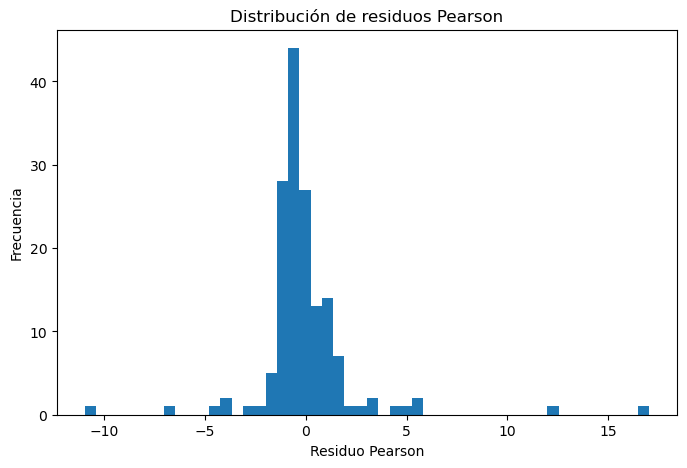

In [12]:
plt.figure(figsize=(8,5))

plt.hist(
    df_diagnostico["residuo_pearson"],
    bins=50
)

plt.xlabel("Residuo Pearson")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos Pearson")

plt.show()

##### Valores observados vs predichos

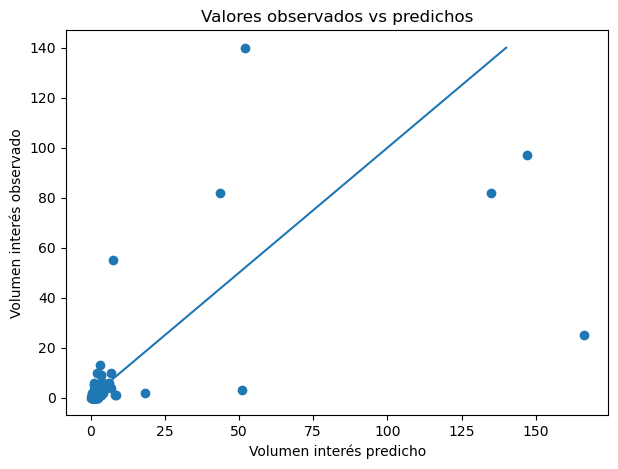

In [13]:
plt.figure(figsize=(7,5))

plt.scatter(
    df_diagnostico["prediccion"],
    df_diagnostico["volumen_interes"]
)

plt.xlabel("Volumen interés predicho")
plt.ylabel("Volumen interés observado")

plt.title(
    "Valores observados vs predichos"
)

plt.plot(
    [0, df_diagnostico["volumen_interes"].max()],
    [0, df_diagnostico["volumen_interes"].max()]
)

plt.show()

##### Diagnóstico de errores de predicción

El análisis de residuos y la comparación entre valores observados y predichos muestran que el modelo Binomial Negativa logra capturar razonablemente bien el comportamiento de la mayoría de las publicaciones, especialmente aquellas con niveles bajos y moderados de interés comercial.

Sin embargo, los mayores errores aparecen en publicaciones con comportamientos extremos. En particular, el modelo tiende a subestimar algunos casos de alta viralidad, como publicaciones que alcanzan valores observados cercanos a 140 interacciones de interés cuando la predicción era considerablemente menor. Al mismo tiempo, existen casos donde el modelo sobreestima el potencial de ciertas publicaciones, asignando valores elevados que finalmente no se materializan en interacción comercial.

Esto indica que, aunque las variables incluidas permiten explicar una parte importante del comportamiento promedio del interés comercial, existen factores adicionales no considerados en el modelo que afectan la aparición de eventos extremos. En redes sociales, estos eventos pueden depender de elementos difíciles de capturar mediante variables agregadas, como el momento de publicación, difusión orgánica, características visuales específicas o factores externos asociados a la conversación.

Por lo tanto, el modelo resulta adecuado para identificar patrones generales asociados al volumen esperado de interés, pero presenta limitaciones para predecir casos excepcionales de alta viralidad.

**¿Qué publicaciones fueron las peor predichas?**

In [16]:
df_modelo["predicho"] = resultado_nb.predict()

df_modelo["error"] = (
    df_modelo["volumen_interes"]
    - df_modelo["predicho"]
)

df_modelo["error_abs"] = df_modelo["error"].abs()

df_modelo.sort_values(
    "error_abs",
    ascending=False
).head(15)

,volumen_interes,prop_ruido_social,prop_elogios,post_producto_materializado,post_carabineros,post_ejercito,post_fach,post_armada,post_pdi,post_pinochet,post_allende,post_prat,post_ohiggins,post_carrera,post_manuel_rodriguez,post_lautaro,post_neruda,predicho,error,error_abs
8,25,0.377562,0.089708,0,0,0,0,0,0,1,0,0,0,0,0,0,0,166.139057,-141.139057,141.139057
89,140,0.644765,0.148210,0,0,0,0,0,0,1,0,0,0,0,0,0,0,52.068117,87.931883,87.931883
107,82,0.422701,0.182354,0,0,0,0,0,0,1,0,0,0,0,0,0,0,134.997262,-52.997262,52.997262
106,97,0.497518,0.094963,1,0,0,0,0,0,1,0,0,0,0,0,0,0,146.963975,-49.963975,49.963975
36,3,0.745414,0.018213,1,0,0,0,0,0,1,0,0,0,0,0,0,0,51.011786,-48.011786,48.011786
149,55,0.233171,0.204781,1,0,1,0,0,0,0,0,0,0,0,0,0,0,7.714836,47.285164,47.285164
35,82,0.779474,0.079695,1,0,0,0,0,0,1,0,0,0,0,0,0,0,43.667915,38.332085,38.332085
32,2,0.330741,0.076496,1,1,0,0,0,0,0,0,0,0,0,0,0,0,18.451684,-16.451684,16.451684
77,13,0.333039,0.326875,1,0,0,0,0,0,0,0,0,0,0,0,0,0,3.018175,9.981825,9.981825
145,10,0.723909,0.034283,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2.294506,7.705494,7.705494


In [17]:
df_modelo["predicho"] = resultado_nb.predict(X)
df_modelo["error"] = df_modelo["volumen_interes"] - df_modelo["predicho"]
df_modelo["error_abs"] = df_modelo["error"].abs()

In [18]:
# Publicaciones donde el modelo más sobrepredijo el interés

sobrepredicciones = (
    df.loc[df_modelo.index]
      .copy()
)

sobrepredicciones["predicho"] = df_modelo["predicho"]
sobrepredicciones["error"] = df_modelo["error"]
sobrepredicciones["error_abs"] = df_modelo["error_abs"]

sobrepredicciones = (
    sobrepredicciones
        .sort_values("error")   # más negativo = mayor sobrepredicción
)

sobrepredicciones.head(15)

,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_fanatismo_no_comercial,...,post_prat,post_ohiggins,post_carrera,post_manuel_rodriguez,post_lautaro,post_neruda,post_mistral,predicho,error,error_abs
8,154787275135903_1057607241520564,augusto pinochet. importante: imagenes de expo...,57,25,3,5,1,18,7,3,...,0,0,0,0,0,0,0,166.139057,-141.139057,141.139057
107,154787275135903_622877694993523,otro avance del proyecto version cromada les r...,202,82,1,37,0,77,26,22,...,0,0,0,0,0,0,0,134.997262,-52.997262,52.997262
106,154787275135903_622842211663738,para quienes estan interesados y esperando: no...,338,97,9,32,1,150,49,43,...,0,0,0,0,0,0,0,146.963975,-49.963975,49.963975
36,154787275135903_1530132302449827,escultura general augusto pinochet. 20cm de pi...,18,3,0,0,0,14,5,5,...,0,0,0,0,0,0,0,51.011786,-48.011786,48.011786
32,154787275135903_1353060253490367,figura impresa en 3d de hombre de carabineros ...,2,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,18.451684,-16.451684,16.451684
41,154787275135903_1566835565446167,diseno 3d de motorista de carabineros de chile...,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,8.676843,-7.676843,7.676843
31,154787275135903_1348217293974663,diseno 3d de mujer guardia de palacio de carab...,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,8.379009,-7.379009,7.379009
7,154787275135903_1042690976345524,"arturo prat en escala 1/16 11,25cm sin base . ...",6,4,0,2,0,1,0,0,...,1,0,0,0,0,0,0,6.973132,-2.973132,2.973132
29,154787275135903_1324743132988746,figura impresa en 3d de soldado del ejercito d...,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3.600935,-2.600935,2.600935
60,154787275135903_305378126743483,45mm bastante pequenito. la moneda de 10 pesit...,5,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,3.580646,-2.580646,2.580646


**Revisaremos tales casos manualmente:**

In [37]:
# Posts específicos queremos revisar
post_ids = [
    "154787275135903_1057607241520564",
    "154787275135903_622842211663738",
    "154787275135903_622877694993523",
    "154787275135903_1530132302449827",
    "154787275135903_1353060253490367",
    "154787275135903_1566835565446167"
]

# Dataset con las URL
df_posts = (
    pd.read_parquet(r"data/gold/facebook_comments_gold_enriched.parquet")
      [["post_id", "post_image_url"]]
      .drop_duplicates(subset="post_id")
)

# Construcción del dataframe únicamente para esos casos
casos = (
    df.loc[df["post_id"].isin(post_ids)]
      .copy()
      .merge(
          df_modelo[["predicho", "error", "error_abs"]],
          left_index=True,
          right_index=True,
          how="left"
      )
      .merge(
          df_posts[["post_id", "post_image_url"]],
          on="post_id",
          how="left"
      )
)

In [38]:
for _, row in casos.iterrows():
    print("=" * 120)
    print(f"Post ID            : {row.post_id}")
    print(f"Volumen observado  : {row.volumen_interes}")
    print(f"Predicción modelo  : {row.predicho:.2f}")
    print(f"Error              : {row.error:.2f}")
    print(f"URL imagen         : {row.post_image_url}\n")
    print(row.clean_post_message)
    print()

Post ID            : 154787275135903_1057607241520564
Volumen observado  : 25
Predicción modelo  : 166.14
Error              : -141.14
URL imagen         : https://www.facebook.com/1290331506429909/posts/1057607241520564

augusto pinochet. importante: imagenes de exposicion, por el momento no esta a la venta. chile ffaa historia

Post ID            : 154787275135903_1353060253490367
Volumen observado  : 2
Predicción modelo  : 18.45
Error              : -16.45
URL imagen         : https://www.facebook.com/1290331506429909/posts/1353060253490367

figura impresa en 3d de hombre de carabineros de chile. pintada estilo bronce antiguo. escala 1/9 20cm de altura sin base disponibilidad a pedido en $36.000 envio

Post ID            : 154787275135903_1530132302449827
Volumen observado  : 3
Predicción modelo  : 51.01
Error              : -48.01
URL imagen         : https://www.facebook.com/1290331506429909/posts/1530132302449827

escultura general augusto pinochet. 20cm de pies a cabeza sin cont

**Observación importante de casos extremos:** Al revisar manualmente las publicaciones que presentaron los mayores errores absolutos del modelo. En todos los casos se identificó un patrón común: el contenido de la publicación contenía información comercial relevante que no estaba representada por las variables incluidas en el modelo.

Entre los principales casos se observaron publicaciones donde se indicaba explícitamente que el producto aún no se encontraba disponible para la venta, publicaciones correspondientes a avances del desarrollo del proyecto y publicaciones cuya descripción ya entregaba información suficiente sobre precio, dimensiones y características del producto. Estas situaciones probablemente reducen la necesidad de realizar consultas comerciales, aun cuando la temática de la publicación genere un elevado interés entre los usuarios.

Este análisis sugiere que parte importante de los errores del modelo no corresponde a comportamiento aleatorio, sino a variables explicativas omitidas. En consecuencia, una mejora natural del modelo consiste en incorporar variables que representen el estado comercial de la publicación y el nivel de información entregada al usuario.

### Regresion Binomial Negativa - Segunda iteración del modelo (incorporación de nuevas variables explicativas)
El análisis de los errores de predicción permitió identificar patrones sistemáticos asociados a publicaciones donde el modelo presentaba grandes diferencias entre el volumen esperado y el observado.

Estos errores se concentraban principalmente en publicaciones donde la temática generaba alto interés, pero donde el contexto comercial era diferente al esperado por el modelo. Entre estos casos se identificaron:

- Publicaciones donde el producto aún no estaba disponible para la venta.
- Publicaciones correspondientes a avances del desarrollo del producto.
- Publicaciones donde la descripción ya entregaba información suficiente sobre precio, características o disponibilidad, reduciendo la necesidad de realizar consultas mediante comentarios.

Para capturar estos comportamientos, se incorporaron nuevas variables derivadas del texto de la publicación:

- `post_no_disponible`: identifica publicaciones donde explícitamente se indica que el producto no está disponible o no se encuentra a la venta.
- `post_info_comercial`: identifica publicaciones que contienen información comercial explícita, como precios, valores monetarios o referencias económicas.
- `post_avance_proyecto`: identifica publicaciones asociadas a etapas tempranas de desarrollo, avances o anuncios futuros del producto.

Estas nuevas variables serán incorporadas al modelo Binomial Negativo manteniendo las variables temáticas y de señal comercial utilizadas previamente. El objetivo es evaluar si esta información adicional permite reducir los errores extremos observados y mejorar la capacidad explicativa del modelo.

#### Feature Engineering: Identificación de intención comercial y estado del producto

Para incorporar esta información al modelo, se generarán nuevas variables a partir del análisis del texto de la publicación (`post_message`). Estas variables permitirán diferenciar entre publicaciones con distinto nivel de intención comercial:

- **Producto no disponible:** publicaciones que contienen expresiones como "no está a la venta", "no se vende", "no disponible", "no se encuentra disponible", entre otras.
- **Información comercial explícita:** publicaciones que incluyen señales como precios, valores monetarios o referencias económicas mediante símbolos y términos como "$", "CLP", "valor" o "precio".
- **Avance de proyecto:** publicaciones que indican que el producto aún se encuentra en desarrollo mediante términos como "avance", "proyecto", "estamos trabajando", "se viene" o "próximamente".

Estas nuevas variables serán incorporadas al modelo Binomial Negativo para evaluar si permiten reducir los errores observados en publicaciones extremas y mejorar la capacidad explicativa del modelo.

In [48]:
df_modelo_v2 = df.copy()

# Texto limpio para búsqueda
texto = (
    df_modelo_v2["clean_post_message"]
    .fillna("")
    .str.lower()
)


# Producto no disponible / no venta
patron_no_venta = (
    r"no esta a la venta|"
    r"no está a la venta|"
    r"no se vende|"
    r"no disponible|"
    r"no se encuentra disponible|"
    r"no está disponible|"
    r"no esat en venta"
)

df_modelo_v2["post_no_venta"] = (
    texto.str.contains(patron_no_venta, regex=True)
    .astype(int)
)


# Publicación con precio o información comercial explícita
patron_precio = (
    r"\$|"
    r"\bclp\b|"
    r"precio|"
    r"valor"
)

df_modelo_v2["post_con_precio"] = (
    texto.str.contains(patron_precio, regex=True)
    .astype(int)
)


# Avances de proyecto / desarrollo
patron_avance = (
    r"avance|"
    r"proyecto|"
    r"estamos trabajando|"
    r"se viene|"
    r"proximamente|"
    r"próximamente"
)

df_modelo_v2["post_avance_proyecto"] = (
    texto.str.contains(patron_avance, regex=True)
    .astype(int)
)


df_modelo_v2[
    [
        "post_no_venta",
        "post_con_precio",
        "post_avance_proyecto"
    ]
].sum()

post_no_venta            3
post_con_precio         22
post_avance_proyecto     8
dtype: int64

**Revisión manual de nuevas etiquetas:**

In [52]:
# Dataset con las URL de las publicaciones

df_posts = (
    pd.read_parquet(r"data/gold/facebook_comments_gold_enriched.parquet")
      [["post_id", "post_image_url"]]
      .drop_duplicates(subset="post_id")
)

# Unir etiquetas nuevas con información original + URL

revision_etiquetas = (
    df.loc[df_modelo_v2.index]
      .copy()
      .merge(
          df_modelo_v2[
              [
                  "post_con_precio",
                  "post_avance_proyecto",
                  "post_no_venta"
              ]
          ],
          left_index=True,
          right_index=True,
          how="left"
      )
      .merge(
          df_posts,
          on="post_id",
          how="left"
      )
)

- Casos con precio:

In [54]:
casos_precio = (
    revision_etiquetas[
        revision_etiquetas["post_con_precio"] == 1
    ]
    .copy()
)

for _, row in casos_precio.iterrows():
    print("=" * 120)
    print(f"Post ID            : {row.post_id}")
    print(f"Etiqueta precio    : {row.post_con_precio}")
    print(f"URL imagen         : {row.post_image_url}\n")
    print(row.clean_post_message)
    print()

Post ID            : 154787275135903_1086867368594551
Etiqueta precio    : 1
URL imagen         : https://www.facebook.com/1290331506429909/posts/1086867368594551

probando escalas 1/36 5cm . disponibles en $7.000 c/u. 3dprinting modelling modelism miniature miniaturas chile

Post ID            : 154787275135903_1133888068740921
Etiqueta precio    : 1
URL imagen         : https://www.facebook.com/1290331506429909/posts/1133888068740921

diseno 3d de soldado en tenida de combate. stl diseno digital disponible en $15.000 clp / $19 usd

Post ID            : 154787275135903_1324743132988746
Etiqueta precio    : 1
URL imagen         : https://www.facebook.com/1290331506429909/posts/1324743132988746

figura impresa en 3d de soldado del ejercito de chile. pintada estilo bronce antiguo. escala 1/9 20,2cm de altura sin base disponibilidad a pedido en $36.000 envio

Post ID            : 154787275135903_1328368075959585
Etiqueta precio    : 1
URL imagen         : https://www.facebook.com/12903315

- Casos producto no terminado (avance)

In [55]:
casos_avance = (
    revision_etiquetas[
        revision_etiquetas["post_avance_proyecto"] == 1
    ]
    .copy()
)

for _, row in casos_avance.iterrows():
    print("=" * 120)
    print(f"Post ID                : {row.post_id}")
    print(f"Etiqueta avance        : {row.post_avance_proyecto}")
    print(f"URL imagen             : {row.post_image_url}\n")
    print(row.clean_post_message)
    print()

Post ID                : 154787275135903_156188751662422
Etiqueta avance        : 1
URL imagen             : https://www.facebook.com/1290331506429909/posts/156188751662422

se vienen se vienen :b ¿algun fan?

Post ID                : 154787275135903_279371079344188
Etiqueta avance        : 1
URL imagen             : None

hola amigos tenemos tres noticias que contar: -la primera es que hace poco nos formalizamos oficialmente como empresa a nombre de dreammaker. sabemos que muchos de ustedes nos conocieron como "cae-zone", por lo que caezone seguira existiendo para ustedes como un espacio dedicado especialmente al nonito pero maravilloso mundo de las "figuritas", siendo este un subespacio de lo que sera dreammaker. -la segunda noticia es que nuestro plan de negocios logro adjudicarse una inversion otorgada por sercotec para nuestro proyecto como empresa. lo que consideramos un pequeno gran logro para continuar creciendo. -tercera noticia: implementaremos dentro de muy poco a nuestras f

- Casos "no venta"

In [56]:
casos_no_venta = (
    revision_etiquetas[
        revision_etiquetas["post_no_venta"] == 1
    ]
    .copy()
)

for _, row in casos_no_venta.iterrows():
    print("=" * 120)
    print(f"Post ID                : {row.post_id}")
    print(f"Etiqueta no venta      : {row.post_no_venta}")
    print(f"URL imagen             : {row.post_image_url}\n")
    print(row.clean_post_message)
    print()

Post ID                : 154787275135903_1057607241520564
Etiqueta no venta      : 1
URL imagen             : https://www.facebook.com/1290331506429909/posts/1057607241520564

augusto pinochet. importante: imagenes de exposicion, por el momento no esta a la venta. chile ffaa historia

Post ID                : 154787275135903_1566835565446167
Etiqueta no venta      : 1
URL imagen             : https://www.facebook.com/1290331506429909/posts/1566835565446167

diseno 3d de motorista de carabineros de chile. stl diseno digital no disponible.

Post ID                : 154787275135903_678260077637058
Etiqueta no venta      : 1
URL imagen             : https://www.facebook.com/1290331506429909/posts/678260077637058

un pequeno homenaje a daniel palma yanez, nuevo martir de carabchile diseno realizado solo a modo de homenaje, modelo no esta a la venta . carabineros chile



#### Reentrenamiento Modelo Binomial Negativo

In [49]:
formula_nb_v2 = """

volumen_interes ~

prop_ruido_social +

prop_elogios +

post_producto_materializado +

post_carabineros +
post_ejercito +
post_fach +
post_armada +
post_pdi +

post_pinochet +
post_allende +
post_prat +
post_ohiggins +
post_carrera +
post_manuel_rodriguez +
post_lautaro +
post_neruda +

post_no_venta +
post_con_precio +
post_avance_proyecto

"""

In [50]:
variables_modelo_v2 = [
    "volumen_interes",
    "prop_ruido_social",
    "prop_elogios",

    "post_producto_materializado",

    "post_carabineros",
    "post_ejercito",
    "post_fach",
    "post_armada",
    "post_pdi",

    "post_pinochet",
    "post_allende",
    "post_prat",
    "post_ohiggins",
    "post_carrera",
    "post_manuel_rodriguez",
    "post_lautaro",
    "post_neruda",

    "post_no_venta",
    "post_con_precio",
    "post_avance_proyecto"
]


df_modelo_v2 = (
    df_modelo_v2[variables_modelo_v2]
    .dropna()
)


X_v2 = df_modelo_v2.drop(columns="volumen_interes")

X_v2 = sm.add_constant(X_v2)


y_v2 = df_modelo_v2["volumen_interes"]


modelo_nb_v2 = NegativeBinomial(
    y_v2,
    X_v2
)


resultado_nb_v2 = modelo_nb_v2.fit(
    method="bfgs",
    maxiter=1000,
    disp=False,
    warn_convergence=False,
    cov_type="HC0"
)


print(resultado_nb_v2.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:        volumen_interes   No. Observations:                  155
Model:               NegativeBinomial   Df Residuals:                      135
Method:                           MLE   Df Model:                           19
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                  0.2436
Time:                        20:34:56   Log-Likelihood:                -300.83
converged:                       True   LL-Null:                       -397.70
Covariance Type:                  HC0   LLR p-value:                 5.951e-31
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           2.3401      0.272      8.588      0.000       1.806       2.874
prop_ruido_social              -4.6854      0.773     -6.060      0.000      -6.

#### Diagnostico del modelo

##### Residuos

In [69]:
# Diagnóstico residuos modelo v2

df_diagnostico_v2 = df_modelo_v2.copy()

# Predicciones
df_diagnostico_v2["prediccion"] = resultado_nb_v2.predict()


# Residuo Pearson
df_diagnostico_v2["residuo_pearson"] = (
    (df_diagnostico_v2["volumen_interes"] -
     df_diagnostico_v2["prediccion"])
    /
    np.sqrt(df_diagnostico_v2["prediccion"])
)


# Residuo de respuesta (lo que antes llamamos deviance por error)
df_diagnostico_v2["residuo_respuesta"] = (
    df_diagnostico_v2["volumen_interes"]
    -
    df_diagnostico_v2["prediccion"]
)


df_diagnostico_v2.head()

,volumen_interes,prop_ruido_social,prop_elogios,post_producto_materializado,post_carabineros,post_ejercito,post_fach,post_armada,post_pdi,post_pinochet,...,post_carrera,post_manuel_rodriguez,post_lautaro,post_neruda,post_no_venta,post_con_precio,post_avance_proyecto,prediccion,residuo_pearson,residuo_respuesta
0,1,0.413426,0.095621,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,2.046395,-0.731477,-1.046395
1,1,0.413426,0.345621,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,2.229398,-0.823377,-1.229398
2,4,0.379100,0.054640,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.755364,1.694191,2.244636
3,0,0.413426,0.345621,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.484681,-1.218475,-1.484681
4,2,0.330741,0.076496,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,3.655623,-0.865926,-1.655623


**Residuos de Pearson:**

In [70]:
df_diagnostico_v2[
    [
        "residuo_pearson",
        "residuo_respuesta"
    ]
].describe()

,residuo_pearson,residuo_respuesta
count,155.000000,155.000000
mean,-0.004871,-0.170364
std,1.972119,9.849049
min,-8.716217,-78.862496
25%,-0.829559,-1.224906
50%,-0.370369,-0.462816
75%,0.541928,0.619445
max,15.107152,65.957022


**Distribución gráfica de residuos**

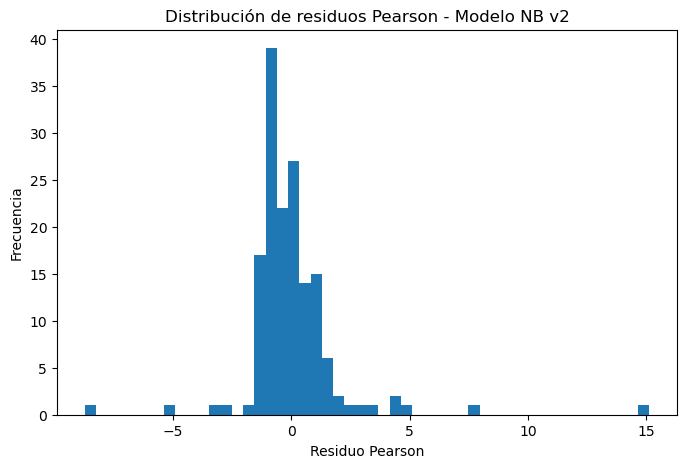

In [71]:
plt.figure(figsize=(8,5))

plt.hist(
    df_diagnostico_v2["residuo_pearson"],
    bins=50
)

plt.xlabel("Residuo Pearson")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos Pearson - Modelo NB v2")

plt.show()

##### Valores observado vs predicho:

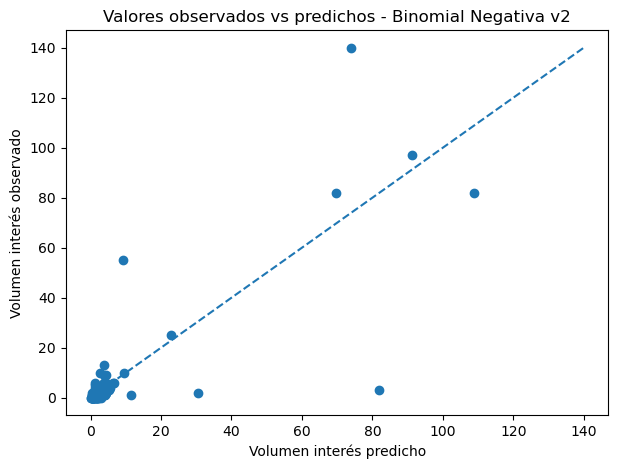

In [72]:
plt.figure(figsize=(7,5))

plt.scatter(
    df_diagnostico_v2["prediccion"],
    df_diagnostico_v2["volumen_interes"]
)


max_val = max(
    df_diagnostico_v2["prediccion"].max(),
    df_diagnostico_v2["volumen_interes"].max()
)


plt.plot(
    [0,max_val],
    [0,max_val],
    linestyle="--"
)


plt.xlabel("Volumen interés predicho")
plt.ylabel("Volumen interés observado")

plt.title(
    "Valores observados vs predichos - Binomial Negativa v2"
)

plt.show()

**¿Qué publicaciones fueron las peores predichas??**

In [73]:
# Diagnóstico modelo v2

df_modelo_v2_diag = df_modelo_v2.copy()

df_modelo_v2_diag["predicho"] = resultado_nb_v2.predict()

df_modelo_v2_diag["error"] = (
    df_modelo_v2_diag["volumen_interes"]
    -
    df_modelo_v2_diag["predicho"]
)

df_modelo_v2_diag["error_abs"] = (
    abs(df_modelo_v2_diag["error"])
)

- Mayores sobrepredicciones:

In [75]:
sobrepredicciones_v2 = (
    df.loc[df_modelo_v2.index]
    .copy()
)


sobrepredicciones_v2["predicho"] = (
    df_modelo_v2_diag["predicho"]
)

sobrepredicciones_v2["error"] = (
    df_modelo_v2_diag["error"]
)

sobrepredicciones_v2["error_abs"] = (
    df_modelo_v2_diag["error_abs"]
)


sobrepredicciones_v2 = (
    sobrepredicciones_v2
    .sort_values("error")
)


sobrepredicciones_v2.head(8)

,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_fanatismo_no_comercial,...,post_prat,post_ohiggins,post_carrera,post_manuel_rodriguez,post_lautaro,post_neruda,post_mistral,predicho,error,error_abs
36,154787275135903_1530132302449827,escultura general augusto pinochet. 20cm de pi...,18,3,0,0,0,14,5,5,...,0,0,0,0,0,0,0,81.862496,-78.862496,78.862496
32,154787275135903_1353060253490367,figura impresa en 3d de hombre de carabineros ...,2,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,30.391264,-28.391264,28.391264
107,154787275135903_622877694993523,otro avance del proyecto version cromada les r...,202,82,1,37,0,77,26,22,...,0,0,0,0,0,0,0,108.868512,-26.868512,26.868512
31,154787275135903_1348217293974663,diseno 3d de mujer guardia de palacio de carab...,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,11.606806,-10.606806,10.606806
45,154787275135903_166588473955783,"dva lista para comprar, enviar y pintar ; 16 c...",4,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,3.100862,-3.100862,3.100862
29,154787275135903_1324743132988746,figura impresa en 3d de soldado del ejercito d...,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3.960811,-2.960811,2.960811
60,154787275135903_305378126743483,45mm bastante pequenito. la moneda de 10 pesit...,5,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,3.926202,-2.926202,2.926202
38,154787275135903_154818451799452,personaje warcraft material pla precio 20.000 ...,2,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,3.869760,-2.869760,2.869760


- Mayores subpredicciones:

In [77]:
subpredicciones_v2 = (
    df.loc[df_modelo_v2.index]
    .copy()
)


subpredicciones_v2["predicho"] = (
    df_modelo_v2_diag["predicho"]
)

subpredicciones_v2["error"] = (
    df_modelo_v2_diag["error"]
)

subpredicciones_v2["error_abs"] = (
    df_modelo_v2_diag["error_abs"]
)


subpredicciones_v2 = (
    subpredicciones_v2
    .sort_values("error", ascending=False)
)


subpredicciones_v2.head(8)

,post_id,clean_post_message,volumen_total,volumen_interes,volumen_solicitudes,volumen_elogios,volumen_criticas,volumen_polarizacion,volumen_fanatismo,volumen_fanatismo_no_comercial,...,post_prat,post_ohiggins,post_carrera,post_manuel_rodriguez,post_lautaro,post_neruda,post_mistral,predicho,error,error_abs
89,154787275135903_546904915924135,"""augusto pinochet ugarte"". diseno 3d esculpido...",789,140,23,117,4,468,111,101,...,0,0,0,0,0,0,0,74.042978,65.957022,65.957022
149,154787275135903_927551496041247,escultura de soldado del ejercito de chile mar...,77,55,5,16,0,15,3,2,...,0,0,0,0,0,0,0,9.193623,45.806377,45.806377
35,154787275135903_1530080439121680,escultura general augusto pinochet. 20cm de pi...,579,82,7,46,3,375,198,196,...,0,0,0,0,0,0,0,69.689943,12.310057,12.310057
77,154787275135903_392725821342046,"sorteo fans de game of thrones, se sortearan e...",41,13,1,14,0,8,10,8,...,0,0,0,0,0,0,0,3.823912,9.176088,9.176088
145,154787275135903_911398067656590,diseno 3d de carabinero de chile. zbrush digit...,154,10,5,5,0,110,9,9,...,0,0,0,0,0,0,0,2.729131,7.270869,7.270869
106,154787275135903_622842211663738,para quienes estan interesados y esperando: no...,338,97,9,32,1,150,49,43,...,0,0,0,0,0,0,0,91.366456,5.633544,5.633544
96,154787275135903_569429600338333,"soldado chileno de la ""guerra del pacifico"" di...",9,9,0,1,0,1,0,0,...,0,0,0,0,0,0,0,3.674378,5.325622,5.325622
53,154787275135903_213769502571013,none,23,6,1,2,0,9,1,1,...,0,0,0,0,0,0,0,1.268689,4.731311,4.731311


##### Mejora del modelo mediante incorporación de variables contextuales

La incorporación de estas variables (`post_avance_proyecto`, `post_con_precio` y `post_no_venta` ) permitió mejorar la capacidad del modelo para diferenciar entre publicaciones con intención comercial directa y publicaciones cuyo nivel de interacción responde principalmente a expectativa, curiosidad o discusión social.

Los principales cambios observados fueron:

- Reducción significativa de los errores extremos de predicción. El mayor error absoluto del modelo disminuyó desde aproximadamente 141 unidades de interés en la primera versión hasta cerca de 79 unidades en la segunda versión.
- Disminución de la dispersión de los residuos Pearson, pasando de una desviación estándar de aproximadamente 2.44 a 1.97, indicando una mejora en la estabilidad del ajuste.
- Reducción de predicciones excesivamente elevadas para publicaciones que anteriormente eran interpretadas erróneamente como oportunidades comerciales, especialmente aquellas relacionadas con productos no disponibles o avances de proyectos.

Sin embargo, el análisis de los nuevos casos extremos muestra que aún existen publicaciones donde el volumen de interés no depende únicamente de características comerciales del contenido. Algunos casos con alta interacción presentan elevados niveles de polarización, fanatismo o discusión social, generando grandes volúmenes de comentarios que no necesariamente representan intención comercial.

Por lo tanto, la segunda versión del modelo representa una mejora metodológica respecto al modelo inicial, ya que incorpora información contextual relevante y reduce errores asociados a una mala clasificación del propósito de la publicación. No obstante, los errores restantes sugieren la existencia de fenómenos no lineales asociados a viralidad y comportamiento comunitario que probablemente requieran modelos predictivos más flexibles o nuevas fuentes de información para ser capturados completamente.

### Interpretación de coeficientes (Modelo Binomial Negativo - Segunda iteración)

La interpretación de los coeficientes se realiza utilizando la segunda iteración del modelo Binomial Negativo, incorporando nuevas variables contextuales destinadas a diferenciar entre publicaciones con intención comercial directa y publicaciones asociadas a otros tipos de interacción, como avances de proyectos, productos no disponibles o publicaciones con información comercial explícita.

Antes de analizar los efectos individuales, es importante recordar que el modelo presentó dificultades para representar completamente publicaciones con niveles extremos de interacción. Si bien la incorporación de nuevas variables permitió reducir considerablemente los errores extremos observados en la primera versión del modelo, aún existen publicaciones donde el volumen de comentarios responde a fenómenos de viralidad, polarización o comportamiento comunitario que no pueden ser explicados completamente por las variables disponibles. Por esta razón, los coeficientes deben interpretarse como asociaciones promedio dentro del conjunto de publicaciones analizadas y no como reglas determinísticas capaces de explicar cada caso individual.

**Señal comercial y ruido social**

La proporción de ruido social mantiene una asociación negativa y estadísticamente significativa con el volumen esperado de interés comercial (β=-4.69, p<0.001). Esto indica que, manteniendo constantes las demás variables del modelo, aquellas publicaciones donde una mayor proporción de la conversación corresponde a interacciones no comerciales tienden a presentar un menor volumen esperado de señales asociadas a interés comercial.

Sin embargo, este resultado debe interpretarse considerando el comportamiento observado durante el análisis exploratorio, particularmente en la sección **`Commercial Signal Analysis - Instituciones Chilenas - Proporción vs volumen promedio de señal comercial`**. En dicha sección se observó que las publicaciones con mayor nivel de viralidad pueden presentar simultáneamente una menor proporción de interés comercial, pero un mayor volumen absoluto de comentarios asociados a interés.

Esto sugiere la posible existencia de dos regímenes distintos de comportamiento. En publicaciones con niveles habituales de interacción, una conversación más enfocada en el producto parece favorecer la generación de señales comerciales. No obstante, cuando una publicación alcanza niveles elevados de difusión, el incremento masivo de comentarios incorpora simultáneamente interacciones comerciales y no comerciales, modificando la relación observada en la mayoría de los casos.

**Variables asociadas al contexto comercial de la publicación**

Las nuevas variables incorporadas permitieron capturar diferencias importantes en la naturaleza de las publicaciones.

La variable `post_no_venta` presentó un efecto negativo y estadísticamente significativo (β=-2.43, p<0.001). Esto indica que aquellas publicaciones donde se especifica explícitamente que el producto no está disponible para venta presentan un volumen esperado de interés comercial considerablemente menor. Este resultado valida la incorporación de esta etiqueta, ya que algunos de los principales errores de la primera versión provenían de publicaciones que generaban interacción, pero no correspondían a una intención comercial real.

La variable `post_avance_proyecto` también presentó un efecto negativo significativo (β=-0.65, p=0.029). Esto indica que las publicaciones asociadas a avances, desarrollo o etapas de fabricación tienden a generar un menor volumen esperado de señales comerciales respecto a publicaciones enfocadas en productos disponibles. Este resultado es consistente con la naturaleza de este tipo de publicaciones, donde la interacción puede estar motivada por expectativa o seguimiento del proyecto, más que por intención directa de compra.

Por otra parte, la variable `post_con_precio` presentó un efecto positivo moderado (β=0.40), aunque no alcanzó significancia estadística (p=0.155). Si bien existe una tendencia a que las publicaciones con información explícita de precio presenten mayor volumen esperado de interés comercial, la evidencia disponible no permite confirmar este efecto de manera independiente. Esto puede deberse al reducido tamaño muestral y a que la presencia de precio puede estar asociada simultáneamente con otros factores relevantes, como temática o nivel previo de interés generado por la publicación.

**Efecto de las temáticas de las publicaciones**

Entre las variables temáticas, las publicaciones relacionadas con **Carabineros**, **Prat**, **O'Higgins** y **Pinochet** mostraron asociaciones positivas estadísticamente significativas.

La temática asociada a **Carabineros** presentó uno de los efectos positivos más importantes, con un coeficiente β=2.06 (p<0.001), equivalente a un incremento aproximado de **680% en el volumen esperado de interés comercial** respecto a publicaciones equivalentes que no pertenecen a esta categoría (IRR≈7.82).

Las publicaciones relacionadas con **Prat** también mostraron un efecto positivo significativo (β=0.60, p=0.017), equivalente a un incremento aproximado del **82%** en el volumen esperado (IRR≈1.82).

Por su parte, la categoría **O'Higgins** presentó un efecto positivo considerable y estadísticamente significativo (β=1.35, p<0.001), asociado a un aumento aproximado de **285%** en el volumen esperado de interés comercial (IRR≈3.85).

La categoría **Pinochet** continúa mostrando el mayor efecto positivo estimado por el modelo (β=4.99, p<0.001), aunque su interpretación requiere mayor cautela. Si bien la temática se asocia con un incremento muy elevado del volumen esperado de interés comercial, el análisis de casos extremos mostró que varias publicaciones dentro de esta categoría presentan comportamientos heterogéneos: algunas generan altos niveles de interacción comercial, mientras que otras concentran principalmente discusión social o seguimiento de proyectos.

La magnitud de este efecto sugiere que esta temática posee una capacidad elevada para generar interacción, pero también evidencia que existen mecanismos adicionales no capturados por el modelo, como polarización, comunidad involucrada o viralidad específica del contenido.

**Variables con efectos relevantes pero sin evidencia estadística suficiente**

Algunas variables no alcanzaron significancia estadística, pero presentan coeficientes que sugieren posibles efectos relevantes.

Por ejemplo, `post_ejercito` presentó un efecto positivo moderado (β=0.41), aunque sin evidencia estadística suficiente (p=0.139). Esto podría indicar una tendencia hacia mayor interacción comercial en publicaciones asociadas al Ejército, pero con la información disponible no es posible confirmar que el efecto sea independiente.

De manera similar, `post_allende` presentó un coeficiente positivo (β=0.92), aunque con alta incertidumbre estadística (p=0.238). Debido al reducido número de observaciones en algunas categorías, estos efectos deben interpretarse como señales exploratorias que podrían requerir una muestra mayor para ser confirmados.

En contraste, algunas variables como `post_producto_materializado` no mostraron evidencia suficiente de un efecto independiente en este modelo (β=0.17, p=0.375). Esto indica que, una vez controladas las demás características de la publicación, no existe evidencia estadística para afirmar que la simple presencia del producto materializado aumente el volumen esperado de interés.

**Próximos pasos: modelos no lineales**

Aunque la segunda iteración del modelo permitió mejorar la interpretación y reducir errores asociados a publicaciones no comerciales, todavía existen patrones complejos asociados a publicaciones altamente virales que un modelo lineal no captura completamente.

Por esta razón, como complemento al modelo inferencial, se explorará un modelo basado en árboles de decisión. Este enfoque permitirá identificar posibles relaciones no lineales e interacciones entre variables que la regresión Binomial Negativa no representa adecuadamente, especialmente en casos extremos donde la combinación de temática, polarización, volumen de interacción y contexto de publicación puede generar comportamientos distintos.

El objetivo no será reemplazar el modelo inferencial, sino complementarlo con una herramienta predictiva capaz de descubrir patrones adicionales y mejorar la comprensión de los casos donde el comportamiento observado se aleja de las relaciones promedio estimadas por el modelo estadístico.

## Modelo explicativo de la composición de la interacción
Árbol de decisión para identificación de patrones de interés comercial

Luego del modelamiento mediante regresión Binomial Negativa, se desarrolla un modelo basado en árboles de decisión con el objetivo de explorar relaciones no lineales entre las características de las publicaciones y el volumen de interés comercial generado.

A diferencia del modelo paramétrico anterior, que estima efectos promedio individuales asumiendo una relación lineal en la escala logarítmica del volumen esperado, los árboles de decisión permiten identificar reglas de segmentación, interacciones entre variables y posibles umbrales críticos que pueden explicar comportamientos extremos.

Este modelo exploratorio busca responder preguntas como:

- ¿Existen niveles de volumen total de comentarios donde la proporción de interés comercial comienza a diluirse?
- ¿Qué combinación de características genera publicaciones con mayor volumen esperado de interés?
- ¿Existen interacciones entre temática, viralidad y señales comerciales que no son capturadas por el modelo lineal?

El objetivo principal no será maximizar la capacidad predictiva, sino utilizar la estructura del árbol como herramienta de interpretabilidad del comportamiento de los usuarios, identificando segmentos y reglas de decisión asociadas al interés comercial.

Preparación de variables:

In [149]:
features_tree_prop = [
    "volumen_total",
    
    "post_producto_materializado",
    
    "post_carabineros",
    "post_ejercito",
    "post_fach",
    "post_armada",
    "post_pdi",
    
    "post_pinochet",
    "post_allende",
    "post_prat",
    "post_ohiggins",
    "post_carrera",
    "post_manuel_rodriguez",
    "post_lautaro",
    "post_neruda",
    "post_mistral",
    
    "post_no_venta",
    "post_con_precio",
    "post_avance_proyecto"
]

In [150]:
X_tree_prop = df_tree[features_tree_prop]

y_tree_prop = df_tree["prop_interes"]

print("X:", X_tree_prop.shape)
print("y:", y_tree_prop.shape)

X: (155, 19)
y: (155,)


### Entrenamiento del Arbol de Decisión
Se entrenó un árbol de decisión para regresión (`DecisionTreeRegressor`) utilizando una profundidad máxima de cinco niveles (`max_depth=5`) y un mínimo de ocho observaciones por nodo terminal (`min_samples_leaf=8`). Estos hiperparámetros no fueron seleccionados con el objetivo de maximizar la capacidad predictiva del modelo, sino de obtener una estructura suficientemente simple e interpretable que permitiera identificar patrones generales y posibles cambios de régimen en los datos. Limitar la profundidad evita la generación de reglas excesivamente específicas asociadas al ruido del conjunto de entrenamiento, mientras que exigir un número mínimo de observaciones por hoja reduce la aparición de particiones sustentadas por muy pocos casos, favoreciendo reglas más estables y representativas del comportamiento global. Finalmente, `random_state=42` se fijó para garantizar la reproducibilidad de los resultados.

In [151]:
tree_prop_5 = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=8,
    random_state=42
)


tree_prop_5.fit(
    X_tree_prop,
    y_tree_prop
)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=8, random_state=42)

In [152]:
importancias_prop = pd.DataFrame({
    "variable": X_tree_prop.columns,
    "importancia": tree_prop_5.feature_importances_
})


importancias_prop = (
    importancias_prop
    .sort_values(
        "importancia",
        ascending=False
    )
)


importancias_prop

,variable,importancia
0,volumen_total,0.645627
3,post_ejercito,0.198919
17,post_con_precio,0.085236
1,post_producto_materializado,0.070218
11,post_carrera,0.000000
16,post_no_venta,0.000000
15,post_mistral,0.000000
14,post_neruda,0.000000
13,post_lautaro,0.000000
12,post_manuel_rodriguez,0.000000


La importancia de las variables muestra que el volumen total de comentarios constituye el principal predictor de la proporción de interés comercial, concentrando aproximadamente el 64,6% de la importancia total del modelo. En un segundo nivel aparecen las variables post_ejercito (19,9%), post_con_precio (8,5%) y post_producto_materializado (7,0%), mientras que el resto de las variables presentan una contribución prácticamente nula.

### Reglas de decisión
Exploramos cual es el conjunto de reglas utilizado por el árbol para decidir cada división:

In [153]:
reglas_prop = export_text(
    tree_prop_5,
    feature_names=list(X_tree_prop.columns),
    decimals=2
)


print(reglas_prop)

|--- volumen_total <= 11.50
|   |--- volumen_total <= 5.50
|   |   |--- post_ejercito <= 0.50
|   |   |   |--- post_con_precio <= 0.50
|   |   |   |   |--- post_producto_materializado <= 0.50
|   |   |   |   |   |--- value: [0.38]
|   |   |   |   |--- post_producto_materializado >  0.50
|   |   |   |   |   |--- value: [0.33]
|   |   |   |--- post_con_precio >  0.50
|   |   |   |   |--- value: [0.31]
|   |   |--- post_ejercito >  0.50
|   |   |   |--- volumen_total <= 1.50
|   |   |   |   |--- value: [0.45]
|   |   |   |--- volumen_total >  1.50
|   |   |   |   |--- value: [0.44]
|   |--- volumen_total >  5.50
|   |   |--- volumen_total <= 7.50
|   |   |   |--- value: [0.47]
|   |   |--- volumen_total >  7.50
|   |   |   |--- value: [0.46]
|--- volumen_total >  11.50
|   |--- volumen_total <= 46.50
|   |   |--- value: [0.29]
|   |--- volumen_total >  46.50
|   |   |--- value: [0.27]



Las reglas obtenidas muestran que las primeras divisiones del árbol se realizan únicamente en función del volumen total de comentarios, identificando umbrales cercanos a 11,5 y 46,5 comentarios. Solo una vez definidas estas primeras particiones comienzan a aparecer variables relacionadas con el contenido de la publicación, como post_ejercito, post_con_precio y post_producto_materializado, las cuales refinan la estimación de la proporción de interés comercial en publicaciones de menor volumen. Este comportamiento sugiere que el nivel de viralidad podría ser el principal factor que determina cómo se comporta la conversación. 

En consecuencia, surge de forma natural la siguiente pregunta: **¿es posible que la relación entre la composición de la interacción y el interés comercial no sea única para todas las publicaciones, sino que existan distintos regímenes de comportamiento dependiendo del volumen de interacción alcanzado?** Esta hipótesis será explorada con mayor detalle en el análisis de las curvas de tendencia presentado a continuación.

### Relación entre el volumen de interacción y la composición de la conversación

Con el objetivo de profundizar en la relación observada entre la composición de la conversación y el volumen de interacción, se analizan conjuntamente la proporción de interés comercial y la proporción de ruido social en función del volumen total de comentarios por publicación.

Esta exploración surge a partir de dos resultados obtenidos previamente. Por una parte, el modelo de regresión Binomial Negativa evidenció una asociación promedio negativa entre la proporción de ruido social y el volumen esperado de interés comercial. Por otra, el **árbol de decisión sugirió que dicha relación no sería uniforme para todas las publicaciones**, identificando umbrales de volumen que podrían corresponder a distintos regímenes de comportamiento de la conversación.

Con el propósito de evaluar visualmente esta hipótesis, ambos gráficos incorporan una curva suavizada LOWESS junto con los dos umbrales identificados por el árbol de decisión (11.5 y 46.5 comentarios), permitiendo observar si la composición relativa de la conversación cambia conforme aumenta la viralidad de las publicaciones.

#### Visualización en escala lineal

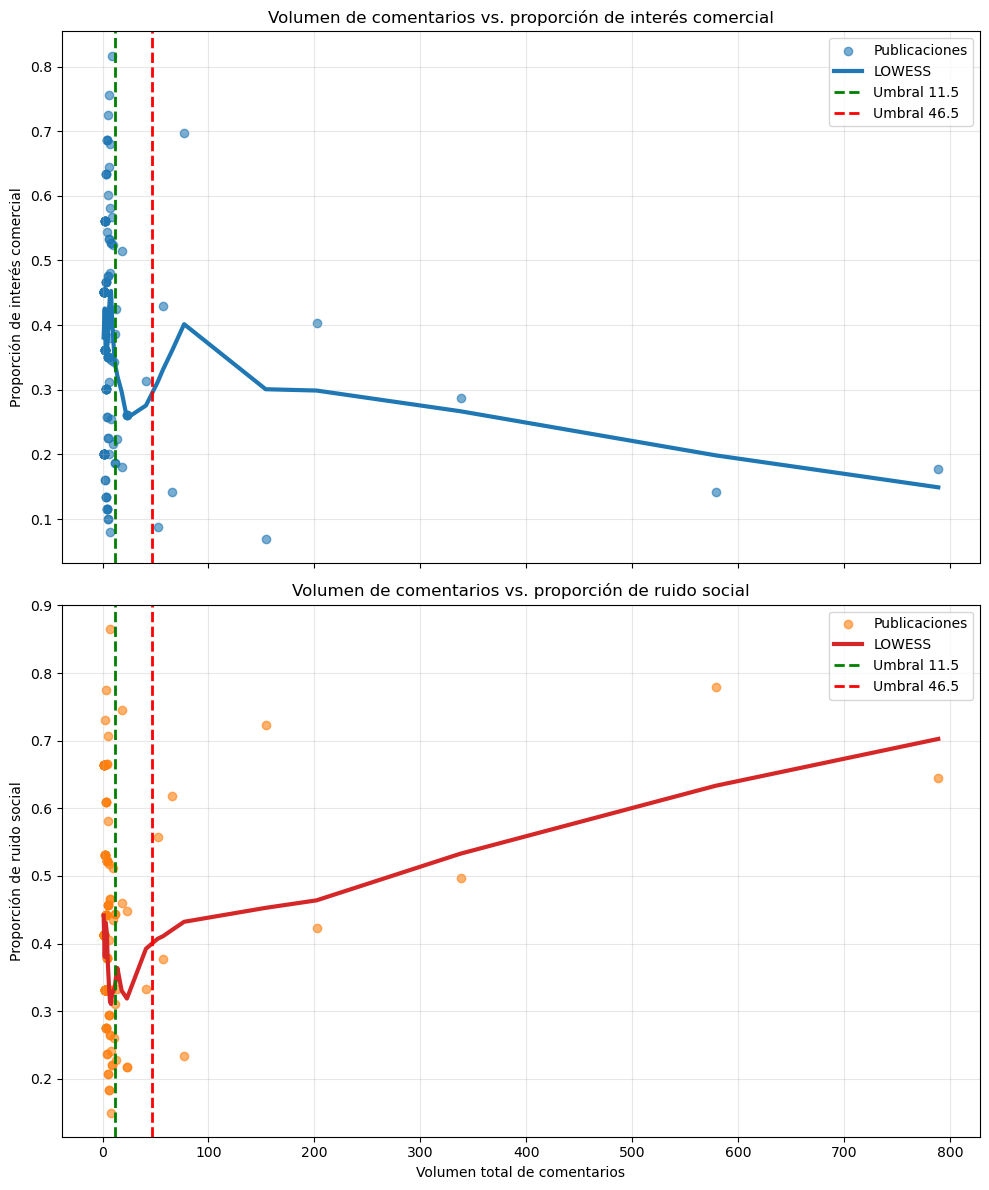

In [10]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 12),
    sharex=True
)

# ==========================================================
# Proporción de interés comercial
# ==========================================================

axes[0].scatter(
    df["volumen_total"],
    df["prop_interes"],
    alpha=0.6,
    label="Publicaciones"
)

lowess_interes = sm.nonparametric.lowess(
    endog=df["prop_interes"],
    exog=df["volumen_total"],
    frac=0.35
)

axes[0].plot(
    lowess_interes[:, 0],
    lowess_interes[:, 1],
    linewidth=3,
    label="LOWESS"
)

axes[0].axvline(
    x=11.5,
    linestyle="--",
    linewidth=2,
    color="green",
    label="Umbral 11.5"
)

axes[0].axvline(
    x=46.5,
    linestyle="--",
    linewidth=2,
    color="red",
    label="Umbral 46.5"
)

axes[0].set_ylabel(
    "Proporción de interés comercial"
)

axes[0].set_title(
    "Volumen de comentarios vs. proporción de interés comercial"
)

axes[0].grid(alpha=0.3)

axes[0].legend()


# ==========================================================
# Proporción de ruido social
# ==========================================================

axes[1].scatter(
    df["volumen_total"],
    df["prop_ruido_social"],
    alpha=0.6,
    color="tab:orange",
    label="Publicaciones"
)

lowess_ruido = sm.nonparametric.lowess(
    endog=df["prop_ruido_social"],
    exog=df["volumen_total"],
    frac=0.35
)

axes[1].plot(
    lowess_ruido[:, 0],
    lowess_ruido[:, 1],
    linewidth=3,
    color="tab:red",
    label="LOWESS"
)

axes[1].axvline(
    x=11.5,
    linestyle="--",
    linewidth=2,
    color="green",
    label="Umbral 11.5"
)

axes[1].axvline(
    x=46.5,
    linestyle="--",
    linewidth=2,
    color="red",
    label="Umbral 46.5"
)

axes[1].set_xlabel(
    "Volumen total de comentarios"
)

axes[1].set_ylabel(
    "Proporción de ruido social"
)

axes[1].set_title(
    "Volumen de comentarios vs. proporción de ruido social"
)

axes[1].grid(alpha=0.3)

axes[1].legend()


plt.tight_layout()

plt.show()

>**Figura. Relación entre el volumen total de comentarios y la composición relativa de la conversación.** El panel superior muestra la evolución de la proporción de interés comercial, mientras que el panel inferior presenta la proporción de ruido social. En ambos casos se incluye una curva LOWESS para visualizar la tendencia promedio y se incorporan los umbrales identificados mediante árbol de decisión (11.5 y 46.5 comentarios), los cuales sugieren la existencia de distintos regímenes de comportamiento según el nivel de interacción alcanzado por cada publicación.

#### Visualización en escala logarítmica

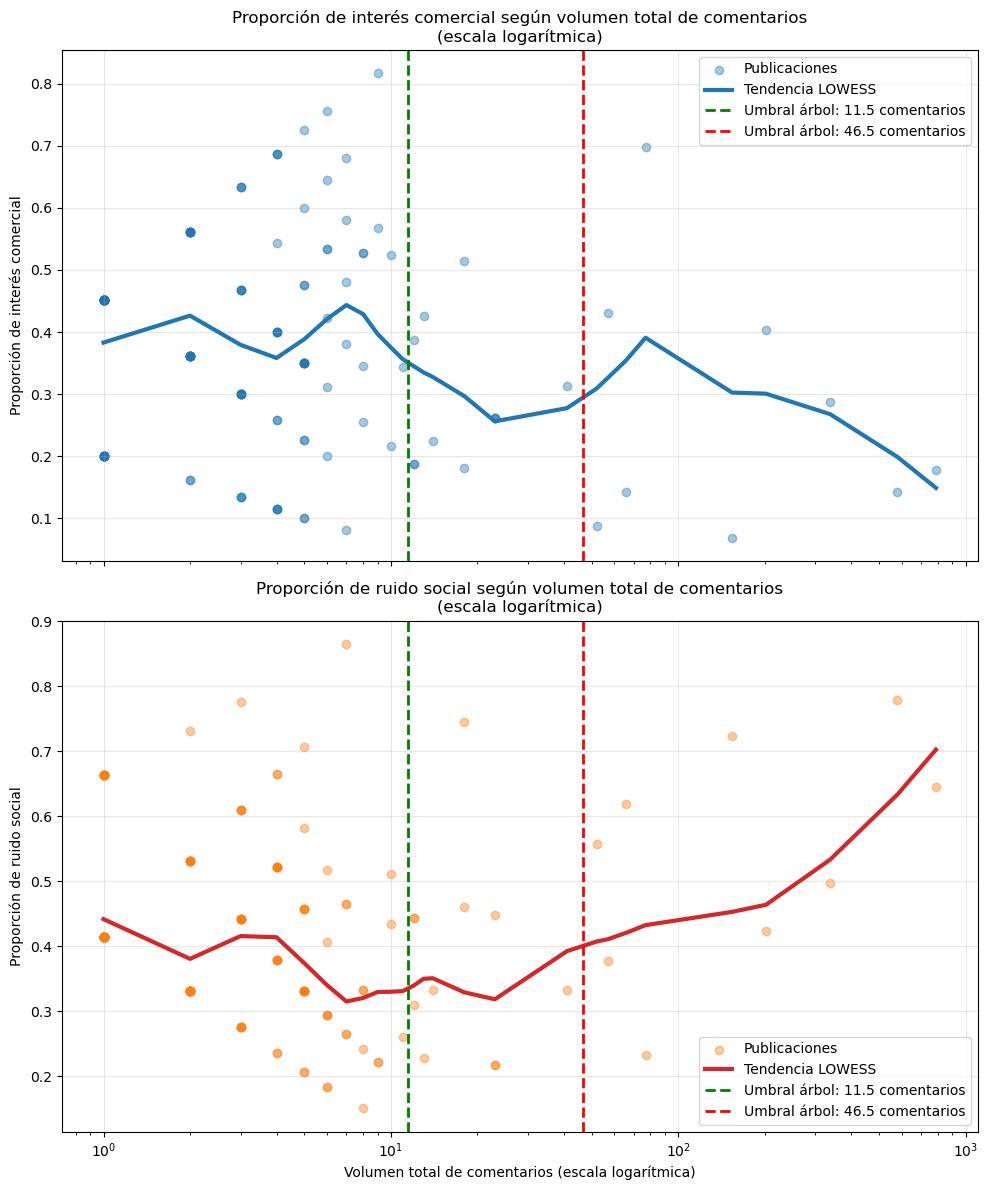

In [9]:
# Preparación de datos


data_plot = (
    df[
        [
            "volumen_total",
            "prop_interes",
            "prop_ruido_social"
        ]
    ]
    .dropna()
    .sort_values("volumen_total")
)

# LOWESS interés
lowess_interes = lowess(
    endog=data_plot["prop_interes"],
    exog=data_plot["volumen_total"],
    frac=0.40
)

# LOWESS ruido
lowess_ruido = lowess(
    endog=data_plot["prop_ruido_social"],
    exog=data_plot["volumen_total"],
    frac=0.40
)

#==========================
# Figura
#==========================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10,12),
    sharex=True
)

#====================================================
# GRÁFICO SUPERIOR
#====================================================

axes[0].scatter(
    data_plot["volumen_total"],
    data_plot["prop_interes"],
    alpha=0.40,
    label="Publicaciones"
)

axes[0].plot(
    lowess_interes[:,0],
    lowess_interes[:,1],
    linewidth=3,
    label="Tendencia LOWESS"
)

axes[0].axvline(
    11.5,
    color="green",
    linestyle="--",
    linewidth=2,
    label="Umbral árbol: 11.5 comentarios"
)

axes[0].axvline(
    46.5,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Umbral árbol: 46.5 comentarios"
)

axes[0].set_xscale("log")

axes[0].set_ylabel(
    "Proporción de interés comercial"
)

axes[0].set_title(
    "Proporción de interés comercial según volumen total de comentarios\n"
    "(escala logarítmica)"
)

axes[0].grid(alpha=0.3)

axes[0].legend()


#====================================================
# GRÁFICO INFERIOR
#====================================================

axes[1].scatter(
    data_plot["volumen_total"],
    data_plot["prop_ruido_social"],
    alpha=0.40,
    color="tab:orange",
    label="Publicaciones"
)

axes[1].plot(
    lowess_ruido[:,0],
    lowess_ruido[:,1],
    linewidth=3,
    color="tab:red",
    label="Tendencia LOWESS"
)

axes[1].axvline(
    11.5,
    color="green",
    linestyle="--",
    linewidth=2,
    label="Umbral árbol: 11.5 comentarios"
)

axes[1].axvline(
    46.5,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Umbral árbol: 46.5 comentarios"
)

axes[1].set_xscale("log")

axes[1].set_xlabel(
    "Volumen total de comentarios (escala logarítmica)"
)

axes[1].set_ylabel(
    "Proporción de ruido social"
)

axes[1].set_title(
    "Proporción de ruido social según volumen total de comentarios\n"
    "(escala logarítmica)"
)

axes[1].grid(alpha=0.3)

axes[1].legend()

plt.tight_layout()

plt.show()

>**Figura. Relación entre el volumen total de comentarios (escala logarítmica) y la composición de la conversación.** El panel superior muestra la proporción de interés comercial, mientras que el panel inferior presenta la proporción de ruido social. En ambos casos, los puntos corresponden a publicaciones individuales, la línea continua representa el suavizado no paramétrico LOWESS y las líneas verticales discontinuas indican los umbrales de interacción identificados mediante el árbol de decisión (11,5 y 46,5 comentarios). La escala logarítmica permite descomprimir la elevada concentración de publicaciones de bajo volumen y visualizar con mayor detalle los cambios en la tendencia alrededor de los umbrales identificados.

### Interpretación

En conjunto, ambos gráficos permiten comprender con mayor claridad los resultados obtenidos previamente mediante el modelo Binomial Negativa y entregan evidencia visual que respalda la utilidad del árbol de decisión como herramienta exploratoria para identificar comportamientos no lineales.

En el modelo Binomial Negativa se observó una asociación negativa fuerte y estadísticamente significativa entre la proporción de ruido social y el volumen esperado de interés comercial (**β = −4.69**; **p < 0.001**). Este resultado indicó que, manteniendo constantes las demás variables, publicaciones con una conversación relativamente más dominada por ruido social tendían, en promedio, a presentar un menor volumen esperado de comentarios de interés comercial. En términos generales, esta fue una de las relaciones más importantes identificadas por el modelo y permitió explicar una parte considerable de la variabilidad observada en el conjunto de datos.

Sin embargo, el análisis de residuos mostró que el modelo presentaba dificultades para representar adecuadamente las publicaciones con mayor viralidad, concentrando precisamente en ellas las mayores subpredicciones y sobrepredicciones. Esta aparente contradicción motivó la exploración mediante modelos basados en árboles, cuyo objetivo no fue mejorar la capacidad predictiva, sino identificar posibles cambios estructurales en el comportamiento de los datos que un modelo lineal no puede representar.

Los umbrales identificados por el árbol de decisión (aproximadamente 11,5 y 46,5 comentarios) sugieren precisamente la existencia de distintos regímenes de interacción. En las publicaciones de bajo volumen, donde se concentra la gran mayoría de las observaciones del conjunto de datos, la composición porcentual de la conversación presenta una elevada variabilidad debido al reducido número de comentarios. En este régimen, pequeñas diferencias de uno o dos comentarios modifican considerablemente las proporciones de interés y ruido, generando una dispersión elevada sin una tendencia claramente definida.

A medida que las publicaciones alcanzan niveles intermedios de interacción, la proporción de interés comercial tiende a estabilizarse en valores relativamente altos, mientras que la proporción de ruido permanece contenida. Esta región corresponde a publicaciones donde la conversación continúa centrada principalmente en el producto, por lo que una interacción más "limpia" se asocia con mayores niveles de interés comercial.

No obstante, una vez superado aproximadamente el segundo umbral identificado por el árbol, ambas curvas muestran un cambio sistemático de comportamiento. La proporción de interés comercial comienza a disminuir progresivamente conforme aumenta el volumen total de comentarios, mientras que la proporción de ruido social presenta la tendencia opuesta, incrementándose de forma sostenida. En otras palabras, las publicaciones más virales siguen generando un mayor volumen absoluto de comentarios de interés comercial, pero dicho crecimiento es sobrepasado por un incremento aún mayor del ruido social, haciendo que el interés represente una fracción cada vez menor de la conversación total.

Este comportamiento ofrece una explicación plausible para las limitaciones observadas en el modelo Binomial Negativa. Dado que la mayor parte de las publicaciones del conjunto de datos se concentra por debajo del primer umbral de interacción, el modelo lineal estima principalmente la relación predominante en esa región, donde una menor proporción de ruido social se asocia con mayores niveles de interés comercial. En consecuencia, el coeficiente negativo estimado para la proporción de ruido (β = −4.69) representa adecuadamente el comportamiento promedio del conjunto de datos. Sin embargo, los resultados obtenidos mediante el árbol de decisión y las curvas LOWESS sugieren que esta relación deja de ser suficiente para describir el comportamiento de las publicaciones altamente virales. En dichos casos, el volumen absoluto de interés comercial continúa aumentando, pero simultáneamente la conversación incorpora una cantidad aún mayor de comentarios no comerciales, modificando la composición global de la interacción. Debido a que el modelo Binomial Negativa estima una única pendiente para todo el conjunto de observaciones, no puede representar explícitamente este cambio de régimen, lo que constituye una explicación consistente para las mayores subpredicciones y sobrepredicciones observadas en las publicaciones de alta viralidad.

Es importante señalar que estos resultados no constituyen una demostración formal de la existencia de distintos regímenes de comportamiento, sino evidencia exploratoria consistente con dicha hipótesis. No obstante, la concordancia entre el análisis exploratorio inicial, la magnitud y significancia del coeficiente estimado para la proporción de ruido social en el modelo Binomial Negativa, el comportamiento de sus residuos y los umbrales identificados mediante el árbol de decisión proporciona indicios sólidos de que la dinámica de la conversación podría variar en función del nivel de viralidad alcanzado por cada publicación.

### Comparación del aporte comercial acumulado según régimen de viralidad

A partir de los umbrales identificados mediante el árbol de decisión, se definieron distintos regímenes de interacción según el volumen total de comentarios generado por cada publicación. Este análisis busca complementar la interpretación del comportamiento de la composición conversacional, evaluando no solo la eficiencia relativa de cada régimen (proporción de interés comercial), sino también su contribución absoluta al volumen total de interacciones de interés.

**Pregunta de análisis:**

¿El valor comercial generado por DreamMaker proviene principalmente de un gran número de publicaciones pequeñas con conversaciones más limpias y eficientes, o de un número reducido de publicaciones altamente virales que, aunque presentan mayor ruido social, concentran grandes volúmenes absolutos de interés?

Creamos variable de régimen según umbrales del árbol

In [11]:
def asignar_regimen(volumen):

    if volumen <= 11.5:
        return "Régimen 1: Bajo volumen"

    elif volumen <= 46.5:
        return "Régimen 2: Intermedio"

    else:
        return "Régimen 3: Viral"


df_regimen = df.copy()

df_regimen["regimen"] = (
    df_regimen["volumen_total"]
    .apply(asignar_regimen)
)


df_regimen["regimen"].value_counts()

regimen
Régimen 1: Bajo volumen    135
Régimen 2: Intermedio       11
Régimen 3: Viral             9
Name: count, dtype: int64

Tabla resumen por régimen

In [12]:
resumen_regimen = (
    df_regimen
    .groupby("regimen")
    .agg(
        publicaciones=("volumen_total","count"),
        volumen_total_promedio=("volumen_total","mean"),
        volumen_interes_total=("volumen_interes","sum"),
        volumen_interes_promedio=("volumen_interes","mean"),
        prop_interes_promedio=("prop_interes","mean"),
        prop_ruido_promedio=("prop_ruido_social","mean")
    )
    .reset_index()
)


resumen_regimen

,regimen,publicaciones,volumen_total_promedio,volumen_interes_total,volumen_interes_promedio,prop_interes_promedio,prop_ruido_promedio
0,Régimen 1: Bajo volumen,135,3.214815,227,1.681481,0.392765,0.429046
1,Régimen 2: Intermedio,11,19.000000,62,5.636364,0.291321,0.379964
2,Régimen 3: Viral,9,257.111111,504,56.000000,0.270745,0.539401


Calcular participación del interés comercial total

In [13]:
interes_total = df_regimen["volumen_interes"].sum()


resumen_regimen["aporte_interes_%"] = (
    resumen_regimen["volumen_interes_total"]
    /
    interes_total
    *100
)


resumen_regimen

,regimen,publicaciones,volumen_total_promedio,volumen_interes_total,volumen_interes_promedio,prop_interes_promedio,prop_ruido_promedio,aporte_interes_%
0,Régimen 1: Bajo volumen,135,3.214815,227,1.681481,0.392765,0.429046,28.625473
1,Régimen 2: Intermedio,11,19.000000,62,5.636364,0.291321,0.379964,7.818411
2,Régimen 3: Viral,9,257.111111,504,56.000000,0.270745,0.539401,63.556116


Agregar porcentaje de publicaciones (esto es importante porque muestra si el valor viene de muchas publicaciones o de pocas).

In [14]:
total_posts = len(df_regimen)


resumen_regimen["participacion_publicaciones_%"] = (
    resumen_regimen["publicaciones"]
    /
    total_posts
    *100
)


resumen_regimen

,regimen,publicaciones,volumen_total_promedio,volumen_interes_total,volumen_interes_promedio,prop_interes_promedio,prop_ruido_promedio,aporte_interes_%,participacion_publicaciones_%
0,Régimen 1: Bajo volumen,135,3.214815,227,1.681481,0.392765,0.429046,28.625473,87.096774
1,Régimen 2: Intermedio,11,19.000000,62,5.636364,0.291321,0.379964,7.818411,7.096774
2,Régimen 3: Viral,9,257.111111,504,56.000000,0.270745,0.539401,63.556116,5.806452


Ordenar para lectura:

In [15]:
resumen_regimen = (
    resumen_regimen
    .sort_values(
        "regimen"
    )
)


resumen_regimen

,regimen,publicaciones,volumen_total_promedio,volumen_interes_total,volumen_interes_promedio,prop_interes_promedio,prop_ruido_promedio,aporte_interes_%,participacion_publicaciones_%
0,Régimen 1: Bajo volumen,135,3.214815,227,1.681481,0.392765,0.429046,28.625473,87.096774
1,Régimen 2: Intermedio,11,19.000000,62,5.636364,0.291321,0.379964,7.818411,7.096774
2,Régimen 3: Viral,9,257.111111,504,56.000000,0.270745,0.539401,63.556116,5.806452


Visualización:

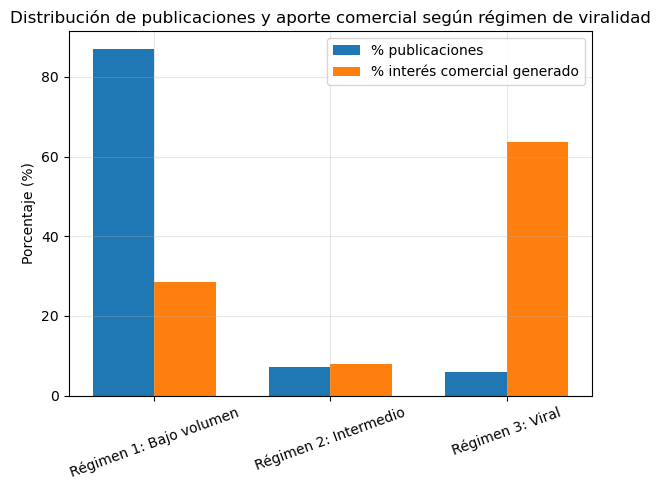

In [46]:
x = np.arange(len(resumen_regimen))

width = 0.35


# Guardar figura completa
fig_regimen_aporte, ax_regimen_aporte = plt.subplots(
    figsize=(6,5)
)


ax_regimen_aporte.bar(
    x-width/2,
    resumen_regimen["participacion_publicaciones_%"],
    width,
    label="% publicaciones"
)


ax_regimen_aporte.bar(
    x+width/2,
    resumen_regimen["aporte_interes_%"],
    width,
    label="% interés comercial generado"
)


ax_regimen_aporte.set_xticks(
    x
)

ax_regimen_aporte.set_xticklabels(
    resumen_regimen["regimen"],
    rotation=20
)


ax_regimen_aporte.set_ylabel(
    "Porcentaje (%)"
)


ax_regimen_aporte.set_title(
    "Distribución de publicaciones y aporte comercial según régimen de viralidad"
)


ax_regimen_aporte.legend()


ax_regimen_aporte.grid(
    alpha=0.3
)


plt.tight_layout()


# Variable reutilizable para conclusiones
grafico_regimen_aporte = fig_regimen_aporte


plt.show()

**Interpretación: Aporte comercial acumulado según régimen de viralidad**

La segmentación de las publicaciones según los umbrales identificados por el árbol de decisión permite complementar el análisis anterior, diferenciando entre **eficiencia relativa de la conversación y aporte absoluto de interés comercial generado.**

Los resultados muestran una dinámica relevante: aunque las publicaciones de menor volumen presentan una mayor proporción promedio de interés comercial, no son las que concentran la mayor cantidad de interacciones comerciales acumuladas.

El **Régimen 1** (**bajo volumen**, **≤11,5 comentarios**) concentra la gran mayoría de las publicaciones analizadas (**87,1%** del total), con 135 publicaciones. Estas publicaciones presentan la mayor eficiencia relativa, alcanzando una proporción promedio de interés comercial de 39,3%, junto con la menor proporción promedio de ruido social (**42,9%**). Sin embargo, debido a su bajo nivel de interacción individual (promedio de **3,2** comentarios totales por publicación), este régimen genera **227 interacciones de interés acumuladas**, equivalente al **28,6% del interés comercial total.**

Por otro lado, el **Régimen 3** (**viral, >46,5** comentarios) presenta un comportamiento opuesto. Este grupo representa solamente **5,8%** de las publicaciones (9 casos), pero concentra 504 interacciones de interés comercial, equivalente al **63,6% del interés total generado por el conjunto de publicaciones**. Esto ocurre debido a que, aunque su proporción de interés comercial promedio es menor (27,1%) que la observada en publicaciones pequeñas, el volumen absoluto de conversación es considerablemente mayor, alcanzando un promedio de **257 comentarios por publicación y 56 interacciones de interés por publicación.**

Este resultado confirma una aparente paradoja identificada durante el análisis de composición conversacional: las publicaciones virales son menos eficientes desde el punto de vista de la proporción de interés comercial, debido al crecimiento del ruido social (**53,9% promedio en este régimen**), pero tienen un impacto desproporcionadamente mayor en términos de volumen absoluto de interés generado.

El **Régimen 2** (**intermedio, entre 11,5 y 46,5 comentarios**) representa una zona de transición. Aunque presenta un volumen mayor que las publicaciones pequeñas, mantiene una eficiencia inferior (**29,1% de interés promedio**) y aporta solamente **7,8% del interés total acumulado**, sugiriendo que este rango no maximiza ni eficiencia ni escala.

En conjunto, estos resultados permiten matizar la interpretación anterior sobre la relación entre viralidad y composición de la conversación. El aumento del volumen total de comentarios no implica necesariamente una mayor proporción de interés comercial, ya que las publicaciones virales incorporan progresivamente mayores niveles de ruido social. Sin embargo, la escala alcanzada por estos eventos compensa dicha pérdida de eficiencia, convirtiéndolos en los principales generadores de interés comercial absoluto dentro del conjunto analizado.

Por lo tanto, el análisis sugiere que una estrategia enfocada exclusivamente en maximizar la "limpieza" de la conversación podría ser contraproducente. Priorizar únicamente publicaciones pequeñas y altamente eficientes implicaría depender de un gran número de publicaciones para alcanzar niveles de interés comercial que un número reducido de publicaciones virales puede generar por sí solo.

Estos resultados sugieren que el objetivo del negocio no debería ser eliminar necesariamente el ruido asociado a la viralidad, sino identificar aquellas publicaciones capaces de generar una alta respuesta del público y posteriormente evaluar qué proporción de esa atención puede convertirse en interés comercial.

En este sentido, los resultados del árbol de decisión adquieren una interpretación más amplia: los distintos regímenes no representan necesariamente categorías de publicaciones "buenas" y "malas", **sino mecanismos diferentes de generación de valor**. Las publicaciones pequeñas destacan por eficiencia conversacional, mientras que las publicaciones virales destacan por capacidad de amplificación e impacto comercial absoluto.

# Síntesis final del proyecto:

**Resumen**

El objetivo principal de este proyecto fue comprender qué factores explican la generación de interés comercial dentro de las publicaciones de DreamMaker, utilizando información obtenida desde la clasificación semántica de comentarios mediante modelos NLP.

A lo largo del análisis se identificó un resultado central: **el volumen absoluto de interacción y la composición relativa de la conversación representan fenómenos distintos, y no deben interpretarse como métricas equivalentes**.

Por una parte, las métricas proporcionales permiten evaluar qué tan enfocada está una conversación hacia señales comerciales:

$$
prop\_interes = \frac{volumen\_interes}{volumen\_total}
$$

Esta métrica representa una medida de eficiencia relativa de la conversación, ya que indica qué fracción del total de interacciones corresponde a señales asociadas a interés comercial.

Por otra parte, las métricas absolutas permiten cuantificar el impacto real en términos de cantidad total de interacciones:

$$
volumen\_interes
$$
es decir, la cantidad total de interacciones asociadas potencialmente a intención comercial.

Esta diferencia resulta fundamental porque una publicación puede presentar una menor proporción de interés comercial debido a una alta presencia de ruido social, pero aun así generar un volumen absoluto de interés muy superior a publicaciones con conversaciones más limpias pero de menor alcance.

El análisis completo permitió identificar que DreamMaker presenta una dinámica de interacción dominada por eventos de alta viralidad: una pequeña proporción de publicaciones concentra una fracción mayoritaria del interés comercial generado.

Los principales hallazgos fueron:

- La proporción de ruido social presenta una relación negativa y estadísticamente significativa con el volumen esperado de interés comercial en el modelo Binomial Negativo.
- Sin embargo, esta relación describe principalmente el comportamiento promedio del conjunto de datos.
- El árbol de decisión identificó distintos regímenes de comportamiento según el nivel de viralidad alcanzado por una publicación.
- Las publicaciones altamente virales presentan mayor contaminación relativa, pero concentran la mayor parte del interés comercial acumulado.
- Por lo tanto, la estrategia óptima no necesariamente consiste en maximizar la limpieza de la conversación, sino en identificar publicaciones con capacidad de amplificación y evaluar posteriormente cuánto de esa atención se transforma en interés comercial.

---

## Historia del análisis: desde la exploración hasta la inferencia estadística

**Separación entre eficiencia conversacional e impacto comercial**

El análisis exploratorio inicial mostró que las variables asociadas al volumen de comentarios presentan una distribución altamente asimétrica.

La mayoría de las publicaciones concentran bajos niveles de interacción, mientras que unas pocas publicaciones alcanzan niveles extraordinariamente altos de participación.

Esta característica fue relevante porque una interpretación basada únicamente en promedios o proporciones podía ocultar la existencia de eventos extremos con impacto comercial significativo.

A nivel agregado, se observó que:

- El volumen promedio de ruido social supera al volumen promedio de interés comercial.
- Sin embargo, las proporciones medias muestran que existe una fracción relevante de conversación asociada al producto.

Esto permitió plantear una primera hipótesis:

> La composición de la conversación permite evaluar la eficiencia relativa de una publicación, pero no necesariamente representa su impacto comercial total.

Por esta razón, durante el análisis se trabajó simultáneamente con métricas absolutas y relativas.

---

##  Análisis exploratorio por personajes históricos: el caso de la viralidad extrema

El análisis por personajes históricos permitió observar uno de los primeros ejemplos del desacople entre eficiencia relativa y volumen absoluto.

Al comparar las categorías se identificó que algunos personajes generan conversaciones altamente enfocadas en interés comercial, pero con bajo volumen absoluto.

Por ejemplo, personajes tradicionales presentan:

- Alta proporción de interés comercial.
- Bajo volumen promedio de comentarios asociados a intención comercial.

En contraste, personajes altamente polarizantes presentan:

- Menor proporción relativa de interés.
- Pero volúmenes absolutos significativamente mayores.

El caso más representativo corresponde a publicaciones asociadas a Pinochet.

Estas publicaciones presentan una dinámica distinta:

- Elevado volumen total de comentarios.
- Alta presencia de ruido social.
- Pero también una cantidad absoluta considerable de interacciones clasificadas como interés comercial.

Esto permitió formular una primera hipótesis:

> El ruido social no necesariamente genera intención comercial por sí mismo, pero puede actuar como amplificador de alcance cuando existe una demanda latente asociada al tema.

Esta hipótesis fue posteriormente evaluada mediante modelos estadísticos y análisis no lineal.

---

##  Análisis institucional: el ruido no siempre explica el interés comercial

El análisis por instituciones permitió observar que la relación entre polémica e interés comercial no es universal.

Algunas categorías presentan elevados niveles de ruido social sin generar aumentos equivalentes en interés comercial.

Por otro lado, instituciones con menor contaminación conversacional pueden alcanzar niveles relevantes de interés comercial.

El caso de Ejército resulta particularmente interesante:

- Presenta una conversación relativamente más limpia.
- Mantiene un volumen comercial comparable a categorías con mayor nivel de ruido.
- Contiene publicaciones con altos niveles individuales de interés comercial.

Sin embargo, debido al tamaño muestral y desbalance entre categorías, estos resultados deben interpretarse como evidencia descriptiva y no como una relación causal confirmada.

---

##  Validación estadística: qué patrones sobreviven al contraste de hipótesis

Debido a que las variables analizadas no cumplen supuestos de normalidad y existen fuertes diferencias en tamaño muestral entre categorías, se utilizaron pruebas no paramétricas.

Se aplicó Kruskal-Wallis acompañado de tamaño del efecto mediante epsilon cuadrado (ε²), permitiendo diferenciar entre:

- Diferencias estadísticamente significativas.
- Diferencias con magnitud relevante pero limitada evidencia estadística.

**Personajes históricos**

| Variable | H | p-value | ε² | Interpretación |
|---|---:|---:|---:|---|
| volumen_ruido | 16.18 | 0.0235 | 0.765 | Diferencias significativas |
| prop_ruido_social | 14.26 | 0.0467 | 0.605 | Diferencias significativas |
| volumen_interes | 11.62 | 0.1136 | 0.385 | Efecto grande, sin significancia |
| prop_interes | 13.75 | 0.0558 | 0.563 | Cercano al umbral, no significativo |

Los resultados indican que los personajes históricos presentan diferencias claras en la dinámica social generada, especialmente respecto al nivel de ruido y polarización.

Las diferencias en interés comercial muestran tamaños de efecto elevados, pero no alcanzan significancia estadística, probablemente debido a:

- Baja cantidad de publicaciones en algunas categorías.
- Concentración del interés comercial en pocos eventos extremos.

---

**Instituciones**

| Variable | H | p-value | ε² | Interpretación |
|---|---:|---:|---:|---|
| volumen_interes | 1.90 | 0.7536 | ≈0 | Sin evidencia global |
| prop_interes | 5.76 | 0.2177 | 0.050 | Sin evidencia global |
| volumen_ruido | 5.86 | 0.2102 | 0.053 | Sin evidencia global |
| prop_ruido_social | 6.53 | 0.1629 | 0.072 | Sin evidencia global |

En instituciones no se encontraron diferencias estadísticamente significativas.

Sin embargo, este resultado debe interpretarse considerando las limitaciones del dataset:

- Ejército cuenta con 24 publicaciones.
- Carabineros con 8.
- Algunas categorías cuentan solamente con 2 publicaciones.

Por lo tanto, la falta de significancia no implica necesariamente ausencia de diferencias reales, sino baja potencia estadística para detectarlas.

---

## Modelo explicativo del volumen de interés comercial: Regresión Binomial Negativa

**Motivación y selección del modelo**

Dado que la variable objetivo corresponde a un conteo de interacciones comerciales (`volumen_interes`), se descartó el uso de modelos lineales tradicionales debido a que esta variable presenta características propias de datos de conteo:

- Valores enteros no negativos.
- Alta asimetría en la distribución.
- Presencia de publicaciones con niveles de interacción extremadamente superiores al promedio.

Inicialmente se evaluó un modelo Poisson; sin embargo, la elevada dispersión observada en los datos (varianza superior a la media) motivó la utilización de una regresión Binomial Negativa, la cual permite modelar adecuadamente escenarios donde existen eventos extremos de alta interacción.

El objetivo del modelo no fue únicamente maximizar capacidad predictiva, sino cuantificar la asociación entre características de la publicación y el volumen esperado de interés comercial, controlando simultáneamente por el efecto del resto de variables.



###  Resultados principales del modelo

La variable dependiente utilizada fue:

$$
Y = volumen\_interes
$$

El modelo estimado presentó:

- Número de observaciones: 155 publicaciones.
- Pseudo R²: 0.2436.
- Significancia global del modelo: p-value < 0.001.

Los principales coeficientes obtenidos fueron:

| Variable | β | p-value | IRR aproximado | Interpretación |
|---|---:|---:|---:|---|
| prop_ruido_social | -4.69 | <0.001 | 0.009 | Fuerte asociación negativa |
| post_carabineros | 2.06 | <0.001 | 7.82 | Mayor volumen esperado |
| post_pinochet | 4.99 | <0.001 | Muy elevado | Efecto asociado a viralidad extrema |
| post_prat | 0.60 | 0.017 | 1.82 | Asociación positiva |
| post_ohiggins | 1.35 | <0.001 | 3.85 | Asociación positiva |
| post_ejercito | 0.41 | 0.139 | 1.51 | Tendencia positiva, no significativa |
| post_producto_materializado | 0.17 | 0.375 | 1.19 | Sin evidencia estadística |
| post_con_precio | 0.40 | 0.155 | 1.49 | Sin evidencia estadística |
| post_no_venta | -2.43 | <0.001 | Bajo | Menor interés esperado |
| post_avance_proyecto | -0.65 | 0.029 | Bajo | Menor interés esperado |



###  Interpretación del efecto del ruido social

El resultado más relevante del modelo corresponde a la variable:

$$
prop\_ruido\_social
$$

que presenta un coeficiente:

$$
\beta=-4.69
$$

con significancia estadística:

$$
p<0.001
$$

Esto indica que, manteniendo constantes las demás variables del modelo, una mayor proporción de ruido social se asocia con una reducción significativa del volumen esperado de interés comercial.

Desde una perspectiva estadística, el resultado sugiere que las publicaciones con conversaciones relativamente más orientadas hacia ruido social tienden a generar menos interacciones comerciales esperadas.

Sin embargo, este coeficiente representa una relación promedio sobre todo el conjunto de datos. Debido a que la mayoría de las publicaciones se concentran en niveles bajos de interacción, el modelo captura principalmente el comportamiento dominante de publicaciones pequeñas y medianas.

Por esta razón, este resultado debe interpretarse con cautela: una relación negativa promedio no necesariamente implica que el ruido sea perjudicial en todos los escenarios de viralidad.



###  Limitación del modelo: una única relación promedio para distintos comportamientos

Aunque la regresión Binomial Negativa permite cuantificar asociaciones relevantes, asume implícitamente que las relaciones entre las variables explicativas y el volumen comercial siguen una estructura relativamente estable.

Sin embargo, el análisis exploratorio mostró evidencia de que algunas publicaciones presentan comportamientos muy diferentes:

- La mayoría de publicaciones generan pocos comentarios.
- Un pequeño grupo alcanza niveles extraordinarios de interacción.
- En estos casos extremos, aumenta simultáneamente tanto el interés comercial absoluto como el ruido social.

Esto plantea una pregunta adicional:

> ¿La relación entre composición de la conversación e interés comercial permanece constante a lo largo de todo el rango de viralidad, o existen distintos regímenes de comportamiento?

Para explorar esta posibilidad se utilizó posteriormente un árbol de decisión con objetivo `prop_interes`, buscando identificar umbrales naturales donde la composición de la conversación cambia según el nivel de interacción alcanzado.

El objetivo del árbol no fue reemplazar al modelo Binomial Negativo ni maximizar predicción, sino explorar posibles estructuras no lineales y generar hipótesis sobre diferentes dinámicas de comportamiento.

---

## Árbol de decisión: identificación de regímenes de comportamiento según viralidad

### Motivación del análisis

Los resultados obtenidos mediante la regresión Binomial Negativa mostraron una asociación negativa y estadísticamente significativa entre la proporción de ruido social y el volumen esperado de interés comercial.

Sin embargo, el análisis exploratorio había mostrado evidencia de que algunas publicaciones altamente virales presentaban un comportamiento diferente: aunque la proporción de interés comercial disminuía, el volumen absoluto de interés podía alcanzar niveles considerablemente superiores.

**Esto sugirió que la relación entre composición de la conversación e interés comercial podría no ser constante a lo largo de todo el rango de interacción.**

Para explorar esta hipótesis se entrenó un árbol de decisión utilizando como variable objetivo:

$$
prop\_interes = \frac{volumen\_interes}{volumen\_total}
$$

y utilizando como variables explicativas características asociadas a la publicación.

El objetivo principal del árbol no fue maximizar capacidad predictiva, sino identificar patrones interpretables y posibles puntos de cambio en la dinámica conversacional.




###  Importancia de variables y principales reglas identificadas

El modelo permitió identificar qué variables explicaban principalmente la variación en la proporción de interés comercial.

La importancia relativa obtenida fue:

| Variable | Importancia |
|---|---:|
| volumen_total | 64.6% |
| post_ejercito | 19.9% |
| post_con_precio | 8.5% |
| post_producto_materializado | 7.0% |
| Otras variables | 0% |

El resultado más relevante es que **el volumen total de comentarios emerge como la principal variable asociada a cambios en la composición de la conversación**, concentrando aproximadamente dos tercios de la capacidad explicativa del árbol.

Esto sugiere que la relación entre ruido social e interés comercial no puede interpretarse únicamente como una relación lineal global, sino que depende del nivel de viralidad alcanzado por la publicación.

Aunque algunas variables asociadas al contenido aparecen con cierta importancia secundaria (principalmente `post_ejercito`, `post_con_precio` y `post_producto_materializado`), el árbol no identifica patrones dominantes asociados a personajes o características individuales, sino principalmente a **distintos niveles de escala de interacción**.



### Identificación de regímenes de comportamiento

Las principales divisiones realizadas por el árbol se concentran en dos umbrales de volumen total:

- **11.5 comentarios**
- **46.5 comentarios**

Estos cortes permiten interpretar tres zonas diferenciadas de comportamiento:

#### Régimen 1: Bajo volumen (< 11.5 comentarios)

Corresponde a la mayoría de las publicaciones del dataset.

En este rango existe una alta variabilidad en la composición de la conversación, debido a que pequeñas cantidades absolutas de comentarios pueden modificar significativamente las proporciones.

Por ejemplo, una publicación con pocos comentarios puede presentar una proporción elevada de interés comercial simplemente porque uno o dos usuarios manifiestan intención de compra.

Por esta razón, en este régimen las proporciones deben interpretarse con cautela, ya que representan principalmente eficiencia relativa y no necesariamente impacto comercial.



#### Régimen 2: Volumen intermedio (11.5 - 46.5 comentarios)

En este rango la composición de la conversación comienza a estabilizarse.

El árbol identifica una disminución de la proporción esperada de interés comercial respecto al régimen de bajo volumen, pero todavía corresponde a publicaciones donde existe una relación relativamente equilibrada entre alcance e intención comercial.

Este régimen representa una zona donde la conversación alcanza suficiente escala para que las proporciones sean más representativas del comportamiento real de la audiencia.


#### Régimen 3: Alto volumen o viral (>46.5 comentarios)

Este régimen presenta un comportamiento claramente diferenciado.

Las publicaciones altamente virales muestran una menor proporción relativa de interés comercial y un aumento de la proporción de ruido social. Sin embargo, esta reducción de eficiencia relativa ocurre simultáneamente con un crecimiento muy importante del volumen absoluto de interés generado.

En otras palabras, la conversación se vuelve proporcionalmente más contaminada, pero también alcanza una escala donde la cantidad absoluta de usuarios interesados puede superar ampliamente a publicaciones más limpias.

Este comportamiento explica la aparente contradicción observada entre la regresión Binomial Negativa y el análisis exploratorio.

---

### Reconciliación con el modelo Binomial Negativo

La regresión Binomial Negativa encontró una relación negativa entre `prop_ruido_social` y el volumen esperado de interés comercial.

Este resultado describe correctamente el comportamiento promedio de la mayoría de las publicaciones, especialmente aquellas ubicadas en los regímenes de bajo e intermedio volumen.

Sin embargo, el árbol revela que esta relación no es constante en todo el espacio de interacción.

En el régimen viral, el aumento del ruido social deja de comportarse únicamente como un factor negativo y comienza a estar asociado con una expansión significativa del alcance total de la publicación.

Esto permite interpretar ambos resultados como complementarios:

- En publicaciones pequeñas y medianas, una conversación más limpia tiende a favorecer una mayor eficiencia relativa de interés comercial.
- En publicaciones virales, el crecimiento del alcance puede compensar una menor proporción de interés, generando un volumen absoluto de clientes potenciales mucho mayor.

Por lo tanto, el coeficiente negativo obtenido en la regresión no debe interpretarse como una regla universal de negocio, sino como una descripción del comportamiento dominante del dataset.

El árbol permitió identificar que existen **distintos regímenes conversacionales**, donde la misma variable (`prop_ruido_social`) puede tener implicancias diferentes dependiendo de la escala alcanzada por la publicación.

---

### Aporte comercial acumulado por régimen

Una vez identificados estos regímenes surge una pregunta de negocio fundamental:

> ¿El mayor aporte comercial proviene de muchas publicaciones pequeñas y eficientes, o de pocas publicaciones altamente virales aunque tengan una conversación más contaminada?

Para responder esta pregunta se dejó de analizar únicamente la eficiencia relativa (`prop_interes`) y se evaluó el aporte absoluto acumulado de interés comercial generado por cada régimen.

| Régimen | Publicaciones | Participación publicaciones | Volumen interés total | Aporte interés comercial |
|---|---:|---:|---:|---:|
| Régimen 1: Bajo volumen | 135 | 87.1% | 227 | 28.6% |
| Régimen 2: Intermedio | 11 | 7.1% | 62 | 7.8% |
| Régimen 3: Viral | 9 | 5.8% | 504 | 63.6% |

Los resultados muestran una diferencia relevante entre eficiencia e impacto.

El régimen de bajo volumen concentra la mayoría de las publicaciones (87.1%) y presenta una proporción promedio de interés comercial superior. Sin embargo, debido a su bajo nivel de interacción individual, representa solamente el 28.6% del interés comercial total acumulado.

En contraste, el régimen viral representa únicamente el 5.8% de las publicaciones, pero concentra el 63.6% del volumen total de interés comercial generado por la página.

Esto indica que, desde una perspectiva estrictamente de negocio, las publicaciones más relevantes no necesariamente son aquellas con una mayor "limpieza" conversacional, sino aquellas capaces de generar suficiente escala para transformar una fracción de la audiencia en interés comercial absoluto.

El hallazgo sugiere que DreamMaker no debería optimizar exclusivamente por maximizar la proporción de comentarios comerciales dentro de cada publicación, sino identificar qué características permiten generar publicaciones con capacidad de amplificación masiva y posteriormente evaluar la calidad comercial de esa atención generada.

---


# Insights para DreamMaker

Los siguientes insights sintetizan los principales hallazgos del proyecto. Cada uno se presenta junto con el nivel de evidencia que lo respalda, diferenciando entre resultados estadísticamente confirmados y patrones descriptivos observados en el análisis exploratorio.

---

## Insight 1 — La viralidad es el principal motor del interés comercial acumulado

**[Confirmado mediante evidencia descriptiva consistente y segmentación del árbol de decisión]**

El árbol de decisión permitió identificar tres regímenes naturales de comportamiento según el volumen total de comentarios.

El análisis posterior mostró que, aunque las publicaciones altamente virales representan únicamente **5,8%** del catálogo, concentran aproximadamente **63,6% de todo el interés comercial generado por la página**.

En contraste, las publicaciones de bajo volumen corresponden al **87,1%** del catálogo, pero aportan únicamente **28,6% del interés comercial acumulado**.

Esto sugiere que el principal motor del negocio no proviene de muchas publicaciones pequeñas y eficientes, sino de un reducido grupo de publicaciones capaces de alcanzar una viralidad excepcional.

En consecuencia, una estrategia orientada exclusivamente a maximizar la "limpieza" de cada publicación probablemente no maximizaría el impacto comercial global de la página.

---

## Insight 2 — Existen al menos dos estrategias comerciales exitosas

**[Patrón descriptivo consistente respaldado por múltiples análisis]**

Los resultados muestran que DreamMaker parece disponer de dos mecanismos distintos para generar interés comercial.

### Ruta 1: Viralidad mediante controversia

Representada principalmente por publicaciones de **Pinochet** y, en menor medida, **Carabineros**.

Características:

- enorme volumen de interacción;
- alto volumen absoluto de interés comercial;
- conversación altamente contaminada por ruido social;
- baja eficiencia relativa (menor proporción de interés comercial → mayor ruido social).

### Ruta 2: Viralidad orgánica de nicho

Representada principalmente por **Ejército** (instituciones) y próceres tradicionales como O'Higgins, Prat, Carrera, Manuel Rodríguez (personajes).

Características:

- conversación considerablemente más limpia;
- menor contaminación política;
- alta eficiencia relativa;
- capacidad de alcanzar elevados niveles de interés comercial sin depender de controversias.

Por lo tanto, los resultados sugieren que el crecimiento comercial no depende exclusivamente de contenidos polémicos, sino también de publicaciones capaces de movilizar comunidades altamente interesadas en el producto.

---

## Insight 3 — La "limpieza" conversacional no está negativamente correlacionada con el volumen de interés; están, de hecho, poco correlacionadas entre sí

**[Patrón exploratorio robusto en múltiples cortes del análisis, confirmado parcialmente por el modelo Binomial Negativo y reinterpretado mediante el árbol de decisión]**

La regresión Binomial Negativa encontró que una mayor proporción de ruido social se asocia, en promedio, con una disminución del volumen esperado de interés comercial.

Sin embargo, el árbol de decisión mostró que dicha relación no es constante para todos los niveles de interacción.

- En publicaciones poco virales, una conversación más limpia efectivamente se asocia con mayores niveles relativos de interés comercial.

- No obstante, una vez superados los umbrales de viralidad identificados por el árbol, el volumen absoluto de interés comercial continúa creciendo, aunque la conversación se vuelva progresivamente más ruidosa.

El árbol permitió reconciliar ambas observaciones, mostrando que el modelo lineal describe correctamente el comportamiento promedio, mientras que la dinámica cambia en publicaciones extremadamente virales.

En instituciones, la eficiencia relativa (FACH 55%, PDI 51%, Armada 48%, Ejército 46%, Carabineros 32%) tiene un orden casi inverso al del volumen absoluto (Carabineros 4,2, Ejército 3,9, Armada/FACH 2,5, PDI 1,5). En personajes, lo mismo: los próceres más "limpios" (Manuel Rodríguez 64%) tienen los volúmenes más bajos (3–5 comentarios), mientras que Pinochet, con la eficiencia más baja del grupo relevante (27%), tiene el volumen más alto por lejos (71,5). 

→ **Esto es evidencia consistente de que optimizar exclusivamente por proporción/eficiencia (una conversación "estéticamente" limpia) puede ir en contra del objetivo real de negocio, que es maximizar el volumen neto de clientes potenciales capturados.**



---

## Insight 4 — Diseños del Gral. Pinochet actúa como un catalizador excepcional de interacción comercial

**[Hallazgo respaldado por EDA, regresión Binomial Negativa y análisis descriptivo]**

Las publicaciones relacionadas con Pinochet constituyen el caso más extremo observado durante todo el análisis.

Aunque presentan una de las menores proporciones de interés comercial, generan con diferencia el mayor volumen absoluto de interacción comercial del catálogo.

La regresión Binomial Negativa identifica además un efecto altamente significativo para esta categoría.

Los resultados sugieren que el fuerte interés histórico existente alrededor de esta temática permite que la viralidad amplifique enormemente el alcance comercial de las publicaciones.

**En contraste, otras publicaciones altamente polarizadas, como Neruda, generan niveles elevados de ruido social sin traducirse en un aumento comparable del interés comercial.**

Esto sugiere que el ruido por sí solo no genera ventas; únicamente amplifica aquellas publicaciones donde previamente existe una demanda latente.

---

## Insight 5 — Ejército emerge como un caso particularmente prometedor

**[Insight de negocio recomendado; evidencia descriptiva consistente, aunque sin significancia estadística suficiente]**

Ejército presenta uno de los comportamientos más interesantes observados durante el proyecto.

A diferencia de Carabineros:

- mantiene niveles muy bajos de ruido social;
- presenta una conversación considerablemente más enfocada en el producto;
- alcanza un volumen medio de interés comercial muy similar;
- registra el mayor pico de interés comercial observado dentro del bloque institucional.

Aunque el coeficiente obtenido por la regresión Binomial Negativa no alcanzó significancia estadística, tanto el análisis exploratorio como el árbol de decisión muestran un comportamiento consistente que merece ser validado mediante futuras publicaciones.

Desde una perspectiva comercial, Ejército aparece como uno de los candidatos más prometedores para desarrollar nuevas líneas de productos sin depender de la controversia política.

---

## Insight 6 — No toda la interacción genera valor comercial

**[Confirmado estadísticamente]**

El modelo Binomial Negativa mostró que publicaciones correspondientes a:

- avances de proyecto;
- productos no disponibles para la venta;

presentan una reducción significativa del interés comercial esperado.

Esto sugiere que ambos tipos de contenido deberían analizarse por separado dentro del monitoreo comercial de DreamMaker, evitando mezclarlos con publicaciones cuyo objetivo principal es la venta de productos.

---

## Insight 7 — La eficiencia relativa y el impacto absoluto responden a objetivos distintos

**[Hallazgo consistente observado durante todo el proyecto]**

Uno de los principales resultados del análisis consiste en demostrar que las métricas relativas y absolutas describen fenómenos diferentes.

- La proporción de interés comercial mide qué tan limpia resulta la conversación.

- En cambio, el volumen absoluto de interés comercial mide cuántos potenciales clientes logra captar efectivamente una publicación.

→ **Las publicaciones más eficientes no necesariamente generan el mayor impacto comercial, mientras que algunas publicaciones altamente contaminadas terminan aportando la mayor parte del interés comercial acumulado.**

En consecuencia, ambas métricas deberían utilizarse de manera complementaria para evaluar el desempeño futuro de nuevas publicaciones.

---

## Insight 8 — La materialización del producto muestra un efecto positivo, aunque aún débil

**[Evidencia preliminar]**

El modelo Binomial Negativa estimó un efecto positivo asociado a publicaciones donde el producto ya se encontraba materializado físicamente.

Sin embargo, dicho efecto no alcanzó significancia estadística.

Por otra parte, el árbol de decisión otorgó una importancia moderada a esta variable en algunas ramas de decisión, sugiriendo que podría influir sobre la composición de la conversación bajo determinados contextos.

En conjunto, la evidencia actual no permite afirmar que la materialización aumente sistemáticamente el interés comercial, aunque sí constituye una línea de investigación prometedora para futuros análisis con un mayor número de publicaciones.

# Conclusión general del proyecto
La historia completa del proyecto puede resumirse así: el EDA reveló que la página vive dominada por eventos de alta viralidad más que por un flujo constante de interés comercial, y que separar volumen de proporción era indispensable para no confundir eficiencia con impacto. El análisis por categoría mostró que esa separación no es cosmética: personajes e instituciones "limpios" ganan en proporción pero pierden en escala, y viceversa. Las pruebas de hipótesis confirmaron diferencias reales en la dinámica social entre personajes históricos, pero no lograron (por limitaciones de tamaño y desbalance muestral, no necesariamente por ausencia real de efecto) confirmar diferencias comerciales entre instituciones. El modelo Binomial Negativo cuantificó lo anterior: el ruido social, en promedio, perjudica el interés comercial esperado (**β=-4,69**), salvo en los casos extremos de viralidad (Pinochet, Carabineros) **donde actúa como multiplicador de alcance**. El árbol de decisión explicó por qué ambas cosas son ciertas a la vez: existen regímenes distintos de comportamiento según el volumen total de la conversación, algo que un modelo de pendiente única no puede representar.

El **análisis de aporte acumulado por régimen** fue el que terminó de zanjar la pregunta de negocio: no se trata solo de que el ruido no perjudique el volumen en el extremo viral, sino de que ese extremo viral, apenas **5,8%** de las publicaciones, sostiene **63,6%** de todo el interés comercial capturado por la página, mientras que el **87,1%** de publicaciones "limpias" y pequeñas aporta menos de un tercio del total. Esto reordena la prioridad estratégica: **el objetivo no debería ser maximizar la proporción de conversación comercial publicación por publicación, sino identificar qué contenido tiene capacidad de generar una respuesta masiva del público**, y solo después evaluar qué fracción de esa atención se convierte en interés de compra.

Para *DreamMaker*, la implicancia estratégica central es que no existe una única palanca de crecimiento. Hay una vía de escala vía viralidad/polémica (con costos de ruido y menor pureza conversacional, pero mayor techo absoluto) y una vía de nicho limpio (menor techo, pero conversación más eficiente y menos fricción operativa/reputacional). La evidencia sugiere que ambas pueden convivir en el portafolio, y que la pregunta relevante para cada nueva línea de producto no es "¿esto generará ruido?" sino "¿existe una demanda de nicho latente detrás de este tema que el ruido pueda amplificar, o el ruido reemplazará a un interés comercial que de otro modo no existiría?", la comparación Pinochet/Allende y Carabineros/Ejército, tomadas en conjunto, son el mejor indicio disponible en los datos actuales para responder esa pregunta caso a caso.


# Limitaciones y próximos pasos

-	El catálogo **no es una muestra aleatoria de temáticas**: refleja decisiones comerciales previas, por lo que existe sesgo de selección potencial en qué categorías tienen más publicaciones.

-	Los tamaños muestrales por categoría son muy desiguales (de 2 a 24 publicaciones), lo que **reduce la potencia estadística disponible** para detectar diferencias reales, especialmente en el bloque institucional.

-	Ninguna variable del dataset sigue una distribución normal (Shapiro-Wilk rechazado en todos los casos), lo que descarta pruebas paramétricas clásicas y motivó el uso de métodos no paramétricos y modelos de conteo.

-	El coeficiente de post_neruda (β=-21,05) es un artefacto de cuasi-separación (una sola publicación, sin interés comercial observado) y no debe interpretarse como un efecto poblacional estimado con precisión.

**Próximo paso natural:** aumentar la muestra de publicaciones de Ejército y de otras instituciones pequeñas (FACH, PDI, Armada) antes de tratar sus coeficientes como confirmados, y complementar el modelo con validación cruzada temporal, dado el cambio estructural de contenidos detectado desde 2020.
